# 02. Análisis Exploratorio de Datos (EDA)

## 1. Configuración e importaciones

Este notebook realiza el análisis exploratorio utilizando exclusivamente la capa procesada generada durante la fase de ingesta.

Los archivos CSV originales no se utilizan directamente en esta etapa. La fuente analítica corresponde a los archivos Parquet almacenados en:

`data/processed/flights/`

El objetivo inicial es configurar el entorno de trabajo, importar las dependencias necesarias y verificar que la capa procesada se encuentra disponible.

El notebook se diseña de forma independiente respecto al proceso de ingesta, de manera que pueda ejecutarse en una nueva sesión utilizando únicamente la configuración y los datos procesados del proyecto.

In [4]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.ticker import FuncFormatter


# Raíz del proyecto.
PROJECT_ROOT = Path(
    r"G:\My Drive\MASTER Big Data\TFM"
)


# Añadir la raíz del proyecto al path de Python
# para permitir la importación de módulos propios.
if str(PROJECT_ROOT) not in sys.path:

    sys.path.insert(
        0,
        str(PROJECT_ROOT)
    )


# Importar las rutas centralizadas del proyecto.
from config.paths import (
    PROCESSED_FLIGHTS_DIR
)


# Formateador reutilizable para gráficos cuyo eje
# represente cantidades expresadas en millones.
MILLIONS_FORMATTER = FuncFormatter(
    lambda x, pos: f"{x / 1_000_000:.1f}"
)


print(
    "Raíz del proyecto:"
)

print(
    PROJECT_ROOT
)


print(
    "\nDirectorio de datos procesados:"
)

print(
    PROCESSED_FLIGHTS_DIR
)


print(
    "\n¿Existe la capa procesada?"
)

print(
    PROCESSED_FLIGHTS_DIR.exists()
)

Raíz del proyecto:
G:\My Drive\MASTER Big Data\TFM

Directorio de datos procesados:
G:\My Drive\MASTER Big Data\TFM\data\processed\flights

¿Existe la capa procesada?
True


## 2. Inventario y cobertura de la capa procesada

Antes de realizar el análisis estadístico se inspecciona la estructura física de la capa procesada.

Los datos históricos se encuentran almacenados en formato Parquet y particionados mediante las variables `YEAR` y `MONTH`. Esta organización permite identificar la cobertura temporal disponible y facilita posteriormente la lectura selectiva de los datos.

En esta sección se determina el número total de archivos Parquet, las particiones anuales y mensuales disponibles y la distribución de archivos entre los diferentes años.

Esta comprobación permite validar inicialmente que la estructura esperada del dataset se encuentra disponible antes de acceder al contenido de los archivos.

In [5]:
# Localizar todos los archivos Parquet.
parquet_files = sorted(
    PROCESSED_FLIGHTS_DIR.rglob(
        "*.parquet"
    )
)


# Localizar las particiones anuales.
year_partitions = sorted(
    [
        path
        for path in PROCESSED_FLIGHTS_DIR.glob(
            "YEAR=*"
        )
        if path.is_dir()
    ]
)


# Localizar las particiones mensuales.
month_partitions = sorted(
    [
        path
        for path in PROCESSED_FLIGHTS_DIR.rglob(
            "MONTH=*"
        )
        if path.is_dir()
    ]
)


print(
    f"Archivos Parquet encontrados: "
    f"{len(parquet_files):,}"
)

print(
    f"Particiones YEAR encontradas: "
    f"{len(year_partitions):,}"
)

print(
    f"Particiones MONTH encontradas: "
    f"{len(month_partitions):,}"
)

Archivos Parquet encontrados: 354
Particiones YEAR encontradas: 5
Particiones MONTH encontradas: 53


## 3. Inspección del esquema de datos

Una vez validada la estructura física de la capa procesada, se inspecciona el contenido de uno de los archivos Parquet.

El objetivo es verificar el número de registros y variables almacenadas por archivo, comprobar los tipos de datos asignados durante el proceso de ingesta y visualizar una pequeña muestra de observaciones.

Esta inspección permite confirmar que la capa procesada conserva correctamente el esquema esperado antes de realizar cálculos sobre el conjunto histórico completo.

La selección de un único archivo en esta etapa tiene una finalidad exclusivamente estructural. Las conclusiones estadísticas posteriores se calcularán utilizando el conjunto histórico completo o estrategias de muestreo explícitamente definidas.

In [6]:
inspection_file = parquet_files[0]

print(
    "Archivo utilizado para la inspección:"
)

print(
    inspection_file
)

Archivo utilizado para la inspección:
G:\My Drive\MASTER Big Data\TFM\data\processed\flights\YEAR=2022\MONTH=01\T_ONTIME_MARKETING_20260807_145601_chunk_00001.parquet


In [7]:
inspection_df = pd.read_parquet(
    inspection_file
)


print(
    f"Número de registros: "
    f"{len(inspection_df):,}"
)

print(
    f"Número de variables: "
    f"{inspection_df.shape[1]}"
)

Número de registros: 100,000
Número de variables: 45


In [8]:
schema_df = pd.DataFrame(
    {
        "VARIABLE": inspection_df.columns,
        "DTYPE": inspection_df.dtypes.astype(
            str
        ).values
    }
)


display(
    schema_df
)

,VARIABLE,DTYPE
0,FL_DATE,datetime64[ns]
1,YEAR,Int16
2,QUARTER,Int8
3,MONTH,Int8
4,DAY_OF_MONTH,Int8
5,DAY_OF_WEEK,Int8
6,MKT_UNIQUE_CARRIER,string
7,OP_UNIQUE_CARRIER,string
8,TAIL_NUM,string
9,OP_CARRIER_FL_NUM,Int32


In [9]:
display(
    inspection_df.head()
)

,FL_DATE,YEAR,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,MKT_UNIQUE_CARRIER,OP_UNIQUE_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,...,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,DISTANCE_GROUP,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
0,2022-01-01,2022,1,1,1,6,AA,AA,N101NN,10,...,324.0,306.0,270.0,2475.0,10,<NA>,<NA>,<NA>,<NA>,<NA>
1,2022-01-01,2022,1,1,1,6,AA,AA,N101NN,117,...,392.0,373.0,343.0,2475.0,10,<NA>,<NA>,<NA>,<NA>,<NA>
2,2022-01-01,2022,1,1,1,6,AA,AA,N101NN,2453,...,323.0,327.0,296.0,2611.0,11,<NA>,<NA>,<NA>,<NA>,<NA>
3,2022-01-01,2022,1,1,1,6,AA,AA,N102UW,1072,...,131.0,118.0,99.0,651.0,3,<NA>,<NA>,<NA>,<NA>,<NA>
4,2022-01-01,2022,1,1,1,6,AA,AA,N102UW,752,...,172.0,162.0,134.0,813.0,4,<NA>,<NA>,<NA>,<NA>,<NA>


## 4. Volumen y cobertura temporal del histórico

Se analiza el volumen de observaciones y la cobertura temporal de la capa procesada.

Para evitar múltiples lecturas del histórico, las variables `YEAR` y `MONTH` se cargan una única vez y se reutilizan en los diferentes análisis de esta sección.

La selección exclusiva de estas dos columnas reduce el volumen de información transferida desde los archivos Parquet y permite calcular el número de vuelos por año y mes sin cargar variables que no son necesarias para este análisis.

Posteriormente se verifica también la continuidad temporal del dataset, identificando posibles meses ausentes dentro del periodo disponible.

In [10]:
TEMPORAL_COLUMNS = [
    "YEAR",
    "MONTH"
]


temporal_parts = []


for file_number, parquet_file in enumerate(
    parquet_files,
    start=1
):

    temp_df = pd.read_parquet(
        parquet_file,
        columns=TEMPORAL_COLUMNS
    )

    temporal_parts.append(
        temp_df
    )

    if (
        file_number % 50 == 0
        or file_number == len(parquet_files)
    ):
        print(
            f"Procesados "
            f"{file_number}/{len(parquet_files)} "
            f"archivos"
        )


temporal_df = pd.concat(
    temporal_parts,
    ignore_index=True
)


print(
    f"\nRegistros cargados: "
    f"{len(temporal_df):,}"
)

print(
    f"Variables cargadas: "
    f"{temporal_df.shape[1]}"
)

print(
    f"Memoria utilizada: "
    f"{temporal_df.memory_usage(deep=True).sum() / 1024**2:,.2f} MB"
)

Procesados 50/354 archivos
Procesados 100/354 archivos
Procesados 150/354 archivos
Procesados 200/354 archivos
Procesados 250/354 archivos
Procesados 300/354 archivos
Procesados 350/354 archivos
Procesados 354/354 archivos

Registros cargados: 32,761,129
Variables cargadas: 2
Memoria utilizada: 156.22 MB


### 4.2 Distribución anual de los registros

Se calcula el número de vuelos disponibles para cada año y su peso relativo sobre el histórico completo.

Este análisis permite evaluar la distribución temporal del volumen de observaciones y detectar años con cobertura parcial.

In [11]:
year_summary_df = (
    temporal_df
    .groupby(
        "YEAR",
        observed=True
    )
    .size()
    .reset_index(
        name="FLIGHTS"
    )
    .sort_values(
        "YEAR"
    )
    .reset_index(
        drop=True
    )
)


year_summary_df[
    "PERCENTAGE"
] = (
    year_summary_df["FLIGHTS"]
    / len(temporal_df)
    * 100
)


print(
    f"Total de registros históricos: "
    f"{len(temporal_df):,}"
)


display(
    year_summary_df.round(2)
)

Total de registros históricos: 32,761,129


,YEAR,FLIGHTS,PERCENTAGE
0,2022,7013508,21.41
1,2023,7278739,22.22
2,2024,7546988,23.04
3,2025,7736770,23.62
4,2026,3185124,9.72


In [12]:
month_summary_df = (
    temporal_df
    .groupby(
        [
            "YEAR",
            "MONTH"
        ],
        observed=True
    )
    .size()
    .reset_index(
        name="FLIGHTS"
    )
    .sort_values(
        [
            "YEAR",
            "MONTH"
        ]
    )
    .reset_index(
        drop=True
    )
)


display(
    month_summary_df
)

,YEAR,MONTH,FLIGHTS
0,2022,1,563737
1,2022,2,519952
2,2022,3,590542
3,2022,4,580290
4,2022,5,602950
5,2022,6,602057
6,2022,7,618790
7,2022,8,613649
8,2022,9,580391
9,2022,10,595322


In [13]:
year_coverage_df = (
    month_summary_df
    .groupby(
        "YEAR",
        observed=True
    )
    .agg(
        MONTHS_AVAILABLE=(
            "MONTH",
            "nunique"
        ),
        FIRST_MONTH=(
            "MONTH",
            "min"
        ),
        LAST_MONTH=(
            "MONTH",
            "max"
        ),
        FLIGHTS=(
            "FLIGHTS",
            "sum"
        )
    )
    .reset_index()
)


display(
    year_coverage_df
)

,YEAR,MONTHS_AVAILABLE,FIRST_MONTH,LAST_MONTH,FLIGHTS
0,2022,12,1,12,7013508
1,2023,12,1,12,7278739
2,2024,12,1,12,7546988
3,2025,12,1,12,7736770
4,2026,5,1,5,3185124


In [14]:
records_by_year = (
    year_summary_df["FLIGHTS"].sum()
)

records_by_month = (
    month_summary_df["FLIGHTS"].sum()
)


print(
    f"Registros obtenidos por año : "
    f"{records_by_year:,}"
)

print(
    f"Registros obtenidos por mes : "
    f"{records_by_month:,}"
)

print(
    f"Diferencia                  : "
    f"{records_by_year - records_by_month:,}"
)

Registros obtenidos por año : 32,761,129
Registros obtenidos por mes : 32,761,129
Diferencia                  : 0


In [15]:
# Construir los periodos observados a partir de
# las columnas YEAR y MONTH.
available_periods = pd.PeriodIndex.from_fields(
    year=month_summary_df["YEAR"].astype(int),
    month=month_summary_df["MONTH"].astype(int),
    freq="M"
)


# Generar todos los meses que deberían existir
# entre el primer y el último periodo observado.
expected_periods = pd.period_range(
    start=available_periods.min(),
    end=available_periods.max(),
    freq="M"
)


# Identificar periodos esperados que no aparecen
# dentro del conjunto procesado.
missing_periods = (
    expected_periods
    .difference(
        available_periods
    )
)


print(
    f"Primer mes disponible : "
    f"{available_periods.min()}"
)

print(
    f"Último mes disponible : "
    f"{available_periods.max()}"
)

print(
    f"Meses esperados       : "
    f"{len(expected_periods)}"
)

print(
    f"Meses disponibles     : "
    f"{len(available_periods.unique())}"
)

print(
    f"Meses ausentes        : "
    f"{len(missing_periods)}"
)


if len(missing_periods) == 0:

    print(
        "\nNo se detectaron interrupciones "
        "en la cobertura temporal."
    )

else:

    print(
        "\nMeses ausentes:"
    )

    for period in missing_periods:

        print(
            f"- {period}"
        )

Primer mes disponible : 2022-01
Último mes disponible : 2026-05
Meses esperados       : 53
Meses disponibles     : 53
Meses ausentes        : 0

No se detectaron interrupciones en la cobertura temporal.


## 5. Análisis descriptivo de variables cuantitativas

En esta sección se estudian las principales variables cuantitativas del conjunto de datos con el objetivo de conocer su distribución, tendencia central, dispersión, presencia de valores faltantes y posibles valores extremos.

Para evitar múltiples lecturas de la capa histórica, se realiza inicialmente una única carga de las variables cuantitativas necesarias para los diferentes análisis de esta sección.

La selección se centra en variables que representan magnitudes numéricas asociadas al retraso, los tiempos operacionales y la distancia del vuelo. Las variables numéricas utilizadas como identificadores, códigos o categorías no se incluyen como variables cuantitativas aunque su representación computacional sea numérica.

Esta distinción resulta importante, ya que el tipo de dato utilizado para almacenar una variable no determina necesariamente su naturaleza estadística.

In [15]:
QUANTITATIVE_COLUMNS = [
    # Retrasos.
    "DEP_DELAY",
    "DEP_DELAY_NEW",
    "ARR_DELAY",
    "ARR_DELAY_NEW",

    # Operación en aeropuerto.
    "TAXI_OUT",
    "TAXI_IN",

    # Duración del vuelo.
    "CRS_ELAPSED_TIME",
    "ACTUAL_ELAPSED_TIME",
    "AIR_TIME",

    # Distancia.
    "DISTANCE",

    # Componentes del retraso.
    "CARRIER_DELAY",
    "WEATHER_DELAY",
    "NAS_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY"
]


print(
    f"Variables cuantitativas seleccionadas: "
    f"{len(QUANTITATIVE_COLUMNS)}"
)


print("\nVariables:")

for column in QUANTITATIVE_COLUMNS:

    print(
        f"- {column}"
    )

Variables cuantitativas seleccionadas: 15

Variables:
- DEP_DELAY
- DEP_DELAY_NEW
- ARR_DELAY
- ARR_DELAY_NEW
- TAXI_OUT
- TAXI_IN
- CRS_ELAPSED_TIME
- ACTUAL_ELAPSED_TIME
- AIR_TIME
- DISTANCE
- CARRIER_DELAY
- WEATHER_DELAY
- NAS_DELAY
- SECURITY_DELAY
- LATE_AIRCRAFT_DELAY


In [16]:
missing_quantitative_columns = [
    column
    for column in QUANTITATIVE_COLUMNS
    if column not in inspection_df.columns
]


print(
    f"Variables cuantitativas seleccionadas: "
    f"{len(QUANTITATIVE_COLUMNS)}"
)

print(
    f"Variables no encontradas en el esquema: "
    f"{len(missing_quantitative_columns)}"
)


if len(missing_quantitative_columns) == 0:

    print(
        "\nTodas las variables seleccionadas "
        "están disponibles."
    )

else:

    print(
        "\nVariables no encontradas:"
    )

    for column in missing_quantitative_columns:

        print(
            f"- {column}"
        )

Variables cuantitativas seleccionadas: 15
Variables no encontradas en el esquema: 0

Todas las variables seleccionadas están disponibles.


In [17]:
quantitative_parts = []


for file_number, parquet_file in enumerate(
    parquet_files,
    start=1
):

    temp_df = pd.read_parquet(
        parquet_file,
        columns=QUANTITATIVE_COLUMNS
    )

    quantitative_parts.append(
        temp_df
    )

    if (
        file_number % 50 == 0
        or file_number == len(parquet_files)
    ):

        print(
            f"Procesados "
            f"{file_number}/{len(parquet_files)} "
            f"archivos"
        )


quantitative_df = pd.concat(
    quantitative_parts,
    ignore_index=True
)

Procesados 50/354 archivos
Procesados 100/354 archivos
Procesados 150/354 archivos
Procesados 200/354 archivos
Procesados 250/354 archivos
Procesados 300/354 archivos
Procesados 350/354 archivos
Procesados 354/354 archivos


In [18]:
print(
    f"\nRegistros cargados : "
    f"{len(quantitative_df):,}"
)

print(
    f"Variables cargadas : "
    f"{quantitative_df.shape[1]}"
)

print(
    f"Memoria utilizada  : "
    f"{quantitative_df.memory_usage(deep=True).sum() / 1024**3:.2f} GB"
)


Registros cargados : 32,761,129
Variables cargadas : 15
Memoria utilizada  : 2.29 GB


### 5.2 Estadísticos descriptivos de las variables cuantitativas

Se calculan los principales estadísticos descriptivos de las variables cuantitativas utilizando el conjunto histórico cargado previamente.

Para cada variable se obtiene el número de observaciones disponibles y faltantes, el porcentaje de valores ausentes, la media, la desviación estándar y los valores mínimo y máximo.

Estos indicadores proporcionan una primera aproximación a la tendencia central, dispersión, completitud y rango de las variables. No obstante, la media y los extremos pueden verse afectados por distribuciones asimétricas y valores atípicos, por lo que posteriormente se complementará este análisis mediante medidas basadas en percentiles.

In [20]:
quantitative_summary = (
    quantitative_df
    .describe()
    .T
)


quantitative_summary_df = pd.DataFrame(
    {
        "VARIABLE": quantitative_summary.index,

        "COUNT": quantitative_summary[
            "count"
        ].astype("int64"),

        "MISSING": (
            len(quantitative_df)
            - quantitative_summary["count"]
        ).astype("int64"),

        "MISSING_PERCENTAGE": (
            (
                len(quantitative_df)
                - quantitative_summary["count"]
            )
            / len(quantitative_df)
            * 100
        ),

        "MEAN": quantitative_summary[
            "mean"
        ],

        "STD": quantitative_summary[
            "std"
        ],

        "MIN": quantitative_summary[
            "min"
        ],

        "MAX": quantitative_summary[
            "max"
        ]
    }
)


display(
    quantitative_summary_df.round(3)
)

,VARIABLE,COUNT,MISSING,MISSING_PERCENTAGE,MEAN,STD,MIN,MAX
DEP_DELAY,DEP_DELAY,32200169,560960,1.712,12.715,56.221,-115.0,7223.0
DEP_DELAY_NEW,DEP_DELAY_NEW,32200169,560960,1.712,16.05,55.127,0.0,7223.0
ARR_DELAY,ARR_DELAY,32099041,662088,2.021,7.222,58.179,-128.0,7232.0
ARR_DELAY_NEW,ARR_DELAY_NEW,32099041,662088,2.021,16.01,54.836,0.0,7232.0
TAXI_OUT,TAXI_OUT,32185094,576035,1.758,18.003,9.979,1.0,1274.0
TAXI_IN,TAXI_IN,32173589,587540,1.793,8.305,6.931,1.0,1318.0
CRS_ELAPSED_TIME,CRS_ELAPSED_TIME,32761098,31,0.0,143.469,71.755,1.0,1510.0
ACTUAL_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,32099032,662097,2.021,138.101,71.82,14.0,1354.0
AIR_TIME,AIR_TIME,32099032,662097,2.021,111.796,69.95,5.0,1338.0
DISTANCE,DISTANCE,32761129,0,0.0,803.774,591.713,11.0,5095.0


Los estadísticos descriptivos muestran diferencias importantes tanto en la completitud como en la dispersión de las variables analizadas.

Las variables relacionadas con los tiempos de salida y llegada presentan aproximadamente entre un 1,7 % y un 2,0 % de valores ausentes, mientras que `DISTANCE` presenta cobertura completa y `CRS_ELAPSED_TIME` únicamente 31 valores faltantes.

Las variables correspondientes a las causas específicas del retraso presentan un 79,35 % de valores ausentes. La coincidencia exacta en el número de observaciones disponibles para estas variables sugiere que su ausencia responde a la lógica operacional del dataset y no debe interpretarse directamente como un problema general de calidad de datos.

Asimismo, las variables relacionadas con los retrasos presentan valores máximos muy alejados de sus medias y desviaciones estándar elevadas, lo que sugiere distribuciones asimétricas y la posible presencia de observaciones extremas. Por este motivo, el análisis se complementará mediante medidas robustas basadas en percentiles antes de tomar decisiones sobre el tratamiento de estos valores.

### 5.3 Percentiles y medidas robustas

Los estadísticos basados en la media y la desviación estándar pueden verse afectados por distribuciones asimétricas y observaciones extremas.

Por este motivo, el análisis se complementa mediante percentiles, que permiten identificar la posición de los valores dentro de la distribución sin depender directamente de la magnitud de los valores extremos.

Se calculan los percentiles 25, 50, 75, 90, 95 y 99. La mediana (P50) proporciona una medida robusta de tendencia central, mientras que los percentiles superiores permiten evaluar la longitud de la cola derecha y determinar hasta qué valores se concentra la mayor parte de las observaciones.

Los percentiles se calculan sobre el histórico completo cargado previamente, por lo que no corresponden a estimaciones obtenidas mediante muestreo.

In [21]:
DISTRIBUTION_COLUMNS = [
    "DEP_DELAY",
    "ARR_DELAY",
    "TAXI_OUT",
    "TAXI_IN",
    "CRS_ELAPSED_TIME",
    "ACTUAL_ELAPSED_TIME",
    "AIR_TIME",
    "DISTANCE"
]

In [22]:
percentiles = [
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99
]


quantitative_percentiles = (
    quantitative_df[
        DISTRIBUTION_COLUMNS
    ]
    .quantile(
        percentiles
    )
    .T
)


quantitative_percentiles.columns = [
    "P25",
    "MEDIAN",
    "P75",
    "P90",
    "P95",
    "P99"
]


quantitative_percentiles[
    "IQR"
] = (
    quantitative_percentiles["P75"]
    - quantitative_percentiles["P25"]
)


quantitative_percentiles_df = (
    quantitative_percentiles
    .reset_index()
    .rename(
        columns={
            "index": "VARIABLE"
        }
    )
)


display(
    quantitative_percentiles_df.round(2)
)

,VARIABLE,P25,MEDIAN,P75,P90,P95,P99,IQR
0,DEP_DELAY,-6.0,-2.0,9.0,44.0,84.0,216.0,15.0
1,ARR_DELAY,-15.0,-6.0,10.0,44.0,83.0,214.0,25.0
2,TAXI_OUT,12.0,15.0,21.0,29.0,35.0,56.0,9.0
3,TAXI_IN,4.0,6.0,10.0,15.0,20.0,36.0,6.0
4,CRS_ELAPSED_TIME,90.0,125.0,174.0,241.0,300.0,375.0,84.0
5,ACTUAL_ELAPSED_TIME,86.0,121.0,169.0,236.0,293.0,367.0,83.0
6,AIR_TIME,61.0,94.0,141.0,208.0,265.0,334.0,80.0
7,DISTANCE,371.0,646.0,1042.0,1605.0,2139.0,2611.0,671.0


### 5.4 Identificación de valores atípicos mediante el rango intercuartílico

A partir de los cuartiles calculados previamente se identifican observaciones potencialmente atípicas mediante el criterio del rango intercuartílico (IQR).

El método establece límites inferior y superior a partir del primer y tercer cuartil. Las observaciones situadas fuera de estos límites se consideran valores potencialmente atípicos desde un punto de vista estadístico.

La identificación de un valor como atípico no implica que sea incorrecto. En variables operacionales como retrasos, tiempos de taxi o duración de vuelos pueden existir observaciones extremas reales. Por este motivo, este análisis se utiliza como herramienta de diagnóstico y no como criterio automático de eliminación de registros.

In [23]:
outlier_limits_df = (
    quantitative_percentiles_df[
        [
            "VARIABLE",
            "P25",
            "P75",
            "IQR"
        ]
    ]
    .copy()
)


outlier_limits_df[
    "LOWER_LIMIT"
] = (
    outlier_limits_df["P25"]
    - 1.5 * outlier_limits_df["IQR"]
)


outlier_limits_df[
    "UPPER_LIMIT"
] = (
    outlier_limits_df["P75"]
    + 1.5 * outlier_limits_df["IQR"]
)


display(
    outlier_limits_df.round(2)
)

,VARIABLE,P25,P75,IQR,LOWER_LIMIT,UPPER_LIMIT
0,DEP_DELAY,-6.0,9.0,15.0,-28.5,31.5
1,ARR_DELAY,-15.0,10.0,25.0,-52.5,47.5
2,TAXI_OUT,12.0,21.0,9.0,-1.5,34.5
3,TAXI_IN,4.0,10.0,6.0,-5.0,19.0
4,CRS_ELAPSED_TIME,90.0,174.0,84.0,-36.0,300.0
5,ACTUAL_ELAPSED_TIME,86.0,169.0,83.0,-38.5,293.5
6,AIR_TIME,61.0,141.0,80.0,-59.0,261.0
7,DISTANCE,371.0,1042.0,671.0,-635.5,2048.5


In [24]:
outlier_summary = []


for _, row in outlier_limits_df.iterrows():

    variable = row["VARIABLE"]

    lower_limit = row["LOWER_LIMIT"]
    upper_limit = row["UPPER_LIMIT"]

    valid_values = quantitative_df[
        variable
    ].dropna()


    lower_outliers = (
        valid_values < lower_limit
    ).sum()

    upper_outliers = (
        valid_values > upper_limit
    ).sum()

    total_outliers = (
        lower_outliers
        + upper_outliers
    )


    outlier_summary.append(
        {
            "VARIABLE": variable,
            "VALID_VALUES": len(valid_values),
            "LOWER_OUTLIERS": lower_outliers,
            "UPPER_OUTLIERS": upper_outliers,
            "TOTAL_OUTLIERS": total_outliers,
            "OUTLIER_PERCENTAGE": (
                total_outliers
                / len(valid_values)
                * 100
            )
        }
    )


outlier_summary_df = pd.DataFrame(
    outlier_summary
)


display(
    outlier_summary_df.round(2)
)

,VARIABLE,VALID_VALUES,LOWER_OUTLIERS,UPPER_OUTLIERS,TOTAL_OUTLIERS,OUTLIER_PERCENTAGE
0,DEP_DELAY,32200169,2648,4218957,4221605,13.11
1,ARR_DELAY,32099041,20747,2967366,2988113,9.31
2,TAXI_OUT,32185094,0,1765217,1765217,5.48
3,TAXI_IN,32173589,0,1659933,1659933,5.16
4,CRS_ELAPSED_TIME,32761098,0,1632172,1632172,4.98
5,ACTUAL_ELAPSED_TIME,32099032,0,1599724,1599724,4.98
6,AIR_TIME,32099032,0,1678496,1678496,5.23
7,DISTANCE,32761129,0,1860703,1860703,5.68


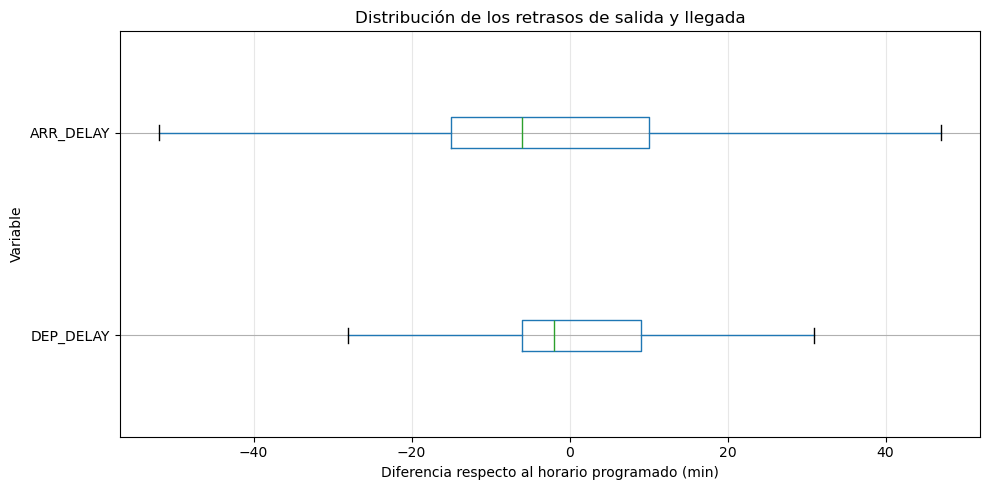

In [25]:
plt.figure(
    figsize=(10, 5)
)


quantitative_df[
    [
        "DEP_DELAY",
        "ARR_DELAY"
    ]
].boxplot(
    vert=False,
    showfliers=False
)


plt.title(
    "Distribución de los retrasos de salida y llegada"
)

plt.xlabel(
    "Diferencia respecto al horario programado (min)"
)

plt.ylabel(
    "Variable"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

plt.show()

El análisis mediante el criterio de 1,5 veces el rango intercuartílico identifica una proporción relevante de observaciones potencialmente atípicas, especialmente en las variables relacionadas con los retrasos.

`DEP_DELAY` presenta un 13,11 % de observaciones fuera de los límites IQR y `ARR_DELAY` un 9,31 %. En ambos casos, la gran mayoría de estas observaciones se encuentra por encima del límite superior, lo que evidencia una marcada asimetría positiva asociada a la existencia de una cola derecha de retrasos elevados.

Las restantes variables operacionales presentan aproximadamente entre un 5 % y un 6 % de observaciones por encima de sus respectivos límites superiores y prácticamente ninguna por debajo del límite inferior.

Estos resultados no implican que las observaciones identificadas sean incorrectas. El criterio IQR identifica valores alejados de la región central de una distribución, pero variables como los retrasos, los tiempos operacionales y la distancia pueden presentar legítimamente valores elevados.

Por este motivo, no se eliminan observaciones en esta etapa. La conveniencia de aplicar transformaciones o tratamientos específicos se evaluará posteriormente en función de las características de las variables y de los modelos utilizados.

### 5.5 Visualización de las distribuciones cuantitativas

Una vez analizadas las medidas de tendencia central, dispersión, percentiles y valores potencialmente atípicos, se estudia gráficamente la forma de las principales distribuciones cuantitativas.

Debido a la presencia de valores extremos y distribuciones con colas derechas prolongadas, la representación del rango completo puede dificultar la observación del comportamiento de la mayoría de los registros.

Por este motivo, los histogramas se representan hasta el percentil 99 de cada variable. Esta decisión afecta únicamente a la visualización y no elimina ni modifica observaciones del conjunto de datos.

El análisis permite evaluar visualmente la concentración, dispersión y asimetría de las variables antes de tomar decisiones posteriores de transformación o preprocesamiento.

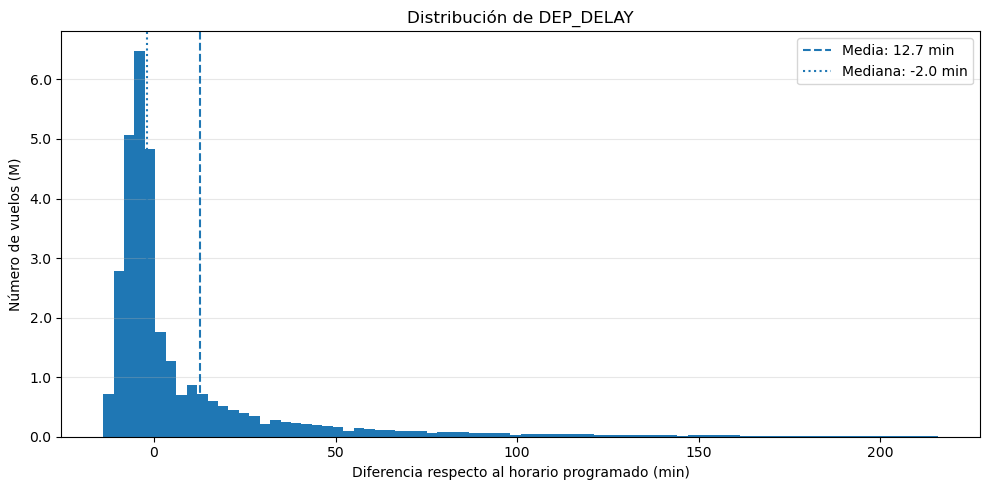

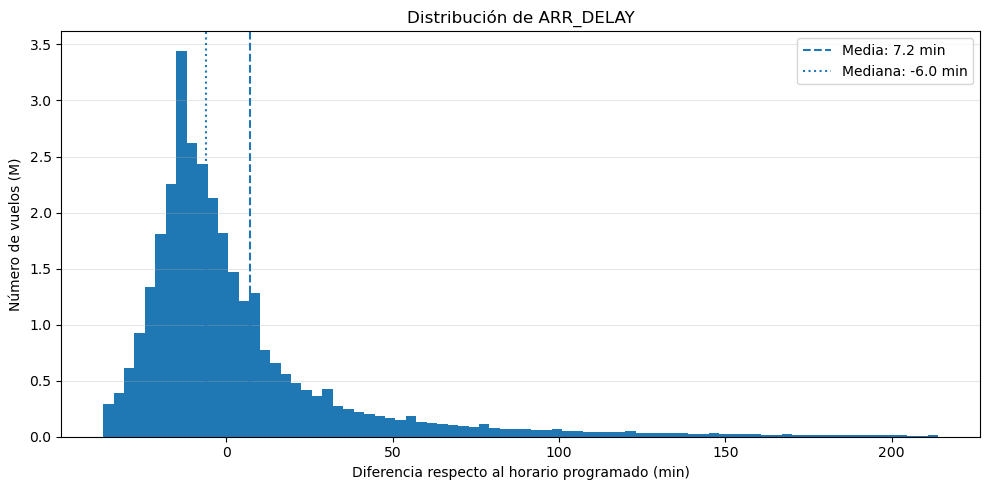

In [26]:
delay_columns = [
    "DEP_DELAY",
    "ARR_DELAY"
]


for variable in delay_columns:

    valid_values = (
        quantitative_df[variable]
        .dropna()
    )

    lower_limit = valid_values.quantile(
        0.01
    )

    upper_limit = valid_values.quantile(
        0.99
    )

    plot_values = valid_values[
        valid_values.between(
            lower_limit,
            upper_limit
        )
    ]


    plt.figure(
        figsize=(10, 5)
    )

    plt.hist(
        plot_values,
        bins=80
    )

    plt.axvline(
        valid_values.mean(),
        linestyle="--",
        label=(
            f"Media: "
            f"{valid_values.mean():.1f} min"
        )
    )

    plt.axvline(
        valid_values.median(),
        linestyle=":",
        label=(
            f"Mediana: "
            f"{valid_values.median():.1f} min"
        )
    )

    plt.title(
        f"Distribución de {variable}"
    )

    plt.xlabel(
        "Diferencia respecto al horario programado (min)"
    )

    plt.ylabel(
        "Número de vuelos (M)"
    )

    plt.gca().yaxis.set_major_formatter(
        MILLIONS_FORMATTER
    )

    plt.legend()

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

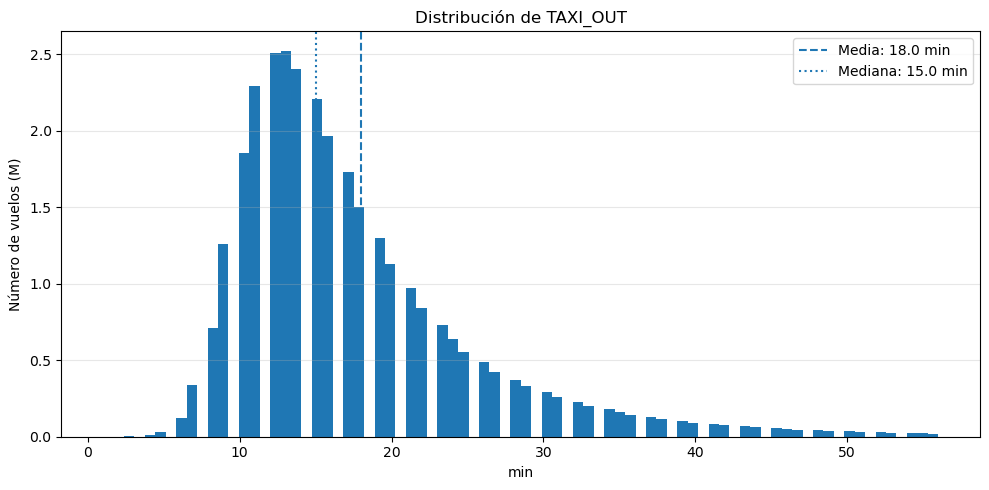

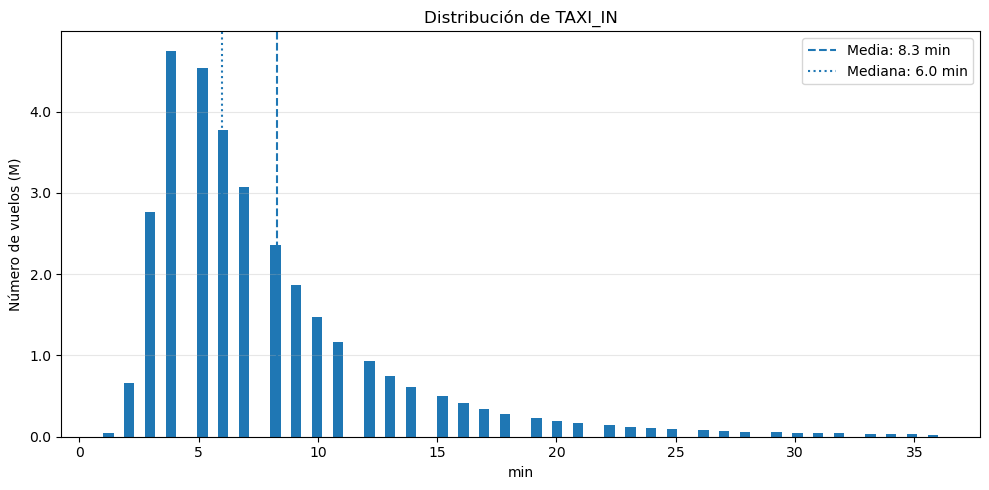

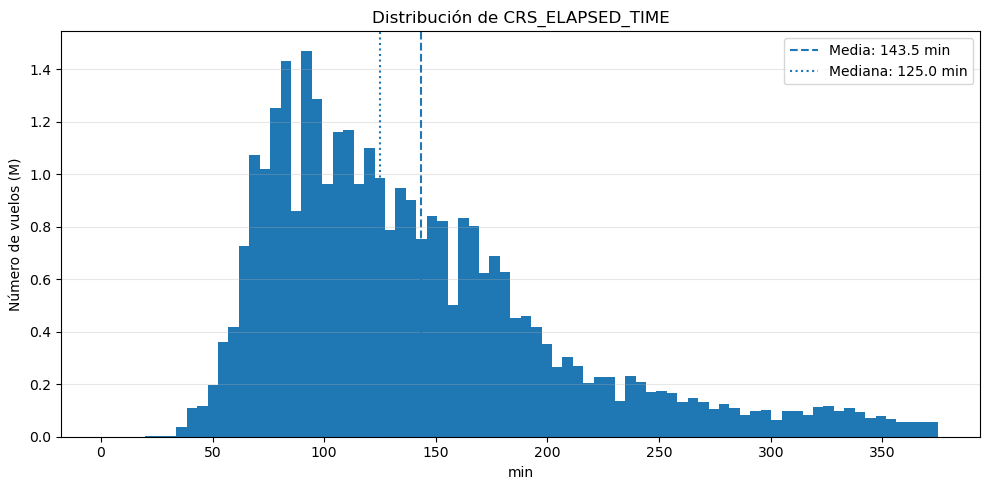

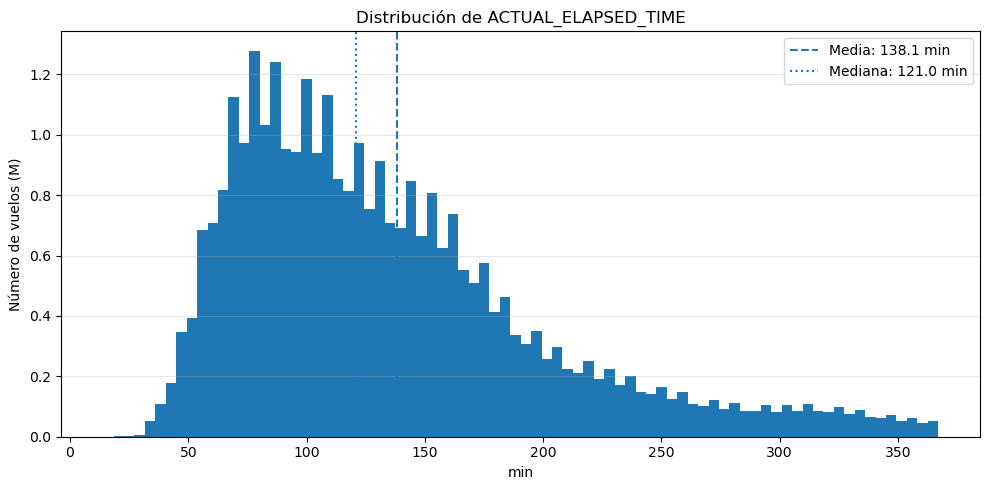

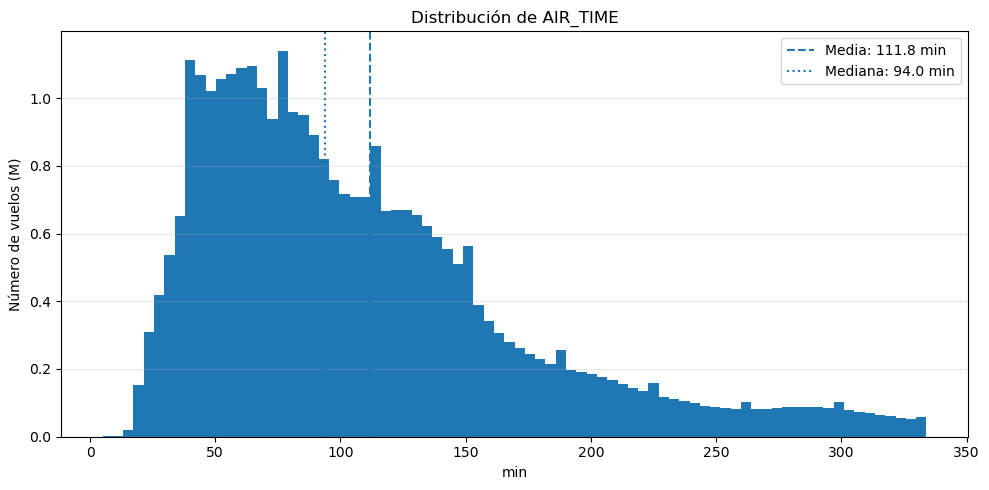

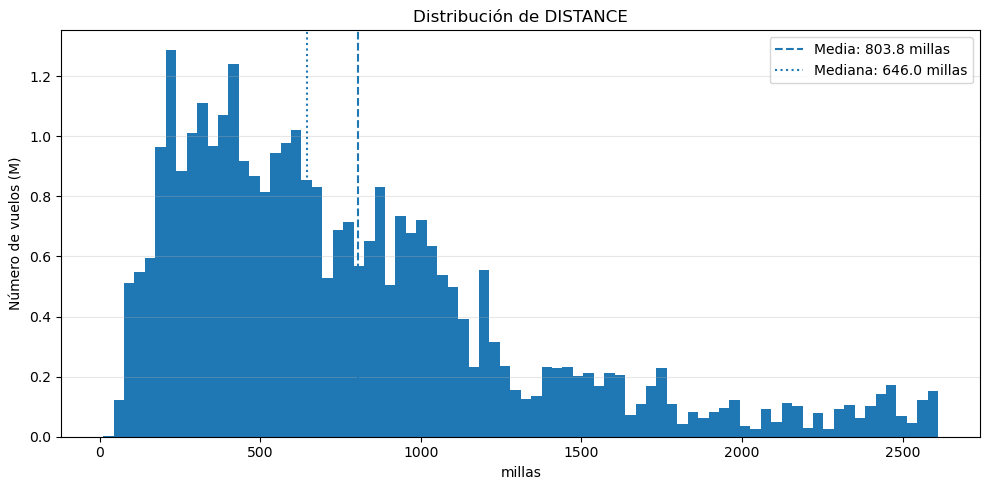

In [27]:
operational_columns = [
    "TAXI_OUT",
    "TAXI_IN",
    "CRS_ELAPSED_TIME",
    "ACTUAL_ELAPSED_TIME",
    "AIR_TIME",
    "DISTANCE"
]


variable_units = {
    "TAXI_OUT": "min",
    "TAXI_IN": "min",
    "CRS_ELAPSED_TIME": "min",
    "ACTUAL_ELAPSED_TIME": "min",
    "AIR_TIME": "min",
    "DISTANCE": "millas"
}


for variable in operational_columns:

    valid_values = (
        quantitative_df[variable]
        .dropna()
    )

    upper_limit = valid_values.quantile(
        0.99
    )

    plot_values = valid_values[
        valid_values <= upper_limit
    ]


    plt.figure(
        figsize=(10, 5)
    )

    plt.hist(
        plot_values,
        bins=80
    )

    plt.axvline(
        valid_values.mean(),
        linestyle="--",
        label=(
            f"Media: "
            f"{valid_values.mean():.1f} "
            f"{variable_units[variable]}"
        )
    )

    plt.axvline(
        valid_values.median(),
        linestyle=":",
        label=(
            f"Mediana: "
            f"{valid_values.median():.1f} "
            f"{variable_units[variable]}"
        )
    )

    plt.title(
        f"Distribución de {variable}"
    )

    plt.xlabel(
        variable_units[variable]
    )

    plt.ylabel(
        "Número de vuelos (M)"
    )

    plt.gca().yaxis.set_major_formatter(
        MILLIONS_FORMATTER
    )

    plt.legend()

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

### Interpretación

El análisis gráfico muestra que las principales variables cuantitativas presentan distribuciones asimétricas hacia la derecha. En todas las variables analizadas la media es superior a la mediana, comportamiento coherente con la existencia de observaciones elevadas que prolongan la cola superior de las distribuciones.

La asimetría es especialmente relevante en `DEP_DELAY` y `ARR_DELAY`. Aunque sus medianas son de -2 y -6 minutos respectivamente, sus medias ascienden a 12,7 y 7,2 minutos. Esto indica que la mayoría de las operaciones se concentra alrededor de la puntualidad o incluso en valores ligeramente adelantados, mientras que una proporción menor de retrasos elevados desplaza considerablemente la media.

`TAXI_OUT` y `TAXI_IN` también presentan asimetría positiva, aunque con una concentración más definida en tiempos de rodaje relativamente reducidos y una disminución progresiva de la frecuencia hacia tiempos superiores.

Las variables relacionadas con la duración del vuelo (`CRS_ELAPSED_TIME`, `ACTUAL_ELAPSED_TIME` y `AIR_TIME`) muestran distribuciones más heterogéneas, coherentes con la coexistencia de vuelos de diferentes duraciones y distancias. `DISTANCE` presenta igualmente una distribución asimétrica y con múltiples concentraciones de frecuencia, comportamiento compatible con la repetición de rutas entre pares concretos de aeropuertos.

Los resultados confirman que las distribuciones analizadas no presentan una forma aproximadamente normal y son coherentes con los valores atípicos superiores detectados previamente mediante el criterio IQR. No obstante, estos valores pueden corresponder a operaciones reales y no se eliminan durante el análisis exploratorio.

Las representaciones se limitan al percentil 99 —y al intervalo P1-P99 en las variables de retraso— exclusivamente para mejorar la legibilidad. Esta limitación no modifica el conjunto de datos utilizado en los análisis posteriores.

La posible necesidad de transformaciones, escalado robusto u otros tratamientos se evaluará posteriormente de acuerdo con los requisitos de los modelos empleados.

In [ ]:
categorical_summary = []


for variable in CATEGORICAL_COLUMNS:

    total = len(
        categorical_df
    )

    missing = (
        categorical_df[variable]
        .isna()
        .sum()
    )

    valid = (
        total
        - missing
    )

    cardinality = (
        categorical_df[variable]
        .nunique(
            dropna=True
        )
    )

    categorical_summary.append(
        {
            "VARIABLE": variable,
            "VALID": valid,
            "MISSING": missing,
            "MISSING_PERCENTAGE": (
                missing
                / total
                * 100
            ),
            "CARDINALITY": cardinality
        }
    )


categorical_summary_df = (
    pd.DataFrame(
        categorical_summary
    )
    .sort_values(
        "CARDINALITY",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


display(
    categorical_summary_df.round(3)
)

In [ ]:
def categorical_frequency(
    dataframe,
    variable
):

    valid_values = (
        dataframe[variable]
        .dropna()
    )

    counts = (
        valid_values
        .value_counts()
    )

    percentages = (
        counts
        / counts.sum()
        * 100
    )

    frequency_df = pd.DataFrame(
        {
            "CATEGORY": counts.index,
            "COUNT": counts.values,
            "PERCENTAGE": percentages.values
        }
    )

    return (
        frequency_df
        .reset_index(drop=True)
    )

In [ ]:
FREQUENCY_COLUMNS = [
    "MKT_UNIQUE_CARRIER",
    "OP_UNIQUE_CARRIER",
    "ORIGIN_STATE_ABR",
    "DEST_STATE_ABR",
    "DEP_TIME_BLK",
    "ARR_TIME_BLK",
    "DISTANCE_GROUP",
    "CANCELLATION_CODE"
]


categorical_frequency_tables = {}


for variable in FREQUENCY_COLUMNS:

    frequency_df = categorical_frequency(
        categorical_df,
        variable
    )

    categorical_frequency_tables[
        variable
    ] = frequency_df

    print(
        f"\n{variable}\n"
    )

    display(
        frequency_df
        .head(10)
        .round(2)
    )

In [ ]:
categorical_frequency_tables[
    "DISTANCE_GROUP"
]

distance_group_frequency_df = (
    categorical_frequency_tables[
        "DISTANCE_GROUP"
    ]
    .rename(
        columns={
            "CATEGORY": "DISTANCE_GROUP"
        }
    )
    .sort_values(
        "DISTANCE_GROUP"
    )
    .reset_index(
        drop=True
    )
)

In [ ]:
distance_group_frequency_df = (
    distance_group_frequency_df
    .merge(
        distance_group_reference_df,
        left_on="DISTANCE_GROUP",
        right_on="Code",
        how="left"
    )
    .drop(
        columns="Code"
    )
    .rename(
        columns={
            "Description": "DISTANCE_RANGE"
        }
    )
)

In [ ]:
distance_group_frequency_df = (
    distance_group_frequency_df[
        [
            "DISTANCE_GROUP",
            "DISTANCE_RANGE",
            "COUNT",
            "PERCENTAGE"
        ]
    ]
)


display(
    distance_group_frequency_df.round(2)
)

In [ ]:
HIGH_CARDINALITY_COLUMNS = [
    "TAIL_NUM",
    "ORIGIN",
    "DEST",
    "ORIGIN_CITY_NAME",
    "DEST_CITY_NAME"
]


high_cardinality_frequency_tables = {}


for variable in HIGH_CARDINALITY_COLUMNS:

    frequency_df = categorical_frequency(
        categorical_df,
        variable
    )

    high_cardinality_frequency_tables[
        variable
    ] = frequency_df

    print(
        f"\n{variable} - Top 10\n"
    )

    display(
        frequency_df
        .head(10)
        .round(2)
    )

In [ ]:
concentration_summary = []


for variable in FREQUENCY_COLUMNS:

    frequency_df = (
        categorical_frequency_tables[
            variable
        ]
    )

    concentration_summary.append(
        {
            "VARIABLE": variable,

            "TOP_1_PERCENTAGE": (
                frequency_df[
                    "PERCENTAGE"
                ]
                .head(1)
                .sum()
            ),

            "TOP_3_PERCENTAGE": (
                frequency_df[
                    "PERCENTAGE"
                ]
                .head(3)
                .sum()
            ),

            "TOP_5_PERCENTAGE": (
                frequency_df[
                    "PERCENTAGE"
                ]
                .head(5)
                .sum()
            )
        }
    )


category_concentration_df = (
    pd.DataFrame(
        concentration_summary
    )
    .sort_values(
        "TOP_5_PERCENTAGE",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


display(
    category_concentration_df.round(2)
)

In [22]:
categorical_summary = []


for variable in CATEGORICAL_COLUMNS:

    total = len(
        categorical_df
    )

    missing = (
        categorical_df[variable]
        .isna()
        .sum()
    )

    valid = (
        total
        - missing
    )

    cardinality = (
        categorical_df[variable]
        .nunique(
            dropna=True
        )
    )

    categorical_summary.append(
        {
            "VARIABLE": variable,
            "VALID": valid,
            "MISSING": missing,
            "MISSING_PERCENTAGE": (
                missing
                / total
                * 100
            ),
            "CARDINALITY": cardinality
        }
    )


categorical_summary_df = (
    pd.DataFrame(
        categorical_summary
    )
    .sort_values(
        "CARDINALITY",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


display(
    categorical_summary_df.round(3)
)

,VARIABLE,VALID,MISSING,MISSING_PERCENTAGE,CARDINALITY
0,TAIL_NUM,32643269,117860,0.360,7492
1,DEST,32761129,0,0.000,382
2,ORIGIN,32761129,0,0.000,381
3,DEST_CITY_NAME,32761129,0,0.000,376
4,ORIGIN_CITY_NAME,32761129,0,0.000,375
5,ORIGIN_STATE_ABR,32761129,0,0.000,53
6,DEST_STATE_ABR,32761129,0,0.000,53
7,OP_UNIQUE_CARRIER,32761129,0,0.000,21
8,DEP_TIME_BLK,32761129,0,0.000,19
9,ARR_TIME_BLK,32761129,0,0.000,19


In [28]:
def categorical_frequency(
    dataframe,
    variable
):

    # Excluir los valores ausentes porque
    # se analizan separadamente en 6.2.
    valid_values = (
        dataframe[variable]
        .dropna()
    )

    # Contar el número de registros
    # correspondiente a cada categoría.
    counts = (
        valid_values
        .value_counts()
    )

    # Calcular la frecuencia relativa
    # respecto a las observaciones válidas.
    percentages = (
        counts
        / counts.sum()
        * 100
    )

    frequency_df = pd.DataFrame(
        {
            "CATEGORY": counts.index,
            "COUNT": counts.values,
            "PERCENTAGE": percentages.values
        }
    )

    return (
        frequency_df
        .reset_index(drop=True)
    )

In [29]:
FREQUENCY_COLUMNS = [
    "MKT_UNIQUE_CARRIER",
    "OP_UNIQUE_CARRIER",
    "ORIGIN_STATE_ABR",
    "DEST_STATE_ABR",
    "DEP_TIME_BLK",
    "ARR_TIME_BLK",
    "CANCELLATION_CODE"
]


categorical_frequency_tables = {}


for variable in FREQUENCY_COLUMNS:

    frequency_df = categorical_frequency(
        categorical_df,
        variable
    )

    categorical_frequency_tables[
        variable
    ] = frequency_df

    print(
        f"\n{variable}\n"
    )

    display(
        frequency_df
        .head(10)
        .round(2)
    )


MKT_UNIQUE_CARRIER



,CATEGORY,COUNT,PERCENTAGE
0,AA,8260447,25.21
1,DL,6774537,20.68
2,WN,6122461,18.69
3,UA,6017264,18.37
4,AS,1797284,5.49
5,B6,1117381,3.41
6,NK,999091,3.05
7,F9,827233,2.53
8,G4,531985,1.62
9,HA,313446,0.96



OP_UNIQUE_CARRIER



,CATEGORY,COUNT,PERCENTAGE
0,WN,6122461,18.69
1,DL,4333042,13.23
2,AA,4180118,12.76
3,OO,3344022,10.21
4,UA,3252402,9.93
5,YX,1412408,4.31
6,MQ,1184204,3.61
7,B6,1117381,3.41
8,AS,1099783,3.36
9,NK,999091,3.05



ORIGIN_STATE_ABR



...

,CATEGORY,COUNT,PERCENTAGE
0,0600-0659,2269001,6.93
1,0700-0759,2263250,6.91
2,0800-0859,2223536,6.79
3,1000-1059,2062129,6.29
4,1700-1759,2059068,6.29
5,1100-1159,2037579,6.22
6,1200-1259,1999600,6.1
7,1800-1859,1981104,6.05
8,1300-1359,1963885,5.99
9,1400-1459,1929900,5.89



ARR_TIME_BLK



,CATEGORY,COUNT,PERCENTAGE
0,1600-1659,2061172,6.29
1,1700-1759,2037989,6.22
2,1100-1159,2002720,6.11
3,1200-1259,1985254,6.06
4,2100-2159,1972797,6.02
5,0900-0959,1968064,6.01
6,1800-1859,1954281,5.97
7,1400-1459,1947360,5.94
8,1900-1959,1945791,5.94
9,1300-1359,1922469,5.87



CANCELLATION_CODE



,CATEGORY,COUNT,PERCENTAGE
0,B,337443,58.22
1,A,166547,28.74
2,C,74165,12.8
3,D,1397,0.24


In [30]:
distance_group_frequency_df = (
    categorical_df[
        "DISTANCE_GROUP"
    ]
    .dropna()
    .value_counts()
    .sort_index()
    .rename_axis(
        "DISTANCE_GROUP"
    )
    .reset_index(
        name="COUNT"
    )
)


distance_group_frequency_df[
    "PERCENTAGE"
] = (
    distance_group_frequency_df["COUNT"]
    / distance_group_frequency_df["COUNT"].sum()
    * 100
)

In [31]:
distance_group_reference_df = pd.read_csv(
    DISTANCE_GROUP_REFERENCE
)


display(
    distance_group_reference_df
)

,Code,Description
0,1,Less Than 250 Miles
1,2,250-499 Miles
2,3,500-749 Miles
3,4,750-999 Miles
4,5,1000-1249 Miles
5,6,1250-1499 Miles
6,7,1500-1749 Miles
7,8,1750-1999 Miles
8,9,2000-2249 Miles
9,10,2250-2499 Miles


In [34]:
distance_group_frequency_df = (
    distance_group_frequency_df
    .merge(
        distance_group_reference_df,
        left_on="DISTANCE_GROUP",
        right_on="Code",
        how="left"
    )
    .drop(
        columns="Code"
    )
    .rename(
        columns={
            "Description": "DISTANCE_RANGE"
        }
    )
)


distance_group_frequency_df = (
    distance_group_frequency_df[
        [
            "DISTANCE_GROUP",
            "DISTANCE_RANGE",
            "COUNT",
            "PERCENTAGE"
        ]
    ]
)


display(
    distance_group_frequency_df.round(2)
)

,DISTANCE_GROUP,DISTANCE_RANGE,COUNT,PERCENTAGE
0,1,Less Than 250 Miles,4290014,13.09
1,2,250-499 Miles,7811720,23.84
2,3,500-749 Miles,6521689,19.91
3,4,750-999 Miles,5159920,15.75
4,5,1000-1249 Miles,3595407,10.97
5,6,1250-1499 Miles,1436688,4.39
6,7,1500-1749 Miles,1375550,4.2
7,8,1750-1999 Miles,670458,2.05
8,9,2000-2249 Miles,498261,1.52
9,10,2250-2499 Miles,767441,2.34


In [32]:
print(
    "Columnas del catálogo:"
)

print(
    distance_group_reference_df.columns.tolist()
)

Columnas del catálogo:
['Code', 'Description']


In [33]:
HIGH_CARDINALITY_COLUMNS = [
    "TAIL_NUM",
    "ORIGIN",
    "DEST",
    "ORIGIN_CITY_NAME",
    "DEST_CITY_NAME"
]


high_cardinality_frequency_tables = {}


for variable in HIGH_CARDINALITY_COLUMNS:

    frequency_df = categorical_frequency(
        categorical_df,
        variable
    )

    high_cardinality_frequency_tables[
        variable
    ] = frequency_df

    print(
        f"\n{variable} - Top 10\n"
    )

    display(
        frequency_df
        .head(10)
        .round(2)
    )


TAIL_NUM - Top 10



,CATEGORY,COUNT,PERCENTAGE
0,N492HA,12192,0.04
1,N478HA,12011,0.04
2,N495HA,11998,0.04
3,N493HA,11989,0.04
4,N490HA,11973,0.04
5,N483HA,11911,0.04
6,N486HA,11773,0.04
7,N489HA,11742,0.04
8,N488HA,11647,0.04
9,N487HA,11540,0.04



ORIGIN - Top 10



,CATEGORY,COUNT,PERCENTAGE
0,ATL,1490028,4.55
1,ORD,1427347,4.36
2,DEN,1336770,4.08
3,DFW,1324770,4.04
4,CLT,1031345,3.15
5,LAX,857328,2.62
6,PHX,824314,2.52
7,LAS,815809,2.49
8,SEA,795478,2.43
9,LGA,736101,2.25



DEST - Top 10



,CATEGORY,COUNT,PERCENTAGE
0,ATL,1489929,4.55
1,ORD,1427220,4.36
2,DEN,1336698,4.08
3,DFW,1324720,4.04
4,CLT,1031336,3.15
5,LAX,857352,2.62
6,PHX,824279,2.52
7,LAS,815829,2.49
8,SEA,795445,2.43
9,LGA,736086,2.25



ORIGIN_CITY_NAME - Top 10



,CATEGORY,COUNT,PERCENTAGE
0,"Chicago, IL",1772214,5.41
1,"Atlanta, GA",1490028,4.55
2,"Denver, CO",1336770,4.08
3,"Dallas/Fort Worth, TX",1324770,4.04
4,"New York, NY",1304555,3.98
5,"Charlotte, NC",1031345,3.15
6,"Washington, DC",1003101,3.06
7,"Houston, TX",955114,2.92
8,"Los Angeles, CA",857328,2.62
9,"Phoenix, AZ",850826,2.6



DEST_CITY_NAME - Top 10



,CATEGORY,COUNT,PERCENTAGE
0,"Chicago, IL",1772103,5.41
1,"Atlanta, GA",1489929,4.55
2,"Denver, CO",1336698,4.08
3,"Dallas/Fort Worth, TX",1324720,4.04
4,"New York, NY",1304440,3.98
5,"Charlotte, NC",1031336,3.15
6,"Washington, DC",1003187,3.06
7,"Houston, TX",955074,2.92
8,"Los Angeles, CA",857352,2.62
9,"Phoenix, AZ",850810,2.6


In [35]:
concentration_summary = []


for variable in FREQUENCY_COLUMNS:

    frequency_df = (
        categorical_frequency_tables[
            variable
        ]
        .copy()
    )

    frequency_df[
        "CUMULATIVE_PERCENTAGE"
    ] = (
        frequency_df[
            "PERCENTAGE"
        ]
        .cumsum()
    )

    categorical_frequency_tables[
        variable
    ] = frequency_df


    concentration_summary.append(
        {
            "VARIABLE": variable,

            "TOP_1_PERCENTAGE": (
                frequency_df[
                    "PERCENTAGE"
                ]
                .head(1)
                .sum()
            ),

            "TOP_3_PERCENTAGE": (
                frequency_df[
                    "PERCENTAGE"
                ]
                .head(3)
                .sum()
            ),

            "TOP_5_PERCENTAGE": (
                frequency_df[
                    "PERCENTAGE"
                ]
                .head(5)
                .sum()
            )
        }
    )


category_concentration_df = (
    pd.DataFrame(
        concentration_summary
    )
    .sort_values(
        "TOP_5_PERCENTAGE",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


display(
    category_concentration_df.round(2)
)

,VARIABLE,TOP_1_PERCENTAGE,TOP_3_PERCENTAGE,TOP_5_PERCENTAGE
0,CANCELLATION_CODE,58.22,99.76,100.00
1,MKT_UNIQUE_CARRIER,25.21,64.58,88.43
2,OP_UNIQUE_CARRIER,18.69,44.67,64.81
3,ORIGIN_STATE_ABR,10.68,29.25,40.15
4,DEST_STATE_ABR,10.68,29.25,40.15
5,DEP_TIME_BLK,6.93,20.62,33.20
6,ARR_TIME_BLK,6.29,18.63,30.71


In [36]:
distance_concentration_df = (
    distance_group_frequency_df
    .sort_values(
        "PERCENTAGE",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


distance_concentration_row = pd.DataFrame(
    [
        {
            "VARIABLE": "DISTANCE_GROUP",

            "TOP_1_PERCENTAGE": (
                distance_concentration_df[
                    "PERCENTAGE"
                ]
                .head(1)
                .sum()
            ),

            "TOP_3_PERCENTAGE": (
                distance_concentration_df[
                    "PERCENTAGE"
                ]
                .head(3)
                .sum()
            ),

            "TOP_5_PERCENTAGE": (
                distance_concentration_df[
                    "PERCENTAGE"
                ]
                .head(5)
                .sum()
            )
        }
    ]
)


category_concentration_df = (
    pd.concat(
        [
            category_concentration_df,
            distance_concentration_row
        ],
        ignore_index=True
    )
    .sort_values(
        "TOP_5_PERCENTAGE",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


display(
    category_concentration_df.round(2)
)

,VARIABLE,TOP_1_PERCENTAGE,TOP_3_PERCENTAGE,TOP_5_PERCENTAGE
0,CANCELLATION_CODE,58.22,99.76,100.00
1,MKT_UNIQUE_CARRIER,25.21,64.58,88.43
2,DISTANCE_GROUP,23.84,59.50,83.57
3,OP_UNIQUE_CARRIER,18.69,44.67,64.81
4,ORIGIN_STATE_ABR,10.68,29.25,40.15
5,DEST_STATE_ABR,10.68,29.25,40.15
6,DEP_TIME_BLK,6.93,20.62,33.20
7,ARR_TIME_BLK,6.29,18.63,30.71


In [17]:
missing_categorical_columns = [
    column
    for column in CATEGORICAL_COLUMNS
    if column not in inspection_df.columns
]


print(
    f"Variables no encontradas en el esquema: "
    f"{len(missing_categorical_columns)}"
)


if len(missing_categorical_columns) == 0:

    print(
        "\nTodas las variables seleccionadas "
        "están disponibles."
    )

else:

    print(
        "\nVariables no encontradas:"
    )

    for column in missing_categorical_columns:

        print(
            f"- {column}"
        )

Variables no encontradas en el esquema: 0

Todas las variables seleccionadas están disponibles.


In [18]:
categorical_parts = []


for file_number, parquet_file in enumerate(
    parquet_files,
    start=1
):

    temp_df = pd.read_parquet(
        parquet_file,
        columns=CATEGORICAL_COLUMNS
    )

    categorical_parts.append(
        temp_df
    )

    if (
        file_number % 50 == 0
        or file_number == len(parquet_files)
    ):

        print(
            f"Procesados "
            f"{file_number}/{len(parquet_files)} "
            f"archivos"
        )


categorical_df = pd.concat(
    categorical_parts,
    ignore_index=True
)

Procesados 50/354 archivos
Procesados 100/354 archivos
Procesados 150/354 archivos
Procesados 200/354 archivos
Procesados 250/354 archivos
Procesados 300/354 archivos
Procesados 350/354 archivos
Procesados 354/354 archivos


In [19]:
print(
    f"\nRegistros cargados : "
    f"{len(categorical_df):,}"
)

print(
    f"Variables cargadas : "
    f"{categorical_df.shape[1]}"
)

print(
    f"Memoria utilizada  : "
    f"{categorical_df.memory_usage(deep=True).sum() / 1024**3:.2f} GB"
)


Registros cargados : 32,761,129
Variables cargadas : 13
Memoria utilizada  : 23.10 GB


In [22]:
FREQUENCY_COLUMNS = [
    "MKT_UNIQUE_CARRIER",
    "OP_UNIQUE_CARRIER",
    "ORIGIN_STATE_ABR",
    "DEST_STATE_ABR",
    "DEP_TIME_BLK",
    "ARR_TIME_BLK",
    "DISTANCE_GROUP",
    "CANCELLATION_CODE"
]


categorical_frequency_tables = {}


for variable in FREQUENCY_COLUMNS:

    frequency_df = categorical_frequency(
        categorical_df,
        variable
    )

    categorical_frequency_tables[
        variable
    ] = frequency_df

    print(
        f"\n{variable}\n"
    )

    display(
        frequency_df
        .head(10)
        .round(2)
    )


MKT_UNIQUE_CARRIER



,CATEGORY,COUNT,PERCENTAGE
0,AA,8260447,25.21
1,DL,6774537,20.68
2,WN,6122461,18.69
3,UA,6017264,18.37
4,AS,1797284,5.49
5,B6,1117381,3.41
6,NK,999091,3.05
7,F9,827233,2.53
8,G4,531985,1.62
9,HA,313446,0.96



OP_UNIQUE_CARRIER



,CATEGORY,COUNT,PERCENTAGE
0,WN,6122461,18.69
1,DL,4333042,13.23
2,AA,4180118,12.76
3,OO,3344022,10.21
4,UA,3252402,9.93
5,YX,1412408,4.31
6,MQ,1184204,3.61
7,B6,1117381,3.41
8,AS,1099783,3.36
9,NK,999091,3.05



ORIGIN_STATE_ABR



...

,CATEGORY,COUNT,PERCENTAGE
0,1600-1659,2061172,6.29
1,1700-1759,2037989,6.22
2,1100-1159,2002720,6.11
3,1200-1259,1985254,6.06
4,2100-2159,1972797,6.02
5,0900-0959,1968064,6.01
6,1800-1859,1954281,5.97
7,1400-1459,1947360,5.94
8,1900-1959,1945791,5.94
9,1300-1359,1922469,5.87



DISTANCE_GROUP



,CATEGORY,COUNT,PERCENTAGE
0,2,7811720,23.84
1,3,6521689,19.91
2,4,5159920,15.75
3,1,4290014,13.09
4,5,3595407,10.97
5,6,1436688,4.39
6,7,1375550,4.2
7,10,767441,2.34
8,8,670458,2.05
9,11,633981,1.94



CANCELLATION_CODE



,CATEGORY,COUNT,PERCENTAGE
0,B,337443,58.22
1,A,166547,28.74
2,C,74165,12.8
3,D,1397,0.24


In [23]:
categorical_frequency_tables[
    "DISTANCE_GROUP"
]

,CATEGORY,COUNT,PERCENTAGE
0,2,7811720,23.844477
1,3,6521689,19.90679
2,4,5159920,15.750129
3,1,4290014,13.09483
4,5,3595407,10.974613
5,6,1436688,4.385343
6,7,1375550,4.198726
7,10,767441,2.342535
8,8,670458,2.046505
9,11,633981,1.935162


In [24]:
distance_group_frequency_df = (
    categorical_frequency_tables[
        "DISTANCE_GROUP"
    ]
    .rename(
        columns={
            "CATEGORY": "DISTANCE_GROUP"
        }
    )
    .sort_values(
        "DISTANCE_GROUP"
    )
    .reset_index(
        drop=True
    )
)

In [26]:
distance_group_frequency_df = (
    distance_group_frequency_df
    .merge(
        distance_group_reference_df,
        left_on="DISTANCE_GROUP",
        right_on="Code",
        how="left"
    )
    .drop(
        columns="Code"
    )
    .rename(
        columns={
            "Description": "DISTANCE_RANGE"
        }
    )
)

NameError: name 'distance_group_reference_df' is not defined

In [ ]:
HIGH_CARDINALITY_COLUMNS = [
    "TAIL_NUM",
    "ORIGIN",
    "DEST",
    "ORIGIN_CITY_NAME",
    "DEST_CITY_NAME"
]


high_cardinality_frequency_tables = {}


for variable in HIGH_CARDINALITY_COLUMNS:

    frequency_df = categorical_frequency(
        categorical_df,
        variable
    )

    high_cardinality_frequency_tables[
        variable
    ] = frequency_df

    print(
        f"\n{variable} - Top 10\n"
    )

    display(
        frequency_df
        .head(10)
        .round(2)
    )

In [ ]:
concentration_summary = []


for variable in FREQUENCY_COLUMNS:

    frequency_df = (
        categorical_frequency_tables[
            variable
        ]
    )

    concentration_summary.append(
        {
            "VARIABLE": variable,

            "TOP_1_PERCENTAGE": (
                frequency_df[
                    "PERCENTAGE"
                ]
                .head(1)
                .sum()
            ),

            "TOP_3_PERCENTAGE": (
                frequency_df[
                    "PERCENTAGE"
                ]
                .head(3)
                .sum()
            ),

            "TOP_5_PERCENTAGE": (
                frequency_df[
                    "PERCENTAGE"
                ]
                .head(5)
                .sum()
            )
        }
    )


category_concentration_df = (
    pd.DataFrame(
        concentration_summary
    )
    .sort_values(
        "TOP_5_PERCENTAGE",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


display(
    category_concentration_df.round(2)
)

## 6. Análisis de variables cualitativas

Las variables cualitativas describen características categóricas de los vuelos, como las aerolíneas, los aeropuertos, los estados, las franjas horarias, los grupos de distancia y los motivos de cancelación.

Debido al elevado volumen del histórico, compuesto por más de 32 millones de registros, no resulta eficiente mantener simultáneamente en memoria todas las observaciones de las variables categóricas.

Por este motivo, el análisis se realiza mediante una única lectura secuencial de los archivos Parquet. Durante esta lectura se acumulan las frecuencias y valores ausentes de cada variable, conservando únicamente los resultados agregados necesarios para los análisis posteriores.

Esta estrategia reduce considerablemente el consumo de memoria sin modificar la población analizada ni los resultados estadísticos obtenidos.

### 6.1 Preparación y agregación de las variables cualitativas

In [31]:
CATEGORICAL_COLUMNS = [
    # Aerolíneas.
    "MKT_UNIQUE_CARRIER",
    "OP_UNIQUE_CARRIER",

    # Aeronave.
    "TAIL_NUM",

    # Origen.
    "ORIGIN",
    "ORIGIN_CITY_NAME",
    "ORIGIN_STATE_ABR",

    # Destino.
    "DEST",
    "DEST_CITY_NAME",
    "DEST_STATE_ABR",

    # Franjas horarias.
    "DEP_TIME_BLK",
    "ARR_TIME_BLK",

    # Grupo de distancia.
    "DISTANCE_GROUP",

    # Cancelación.
    "CANCELLATION_CODE"
]

In [32]:
missing_categorical_columns = [
    column
    for column in CATEGORICAL_COLUMNS
    if column not in inspection_df.columns
]


print(
    f"Variables cualitativas seleccionadas: "
    f"{len(CATEGORICAL_COLUMNS)}"
)

print(
    f"Variables no encontradas en el esquema: "
    f"{len(missing_categorical_columns)}"
)


if len(missing_categorical_columns) == 0:

    print(
        "\nTodas las variables seleccionadas "
        "están disponibles."
    )

else:

    print(
        "\nVariables no encontradas:"
    )

    for column in missing_categorical_columns:

        print(
            f"- {column}"
        )

Variables cualitativas seleccionadas: 13
Variables no encontradas en el esquema: 0

Todas las variables seleccionadas están disponibles.


In [33]:
from collections import Counter


category_counts = {
    variable: Counter()
    for variable in CATEGORICAL_COLUMNS
}


category_missing = {
    variable: 0
    for variable in CATEGORICAL_COLUMNS
}


total_categorical_rows = 0

In [34]:
for file_number, parquet_file in enumerate(
    parquet_files,
    start=1
):

    temp_df = pd.read_parquet(
        parquet_file,
        columns=CATEGORICAL_COLUMNS
    )


    total_categorical_rows += len(
        temp_df
    )


    for variable in CATEGORICAL_COLUMNS:

        series = temp_df[
            variable
        ]


        # Acumular valores ausentes.
        category_missing[
            variable
        ] += int(
            series
            .isna()
            .sum()
        )


        # Calcular las frecuencias de las
        # categorías válidas del archivo.
        file_counts = (
            series
            .value_counts(
                dropna=True
            )
        )


        # Incorporar las frecuencias del archivo
        # al acumulador general.
        category_counts[
            variable
        ].update(
            {
                category: int(count)
                for category, count
                in file_counts.items()
            }
        )


    if (
        file_number % 50 == 0
        or file_number == len(parquet_files)
    ):

        print(
            f"Procesados "
            f"{file_number}/{len(parquet_files)} "
            f"archivos"
        )

Procesados 50/354 archivos
Procesados 100/354 archivos
Procesados 150/354 archivos
Procesados 200/354 archivos
Procesados 250/354 archivos
Procesados 300/354 archivos
Procesados 350/354 archivos
Procesados 354/354 archivos


In [35]:
print(
    f"\nRegistros procesados : "
    f"{total_categorical_rows:,}"
)

print(
    f"Variables analizadas : "
    f"{len(CATEGORICAL_COLUMNS)}"
)


Registros procesados : 32,761,129
Variables analizadas : 13


### 6.2 Completitud y cardinalidad de las variables cualitativas

A partir de las frecuencias acumuladas durante la lectura del histórico, se analiza la completitud y cardinalidad de cada variable cualitativa.

La completitud permite cuantificar el número y porcentaje de observaciones válidas y ausentes, mientras que la cardinalidad representa el número de categorías diferentes observadas.

La cardinalidad resulta especialmente relevante para el posterior modelado, ya que variables con un número elevado de categorías pueden requerir estrategias de codificación diferentes a las utilizadas en variables de baja cardinalidad.

Los cálculos se realizan sobre el histórico completo y utilizan los agregados obtenidos durante la única lectura realizada en la sección anterior.

In [36]:
categorical_summary = []


for variable in CATEGORICAL_COLUMNS:

    missing = (
        category_missing[
            variable
        ]
    )

    valid = (
        total_categorical_rows
        - missing
    )

    cardinality = len(
        category_counts[
            variable
        ]
    )


    categorical_summary.append(
        {
            "VARIABLE": variable,
            "VALID": valid,
            "MISSING": missing,
            "MISSING_PERCENTAGE": (
                missing
                / total_categorical_rows
                * 100
            ),
            "CARDINALITY": cardinality
        }
    )


categorical_summary_df = (
    pd.DataFrame(
        categorical_summary
    )
    .sort_values(
        "CARDINALITY",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


display(
    categorical_summary_df.round(3)
)

,VARIABLE,VALID,MISSING,MISSING_PERCENTAGE,CARDINALITY
0,TAIL_NUM,32643269,117860,0.360,7492
1,DEST,32761129,0,0.000,382
2,ORIGIN,32761129,0,0.000,381
3,DEST_CITY_NAME,32761129,0,0.000,376
4,ORIGIN_CITY_NAME,32761129,0,0.000,375
5,ORIGIN_STATE_ABR,32761129,0,0.000,53
6,DEST_STATE_ABR,32761129,0,0.000,53
7,OP_UNIQUE_CARRIER,32761129,0,0.000,21
8,DEP_TIME_BLK,32761129,0,0.000,19
9,ARR_TIME_BLK,32761129,0,0.000,19


### 6.3 Distribución de frecuencias de las variables cualitativas

Una vez estudiadas la completitud y cardinalidad de las variables cualitativas, se analiza cómo se distribuyen las observaciones entre sus diferentes categorías.

Para cada variable se calcula la frecuencia absoluta, correspondiente al número de observaciones pertenecientes a cada categoría, y la frecuencia relativa, que expresa el peso porcentual de cada categoría respecto al total de observaciones válidas de la variable.

Los cálculos se realizan a partir de las frecuencias acumuladas obtenidas durante la lectura incremental del histórico, por lo que no es necesario volver a cargar los archivos Parquet.

En las variables de elevada cardinalidad se muestran únicamente las diez categorías más frecuentes para facilitar su interpretación. Esta limitación afecta exclusivamente a la presentación de los resultados y no al cálculo estadístico.

In [37]:
def build_frequency_table(
    variable
):

    counts = (
        category_counts[
            variable
        ]
    )

    valid_total = sum(
        counts.values()
    )

    frequency_df = pd.DataFrame(
        counts.items(),
        columns=[
            "CATEGORY",
            "COUNT"
        ]
    )


    frequency_df[
        "PERCENTAGE"
    ] = (
        frequency_df["COUNT"]
        / valid_total
        * 100
    )


    frequency_df = (
        frequency_df
        .sort_values(
            "COUNT",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )


    return frequency_df

In [38]:
categorical_frequency_tables = {}


for variable in CATEGORICAL_COLUMNS:

    categorical_frequency_tables[
        variable
    ] = build_frequency_table(
        variable
    )

In [39]:
for variable in CATEGORICAL_COLUMNS:

    frequency_df = (
        categorical_frequency_tables[
            variable
        ]
    )


    print(
        f"\n{variable}\n"
    )


    if variable == "DISTANCE_GROUP":

        display(
            frequency_df
            .sort_values(
                "CATEGORY"
            )
            .round(2)
        )

    elif len(frequency_df) <= 20:

        display(
            frequency_df
            .round(2)
        )

    else:

        display(
            frequency_df
            .head(10)
            .round(2)
        )


MKT_UNIQUE_CARRIER



,CATEGORY,COUNT,PERCENTAGE
0,AA,8260447,25.21
1,DL,6774537,20.68
2,WN,6122461,18.69
3,UA,6017264,18.37
4,AS,1797284,5.49
5,B6,1117381,3.41
6,NK,999091,3.05
7,F9,827233,2.53
8,G4,531985,1.62
9,HA,313446,0.96



OP_UNIQUE_CARRIER



,CATEGORY,COUNT,PERCENTAGE
0,WN,6122461,18.69
1,DL,4333042,13.23
2,AA,4180118,12.76
3,OO,3344022,10.21
4,UA,3252402,9.93
5,YX,1412408,4.31
6,MQ,1184204,3.61
7,B6,1117381,3.41
8,AS,1099783,3.36
9,NK,999091,3.05



TAIL_NUM



...

,CATEGORY,COUNT,PERCENTAGE
0,1600-1659,2061172,6.29
1,1700-1759,2037989,6.22
2,1100-1159,2002720,6.11
3,1200-1259,1985254,6.06
4,2100-2159,1972797,6.02
5,0900-0959,1968064,6.01
6,1800-1859,1954281,5.97
7,1400-1459,1947360,5.94
8,1900-1959,1945791,5.94
9,1300-1359,1922469,5.87



DISTANCE_GROUP



,CATEGORY,COUNT,PERCENTAGE
3,1,4290014,13.09
0,2,7811720,23.84
1,3,6521689,19.91
2,4,5159920,15.75
4,5,3595407,10.97
5,6,1436688,4.39
6,7,1375550,4.20
8,8,670458,2.05
10,9,498261,1.52
7,10,767441,2.34



CANCELLATION_CODE



,CATEGORY,COUNT,PERCENTAGE
0,B,337443,58.22
1,A,166547,28.74
2,C,74165,12.80
3,D,1397,0.24


### Interpretación

Las variables cualitativas presentan niveles de concentración muy diferentes.

`MKT_UNIQUE_CARRIER` muestra una distribución relativamente concentrada, ya que AA, DL, WN y UA representan conjuntamente aproximadamente el 83 % de los vuelos. Por el contrario, `OP_UNIQUE_CARRIER` distribuye las operaciones entre un mayor número de compañías, evidenciando diferencias entre la aerolínea comercializadora y la operadora efectiva.

Las variables asociadas a aeropuertos y ciudades presentan una distribución más dispersa. Aunque ATL, ORD, DEN y DFW se encuentran entre los aeropuertos con mayor volumen, ninguna categoría individual representa más del 5 % del histórico. Las distribuciones agregadas de origen y destino resultan prácticamente equivalentes.

`TAIL_NUM` presenta un comportamiento especialmente disperso. A pesar de su elevada cardinalidad, incluso las aeronaves más frecuentes representan alrededor del 0,04 % de las observaciones válidas, aspecto que deberá considerarse en una futura estrategia de codificación.

Las franjas horarias de salida y llegada muestran distribuciones relativamente repartidas, aunque las operaciones de salida presentan mayor concentración durante las primeras horas de la mañana.

`DISTANCE_GROUP` concentra la mayor parte de las observaciones en los primeros grupos: las cinco categorías más frecuentes representan aproximadamente el 83,56 % de los vuelos, resultado coherente con la concentración observada previamente en las distancias cortas y medias.

Finalmente, `CANCELLATION_CODE` presenta una distribución altamente concentrada entre los vuelos cancelados. Las categorías A, B y C acumulan el 99,76 % de los códigos disponibles, mientras que D representa únicamente el 0,24 %.

Los resultados muestran que la cardinalidad y la concentración representan características diferentes de una variable categórica y deberán considerarse conjuntamente durante las decisiones posteriores de preprocesamiento y modelado.

### 6.4 Concentración de categorías

Además de conocer la frecuencia individual de cada categoría, se analiza qué proporción de las observaciones queda concentrada en las categorías más frecuentes de cada variable.

Para ello se calcula el porcentaje acumulado correspondiente a la categoría más frecuente, las tres categorías más frecuentes y las cinco categorías más frecuentes.

Este análisis complementa la cardinalidad, ya que dos variables pueden presentar el mismo número de categorías y, sin embargo, distribuir sus observaciones de forma muy diferente.

Una elevada concentración indica que una pequeña cantidad de categorías representa gran parte de los registros, mientras que una baja concentración refleja una distribución más dispersa.

In [41]:
concentration_summary = []


for variable in CATEGORICAL_COLUMNS:

    frequency_df = (
        categorical_frequency_tables[
            variable
        ]
    )

    concentration_summary.append(
        {
            "VARIABLE": variable,

            "TOP_1_PERCENTAGE": (
                frequency_df[
                    "PERCENTAGE"
                ]
                .head(1)
                .sum()
            ),

            "TOP_3_PERCENTAGE": (
                frequency_df[
                    "PERCENTAGE"
                ]
                .head(3)
                .sum()
            ),

            "TOP_5_PERCENTAGE": (
                frequency_df[
                    "PERCENTAGE"
                ]
                .head(5)
                .sum()
            )
        }
    )


category_concentration_df = (
    pd.DataFrame(
        concentration_summary
    )
    .sort_values(
        "TOP_5_PERCENTAGE",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


display(
    category_concentration_df.round(2)
)

,VARIABLE,TOP_1_PERCENTAGE,TOP_3_PERCENTAGE,TOP_5_PERCENTAGE
0,CANCELLATION_CODE,58.22,99.76,100.00
1,MKT_UNIQUE_CARRIER,25.21,64.58,88.43
2,DISTANCE_GROUP,23.84,59.50,83.57
3,OP_UNIQUE_CARRIER,18.69,44.67,64.81
4,ORIGIN_STATE_ABR,10.68,29.25,40.15
5,DEST_STATE_ABR,10.68,29.25,40.15
6,DEP_TIME_BLK,6.93,20.62,33.20
7,ARR_TIME_BLK,6.29,18.63,30.71
8,ORIGIN_CITY_NAME,5.41,14.04,22.06
9,DEST_CITY_NAME,5.41,14.04,22.06


### Interpretación

El análisis de concentración evidencia diferencias importantes en la distribución de las variables cualitativas.

`CANCELLATION_CODE` presenta la mayor concentración, ya que las tres categorías más frecuentes representan el 99,76 % de los códigos disponibles. `MKT_UNIQUE_CARRIER` también muestra una elevada concentración: las tres aerolíneas comerciales principales acumulan el 64,58 % de los vuelos y las cinco primeras el 88,43 %.

`DISTANCE_GROUP` presenta igualmente una concentración relevante, con un 59,50 % de las observaciones en sus tres categorías más frecuentes y un 83,57 % en las cinco principales.

La distribución de `OP_UNIQUE_CARRIER` resulta menos concentrada que la correspondiente a la aerolínea comercial, lo que evidencia una mayor diversidad de compañías en la operación efectiva de los vuelos.

Las variables geográficas muestran una disminución de la concentración conforme aumenta su nivel de granularidad. Los cinco estados más frecuentes representan aproximadamente el 40 % de los registros, mientras que las cinco principales ciudades concentran alrededor del 22 % y los cinco principales aeropuertos aproximadamente el 20 %. Además, las distribuciones de origen y destino presentan niveles de concentración prácticamente idénticos.

Las franjas horarias muestran una distribución relativamente dispersa, mientras que `TAIL_NUM` constituye el caso de mayor dispersión: pese a disponer de 7.492 categorías, las cinco matrículas más frecuentes representan únicamente el 0,18 % de las observaciones válidas.

Estos resultados muestran que cardinalidad y concentración deben analizarse conjuntamente, ya que una variable puede disponer de numerosas categorías sin que ninguna de ellas tenga una presencia dominante.

### 6.5 Visualización de las distribuciones cualitativas

Una vez analizadas la cardinalidad, frecuencia y concentración de las variables cualitativas, se representan gráficamente algunas de las distribuciones más relevantes.

Las visualizaciones permiten identificar de forma directa categorías dominantes, distribuciones equilibradas o dispersas y diferencias en la concentración de las variables.

Para las variables de elevada cardinalidad se representan únicamente las categorías más frecuentes, evitando gráficos excesivamente densos. Esta selección afecta exclusivamente a la visualización y no supone la eliminación de categorías del conjunto de datos.

Los recuentos se expresan en millones de vuelos cuando resulta conveniente para facilitar la lectura de las escalas.

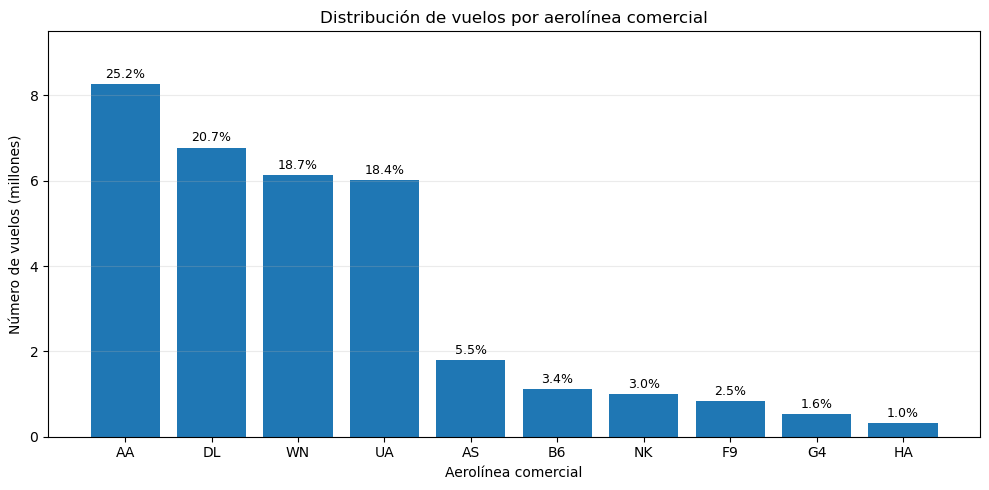

In [42]:
import matplotlib.pyplot as plt


carrier_plot_df = (
    categorical_frequency_tables[
        "MKT_UNIQUE_CARRIER"
    ]
    .copy()
)


plt.figure(
    figsize=(10, 5)
)


bars = plt.bar(
    carrier_plot_df["CATEGORY"],
    carrier_plot_df["COUNT"] / 1_000_000
)


plt.title(
    "Distribución de vuelos por aerolínea comercial"
)

plt.xlabel(
    "Aerolínea comercial"
)

plt.ylabel(
    "Número de vuelos (millones)"
)


for bar, percentage in zip(
    bars,
    carrier_plot_df["PERCENTAGE"]
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height()
        + 0.08,

        f"{percentage:.1f}%",

        ha="center",
        va="bottom",
        fontsize=9
    )


plt.ylim(
    0,
    carrier_plot_df["COUNT"].max()
    / 1_000_000
    * 1.15
)


plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.show()

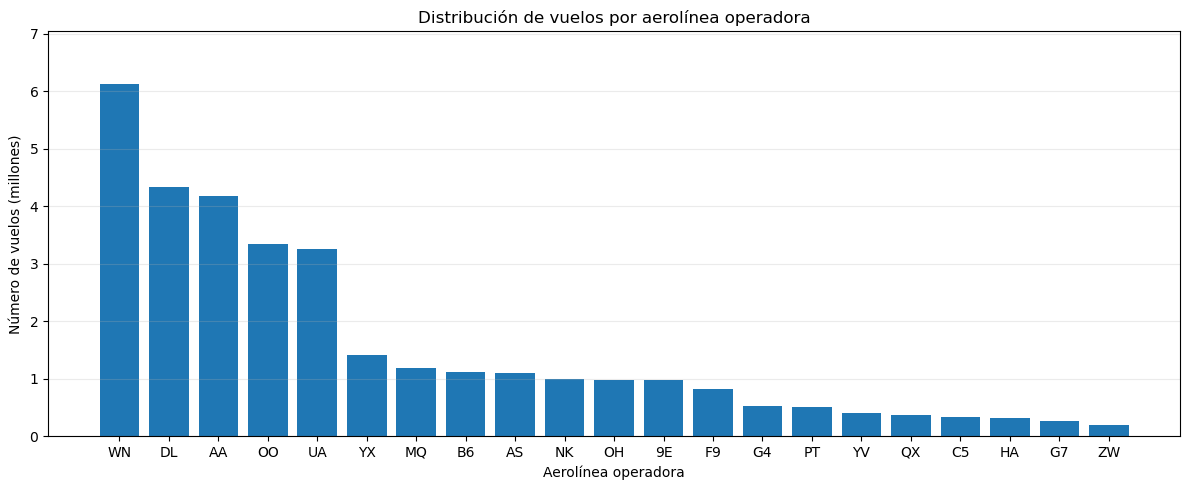

In [43]:
operator_plot_df = (
    categorical_frequency_tables[
        "OP_UNIQUE_CARRIER"
    ]
    .copy()
)


plt.figure(
    figsize=(12, 5)
)


bars = plt.bar(
    operator_plot_df["CATEGORY"],
    operator_plot_df["COUNT"] / 1_000_000
)


plt.title(
    "Distribución de vuelos por aerolínea operadora"
)

plt.xlabel(
    "Aerolínea operadora"
)

plt.ylabel(
    "Número de vuelos (millones)"
)


plt.ylim(
    0,
    operator_plot_df["COUNT"].max()
    / 1_000_000
    * 1.15
)


plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.show()

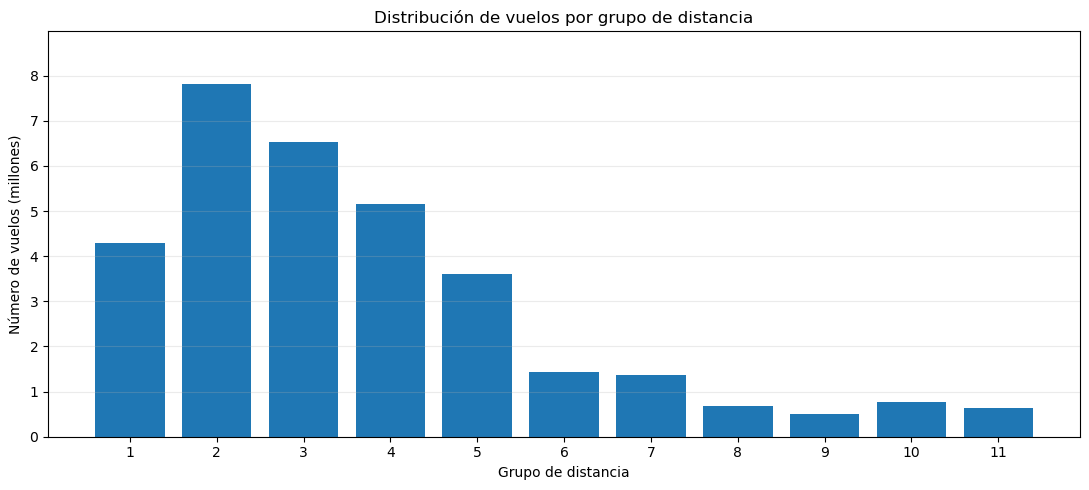

In [44]:
distance_plot_df = (
    categorical_frequency_tables[
        "DISTANCE_GROUP"
    ]
    .sort_values(
        "CATEGORY"
    )
    .reset_index(
        drop=True
    )
)


plt.figure(
    figsize=(11, 5)
)


bars = plt.bar(
    distance_plot_df["CATEGORY"].astype(str),
    distance_plot_df["COUNT"] / 1_000_000
)


plt.title(
    "Distribución de vuelos por grupo de distancia"
)

plt.xlabel(
    "Grupo de distancia"
)

plt.ylabel(
    "Número de vuelos (millones)"
)


plt.ylim(
    0,
    distance_plot_df["COUNT"].max()
    / 1_000_000
    * 1.15
)


plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.show()

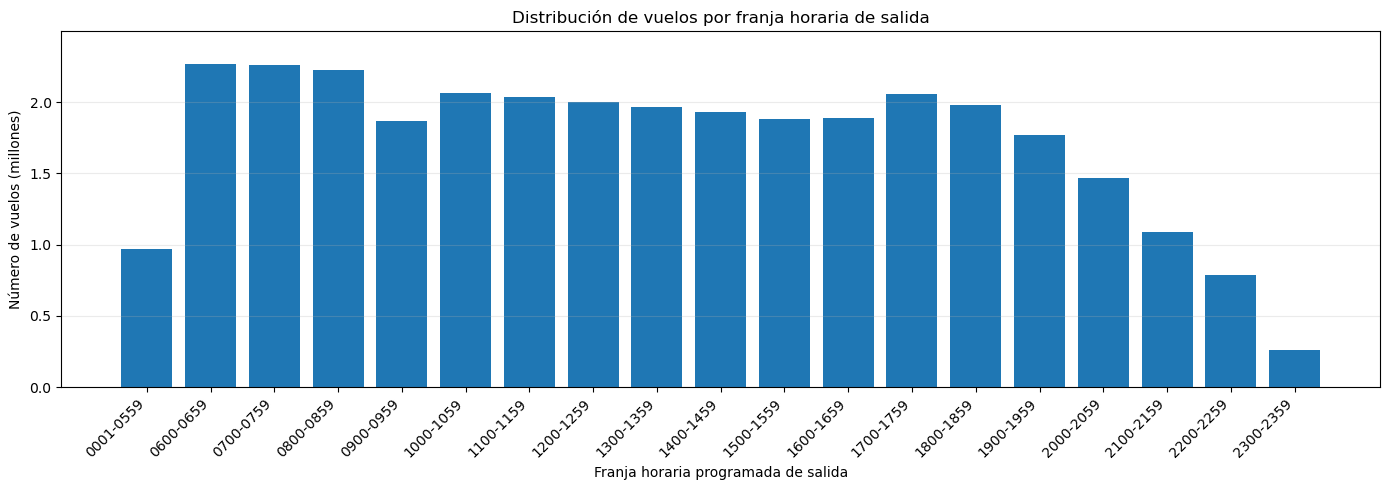

In [45]:
departure_plot_df = (
    categorical_frequency_tables[
        "DEP_TIME_BLK"
    ]
    .sort_values(
        "CATEGORY"
    )
    .reset_index(
        drop=True
    )
)


plt.figure(
    figsize=(14, 5)
)


plt.bar(
    departure_plot_df["CATEGORY"],
    departure_plot_df["COUNT"] / 1_000_000
)


plt.title(
    "Distribución de vuelos por franja horaria de salida"
)

plt.xlabel(
    "Franja horaria programada de salida"
)

plt.ylabel(
    "Número de vuelos (millones)"
)


plt.xticks(
    rotation=45,
    ha="right"
)


plt.ylim(
    0,
    departure_plot_df["COUNT"].max()
    / 1_000_000
    * 1.10
)


plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.show()

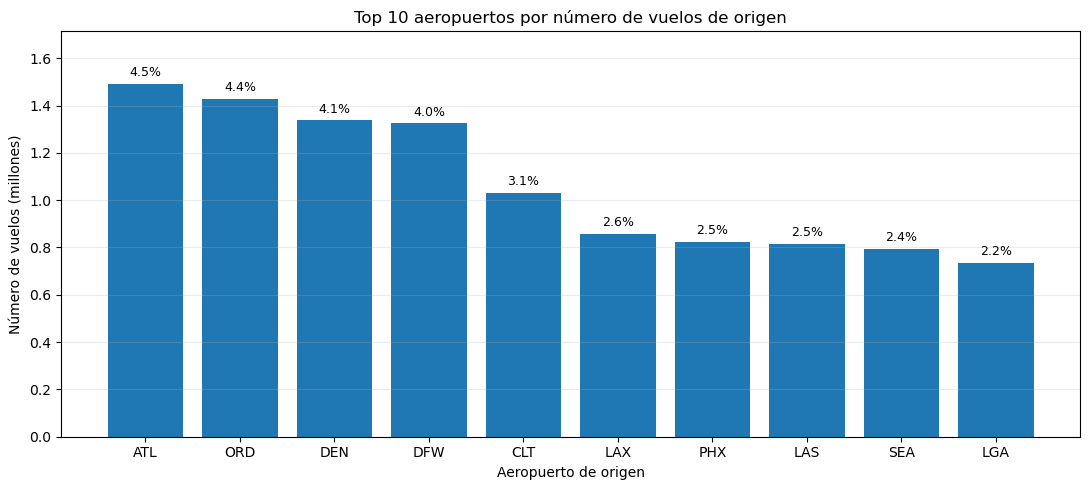

In [46]:
origin_plot_df = (
    categorical_frequency_tables[
        "ORIGIN"
    ]
    .head(10)
    .copy()
)


plt.figure(
    figsize=(11, 5)
)


bars = plt.bar(
    origin_plot_df["CATEGORY"],
    origin_plot_df["COUNT"] / 1_000_000
)


plt.title(
    "Top 10 aeropuertos por número de vuelos de origen"
)

plt.xlabel(
    "Aeropuerto de origen"
)

plt.ylabel(
    "Número de vuelos (millones)"
)


for bar, percentage in zip(
    bars,
    origin_plot_df["PERCENTAGE"]
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height()
        + 0.02,

        f"{percentage:.1f}%",

        ha="center",
        va="bottom",
        fontsize=9
    )


plt.ylim(
    0,
    origin_plot_df["COUNT"].max()
    / 1_000_000
    * 1.15
)


plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.show()

### Interpretación

Las representaciones gráficas confirman la existencia de estructuras de distribución diferentes entre las variables cualitativas.

La aerolínea comercial presenta una elevada concentración: AA, DL, WN y UA acumulan aproximadamente el 83 % de los vuelos. La distribución por aerolínea operadora es más dispersa, mostrando una mayor diversidad de compañías responsables de la operación efectiva.

La distribución por grupo de distancia presenta su máximo en el grupo 2 y una reducción general del volumen conforme se avanza hacia grupos superiores. Los vuelos se concentran principalmente en los grupos inferiores y medios, aunque la disminución no es estrictamente monótona.

La franja horaria de salida muestra una actividad elevada desde primeras horas de la mañana hasta el final de la tarde, seguida de una disminución progresiva durante la noche. Debe considerarse que la categoría 0001-0559 comprende un intervalo temporal más amplio que el resto de las franjas.

Finalmente, los aeropuertos presentan una distribución considerablemente más dispersa. ATL constituye el aeropuerto de origen más frecuente, pero representa únicamente alrededor del 4,5 % de los vuelos, mientras que los cinco aeropuertos principales concentran aproximadamente el 20 %.

Estas visualizaciones complementan los análisis de frecuencia y concentración realizados previamente y permiten identificar diferencias en la estructura categórica del conjunto de datos que deberán considerarse posteriormente durante el preprocesamiento y modelado.

### 6.6 Conclusiones del análisis univariante cualitativo

El análisis univariante de las variables cualitativas permite identificar diferencias importantes en términos de completitud, cardinalidad, frecuencia y concentración.

En relación con la completitud, la mayoría de las variables categóricas no presentan valores ausentes. `TAIL_NUM` contiene únicamente un 0,36 % de valores ausentes, mientras que `CANCELLATION_CODE` presenta un 98,23 %. Este último porcentaje no debe interpretarse directamente como un problema de calidad, ya que el código de cancelación únicamente resulta aplicable a los vuelos cancelados y, por tanto, su ausencia en el resto de los registros es estructural.

La cardinalidad varía considerablemente entre variables. `TAIL_NUM` presenta 7.492 categorías diferentes, seguida de las variables relacionadas con aeropuertos y ciudades, que contienen varios cientos de categorías. En el extremo contrario se encuentran `CANCELLATION_CODE`, `MKT_UNIQUE_CARRIER` y `DISTANCE_GROUP`, con una cardinalidad considerablemente menor.

La cardinalidad debe analizarse conjuntamente con la concentración. `TAIL_NUM`, además de presentar una elevada cardinalidad, muestra una distribución extremadamente dispersa: las cinco matrículas más frecuentes representan únicamente el 0,18 % de las observaciones válidas. Por el contrario, las cinco aerolíneas comerciales más frecuentes concentran el 88,43 % de los vuelos.

También se observan diferencias entre la aerolínea comercial y la operadora. `MKT_UNIQUE_CARRIER` presenta una mayor concentración que `OP_UNIQUE_CARRIER`, lo que evidencia que la operación efectiva de los vuelos se distribuye entre un conjunto más amplio de compañías.

Las variables geográficas presentan una reducción progresiva de la concentración conforme aumenta su granularidad. Los cinco estados más frecuentes representan aproximadamente el 40 % de los registros, mientras que las cinco principales ciudades concentran alrededor del 22 % y los cinco aeropuertos principales aproximadamente el 20 %. Las distribuciones agregadas de origen y destino son, además, prácticamente equivalentes.

La distribución de `DISTANCE_GROUP` muestra una mayor presencia de vuelos pertenecientes a los grupos inferiores y medios de distancia. Los cinco grupos más frecuentes concentran aproximadamente el 83,57 % de los registros.

Por último, las franjas horarias presentan una distribución relativamente dispersa a lo largo del día. En las salidas se observa un elevado volumen desde primeras horas de la mañana hasta el final de la tarde, seguido de una reducción durante las horas nocturnas.

En conjunto, el análisis muestra que las variables cualitativas presentan estructuras muy diferentes. Estas características deberán considerarse posteriormente durante la selección de variables y el diseño de las estrategias de codificación para el modelado predictivo.

## 7. Análisis bivariante respecto a la variable objetivo

El análisis bivariante estudia la relación entre las variables explicativas y la variable objetivo `ARR_DEL15`, que identifica los vuelos que llegan con un retraso significativo de al menos 15 minutos.

A diferencia del análisis univariante, donde cada variable se estudia de manera independiente, en este bloque se analiza cómo cambia la frecuencia o probabilidad de retraso en función de características temporales, operativas, geográficas y asociadas al vuelo.

Debido al elevado volumen del conjunto de datos, los archivos Parquet se recorren una única vez al inicio del bloque. Durante esta lectura se calculan y almacenan únicamente los agregados necesarios para los análisis posteriores, evitando mantener el histórico completo en memoria.

In [47]:
BIVARIATE_COLUMNS = [
    # Variable objetivo
    "ARR_DEL15",

    # Estado del vuelo
    "CANCELLED",
    "DIVERTED",

    # Variables temporales
    "YEAR",
    "MONTH",
    "DAY_OF_WEEK",

    # Operación
    "DEP_TIME_BLK",
    "MKT_UNIQUE_CARRIER",
    "OP_UNIQUE_CARRIER",

    # Distancia
    "DISTANCE",
    "DISTANCE_GROUP",

    # Geografía
    "ORIGIN",
    "DEST",

    # Variables numéricas
    "DEP_DELAY",
    "TAXI_OUT",
    "TAXI_IN",
    "CRS_ELAPSED_TIME",
    "ACTUAL_ELAPSED_TIME",
    "AIR_TIME"
]

In [48]:
from collections import defaultdict


# Validación de la target
target_validation = defaultdict(int)


# Distribución global
target_counts = defaultdict(int)


# Evolución temporal
year_delay_stats = defaultdict(
    lambda: [0, 0]
)

month_delay_stats = defaultdict(
    lambda: [0, 0]
)

weekday_delay_stats = defaultdict(
    lambda: [0, 0]
)


# Variables categóricas
dep_time_delay_stats = defaultdict(
    lambda: [0, 0]
)

distance_group_delay_stats = defaultdict(
    lambda: [0, 0]
)

market_carrier_delay_stats = defaultdict(
    lambda: [0, 0]
)

operating_carrier_delay_stats = defaultdict(
    lambda: [0, 0]
)

origin_delay_stats = defaultdict(
    lambda: [0, 0]
)

dest_delay_stats = defaultdict(
    lambda: [0, 0]
)

In [49]:
for i, file in enumerate(
    parquet_files,
    start=1
):

    df = pd.read_parquet(
        file,
        columns=BIVARIATE_COLUMNS
    )


    # ---------------------------------
    # 1. Validación de ARR_DEL15
    # ---------------------------------

    target_missing = (
        df["ARR_DEL15"].isna()
    )

    cancelled = (
        df["CANCELLED"] == 1
    )

    diverted = (
        df["DIVERTED"] == 1
    )


    target_validation[
        "target_missing"
    ] += target_missing.sum()

    target_validation[
        "target_missing_cancelled"
    ] += (
        target_missing
        & cancelled
    ).sum()

    target_validation[
        "target_missing_diverted"
    ] += (
        target_missing
        & diverted
    ).sum()

    target_validation[
        "target_missing_cancelled_or_diverted"
    ] += (
        target_missing
        & (
            cancelled
            | diverted
        )
    ).sum()

    target_validation[
        "target_missing_neither"
    ] += (
        target_missing
        & ~cancelled
        & ~diverted
    ).sum()


    # ---------------------------------
    # 2. Solo vuelos con target válida
    # ---------------------------------

    valid_df = df[
        df["ARR_DEL15"].notna()
    ]


    # Distribución global

    value_counts = (
        valid_df[
            "ARR_DEL15"
        ]
        .value_counts()
    )

    for value, count in (
        value_counts.items()
    ):

        target_counts[
            value
        ] += count


    # ---------------------------------
    # Función auxiliar local
    # ---------------------------------

    def accumulate_delay(
        dataframe,
        group_column,
        accumulator
    ):

        grouped = (
            dataframe
            .groupby(
                group_column,
                observed=True
            )["ARR_DEL15"]
            .agg(
                ["count", "sum"]
            )
        )

        for category, row in (
            grouped.iterrows()
        ):

            accumulator[
                category
            ][0] += row["count"]

            accumulator[
                category
            ][1] += row["sum"]


    # Año
    accumulate_delay(
        valid_df,
        "YEAR",
        year_delay_stats
    )


    # Mes
    valid_df = valid_df.copy()

    valid_df[
        "YEAR_MONTH"
    ] = list(
        zip(
            valid_df["YEAR"],
            valid_df["MONTH"]
        )
    )

    accumulate_delay(
        valid_df,
        "YEAR_MONTH",
        month_delay_stats
    )


    # Día de la semana
    accumulate_delay(
        valid_df,
        "DAY_OF_WEEK",
        weekday_delay_stats
    )


    # Franja horaria
    accumulate_delay(
        valid_df,
        "DEP_TIME_BLK",
        dep_time_delay_stats
    )


    # Grupo de distancia
    accumulate_delay(
        valid_df,
        "DISTANCE_GROUP",
        distance_group_delay_stats
    )


    # Aerolíneas
    accumulate_delay(
        valid_df,
        "MKT_UNIQUE_CARRIER",
        market_carrier_delay_stats
    )

    accumulate_delay(
        valid_df,
        "OP_UNIQUE_CARRIER",
        operating_carrier_delay_stats
    )


    # Aeropuertos
    accumulate_delay(
        valid_df,
        "ORIGIN",
        origin_delay_stats
    )

    accumulate_delay(
        valid_df,
        "DEST",
        dest_delay_stats
    )


    if (
        i % 50 == 0
        or i == len(parquet_files)
    ):

        print(
            f"Procesados "
            f"{i}/"
            f"{len(parquet_files)} "
            f"archivos"
        )


    del df
    del valid_df

Procesados 50/354 archivos
Procesados 100/354 archivos
Procesados 150/354 archivos
Procesados 200/354 archivos
Procesados 250/354 archivos
Procesados 300/354 archivos
Procesados 350/354 archivos
Procesados 354/354 archivos


### 7.2 Validación de la variable objetivo

Antes de estudiar los factores asociados al retraso se analiza la disponibilidad de la variable objetivo `ARR_DEL15`.

Los valores ausentes de esta variable no deben interpretarse automáticamente como vuelos sin retraso. Determinadas situaciones operativas, principalmente cancelaciones y desvíos, pueden impedir que exista una observación válida del retraso de llegada.

Por este motivo se estudia la relación entre la ausencia de `ARR_DEL15` y los indicadores `CANCELLED` y `DIVERTED`.

In [50]:
total_target_missing = (
    target_validation[
        "target_missing"
    ]
)


target_validation_df = pd.DataFrame({
    "SITUATION": [
        "ARR_DEL15 ausente",
        "Ausente y cancelado",
        "Ausente y desviado",
        "Ausente y cancelado o desviado",
        "Ausente, no cancelado ni desviado"
    ],

    "COUNT": [
        total_target_missing,

        target_validation[
            "target_missing_cancelled"
        ],

        target_validation[
            "target_missing_diverted"
        ],

        target_validation[
            "target_missing_cancelled_or_diverted"
        ],

        target_validation[
            "target_missing_neither"
        ]
    ]
})


target_validation_df[
    "PERCENTAGE_OF_MISSING"
] = (
    target_validation_df["COUNT"]
    / total_target_missing
    * 100
).round(3)


target_validation_df

,SITUATION,COUNT,PERCENTAGE_OF_MISSING
0,ARR_DEL15 ausente,662088,100.000
1,Ausente y cancelado,579552,87.534
2,Ausente y desviado,82533,12.466
3,Ausente y cancelado o desviado,662085,100.000
4,"Ausente, no cancelado ni desviado",3,0.000


In [51]:
valid_target_count = int(
    sum(
        target_counts.values()
    )
)


total_flights = (
    valid_target_count
    + total_target_missing
)


target_availability_df = pd.DataFrame({
    "TARGET_STATUS": [
        "ARR_DEL15 válida",
        "ARR_DEL15 ausente"
    ],

    "COUNT": [
        valid_target_count,
        total_target_missing
    ]
})


target_availability_df[
    "PERCENTAGE"
] = (
    target_availability_df["COUNT"]
    / total_flights
    * 100
).round(3)


target_availability_df

,TARGET_STATUS,COUNT,PERCENTAGE
0,ARR_DEL15 válida,32099041,97.979
1,ARR_DEL15 ausente,662088,2.021


#### Interpretación

La variable objetivo `ARR_DEL15` se encuentra disponible para 32.099.041 vuelos, equivalentes al 97,979 % del conjunto de datos. Los 662.088 registros restantes representan únicamente el 2,021 % del histórico.

El análisis de estos valores ausentes muestra un patrón claramente estructurado. El 87,534 % corresponde a vuelos cancelados y el 12,466 % a vuelos desviados. En conjunto, 662.085 de los 662.088 valores ausentes de `ARR_DEL15` pertenecen a alguna de estas dos situaciones operativas.

Únicamente tres registros presentan `ARR_DEL15` ausente sin estar identificados como cancelados o desviados, lo que constituye una proporción residual respecto al tamaño total del conjunto de datos.

Estos resultados indican que la ausencia de la variable objetivo no constituye principalmente un problema general de calidad de los datos, sino que está asociada a situaciones operativas en las que el retraso de llegada no puede determinarse de la misma forma que en un vuelo completado normalmente.

Por este motivo, los análisis posteriores sobre retraso se realizarán exclusivamente sobre los 32.099.041 registros que disponen de un valor válido de `ARR_DEL15`. Los valores ausentes no serán imputados como vuelos sin retraso, ya que dicha decisión introduciría errores de etiquetado y reduciría artificialmente la tasa observada de retrasos.

### 7.3 Distribución y balance de la variable objetivo

Una vez definida la población de vuelos con una variable objetivo válida, se analiza la distribución de `ARR_DEL15`.

Este análisis permite determinar la proporción de vuelos con y sin retraso significativo y evaluar el grado de balance entre las dos clases de la variable objetivo.

El balance de clases resulta especialmente relevante para el posterior desarrollo de modelos de clasificación, ya que una distribución muy desigual puede afectar tanto al proceso de aprendizaje como a la interpretación de determinadas métricas de evaluación.

In [52]:
target_distribution_df = pd.DataFrame({
    "ARR_DEL15": [
        0,
        1
    ],

    "STATUS": [
        "Sin retraso significativo",
        "Con retraso significativo"
    ],

    "COUNT": [
        int(target_counts.get(0, 0)),
        int(target_counts.get(1, 0))
    ]
})


target_distribution_df[
    "PERCENTAGE"
] = (
    target_distribution_df["COUNT"]
    / target_distribution_df["COUNT"].sum()
    * 100
).round(2)


target_distribution_df

,ARR_DEL15,STATUS,COUNT,PERCENTAGE
0,0,Sin retraso significativo,25334934,78.93
1,1,Con retraso significativo,6764107,21.07


In [53]:
class_0 = int(
    target_counts.get(
        0,
        0
    )
)

class_1 = int(
    target_counts.get(
        1,
        0
    )
)


majority_count = max(
    class_0,
    class_1
)

minority_count = min(
    class_0,
    class_1
)


imbalance_ratio = (
    majority_count
    / minority_count
)


print(
    f"Clase 0 : {class_0:,}"
)

print(
    f"Clase 1 : {class_1:,}"
)

print(
    f"Ratio clase mayoritaria/minoritaria: "
    f"{imbalance_ratio:.2f}:1"
)

Clase 0 : 25,334,934
Clase 1 : 6,764,107
Ratio clase mayoritaria/minoritaria: 3.75:1


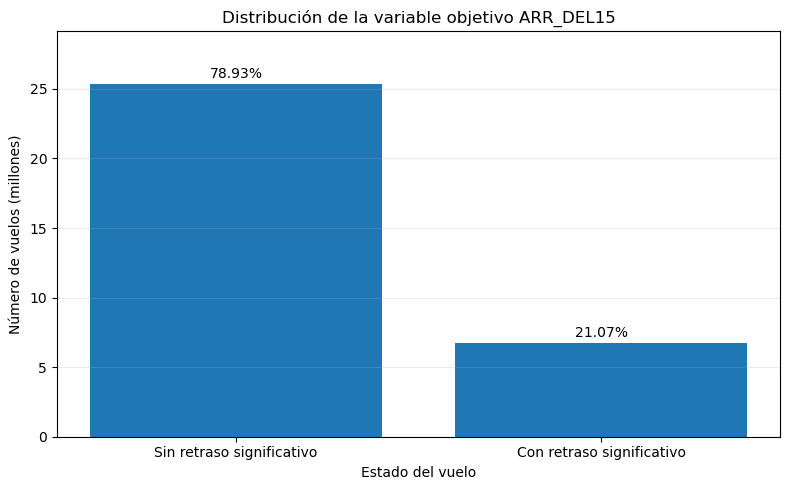

In [54]:
plt.figure(
    figsize=(8, 5)
)


bars = plt.bar(
    target_distribution_df[
        "STATUS"
    ],

    target_distribution_df[
        "COUNT"
    ] / 1_000_000
)


plt.title(
    "Distribución de la variable objetivo ARR_DEL15"
)

plt.xlabel(
    "Estado del vuelo"
)

plt.ylabel(
    "Número de vuelos (millones)"
)


for bar, percentage in zip(
    bars,
    target_distribution_df[
        "PERCENTAGE"
    ]
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height()
        + 0.2,

        f"{percentage:.2f}%",

        ha="center",
        va="bottom"
    )


plt.ylim(
    0,
    target_distribution_df[
        "COUNT"
    ].max()
    / 1_000_000
    * 1.15
)


plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.show()

#### Interpretación

De los 32.099.041 vuelos con un valor válido de `ARR_DEL15`, 25.334.934 (78,93 %) no presentan retraso significativo de llegada, mientras que 6.764.107 (21,07 %) registran un retraso igual o superior a 15 minutos.

La prevalencia de la clase positiva es, por tanto, del 21,07 %. La relación entre la clase mayoritaria y la minoritaria es aproximadamente 3,75:1, lo que evidencia un desbalance moderado de la variable objetivo.

Este resultado deberá considerarse posteriormente durante el desarrollo y evaluación de los modelos predictivos. En particular, la exactitud no deberá utilizarse de forma aislada, ya que un clasificador que asignara sistemáticamente todos los vuelos a la clase mayoritaria alcanzaría por sí solo una accuracy del 78,93 % sin identificar ningún retraso.

En las siguientes etapas del análisis bivariante, la tasa global de retraso del 21,07 % se utilizará como referencia para evaluar si determinadas categorías o características del vuelo presentan una frecuencia de retrasos superior o inferior al comportamiento general del conjunto de datos.

### 7.4 Evolución temporal de la tasa de retraso

Se analiza la evolución temporal de la variable objetivo con el propósito de determinar si la frecuencia de retrasos permanece estable durante el periodo estudiado.

El análisis se realiza inicialmente a nivel anual y posteriormente a nivel mensual. La tasa de retraso se calcula exclusivamente sobre los vuelos con un valor válido de `ARR_DEL15`.

La tasa global de retraso del 21,07 % obtenida previamente se utiliza como referencia para facilitar la comparación temporal.

In [55]:
year_delay_df = pd.DataFrame(
    [
        {
            "YEAR": year,
            "VALID_FLIGHTS": values[0],
            "DELAYED_FLIGHTS": values[1]
        }

        for year, values
        in year_delay_stats.items()
    ]
)


year_delay_df = (
    year_delay_df
    .sort_values("YEAR")
    .reset_index(drop=True)
)


year_delay_df[
    "NOT_DELAYED_FLIGHTS"
] = (
    year_delay_df["VALID_FLIGHTS"]
    - year_delay_df["DELAYED_FLIGHTS"]
)


year_delay_df[
    "DELAY_RATE"
] = (
    year_delay_df["DELAYED_FLIGHTS"]
    / year_delay_df["VALID_FLIGHTS"]
    * 100
).round(2)


year_delay_df

,YEAR,VALID_FLIGHTS,DELAYED_FLIGHTS,NOT_DELAYED_FLIGHTS,DELAY_RATE
0,2022,6806805,1426304,5380501,20.95
1,2023,7167044,1464539,5702505,20.43
2,2024,7425249,1531086,5894163,20.62
3,2025,7597495,1685334,5912161,22.18
4,2026,3102448,656844,2445604,21.17


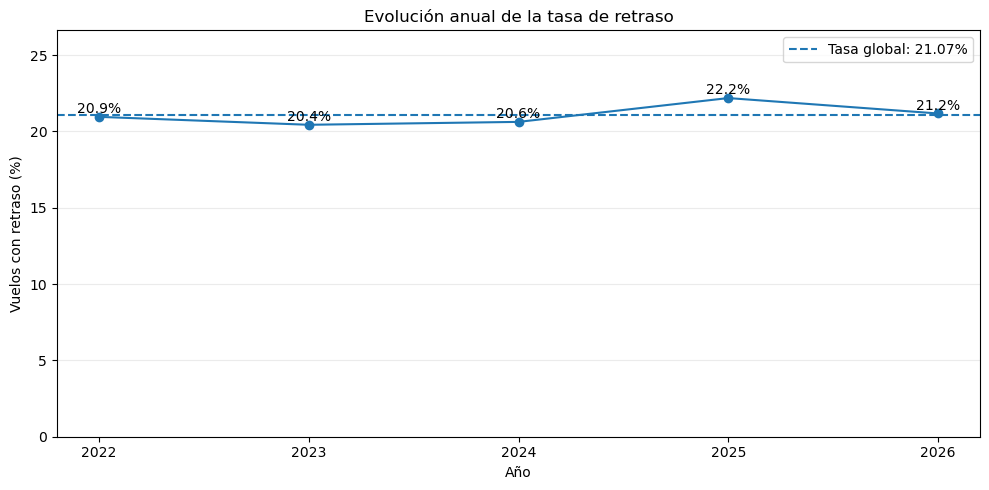

In [56]:
global_delay_rate = (
    target_counts.get(1, 0)
    / sum(target_counts.values())
    * 100
)


plt.figure(
    figsize=(10, 5)
)


plt.plot(
    year_delay_df["YEAR"],
    year_delay_df["DELAY_RATE"],
    marker="o"
)


plt.axhline(
    global_delay_rate,
    linestyle="--",
    label=(
        f"Tasa global: "
        f"{global_delay_rate:.2f}%"
    )
)


for x, y in zip(
    year_delay_df["YEAR"],
    year_delay_df["DELAY_RATE"]
):

    plt.text(
        x,
        y + 0.25,
        f"{y:.1f}%",
        ha="center"
    )


plt.title(
    "Evolución anual de la tasa de retraso"
)

plt.xlabel(
    "Año"
)

plt.ylabel(
    "Vuelos con retraso (%)"
)


plt.xticks(
    year_delay_df["YEAR"]
)


plt.ylim(
    0,
    max(
        year_delay_df["DELAY_RATE"].max(),
        global_delay_rate
    ) * 1.20
)


plt.grid(
    axis="y",
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()

In [57]:
month_delay_df = pd.DataFrame(
    [
        {
            "YEAR": period[0],
            "MONTH": period[1],
            "VALID_FLIGHTS": values[0],
            "DELAYED_FLIGHTS": values[1]
        }

        for period, values
        in month_delay_stats.items()
    ]
)


month_delay_df[
    "DELAY_RATE"
] = (
    month_delay_df["DELAYED_FLIGHTS"]
    / month_delay_df["VALID_FLIGHTS"]
    * 100
)


month_delay_df[
    "DATE"
] = pd.to_datetime(
    dict(
        year=month_delay_df["YEAR"],
        month=month_delay_df["MONTH"],
        day=1
    )
)


month_delay_df = (
    month_delay_df
    .sort_values("DATE")
    .reset_index(drop=True)
)


month_delay_df[
    "DELAY_RATE"
] = (
    month_delay_df["DELAY_RATE"]
    .round(2)
)


month_delay_df.head()

,YEAR,MONTH,VALID_FLIGHTS,DELAYED_FLIGHTS,DELAY_RATE,DATE
0,2022,1,526893,102514,19.46,2022-01-01
1,2022,2,495651,97316,19.63,2022-02-01
2,2022,3,579953,124328,21.44,2022-03-01
3,2022,4,565501,124689,22.05,2022-04-01
4,2022,5,589376,123950,21.03,2022-05-01


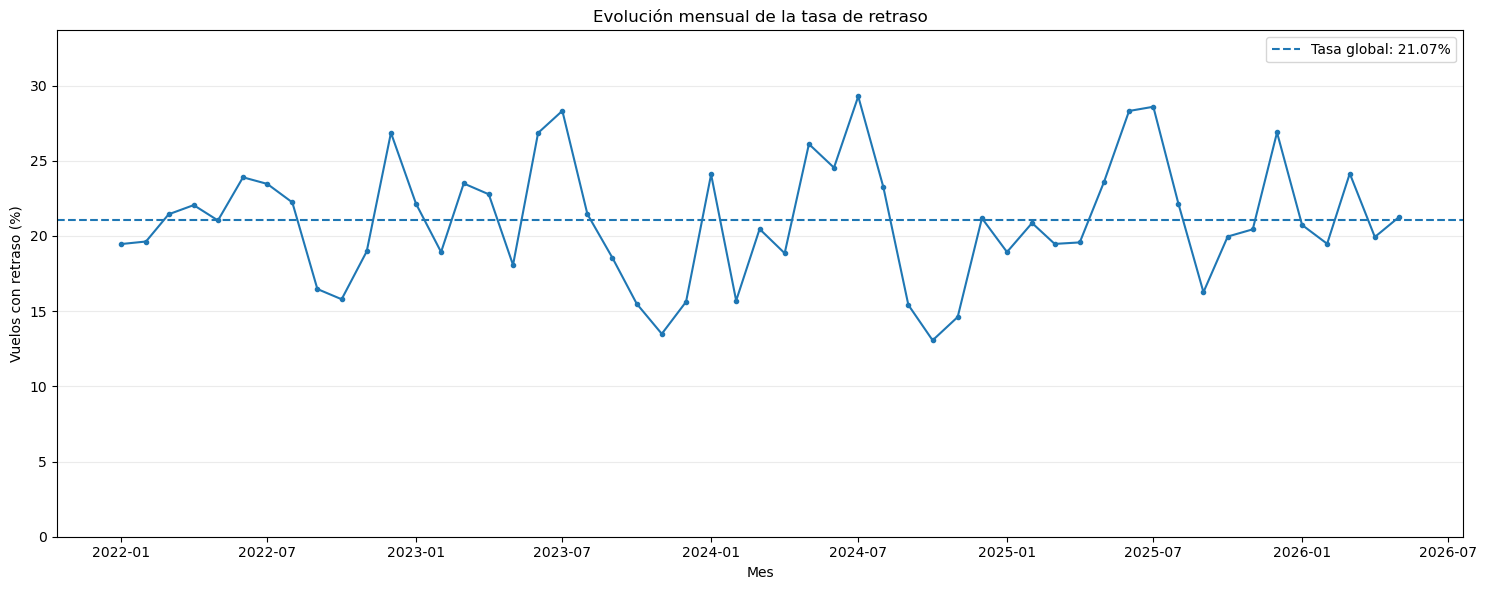

In [58]:
plt.figure(
    figsize=(15, 6)
)


plt.plot(
    month_delay_df["DATE"],
    month_delay_df["DELAY_RATE"],
    marker="o",
    markersize=3
)


plt.axhline(
    global_delay_rate,
    linestyle="--",
    label=(
        f"Tasa global: "
        f"{global_delay_rate:.2f}%"
    )
)


plt.title(
    "Evolución mensual de la tasa de retraso"
)

plt.xlabel(
    "Mes"
)

plt.ylabel(
    "Vuelos con retraso (%)"
)


plt.ylim(
    0,
    max(
        month_delay_df["DELAY_RATE"].max(),
        global_delay_rate
    ) * 1.15
)


plt.grid(
    axis="y",
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()

### 7.5 Retraso según el día de la semana

Se analiza la relación entre el día de la semana y la variable objetivo `ARR_DEL15`.

Para cada día se calcula el número de vuelos válidos, el número de vuelos con retraso significativo y la tasa de retraso correspondiente.

La comparación se realiza utilizando la tasa global de retraso del 21,07 % como referencia, con el objetivo de identificar días cuya incidencia de retrasos se encuentre por encima o por debajo del comportamiento general del conjunto de datos.

In [59]:
weekday_names = {
    1: "Lunes",
    2: "Martes",
    3: "Miércoles",
    4: "Jueves",
    5: "Viernes",
    6: "Sábado",
    7: "Domingo"
}


weekday_delay_df = pd.DataFrame(
    [
        {
            "DAY_OF_WEEK": day,
            "VALID_FLIGHTS": values[0],
            "DELAYED_FLIGHTS": values[1]
        }

        for day, values
        in weekday_delay_stats.items()
    ]
)


weekday_delay_df = (
    weekday_delay_df
    .sort_values(
        "DAY_OF_WEEK"
    )
    .reset_index(
        drop=True
    )
)


weekday_delay_df[
    "DAY_NAME"
] = (
    weekday_delay_df[
        "DAY_OF_WEEK"
    ]
    .map(
        weekday_names
    )
)


weekday_delay_df[
    "NOT_DELAYED_FLIGHTS"
] = (
    weekday_delay_df["VALID_FLIGHTS"]
    - weekday_delay_df["DELAYED_FLIGHTS"]
)


weekday_delay_df[
    "DELAY_RATE"
] = (
    weekday_delay_df["DELAYED_FLIGHTS"]
    / weekday_delay_df["VALID_FLIGHTS"]
    * 100
).round(2)


weekday_delay_df

,DAY_OF_WEEK,VALID_FLIGHTS,DELAYED_FLIGHTS,DAY_NAME,NOT_DELAYED_FLIGHTS,DELAY_RATE
0,1,4775536,1023849,Lunes,3751687,21.44
1,2,4413350,787465,Martes,3625885,17.84
2,3,4468820,838955,Miércoles,3629865,18.77
3,4,4757014,1046155,Jueves,3710859,21.99
4,5,4788716,1105988,Viernes,3682728,23.10
5,6,4171689,853486,Sábado,3318203,20.46
6,7,4723916,1108209,Domingo,3615707,23.46


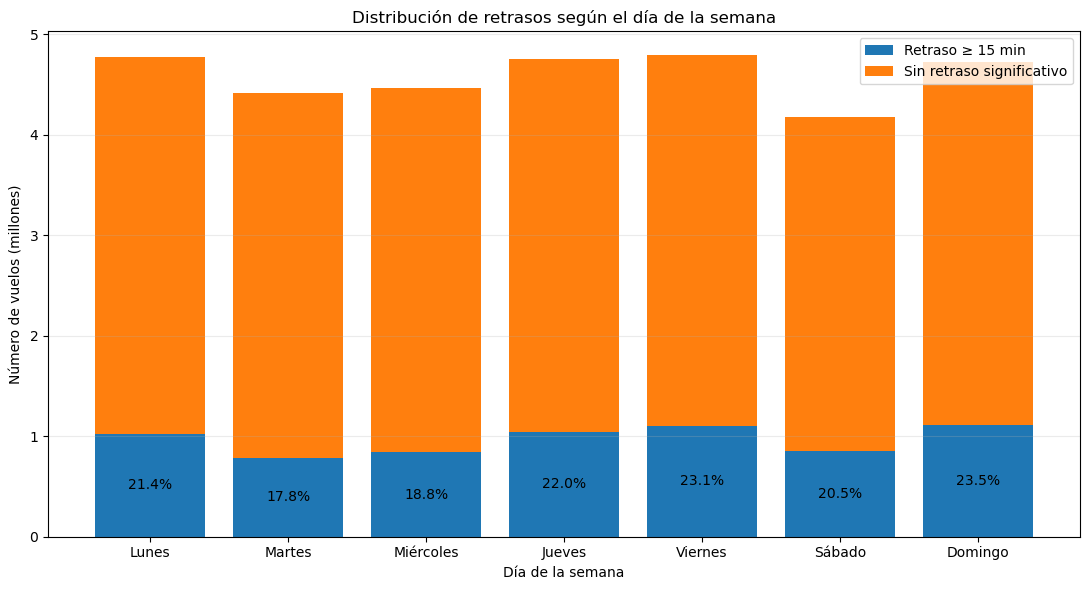

In [61]:
# Conversión a millones para que la escala sea legible
weekday_delay_df["DELAYED_M"] = (
    weekday_delay_df["DELAYED_FLIGHTS"] / 1_000_000
)

weekday_delay_df["NOT_DELAYED_M"] = (
    weekday_delay_df["NOT_DELAYED_FLIGHTS"] / 1_000_000
)


plt.figure(
    figsize=(11, 6)
)


# Vuelos con retraso
bars_delay = plt.bar(
    weekday_delay_df["DAY_NAME"],
    weekday_delay_df["DELAYED_M"],
    label="Retraso ≥ 15 min"
)


# Vuelos sin retraso
bars_no_delay = plt.bar(
    weekday_delay_df["DAY_NAME"],
    weekday_delay_df["NOT_DELAYED_M"],
    bottom=weekday_delay_df["DELAYED_M"],
    label="Sin retraso significativo"
)


# Porcentaje de retraso dentro de cada día
for bar, rate in zip(
    bars_delay,
    weekday_delay_df["DELAY_RATE"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f"{rate:.1f}%",
        ha="center",
        va="center"
    )


plt.title(
    "Distribución de retrasos según el día de la semana"
)

plt.xlabel(
    "Día de la semana"
)

plt.ylabel(
    "Número de vuelos (millones)"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()

#### Interpretación

La incidencia del retraso significativo presenta diferencias según el día de la semana. La tasa global del conjunto analizado es del 21,07 %, mientras que las tasas diarias oscilan entre el 17,84 % del martes y el 23,46 % del domingo, una diferencia de 5,62 puntos porcentuales.

Los domingos y viernes presentan las tasas más elevadas, con un 23,46 % y un 23,10 %, respectivamente. Además, ambos días mantienen un volumen elevado de operaciones y superan los 1,1 millones de vuelos con retraso durante el periodo analizado.

En sentido contrario, martes y miércoles presentan las menores tasas de retraso, con un 17,84 % y un 18,77 %, situándose claramente por debajo de la tasa global.

La tasa observada los domingos es aproximadamente 1,32 veces la registrada los martes. Esta diferencia evidencia una asociación descriptiva entre el día de la semana y la probabilidad de retraso, aunque no permite establecer una relación causal.

La representación conjunta del volumen absoluto y de la tasa de retraso permite distinguir entre el número de incidencias y su frecuencia relativa, evitando atribuir una mayor incidencia únicamente a los días con mayor número de operaciones.

Los resultados sugieren que el día de la semana puede aportar información relevante para la posterior construcción del modelo predictivo.

### 7.6 Retraso según la franja horaria programada de salida

Se analiza la relación entre la franja horaria programada de salida (`DEP_TIME_BLK`) y la variable objetivo `ARR_DEL15`.

Para cada franja horaria se calcula el volumen de vuelos con información válida de la variable objetivo, el número de vuelos con y sin retraso significativo y la tasa de retraso correspondiente.

El objetivo es determinar si la incidencia del retraso presenta un patrón intradiario y si determinadas horas de salida están asociadas con una mayor frecuencia de retrasos.

In [62]:
time_delay_df = pd.DataFrame(
    [
        {
            "DEP_TIME_BLK": time_block,
            "VALID_FLIGHTS": values[0],
            "DELAYED_FLIGHTS": values[1]
        }

        for time_block, values
        in dep_time_delay_stats.items()
    ]
)


# Orden cronológico de las franjas
time_order = [
    "0001-0559",
    "0600-0659",
    "0700-0759",
    "0800-0859",
    "0900-0959",
    "1000-1059",
    "1100-1159",
    "1200-1259",
    "1300-1359",
    "1400-1459",
    "1500-1559",
    "1600-1659",
    "1700-1759",
    "1800-1859",
    "1900-1959",
    "2000-2059",
    "2100-2159",
    "2200-2259",
    "2300-2359"
]


time_delay_df[
    "DEP_TIME_BLK"
] = pd.Categorical(
    time_delay_df["DEP_TIME_BLK"],
    categories=time_order,
    ordered=True
)


time_delay_df = (
    time_delay_df
    .sort_values("DEP_TIME_BLK")
    .reset_index(drop=True)
)


time_delay_df[
    "NOT_DELAYED_FLIGHTS"
] = (
    time_delay_df["VALID_FLIGHTS"]
    - time_delay_df["DELAYED_FLIGHTS"]
)


time_delay_df[
    "DELAY_RATE"
] = (
    time_delay_df["DELAYED_FLIGHTS"]
    / time_delay_df["VALID_FLIGHTS"]
    * 100
).round(2)


time_delay_df

,DEP_TIME_BLK,VALID_FLIGHTS,DELAYED_FLIGHTS,NOT_DELAYED_FLIGHTS,DELAY_RATE
0,0001-0559,949089,93473,855616,9.85
1,0600-0659,2224749,226860,1997889,10.20
2,0700-0759,2223013,281022,1941991,12.64
3,0800-0859,2186950,311602,1875348,14.25
4,0900-0959,1840671,286224,1554447,15.55
5,1000-1059,2028603,338347,1690256,16.68
6,1100-1159,2005169,364036,1641133,18.15
7,1200-1259,1964763,387567,1577196,19.73
8,1300-1359,1929671,417787,1511884,21.65
9,1400-1459,1891428,449127,1442301,23.75


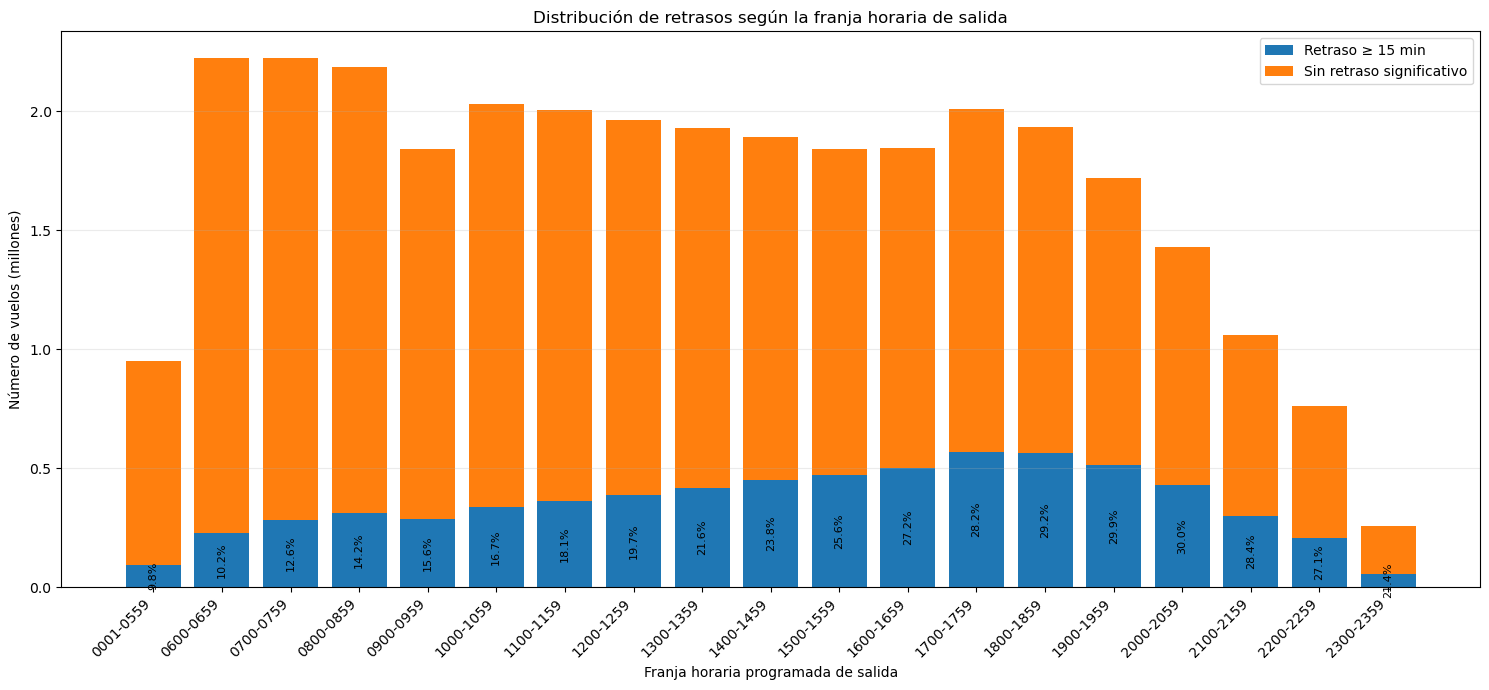

In [63]:
time_delay_df[
    "DELAYED_M"
] = (
    time_delay_df["DELAYED_FLIGHTS"]
    / 1_000_000
)


time_delay_df[
    "NOT_DELAYED_M"
] = (
    time_delay_df["NOT_DELAYED_FLIGHTS"]
    / 1_000_000
)


plt.figure(
    figsize=(15, 7)
)


bars_delay = plt.bar(
    time_delay_df["DEP_TIME_BLK"].astype(str),
    time_delay_df["DELAYED_M"],
    label="Retraso ≥ 15 min"
)


plt.bar(
    time_delay_df["DEP_TIME_BLK"].astype(str),
    time_delay_df["NOT_DELAYED_M"],
    bottom=time_delay_df["DELAYED_M"],
    label="Sin retraso significativo"
)


for bar, rate in zip(
    bars_delay,
    time_delay_df["DELAY_RATE"]
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f"{rate:.1f}%",
        ha="center",
        va="center",
        fontsize=8,
        rotation=90
    )


plt.title(
    "Distribución de retrasos según la franja horaria de salida"
)

plt.xlabel(
    "Franja horaria programada de salida"
)

plt.ylabel(
    "Número de vuelos (millones)"
)


plt.xticks(
    rotation=45,
    ha="right"
)


plt.grid(
    axis="y",
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()

#### Interpretación

La franja horaria programada de salida presenta una asociación clara con la incidencia del retraso significativo. La tasa aumenta progresivamente durante gran parte del día, pasando del 9,85 % en la franja 00:01–05:59 y del 10,20 % entre las 06:00 y las 06:59 hasta valores cercanos al 30 % durante las últimas horas de la tarde.

A partir de la franja 13:00–13:59, cuya tasa alcanza el 21,65 %, la incidencia del retraso supera de forma sostenida la tasa global del 21,07 %. El máximo se registra entre las 20:00 y las 20:59, con un 29,96 % de vuelos retrasados.

La diferencia entre las franjas 06:00–06:59 y 20:00–20:59 alcanza 19,76 puntos porcentuales. En términos relativos, la tasa observada en la segunda es aproximadamente 2,94 veces la registrada en la primera.

El patrón no es estrictamente creciente durante todo el día. Después del máximo observado alrededor de las 20:00, la tasa disminuye progresivamente durante las últimas franjas nocturnas.

Las franjas de tarde y primeras horas de la noche mantienen además un volumen elevado de operaciones, por lo que las mayores tasas observadas no corresponden únicamente a categorías con escaso número de vuelos.

Este comportamiento es compatible con la posible acumulación y propagación de retrasos a lo largo de la jornada operativa, aunque el presente análisis descriptivo no permite establecer una relación causal.

Debe considerarse además que la categoría 00:01–05:59 comprende un intervalo temporal considerablemente mayor que el resto de las franjas, que generalmente representan periodos de una hora. Por ello, su volumen absoluto no debe interpretarse directamente como equivalente al de las restantes categorías.

Los resultados sugieren que la franja horaria programada de salida puede constituir una variable relevante para la posterior predicción del retraso.

### 7.7 Retraso según el grupo de distancia

Se analiza la relación entre el grupo de distancia del vuelo (`DISTANCE_GROUP`) y la variable objetivo `ARR_DEL15`.

Para cada grupo se calcula el volumen de vuelos con información válida de la variable objetivo, el número de vuelos con y sin retraso significativo y la correspondiente tasa de retraso.

El objetivo es determinar si la incidencia del retraso presenta diferencias en función de la distancia recorrida, conservando simultáneamente en la representación gráfica información sobre el volumen de operaciones de cada grupo.

In [68]:
distance_delay_df = pd.DataFrame(
    [
        {
            "DISTANCE_GROUP": distance_group,
            "VALID_FLIGHTS": values[0],
            "DELAYED_FLIGHTS": values[1]
        }

        for distance_group, values
        in distance_group_delay_stats.items()
    ]
)

In [69]:
distance_delay_df = (
    distance_delay_df
    .sort_values(
        "DISTANCE_GROUP"
    )
    .reset_index(
        drop=True
    )
)

In [70]:
distance_delay_df[
    "NOT_DELAYED_FLIGHTS"
] = (
    distance_delay_df["VALID_FLIGHTS"]
    - distance_delay_df["DELAYED_FLIGHTS"]
)

In [71]:
distance_delay_df[
    "DELAY_RATE"
] = (
    distance_delay_df["DELAYED_FLIGHTS"]
    / distance_delay_df["VALID_FLIGHTS"]
    * 100
).round(2)

In [72]:
display(distance_delay_df)

,DISTANCE_GROUP,VALID_FLIGHTS,DELAYED_FLIGHTS,NOT_DELAYED_FLIGHTS,DELAY_RATE
0,1,4198133,811841,3386292,19.34
1,2,7654315,1505488,6148827,19.67
2,3,6386207,1339053,5047154,20.97
3,4,5051851,1124195,3927656,22.25
4,5,3517629,837020,2680609,23.80
5,6,1409555,304950,1104605,21.63
6,7,1351570,307848,1043722,22.78
7,8,660773,140777,519996,21.30
8,9,490084,104313,385771,21.28
9,10,754725,156703,598022,20.76


In [73]:
distance_delay_df[
    "DELAYED_M"
] = (
    distance_delay_df["DELAYED_FLIGHTS"]
    / 1_000_000
)

distance_delay_df[
    "NOT_DELAYED_M"
] = (
    distance_delay_df["NOT_DELAYED_FLIGHTS"]
    / 1_000_000
)

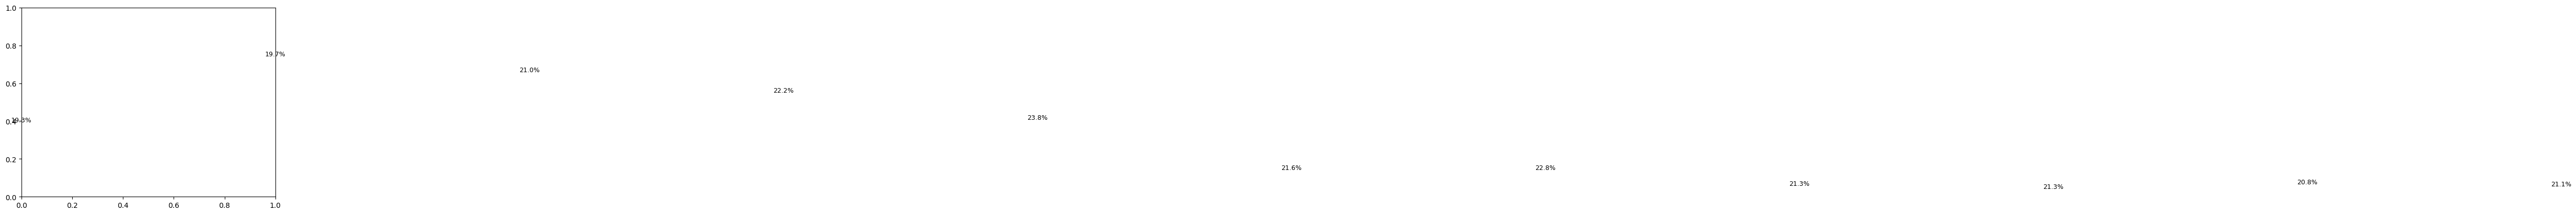

In [78]:
for bar, rate in zip(
    bars_delay,
    distance_delay_df[
        "DELAY_RATE"
    ]
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height() / 2,

        f"{rate:.1f}%",

        ha="center",
        va="center",
        fontsize=9
    )

<BarContainer object of 11 artists>

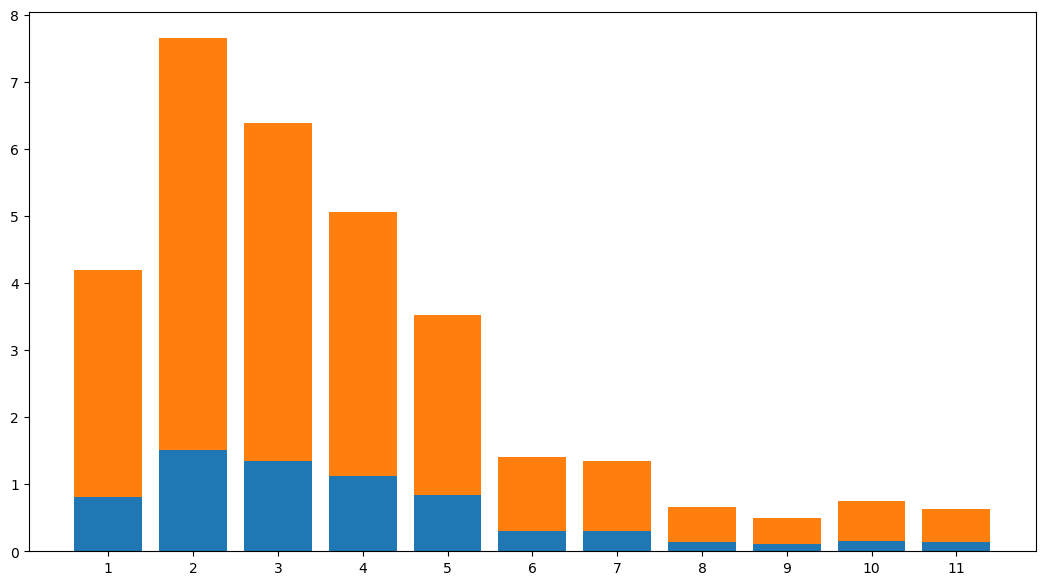

In [79]:
plt.figure(
    figsize=(13, 7)
)


bars_delay = plt.bar(
    distance_delay_df[
        "DISTANCE_GROUP"
    ].astype(str),

    distance_delay_df[
        "DELAYED_M"
    ],

    label="Retraso ≥ 15 min"
)


plt.bar(
    distance_delay_df[
        "DISTANCE_GROUP"
    ].astype(str),

    distance_delay_df[
        "NOT_DELAYED_M"
    ],

    bottom=distance_delay_df[
        "DELAYED_M"
    ],

    label="Sin retraso significativo"
)

,DISTANCE_GROUP,VALID_FLIGHTS,DELAYED_FLIGHTS,NOT_DELAYED_FLIGHTS,DELAY_RATE
0,1,4198133,811841,3386292,19.34
1,2,7654315,1505488,6148827,19.67
2,3,6386207,1339053,5047154,20.97
3,4,5051851,1124195,3927656,22.25
4,5,3517629,837020,2680609,23.80
5,6,1409555,304950,1104605,21.63
6,7,1351570,307848,1043722,22.78
7,8,660773,140777,519996,21.30
8,9,490084,104313,385771,21.28
9,10,754725,156703,598022,20.76


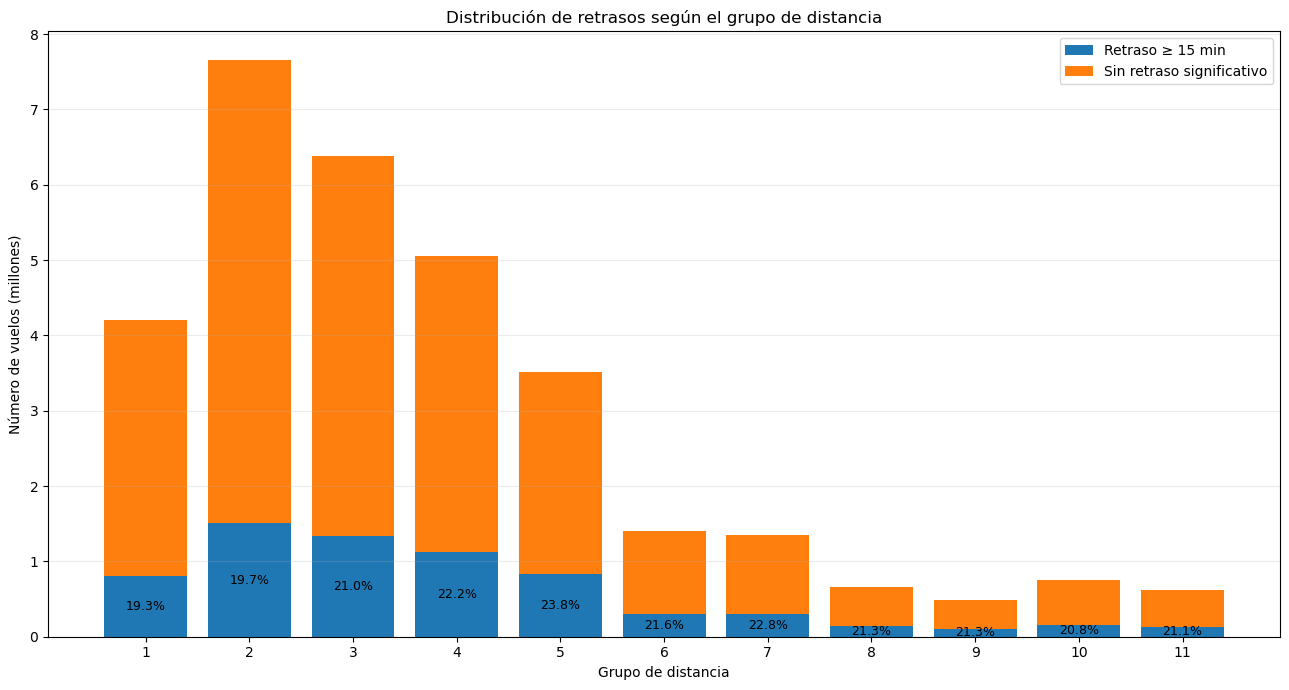

In [81]:
distance_delay_df = pd.DataFrame(
    [
        {
            "DISTANCE_GROUP": distance_group,
            "VALID_FLIGHTS": values[0],
            "DELAYED_FLIGHTS": values[1]
        }

        for distance_group, values
        in distance_group_delay_stats.items()
    ]
)


distance_delay_df = (
    distance_delay_df
    .sort_values(
        "DISTANCE_GROUP"
    )
    .reset_index(
        drop=True
    )
)


distance_delay_df[
    "NOT_DELAYED_FLIGHTS"
] = (
    distance_delay_df["VALID_FLIGHTS"]
    - distance_delay_df["DELAYED_FLIGHTS"]
)


distance_delay_df[
    "DELAY_RATE"
] = (
    distance_delay_df["DELAYED_FLIGHTS"]
    / distance_delay_df["VALID_FLIGHTS"]
    * 100
).round(2)


display(
    distance_delay_df
)


distance_delay_df[
    "DELAYED_M"
] = (
    distance_delay_df["DELAYED_FLIGHTS"]
    / 1_000_000
)

distance_delay_df[
    "NOT_DELAYED_M"
] = (
    distance_delay_df["NOT_DELAYED_FLIGHTS"]
    / 1_000_000
)


plt.figure(
    figsize=(13, 7)
)


bars_delay = plt.bar(
    distance_delay_df[
        "DISTANCE_GROUP"
    ].astype(str),

    distance_delay_df[
        "DELAYED_M"
    ],

    label="Retraso ≥ 15 min"
)


plt.bar(
    distance_delay_df[
        "DISTANCE_GROUP"
    ].astype(str),

    distance_delay_df[
        "NOT_DELAYED_M"
    ],

    bottom=distance_delay_df[
        "DELAYED_M"
    ],

    label="Sin retraso significativo"
)


for bar, rate in zip(
    bars_delay,
    distance_delay_df[
        "DELAY_RATE"
    ]
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height() / 2,

        f"{rate:.1f}%",

        ha="center",
        va="center",
        fontsize=9
    )


plt.title(
    "Distribución de retrasos según el grupo de distancia"
)

plt.xlabel(
    "Grupo de distancia"
)

plt.ylabel(
    "Número de vuelos (millones)"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()

,DISTANCE_GROUP,VALID_FLIGHTS,DELAYED_FLIGHTS,NOT_DELAYED_FLIGHTS,DELAY_RATE
0,1,4198133,811841,3386292,19.34
1,2,7654315,1505488,6148827,19.67
2,3,6386207,1339053,5047154,20.97
3,4,5051851,1124195,3927656,22.25
4,5,3517629,837020,2680609,23.80
5,6,1409555,304950,1104605,21.63
6,7,1351570,307848,1043722,22.78
7,8,660773,140777,519996,21.30
8,9,490084,104313,385771,21.28
9,10,754725,156703,598022,20.76


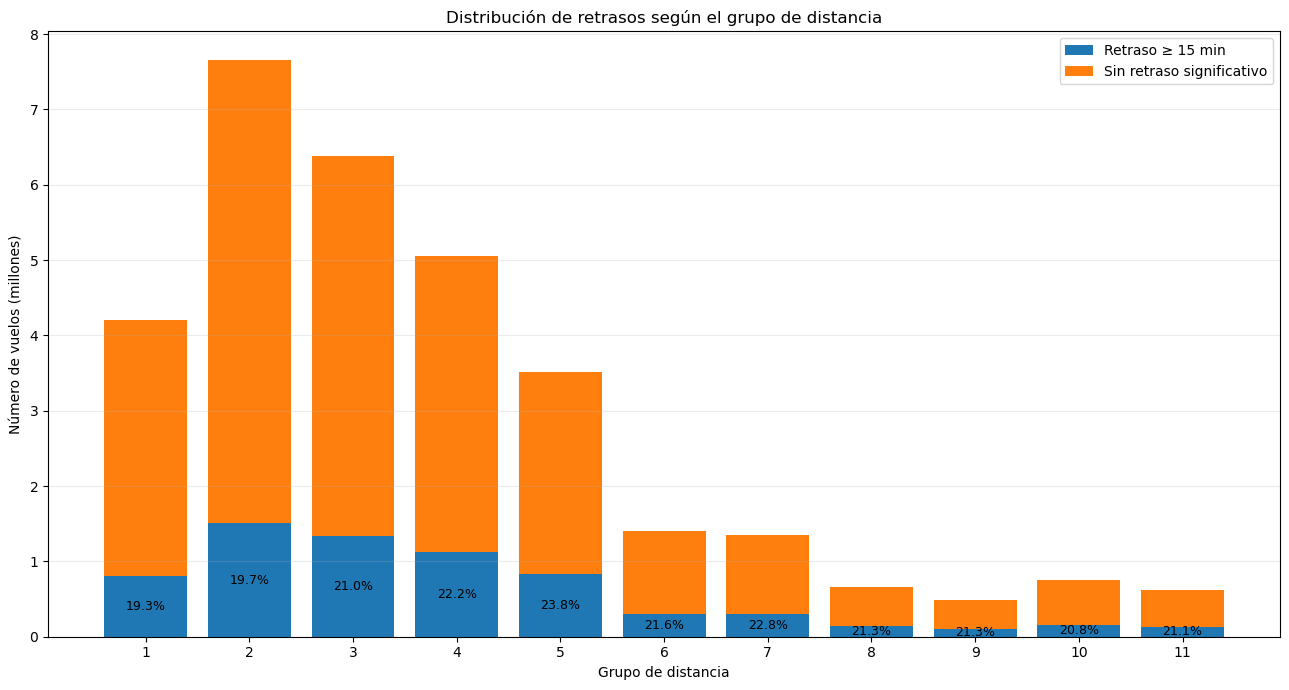

In [82]:
distance_delay_df = pd.DataFrame(
    [
        {
            "DISTANCE_GROUP": distance_group,
            "VALID_FLIGHTS": values[0],
            "DELAYED_FLIGHTS": values[1]
        }

        for distance_group, values
        in distance_group_delay_stats.items()
    ]
)


distance_delay_df = (
    distance_delay_df
    .sort_values(
        "DISTANCE_GROUP"
    )
    .reset_index(
        drop=True
    )
)


distance_delay_df[
    "NOT_DELAYED_FLIGHTS"
] = (
    distance_delay_df["VALID_FLIGHTS"]
    - distance_delay_df["DELAYED_FLIGHTS"]
)


distance_delay_df[
    "DELAY_RATE"
] = (
    distance_delay_df["DELAYED_FLIGHTS"]
    / distance_delay_df["VALID_FLIGHTS"]
    * 100
).round(2)


display(
    distance_delay_df
)


distance_delay_df[
    "DELAYED_M"
] = (
    distance_delay_df["DELAYED_FLIGHTS"]
    / 1_000_000
)

distance_delay_df[
    "NOT_DELAYED_M"
] = (
    distance_delay_df["NOT_DELAYED_FLIGHTS"]
    / 1_000_000
)


plt.figure(
    figsize=(13, 7)
)


bars_delay = plt.bar(
    distance_delay_df[
        "DISTANCE_GROUP"
    ].astype(str),

    distance_delay_df[
        "DELAYED_M"
    ],

    label="Retraso ≥ 15 min"
)


plt.bar(
    distance_delay_df[
        "DISTANCE_GROUP"
    ].astype(str),

    distance_delay_df[
        "NOT_DELAYED_M"
    ],

    bottom=distance_delay_df[
        "DELAYED_M"
    ],

    label="Sin retraso significativo"
)


for bar, rate in zip(
    bars_delay,
    distance_delay_df[
        "DELAY_RATE"
    ]
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height() / 2,

        f"{rate:.1f}%",

        ha="center",
        va="center",
        fontsize=9
    )


plt.title(
    "Distribución de retrasos según el grupo de distancia"
)

plt.xlabel(
    "Grupo de distancia"
)

plt.ylabel(
    "Número de vuelos (millones)"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()

#### Interpretación

La incidencia del retraso significativo presenta diferencias según el grupo de distancia, aunque no se observa una relación monótona entre ambas variables.

Entre los grupos 1 y 5 la tasa aumenta progresivamente desde el 19,34 % hasta alcanzar un máximo del 23,80 %. Sin embargo, a partir del grupo 6 este patrón se rompe y las tasas oscilan alrededor del nivel global del 21,07 %. En particular, los grupos de mayor distancia (8–11) presentan tasas comprendidas aproximadamente entre el 20,76 % y el 21,30 %, por lo que los vuelos pertenecientes a los grupos más elevados no muestran sistemáticamente una mayor incidencia del retraso.

La diferencia entre la tasa máxima, correspondiente al grupo 5 (23,80 %), y la mínima, registrada en el grupo 1 (19,34 %), es de 4,46 puntos porcentuales. Esta variación es considerablemente menor que la observada previamente para la franja horaria programada de salida.

El análisis conjunto del volumen y la tasa permite además diferenciar frecuencia relativa e impacto absoluto. El grupo 2 presenta una tasa de retraso relativamente baja, del 19,67 %, pero debido a su elevado volumen, con aproximadamente 7,65 millones de vuelos válidos, concentra alrededor de 1,51 millones de vuelos retrasados, el mayor número absoluto entre los grupos analizados.

Los primeros cinco grupos concentran aproximadamente el 83,5 % de los vuelos válidos, evidenciando que la distribución de las operaciones se encuentra principalmente concentrada en los grupos de distancia bajos e intermedios.

En conjunto, `DISTANCE_GROUP` presenta una asociación descriptiva con la variable objetivo, pero su comportamiento no puede resumirse mediante una relación lineal simple. Además, las diferencias observadas podrían estar relacionadas con otras características como la ruta, la aerolínea, el aeropuerto o la franja horaria, por lo que no deben interpretarse como una relación causal directa entre distancia y retraso.

### 7.8 Retraso según la aerolínea comercial

Se analiza la relación entre la aerolínea comercial (`MKT_UNIQUE_CARRIER`) y la variable objetivo `ARR_DEL15`.

Para cada aerolínea se calcula el número de vuelos con una variable objetivo válida, el número de vuelos con y sin retraso significativo y la tasa de retraso correspondiente.

La representación gráfica conserva el volumen absoluto de operaciones y muestra simultáneamente la tasa de retraso de cada aerolínea, permitiendo diferenciar entre volumen de incidencias e incidencia relativa.

Las aerolíneas se ordenan por tasa de retraso para facilitar la comparación, ya que se trata de una variable nominal sin un orden natural entre sus categorías.

In [84]:
carrier_delay_df = pd.DataFrame(
    [
        {
            "MKT_UNIQUE_CARRIER": carrier,
            "VALID_FLIGHTS": values[0],
            "DELAYED_FLIGHTS": values[1]
        }

        for carrier, values
        in market_carrier_delay_stats.items()
    ]
)

,MKT_UNIQUE_CARRIER,VALID_FLIGHTS,DELAYED_FLIGHTS,NOT_DELAYED_FLIGHTS,DELAY_RATE
0,DL,6656728,1141222,5515506,17.14
1,AS,1767032,349206,1417826,19.76
2,HA,309912,61797,248115,19.94
3,UA,5887856,1177532,4710324,20.00
4,WN,6022519,1322981,4699538,21.97
5,AA,8064114,1773686,6290428,21.99
6,NK,974295,248357,725938,25.49
7,G4,522471,138165,384306,26.44
8,B6,1086607,313869,772738,28.89
9,F9,807507,237292,570215,29.39


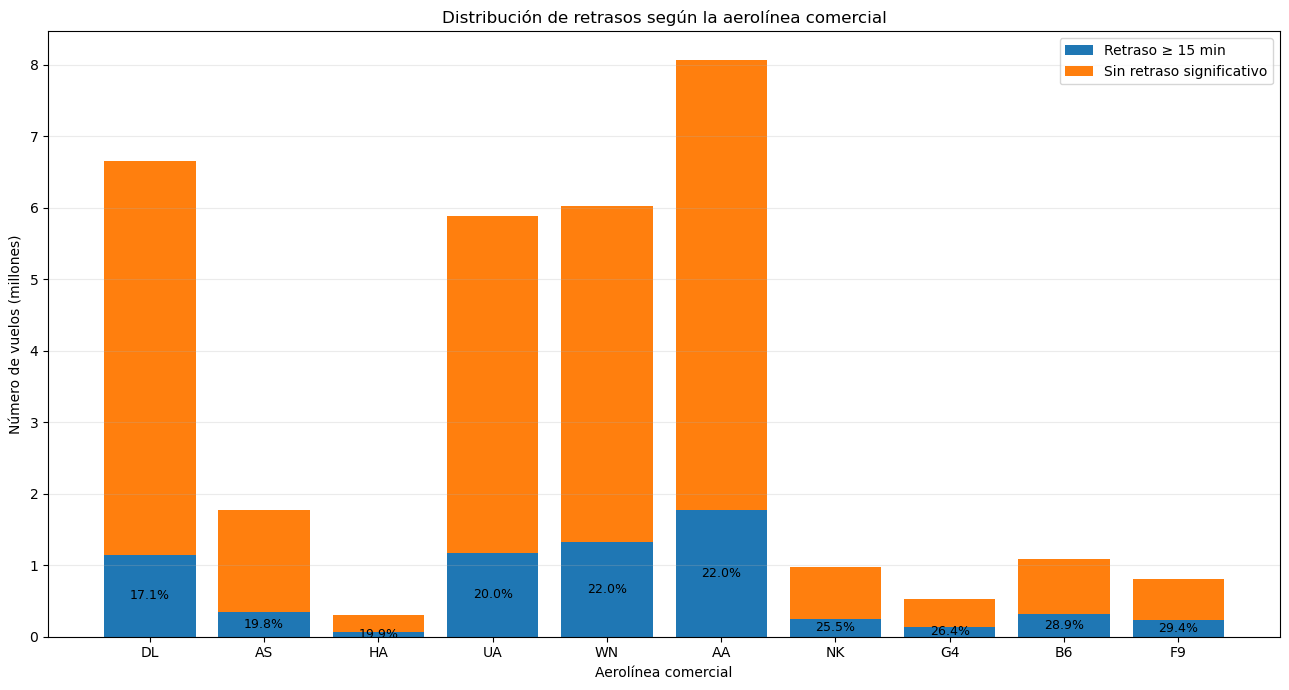

In [85]:
carrier_delay_df = pd.DataFrame(
    [
        {
            "MKT_UNIQUE_CARRIER": carrier,
            "VALID_FLIGHTS": values[0],
            "DELAYED_FLIGHTS": values[1]
        }

        for carrier, values
        in market_carrier_delay_stats.items()
    ]
)


carrier_delay_df[
    "NOT_DELAYED_FLIGHTS"
] = (
    carrier_delay_df["VALID_FLIGHTS"]
    - carrier_delay_df["DELAYED_FLIGHTS"]
)


carrier_delay_df[
    "DELAY_RATE"
] = (
    carrier_delay_df["DELAYED_FLIGHTS"]
    / carrier_delay_df["VALID_FLIGHTS"]
    * 100
).round(2)


carrier_delay_df = (
    carrier_delay_df
    .sort_values(
        "DELAY_RATE"
    )
    .reset_index(
        drop=True
    )
)


display(
    carrier_delay_df
)


carrier_delay_df[
    "DELAYED_M"
] = (
    carrier_delay_df["DELAYED_FLIGHTS"]
    / 1_000_000
)


carrier_delay_df[
    "NOT_DELAYED_M"
] = (
    carrier_delay_df["NOT_DELAYED_FLIGHTS"]
    / 1_000_000
)


plt.figure(
    figsize=(13, 7)
)


bars_delay = plt.bar(
    carrier_delay_df[
        "MKT_UNIQUE_CARRIER"
    ],

    carrier_delay_df[
        "DELAYED_M"
    ],

    label="Retraso ≥ 15 min"
)


plt.bar(
    carrier_delay_df[
        "MKT_UNIQUE_CARRIER"
    ],

    carrier_delay_df[
        "NOT_DELAYED_M"
    ],

    bottom=carrier_delay_df[
        "DELAYED_M"
    ],

    label="Sin retraso significativo"
)


for bar, rate in zip(
    bars_delay,
    carrier_delay_df["DELAY_RATE"]
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height() / 2,

        f"{rate:.1f}%",

        ha="center",
        va="center",
        fontsize=9
    )


plt.title(
    "Distribución de retrasos según la aerolínea comercial"
)

plt.xlabel(
    "Aerolínea comercial"
)

plt.ylabel(
    "Número de vuelos (millones)"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()

#### Interpretación

Se observan diferencias relevantes en la incidencia del retraso entre las distintas aerolíneas comerciales. La tasa de vuelos con retraso significativo oscila entre el 17.14 % de DL y el 29.39 % de F9, lo que supone una diferencia de 12.25 puntos porcentuales entre ambos extremos.

DL presenta la menor tasa de retraso pese a disponer de un volumen elevado de operaciones, mientras que F9, B6, G4 y NK presentan las tasas más altas. Por otro lado, AA concentra el mayor volumen absoluto de vuelos retrasados, con aproximadamente 1.77 millones, aunque su tasa de retraso (21.99 %) se encuentra mucho más próxima a la tasa global del conjunto de datos (21.07 %).

El análisis conjunto de volumen y tasa permite comprobar que una mayor cantidad absoluta de vuelos retrasados no implica necesariamente una mayor incidencia relativa del retraso. Las compañías con mayor volumen pueden acumular un número elevado de incidencias incluso con tasas moderadas, mientras que compañías con menor volumen pueden presentar tasas proporcionalmente superiores.

Estas diferencias sugieren que `MKT_UNIQUE_CARRIER` puede contener información relevante para explicar la variable objetivo y, por tanto, constituye una variable potencialmente útil para el posterior modelado predictivo. No obstante, las diferencias observadas deben interpretarse como asociaciones y no como efectos causales, ya que pueden estar condicionadas por otros factores como las rutas operadas, los aeropuertos utilizados, la distancia, los horarios o la estacionalidad.

### 7.9 Retraso según la aerolínea operadora

Se analiza la relación entre la aerolínea operadora (`OP_UNIQUE_CARRIER`) y la variable objetivo `ARR_DEL15`.

Para cada aerolínea operadora se calcula el número de vuelos con información válida de la variable objetivo, el número de vuelos con y sin retraso significativo y la tasa de retraso correspondiente.

A diferencia de `MKT_UNIQUE_CARRIER`, esta variable identifica a la compañía que efectivamente opera el vuelo. Su análisis permite comprobar si existen diferencias en la incidencia del retraso asociadas al operador.

La representación conserva el volumen absoluto de vuelos y muestra simultáneamente la tasa de retraso de cada categoría, evitando que una comparación exclusivamente porcentual oculte las importantes diferencias de volumen existentes entre operadores.

,OP_UNIQUE_CARRIER,VALID_FLIGHTS,DELAYED_FLIGHTS,NOT_DELAYED_FLIGHTS,DELAY_RATE
0,PT,500785,79461,421324,15.87
1,QX,370155,59766,310389,16.15
2,DL,4269176,744953,3524223,17.45
3,YX,1362571,239611,1122960,17.59
4,9E,950774,169856,780918,17.87
5,C5,329587,59161,270426,17.95
6,OO,3284763,611402,2673361,18.61
7,MQ,1159903,224803,935100,19.38
8,YV,392567,77701,314866,19.79
9,HA,309912,61797,248115,19.94


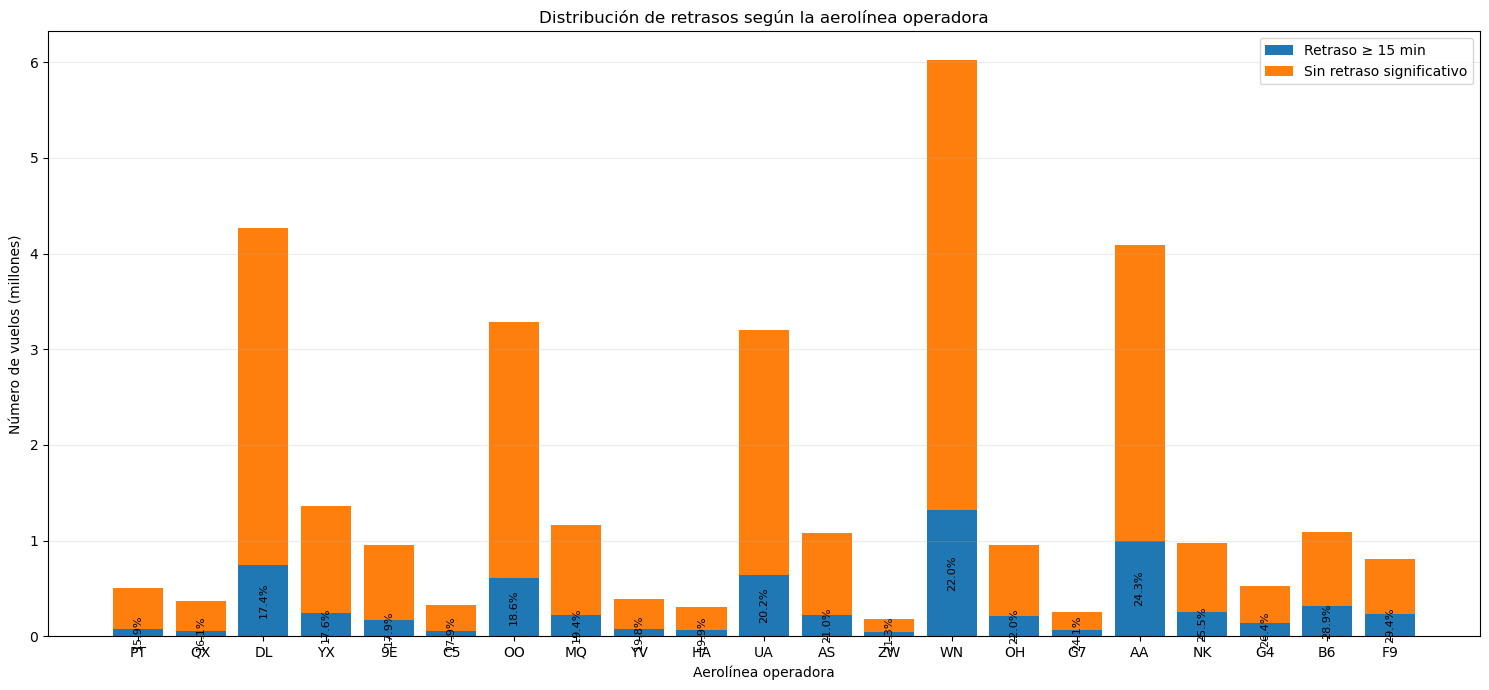

In [86]:
operator_delay_df = pd.DataFrame(
    [
        {
            "OP_UNIQUE_CARRIER": carrier,
            "VALID_FLIGHTS": values[0],
            "DELAYED_FLIGHTS": values[1]
        }
        for carrier, values
        in operating_carrier_delay_stats.items()
    ]
)


# Vuelos sin retraso significativo
operator_delay_df["NOT_DELAYED_FLIGHTS"] = (
    operator_delay_df["VALID_FLIGHTS"]
    - operator_delay_df["DELAYED_FLIGHTS"]
)


# Tasa de retraso
operator_delay_df["DELAY_RATE"] = (
    operator_delay_df["DELAYED_FLIGHTS"]
    / operator_delay_df["VALID_FLIGHTS"]
    * 100
).round(2)


# Ordenar por tasa de retraso
operator_delay_df = (
    operator_delay_df
    .sort_values("DELAY_RATE")
    .reset_index(drop=True)
)


# Mostrar tabla
display(
    operator_delay_df
)


# Conversión a millones exclusivamente para la representación gráfica
operator_delay_df["DELAYED_M"] = (
    operator_delay_df["DELAYED_FLIGHTS"]
    / 1_000_000
)

operator_delay_df["NOT_DELAYED_M"] = (
    operator_delay_df["NOT_DELAYED_FLIGHTS"]
    / 1_000_000
)


# Gráfico
plt.figure(figsize=(15, 7))


bars_delay = plt.bar(
    operator_delay_df["OP_UNIQUE_CARRIER"],
    operator_delay_df["DELAYED_M"],
    label="Retraso ≥ 15 min"
)


plt.bar(
    operator_delay_df["OP_UNIQUE_CARRIER"],
    operator_delay_df["NOT_DELAYED_M"],
    bottom=operator_delay_df["DELAYED_M"],
    label="Sin retraso significativo"
)


# Mostrar tasa de retraso dentro de cada barra
for bar, rate in zip(
    bars_delay,
    operator_delay_df["DELAY_RATE"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f"{rate:.1f}%",
        ha="center",
        va="center",
        fontsize=8,
        rotation=90
    )


plt.title(
    "Distribución de retrasos según la aerolínea operadora"
)

plt.xlabel(
    "Aerolínea operadora"
)

plt.ylabel(
    "Número de vuelos (millones)"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()

#### Interpretación

La incidencia del retraso presenta diferencias relevantes entre las aerolíneas operadoras. Las tasas oscilan entre el 15.87 % de PT y el 29.39 % de F9, lo que representa una diferencia de 13.52 puntos porcentuales entre ambos extremos.

Entre los operadores con menor incidencia destacan PT, QX y DL, mientras que F9, B6, G4 y NK presentan algunas de las tasas más elevadas. DL resulta especialmente relevante al combinar una tasa relativamente baja (17.45 %) con un elevado volumen de operaciones.

El volumen absoluto de retrasos no coincide necesariamente con la mayor incidencia relativa. WN acumula aproximadamente 1.32 millones de vuelos con retraso significativo debido a su elevado volumen de operaciones, aunque su tasa de retraso es del 21.97 %. En cambio, F9 registra un volumen absoluto considerablemente menor, pero presenta la mayor tasa de retraso, con un 29.39 %.

La comparación con `MKT_UNIQUE_CARRIER` muestra además que la aerolínea comercial y la operadora no son variables equivalentes. Por ejemplo, AA presenta una tasa del 21.99 % cuando se analiza como aerolínea comercial y del 24.32 % cuando se considera como operadora. Esto refleja la estructura comercial y operativa de los vuelos y justifica inicialmente el estudio separado de ambas variables.

Los resultados sugieren que `OP_UNIQUE_CARRIER` presenta asociación con `ARR_DEL15` y puede aportar información relevante al posterior modelado predictivo. No obstante, estas diferencias son asociaciones descriptivas y no deben interpretarse como efectos causales, ya que pueden estar condicionadas por factores como las rutas, aeropuertos, horarios, distancias y períodos de operación.

### 7.10 Retraso según el aeropuerto de origen

Se analiza la relación entre el aeropuerto de origen (`ORIGIN`) y la variable objetivo `ARR_DEL15`.

Para cada aeropuerto se calcula el número de vuelos con información válida de la variable objetivo, el número de vuelos con y sin retraso significativo y la tasa de retraso correspondiente.

Debido a la elevada cardinalidad de `ORIGIN`, con más de 300 aeropuertos diferentes, la representación gráfica de todas las categorías resultaría poco interpretable. Por este motivo, el análisis gráfico se concentra en los 20 aeropuertos con mayor volumen de vuelos válidos, manteniendo todos los aeropuertos en la tabla de resultados.

La selección se realiza según volumen y no según tasa de retraso, con el objetivo de analizar aeropuertos con una presencia suficientemente representativa en el conjunto de datos. El gráfico conserva además el volumen absoluto de operaciones y muestra simultáneamente la tasa de retraso de cada aeropuerto.

,ORIGIN,VALID_FLIGHTS,DELAYED_FLIGHTS,NOT_DELAYED_FLIGHTS,DELAY_RATE
0,ATL,1466804,300030,1166774,20.45
1,ORD,1396473,335843,1060630,24.05
2,DEN,1314317,322543,991774,24.54
3,DFW,1289376,333809,955567,25.89
4,CLT,1010962,227881,783081,22.54
...,...,...,...,...,...
376,OGS,233,46,187,19.74
377,OWB,126,49,77,38.89
378,BKG,47,14,33,29.79
379,ILG,42,22,20,52.38


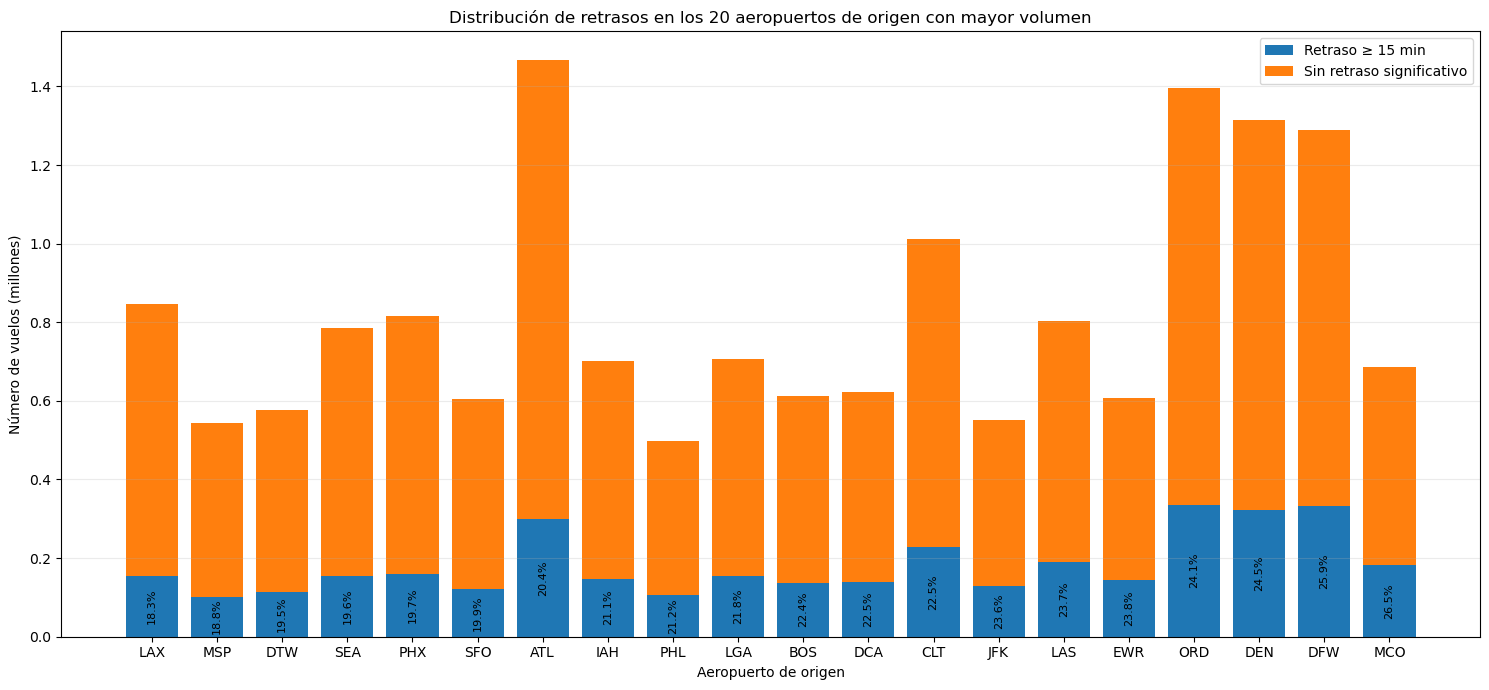

In [89]:
origin_delay_df = pd.DataFrame(
    [
        {
            "ORIGIN": origin,
            "VALID_FLIGHTS": values[0],
            "DELAYED_FLIGHTS": values[1]
        }
        for origin, values
        in origin_delay_stats.items()
    ]
)


# Vuelos sin retraso significativo
origin_delay_df["NOT_DELAYED_FLIGHTS"] = (
    origin_delay_df["VALID_FLIGHTS"]
    - origin_delay_df["DELAYED_FLIGHTS"]
)


# Tasa de retraso
origin_delay_df["DELAY_RATE"] = (
    origin_delay_df["DELAYED_FLIGHTS"]
    / origin_delay_df["VALID_FLIGHTS"]
    * 100
).round(2)


# Tabla completa ordenada por volumen
origin_delay_df = (
    origin_delay_df
    .sort_values(
        "VALID_FLIGHTS",
        ascending=False
    )
    .reset_index(drop=True)
)


display(
    origin_delay_df
)


# Seleccionar los 20 aeropuertos con mayor volumen
origin_top20_df = (
    origin_delay_df
    .head(20)
    .copy()
)


# Dentro del Top 20, ordenar por tasa para facilitar la comparación
origin_top20_df = (
    origin_top20_df
    .sort_values("DELAY_RATE")
    .reset_index(drop=True)
)


# Conversión a millones exclusivamente para el gráfico
origin_top20_df["DELAYED_M"] = (
    origin_top20_df["DELAYED_FLIGHTS"]
    / 1_000_000
)

origin_top20_df["NOT_DELAYED_M"] = (
    origin_top20_df["NOT_DELAYED_FLIGHTS"]
    / 1_000_000
)


# Gráfico
plt.figure(figsize=(15, 7))


bars_delay = plt.bar(
    origin_top20_df["ORIGIN"],
    origin_top20_df["DELAYED_M"],
    label="Retraso ≥ 15 min"
)


plt.bar(
    origin_top20_df["ORIGIN"],
    origin_top20_df["NOT_DELAYED_M"],
    bottom=origin_top20_df["DELAYED_M"],
    label="Sin retraso significativo"
)


# Mostrar tasa de retraso
for bar, rate in zip(
    bars_delay,
    origin_top20_df["DELAY_RATE"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f"{rate:.1f}%",
        ha="center",
        va="center",
        fontsize=8,
        rotation=90
    )


plt.title(
    "Distribución de retrasos en los 20 aeropuertos de origen con mayor volumen"
)

plt.xlabel(
    "Aeropuerto de origen"
)

plt.ylabel(
    "Número de vuelos (millones)"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()

#### Interpretación

El análisis de los aeropuertos de origen con mayor volumen muestra diferencias relevantes en la incidencia del retraso. Entre los 20 aeropuertos con mayor número de vuelos, las tasas oscilan aproximadamente entre el 18 % y el 27 %, mostrando que aeropuertos con volúmenes de operación comparables pueden presentar comportamientos diferentes respecto a la variable objetivo.

Entre los principales aeropuertos, LAX, MSP, DTW, SEA, PHX y SFO presentan tasas relativamente bajas, mientras que LAS, EWR, ORD, DEN, DFW y MCO se sitúan entre los valores más elevados. ATL, pese a ser el aeropuerto con mayor volumen de vuelos válidos, presenta una tasa del 20.45 %, ligeramente inferior a la tasa global del conjunto de datos (21.07 %).

El análisis confirma también la importancia de considerar conjuntamente volumen e incidencia. Un aeropuerto puede acumular un número elevado de vuelos retrasados debido a su volumen de operaciones sin presentar necesariamente una tasa elevada.

La elevada cardinalidad de `ORIGIN` requiere además precaución al interpretar categorías con pocas observaciones. Algunos aeropuertos de muy bajo volumen presentan tasas extremas, pero estas estimaciones se encuentran sustentadas por un número reducido de vuelos y son, por tanto, mucho menos estables que las observadas en los principales aeropuertos. Por este motivo, la representación gráfica se ha limitado a los 20 aeropuertos con mayor volumen en lugar de seleccionar las categorías según sus tasas extremas.

Los resultados sugieren una asociación entre el aeropuerto de origen y `ARR_DEL15`, por lo que `ORIGIN` puede aportar información relevante al posterior modelado. No obstante, deberá considerarse su elevada cardinalidad y su relación con otras variables geográficas como `ORIGIN_CITY_NAME` y `ORIGIN_STATE_ABR`.

### 7.11 Retraso según el aeropuerto de destino

Se analiza la relación entre el aeropuerto de destino (`DEST`) y la variable objetivo `ARR_DEL15`.

Para cada aeropuerto se calcula el número de vuelos con información válida de la variable objetivo, el número de vuelos con y sin retraso significativo y la correspondiente tasa de retraso.

Debido a la elevada cardinalidad de `DEST`, la tabla conserva los resultados de todos los aeropuertos, mientras que la representación gráfica se limita a los 20 aeropuertos de destino con mayor volumen de vuelos válidos.

La selección se realiza según volumen, evitando destacar aeropuertos con pocas observaciones y tasas potencialmente inestables. Una vez seleccionados los 20 principales aeropuertos, estos se ordenan por tasa de retraso para facilitar su comparación.

La representación conserva simultáneamente el volumen absoluto de operaciones y la incidencia relativa del retraso.

,DEST,VALID_FLIGHTS,DELAYED_FLIGHTS,NOT_DELAYED_FLIGHTS,DELAY_RATE
0,ATL,1466528,254129,1212399,17.33
1,ORD,1394289,303301,1090988,21.75
2,DEN,1312047,272878,1039169,20.80
3,DFW,1286632,289068,997564,22.47
4,CLT,1011107,192203,818904,19.01
...,...,...,...,...,...
377,OWB,127,33,94,25.98
378,BKG,47,18,29,38.30
379,ILG,42,17,25,40.48
380,OGD,27,9,18,33.33


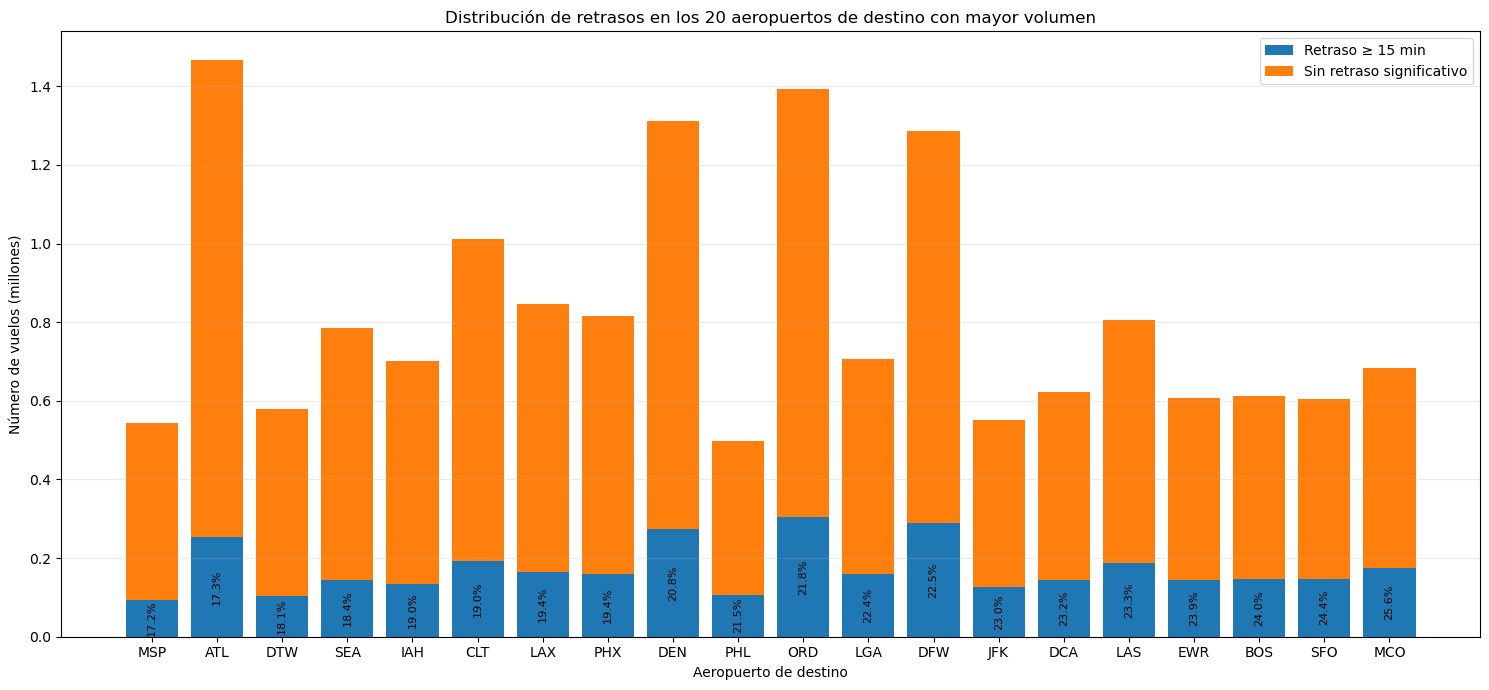

In [91]:
# ---------------------------------------------------------
# 1. Construcción de la tabla a partir del acumulador
#    generado en 7.1
# ---------------------------------------------------------

dest_delay_df = pd.DataFrame(
    [
        {
            "DEST": dest,
            "VALID_FLIGHTS": values[0],
            "DELAYED_FLIGHTS": values[1]
        }
        for dest, values
        in dest_delay_stats.items()
    ]
)


# ---------------------------------------------------------
# 2. Vuelos sin retraso significativo
# ---------------------------------------------------------

dest_delay_df["NOT_DELAYED_FLIGHTS"] = (
    dest_delay_df["VALID_FLIGHTS"]
    - dest_delay_df["DELAYED_FLIGHTS"]
)


# ---------------------------------------------------------
# 3. Tasa de retraso
# ---------------------------------------------------------

dest_delay_df["DELAY_RATE"] = (
    dest_delay_df["DELAYED_FLIGHTS"]
    / dest_delay_df["VALID_FLIGHTS"]
    * 100
).round(2)


# ---------------------------------------------------------
# 4. Tabla completa ordenada por volumen
# ---------------------------------------------------------

dest_delay_df = (
    dest_delay_df
    .sort_values(
        "VALID_FLIGHTS",
        ascending=False
    )
    .reset_index(drop=True)
)


display(
    dest_delay_df
)


# ---------------------------------------------------------
# 5. Seleccionar los 20 aeropuertos con mayor volumen
# ---------------------------------------------------------

dest_top20_df = (
    dest_delay_df
    .head(20)
    .copy()
)


# ---------------------------------------------------------
# 6. Dentro del Top 20, ordenar por tasa de retraso
# ---------------------------------------------------------

dest_top20_df = (
    dest_top20_df
    .sort_values("DELAY_RATE")
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# 7. Conversión a millones solo para el gráfico
# ---------------------------------------------------------

dest_top20_df["DELAYED_M"] = (
    dest_top20_df["DELAYED_FLIGHTS"]
    / 1_000_000
)

dest_top20_df["NOT_DELAYED_M"] = (
    dest_top20_df["NOT_DELAYED_FLIGHTS"]
    / 1_000_000
)


# ---------------------------------------------------------
# 8. Gráfico de volumen + tasa
# ---------------------------------------------------------

plt.figure(
    figsize=(15, 7)
)


bars_delay = plt.bar(
    dest_top20_df["DEST"],
    dest_top20_df["DELAYED_M"],
    label="Retraso ≥ 15 min"
)


plt.bar(
    dest_top20_df["DEST"],
    dest_top20_df["NOT_DELAYED_M"],
    bottom=dest_top20_df["DELAYED_M"],
    label="Sin retraso significativo"
)


# ---------------------------------------------------------
# 9. Mostrar tasa dentro del segmento de retrasos
# ---------------------------------------------------------

for bar, rate in zip(
    bars_delay,
    dest_top20_df["DELAY_RATE"]
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height() / 2,

        f"{rate:.1f}%",

        ha="center",
        va="center",
        fontsize=8,
        rotation=90
    )


# ---------------------------------------------------------
# 10. Formato final
# ---------------------------------------------------------

plt.title(
    "Distribución de retrasos en los 20 aeropuertos de destino con mayor volumen"
)

plt.xlabel(
    "Aeropuerto de destino"
)

plt.ylabel(
    "Número de vuelos (millones)"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()

#### Interpretación

La distribución de los retrasos según el aeropuerto de destino (`DEST`) muestra diferencias relevantes entre los principales aeropuertos del conjunto de datos.

Entre los aeropuertos con mayor volumen de operaciones, ATL presenta aproximadamente 1.47 millones de vuelos válidos y una tasa de retraso del 17.33 %, siendo una de las más bajas dentro de los aeropuertos representados. Por el contrario, otros aeropuertos con un volumen considerable presentan tasas superiores, como DFW (22.47 %), EWR (23.87 %), BOS (24.03 %), SFO (24.40 %) y MCO (25.56 %).

También se observan diferencias entre aeropuertos con volúmenes similares. Por ejemplo, ORD, DEN y DFW superan el millón de vuelos válidos, pero presentan tasas de retraso del 21.75 %, **20.80 % y 22.47 %, respectivamente. Por tanto, un mayor volumen de operaciones no implica necesariamente una mayor proporción de vuelos retrasados.

El gráfico permite analizar conjuntamente el volumen total de vuelos y la proporción de vuelos con retraso significativo. Esto es importante porque evita interpretar las tasas de retraso de forma aislada, especialmente en aeropuertos con pocas observaciones.

En la tabla completa existen aeropuertos con tasas de retraso muy elevadas, pero algunos corresponden a volúmenes extremadamente reducidos. Por ejemplo, IFP presenta una tasa del 100 %, pero solamente dispone de un vuelo válido. Por este motivo, el gráfico se limita a los 20 aeropuertos de destino con mayor volumen, permitiendo realizar comparaciones más representativas.

En conjunto, los resultados indican que existen diferencias en la incidencia de retrasos dependiendo del aeropuerto de destino. Esto sugiere que `DEST` puede aportar información relevante para la predicción de `ARR_DEL15`. No obstante, estas diferencias deben interpretarse como asociaciones y no como relaciones causales, ya que pueden estar relacionadas con otros factores como las rutas, horarios, aerolíneas o características operativas de cada aeropuerto.

### 7.12. Retrasos según el estado de origen

En este apartado se analiza la relación entre el estado de origen del vuelo (`ORIGIN_STATE_ABR`) y la variable objetivo `ARR_DEL15`.

El objetivo es determinar si existen diferencias en la incidencia de retrasos significativos entre los distintos estados de origen. Este análisis complementa el realizado anteriormente a nivel de aeropuerto, permitiendo estudiar los patrones desde un nivel geográfico más agregado y con una cardinalidad considerablemente menor.

Para evitar que las tasas de retraso se interpreten de forma aislada, se representa conjuntamente el volumen total de vuelos y la proporción correspondiente a vuelos con y sin retraso significativo. De esta forma es posible distinguir entre estados que presentan una tasa elevada de retrasos y aquellos cuyo número absoluto de vuelos retrasados es elevado principalmente debido a su mayor volumen de operaciones.

La visualización se centra en los 20 estados con mayor número de vuelos válidos, mientras que la tabla resumen conserva los resultados correspondientes a todos los estados disponibles en el conjunto de datos.

,ORIGIN_STATE_ABR,VALID_FLIGHTS,DELAYED_FLIGHTS,NOT_DELAYED_FLIGHTS,DELAY_RATE
0,TX,3420790,772984,2647806,22.60
1,CA,3269901,608829,2661072,18.62
2,FL,2705867,664180,2041687,24.55
3,IL,1810919,435853,1375066,24.07
4,NY,1663957,367872,1296085,22.11
5,GA,1595013,324158,1270855,20.32
6,CO,1479677,360195,1119482,24.34
7,NC,1462114,315899,1146215,21.61
8,VA,1253269,260950,992319,20.82
9,WA,945060,177979,767081,18.83


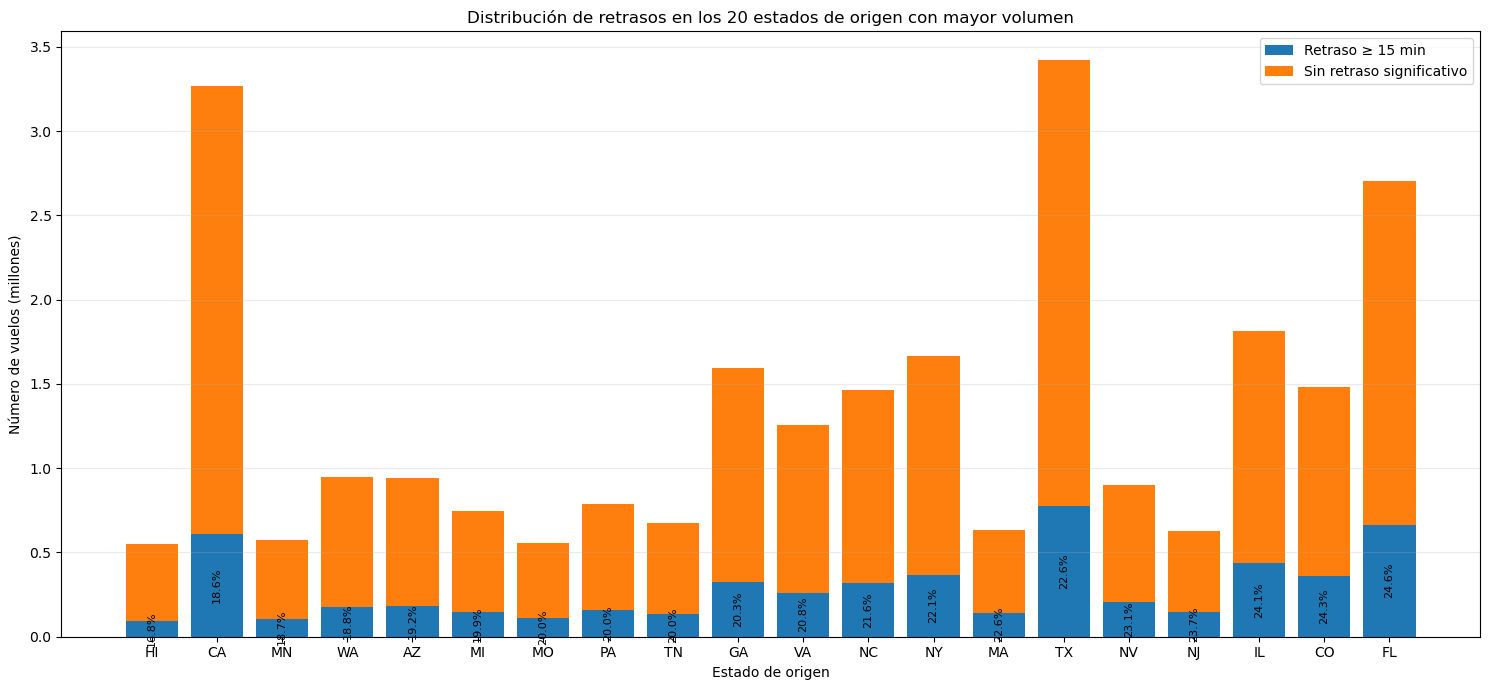

In [93]:
# ---------------------------------------------------------
# 1. Construcción de la tabla a partir del acumulador
#    generado en 7.1
# ---------------------------------------------------------

origin_state_delay_df = pd.DataFrame(
    [
        {
            "ORIGIN_STATE_ABR": state,
            "VALID_FLIGHTS": values[0],
            "DELAYED_FLIGHTS": values[1]
        }
        for state, values
        in origin_state_delay_stats.items()
    ]
)


# ---------------------------------------------------------
# 2. Vuelos sin retraso significativo
# ---------------------------------------------------------

origin_state_delay_df["NOT_DELAYED_FLIGHTS"] = (
    origin_state_delay_df["VALID_FLIGHTS"]
    - origin_state_delay_df["DELAYED_FLIGHTS"]
)


# ---------------------------------------------------------
# 3. Tasa de retraso
# ---------------------------------------------------------

origin_state_delay_df["DELAY_RATE"] = (
    origin_state_delay_df["DELAYED_FLIGHTS"]
    / origin_state_delay_df["VALID_FLIGHTS"]
    * 100
).round(2)


# ---------------------------------------------------------
# 4. Tabla completa ordenada por volumen
# ---------------------------------------------------------

origin_state_delay_df = (
    origin_state_delay_df
    .sort_values(
        "VALID_FLIGHTS",
        ascending=False
    )
    .reset_index(drop=True)
)


display(
    origin_state_delay_df
)


# ---------------------------------------------------------
# 5. Seleccionar los 20 estados con mayor volumen
# ---------------------------------------------------------

origin_state_top20_df = (
    origin_state_delay_df
    .head(20)
    .copy()
)


# ---------------------------------------------------------
# 6. Dentro del Top 20, ordenar por tasa de retraso
# ---------------------------------------------------------

origin_state_top20_df = (
    origin_state_top20_df
    .sort_values("DELAY_RATE")
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# 7. Conversión a millones solo para el gráfico
# ---------------------------------------------------------

origin_state_top20_df["DELAYED_M"] = (
    origin_state_top20_df["DELAYED_FLIGHTS"]
    / 1_000_000
)

origin_state_top20_df["NOT_DELAYED_M"] = (
    origin_state_top20_df["NOT_DELAYED_FLIGHTS"]
    / 1_000_000
)


# ---------------------------------------------------------
# 8. Gráfico de volumen + tasa
# ---------------------------------------------------------

plt.figure(
    figsize=(15, 7)
)


bars_delay = plt.bar(
    origin_state_top20_df["ORIGIN_STATE_ABR"],
    origin_state_top20_df["DELAYED_M"],
    label="Retraso ≥ 15 min"
)


plt.bar(
    origin_state_top20_df["ORIGIN_STATE_ABR"],
    origin_state_top20_df["NOT_DELAYED_M"],
    bottom=origin_state_top20_df["DELAYED_M"],
    label="Sin retraso significativo"
)


# ---------------------------------------------------------
# 9. Mostrar tasa dentro del segmento de retrasos
# ---------------------------------------------------------

for bar, rate in zip(
    bars_delay,
    origin_state_top20_df["DELAY_RATE"]
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height() / 2,

        f"{rate:.1f}%",

        ha="center",
        va="center",
        fontsize=8,
        rotation=90
    )


# ---------------------------------------------------------
# 10. Formato final
# ---------------------------------------------------------

plt.title(
    "Distribución de retrasos en los 20 estados de origen con mayor volumen"
)

plt.xlabel(
    "Estado de origen"
)

plt.ylabel(
    "Número de vuelos (millones)"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()

#### Interpretación

El análisis por estado de origen muestra diferencias apreciables en la incidencia de retrasos significativos entre las principales zonas de operación. Para evitar que una tasa elevada asociada a un número reducido de observaciones condicione la interpretación, la visualización se limita a los 20 estados con mayor volumen de vuelos válidos.

Entre estos estados, las tasas de retraso se sitúan aproximadamente entre el 16.8 % y el 24.6 %. Florida (`FL`) presenta la mayor tasa dentro de los 20 estados con mayor volumen, con un 24.55 %, seguida de Colorado (`CO`) con un 24.34 % e Illinois (`IL`) con un 24.07 %. En el extremo contrario, Hawái (`HI`) presenta la menor tasa del grupo, con un 16.78 %, seguido de California (`CA`) con un 18.62 % y Minnesota (`MN`) con un 18.67 %.

El volumen de operaciones no presenta una correspondencia directa con una mayor tasa de retraso. Texas (`TX`) concentra el mayor volumen, con aproximadamente 3.42 millones de vuelos válidos, y presenta una tasa del 22.60 %. California (`CA`), con un volumen similar de aproximadamente 3.27 millones de vuelos, registra una tasa considerablemente inferior, del 18.62 %. Por otro lado, Florida (`FL`), con aproximadamente 2.71 millones de vuelos, alcanza una tasa del 24.55 %. Estas diferencias indican que estados con volúmenes comparables pueden presentar comportamientos distintos respecto a la variable objetivo.

El análisis conjunto del volumen y la tasa resulta especialmente importante en esta variable. En la tabla completa aparecen categorías con porcentajes extremos, como Delaware (`DE`), con una tasa del 52.38 %, pero este resultado procede únicamente de 42 vuelos válidos. Por tanto, no puede compararse directamente con las tasas observadas en estados que acumulan cientos de miles o millones de vuelos. Este comportamiento evidencia la inestabilidad que pueden presentar las proporciones calculadas sobre tamaños muestrales muy reducidos.

En conjunto, los resultados muestran que la incidencia de `ARR_DEL15` varía según el estado de origen y que estas diferencias no parecen explicarse exclusivamente por el volumen de operaciones. Por tanto, `ORIGIN_STATE_ABR` puede contener información relevante para la predicción de retrasos y permite representar patrones geográficos con una cardinalidad considerablemente menor que `ORIGIN`. No obstante, las diferencias observadas deben interpretarse como asociaciones y no como relaciones causales, ya que pueden estar vinculadas a otros factores como los aeropuertos incluidos en cada estado, las rutas, las aerolíneas, la época del año o las condiciones operativas.

### 7.13 Retraso según el estado de destino

En este apartado se analiza la relación entre el estado de destino del vuelo (`DEST_STATE_ABR`) y la variable objetivo `ARR_DEL15`.

El objetivo es determinar si existen diferencias en la incidencia de retrasos significativos dependiendo del estado al que se dirige el vuelo. Para ello se consideran conjuntamente el volumen de operaciones y la tasa de retraso, evitando interpretar los porcentajes de forma aislada.

Debido a que algunos estados o territorios presentan un volumen de vuelos considerablemente menor, la visualización se centra en los 20 estados de destino con mayor número de vuelos válidos. De esta forma, las diferencias observadas en las tasas de retraso se analizan sobre categorías con una presencia relevante dentro del conjunto de datos.

Procesados 50/354 archivos
Procesados 100/354 archivos
Procesados 150/354 archivos
Procesados 200/354 archivos
Procesados 250/354 archivos
Procesados 300/354 archivos
Procesados 350/354 archivos
Procesados 354/354 archivos


,DEST_STATE_ABR,VALID_FLIGHTS,DELAYED_FLIGHTS,NOT_DELAYED_FLIGHTS,DELAY_RATE
0,TX,3416802,729112,2687690,21.34
1,CA,3272671,676944,2595727,20.68
2,FL,2704812,670461,2034351,24.79
3,IL,1808180,389749,1418431,21.55
4,NY,1662459,379050,1283409,22.80
5,GA,1594848,281142,1313706,17.63
6,CO,1477282,311607,1165675,21.09
7,NC,1462733,288481,1174252,19.72
8,VA,1252952,266532,986420,21.27
9,WA,944631,173712,770919,18.39


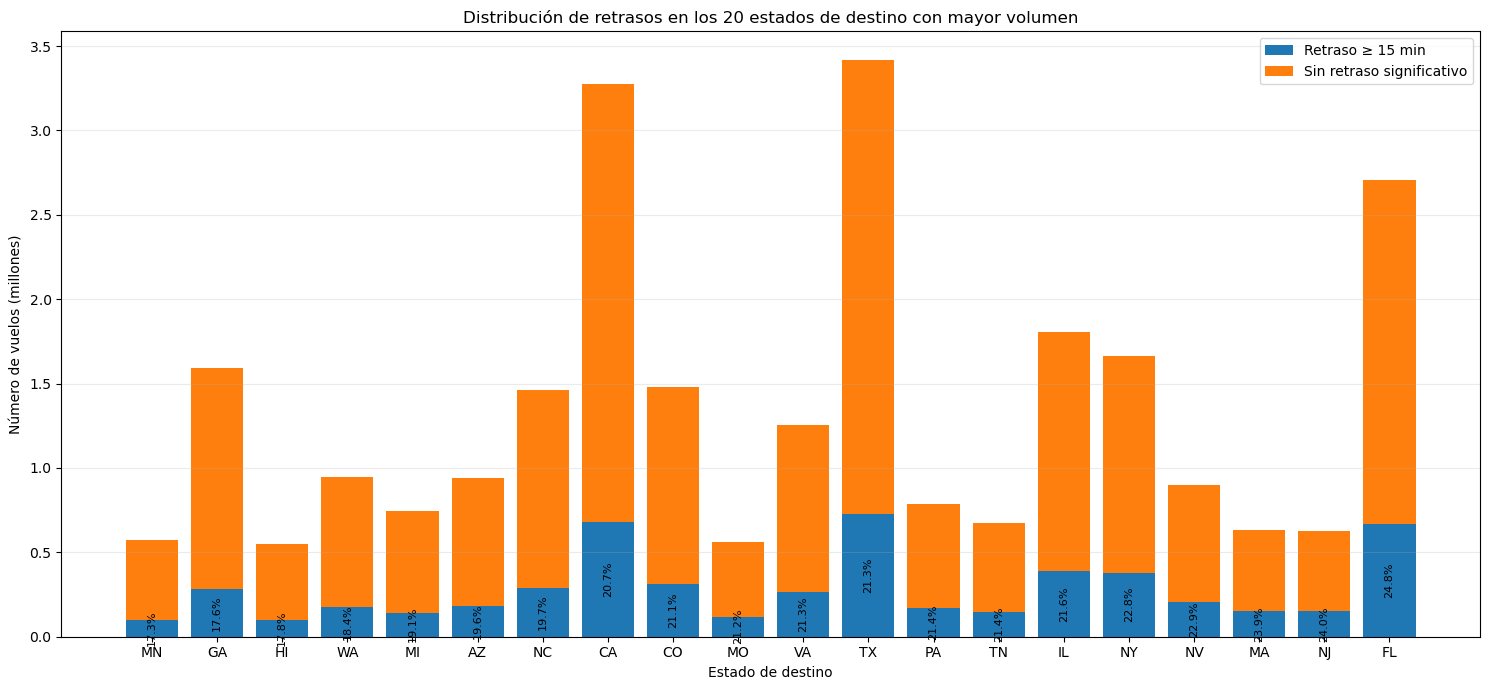

In [96]:
# ---------------------------------------------------------
# 1. Crear el acumulador de estado de destino
# ---------------------------------------------------------

dest_state_delay_stats = defaultdict(
    lambda: [0, 0]
)


# ---------------------------------------------------------
# 2. Procesamiento incremental de los Parquet
# ---------------------------------------------------------

for file_number, parquet_file in enumerate(
    parquet_files,
    start=1
):

    temp_df = pd.read_parquet(
        parquet_file,
        columns=[
            "DEST_STATE_ABR",
            "ARR_DEL15"
        ]
    )


    # Solo vuelos con target válida
    valid_df = temp_df[
        temp_df["ARR_DEL15"].notna()
    ]


    # Agregación por estado de destino
    state_stats = (
        valid_df
        .groupby(
            "DEST_STATE_ABR",
            observed=True
        )["ARR_DEL15"]
        .agg(
            VALID_FLIGHTS="count",
            DELAYED_FLIGHTS="sum"
        )
    )


    # Acumulación sobre todo el histórico
    for state, row in state_stats.iterrows():

        dest_state_delay_stats[
            state
        ][0] += int(
            row["VALID_FLIGHTS"]
        )

        dest_state_delay_stats[
            state
        ][1] += int(
            row["DELAYED_FLIGHTS"]
        )


    if (
        file_number % 50 == 0
        or file_number == len(parquet_files)
    ):

        print(
            f"Procesados "
            f"{file_number}/"
            f"{len(parquet_files)} "
            f"archivos"
        )


# ---------------------------------------------------------
# 3. Construcción de la tabla resumen
# ---------------------------------------------------------

dest_state_delay_df = pd.DataFrame(
    [
        {
            "DEST_STATE_ABR": state,
            "VALID_FLIGHTS": values[0],
            "DELAYED_FLIGHTS": values[1]
        }
        for state, values
        in dest_state_delay_stats.items()
    ]
)


# ---------------------------------------------------------
# 4. Vuelos sin retraso significativo
# ---------------------------------------------------------

dest_state_delay_df["NOT_DELAYED_FLIGHTS"] = (
    dest_state_delay_df["VALID_FLIGHTS"]
    - dest_state_delay_df["DELAYED_FLIGHTS"]
)


# ---------------------------------------------------------
# 5. Tasa de retraso
# ---------------------------------------------------------

dest_state_delay_df["DELAY_RATE"] = (
    dest_state_delay_df["DELAYED_FLIGHTS"]
    / dest_state_delay_df["VALID_FLIGHTS"]
    * 100
).round(2)


# ---------------------------------------------------------
# 6. Tabla completa ordenada por volumen
# ---------------------------------------------------------

dest_state_delay_df = (
    dest_state_delay_df
    .sort_values(
        "VALID_FLIGHTS",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


display(
    dest_state_delay_df
)


# ---------------------------------------------------------
# 7. Seleccionar los 20 estados con mayor volumen
# ---------------------------------------------------------

dest_state_top20_df = (
    dest_state_delay_df
    .head(20)
    .copy()
)


# ---------------------------------------------------------
# 8. Dentro del Top 20, ordenar por tasa de retraso
# ---------------------------------------------------------

dest_state_top20_df = (
    dest_state_top20_df
    .sort_values(
        "DELAY_RATE"
    )
    .reset_index(
        drop=True
    )
)


# ---------------------------------------------------------
# 9. Conversión a millones solo para el gráfico
# ---------------------------------------------------------

dest_state_top20_df["DELAYED_M"] = (
    dest_state_top20_df["DELAYED_FLIGHTS"]
    / 1_000_000
)

dest_state_top20_df["NOT_DELAYED_M"] = (
    dest_state_top20_df["NOT_DELAYED_FLIGHTS"]
    / 1_000_000
)


# ---------------------------------------------------------
# 10. Gráfico de volumen + tasa
# ---------------------------------------------------------

plt.figure(
    figsize=(15, 7)
)


bars_delay = plt.bar(
    dest_state_top20_df["DEST_STATE_ABR"],
    dest_state_top20_df["DELAYED_M"],
    label="Retraso ≥ 15 min"
)


plt.bar(
    dest_state_top20_df["DEST_STATE_ABR"],
    dest_state_top20_df["NOT_DELAYED_M"],
    bottom=dest_state_top20_df["DELAYED_M"],
    label="Sin retraso significativo"
)


# ---------------------------------------------------------
# 11. Mostrar la tasa de retraso
# ---------------------------------------------------------

for bar, rate in zip(
    bars_delay,
    dest_state_top20_df["DELAY_RATE"]
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height() / 2,

        f"{rate:.1f}%",

        ha="center",
        va="center",
        fontsize=8,
        rotation=90
    )


# ---------------------------------------------------------
# 12. Formato final
# ---------------------------------------------------------

plt.title(
    "Distribución de retrasos en los 20 estados de destino con mayor volumen"
)

plt.xlabel(
    "Estado de destino"
)

plt.ylabel(
    "Número de vuelos (millones)"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()

#### Interpretación

El análisis por estado de destino muestra diferencias relevantes en la incidencia de retrasos significativos entre los principales destinos del conjunto de datos. Para mantener la representatividad del análisis, la visualización se limita a los 20 estados con mayor volumen de vuelos válidos, mostrando simultáneamente el volumen de operaciones y la tasa de retraso.

Dentro de estos 20 estados, Florida (`FL`) presenta la mayor tasa de retraso, con un 24.79 %, seguida de Nueva Jersey (`NJ`) con un 23.99 % y Massachusetts (`MA`) con un 23.88 %. En el extremo contrario, Minnesota (`MN`) registra la menor tasa, con un 17.30 %, seguida de Georgia (`GA`) con un 17.63 % y Hawái (`HI`) con un 17.78 %.

El volumen de operaciones no parece determinar por sí solo la tasa de retraso. Texas (`TX`) es el estado de destino con mayor volumen, con aproximadamente 3.42 millones de vuelos válidos, y presenta una tasa del 21.34 %. California (`CA`), con aproximadamente 3.27 millones de vuelos, registra una tasa ligeramente inferior, del 20.68 %. Florida (`FL`), aunque presenta un volumen menor de aproximadamente 2.70 millones de vuelos, alcanza una tasa considerablemente superior, del 24.79 %.

También resulta interesante comparar estos resultados con los obtenidos para el estado de origen. Algunos estados presentan diferencias entre ambas perspectivas. Por ejemplo, California registra una tasa del 18.62 % como origen y del 20.68 % como destino, mientras que Georgia pasa del 20.32 % como origen al 17.63 % como destino. Esto indica que el efecto geográfico sobre el retraso puede ser diferente dependiendo de si el estado representa el punto de salida o el punto de llegada.

La tabla completa vuelve a mostrar la importancia de considerar el volumen junto con el porcentaje. Delaware (`DE`) presenta una tasa del 40.48 %, pero esta se calcula únicamente sobre 42 vuelos válidos, por lo que no resulta directamente comparable con estados que concentran cientos de miles o millones de operaciones. De forma similar, Puerto Rico (`PR`) presenta una tasa elevada del 28.87 %, aunque con un volumen considerablemente menor que los principales estados.

En conjunto, los resultados sugieren que `DEST_STATE_ABR` contiene información potencialmente relevante para explicar la probabilidad de retraso. Las diferencias observadas entre estados de origen y destino también justifican mantener ambas variables separadas en esta fase exploratoria. No obstante, estas asociaciones no deben interpretarse como relaciones causales, ya que pueden estar condicionadas por otros factores como los aeropuertos concretos, las rutas, las aerolíneas, los horarios y la estacionalidad.

### 7.14 Retraso según la ciudad de origen

En este apartado se analiza la relación entre la ciudad de origen del vuelo (`ORIGIN_CITY_NAME`) y la variable objetivo `ARR_DEL15`.

El análisis a nivel de ciudad permite estudiar el componente geográfico con un nivel de agregación intermedio entre el aeropuerto y el estado. Debido a la elevada cardinalidad de esta variable, la comparación se centra en las 20 ciudades con mayor volumen de vuelos válidos.

Primero se seleccionan las ciudades con mayor número de operaciones y, dentro de este conjunto, se ordenan según su tasa de retraso. El gráfico representa conjuntamente el volumen de vuelos con y sin retraso significativo e incorpora la tasa de retraso de cada ciudad, evitando analizar los porcentajes de forma aislada del volumen de observaciones.

Procesados 50/354 archivos
Procesados 100/354 archivos
Procesados 150/354 archivos
Procesados 200/354 archivos
Procesados 250/354 archivos
Procesados 300/354 archivos
Procesados 350/354 archivos
Procesados 354/354 archivos


,ORIGIN_CITY_NAME,VALID_FLIGHTS,DELAYED_FLIGHTS,NOT_DELAYED_FLIGHTS,DELAY_RATE
0,"Chicago, IL",1734314,419681,1314633,24.20
1,"Atlanta, GA",1466804,300030,1166774,20.45
2,"Denver, CO",1314317,322543,991774,24.54
3,"Dallas/Fort Worth, TX",1289376,333809,955567,25.89
4,"New York, NY",1259086,284589,974497,22.60
...,...,...,...,...,...
370,"Ogdensburg, NY",233,46,187,19.74
371,"Owensboro, KY",126,49,77,38.89
372,"Branson, MO",47,14,33,29.79
373,"Wilmington, DE",42,22,20,52.38


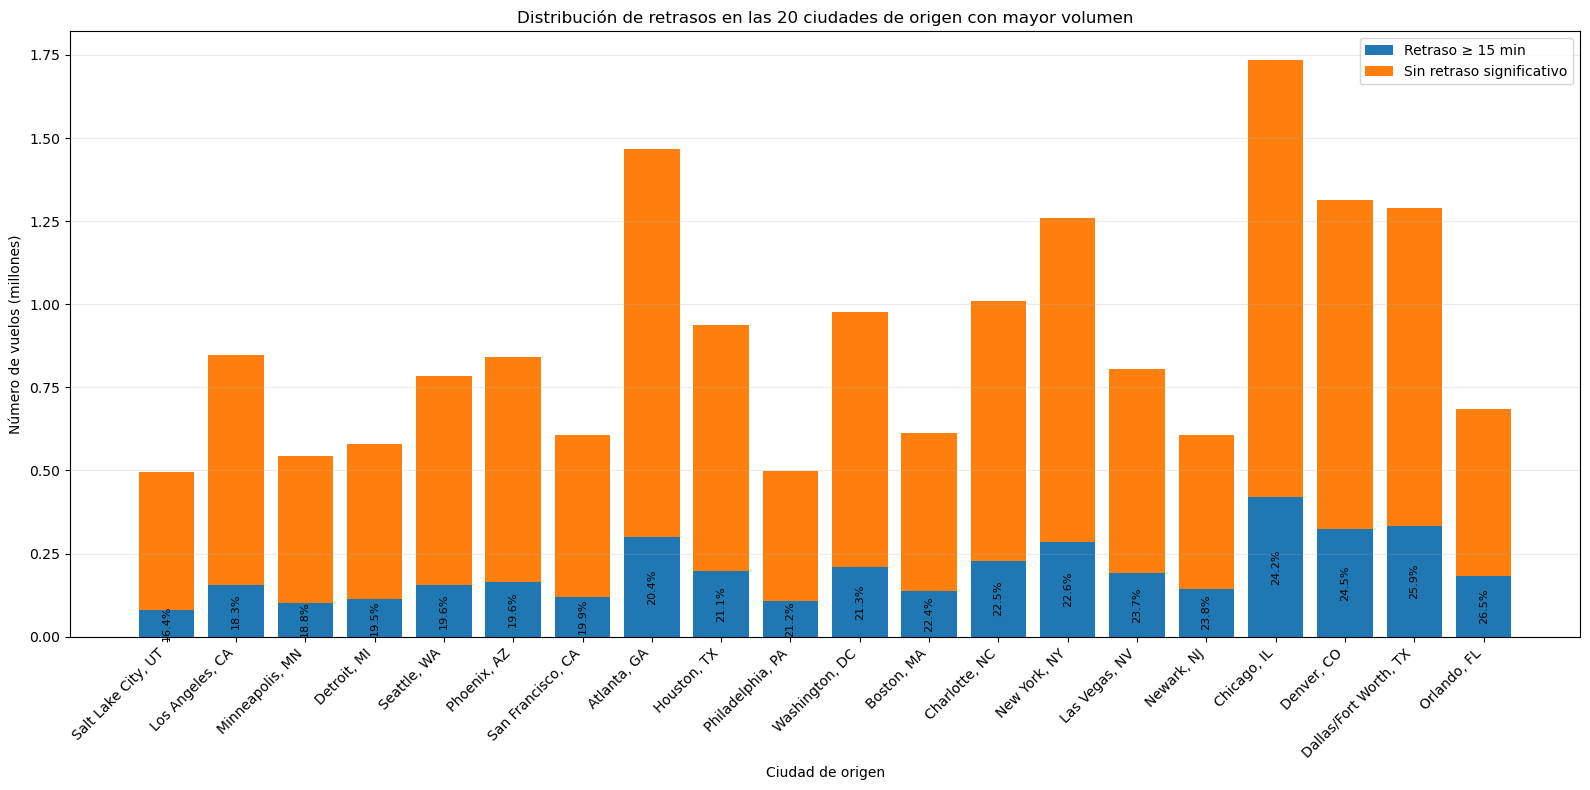

In [101]:
# ---------------------------------------------------------
# 1. Inicialización del acumulador
# ---------------------------------------------------------

origin_city_delay_stats = defaultdict(
    lambda: [0, 0]
)


# ---------------------------------------------------------
# 2. Procesamiento incremental de los Parquet
# ---------------------------------------------------------

for file_number, parquet_file in enumerate(
    parquet_files,
    start=1
):

    temp_df = pd.read_parquet(
        parquet_file,
        columns=[
            "ORIGIN_CITY_NAME",
            "ARR_DEL15"
        ]
    )


    # -----------------------------------------------------
    # 3. Mantener únicamente vuelos con target válida
    # -----------------------------------------------------

    valid_df = temp_df[
        temp_df["ARR_DEL15"].notna()
    ]


    # -----------------------------------------------------
    # 4. Agregación dentro de cada archivo
    # -----------------------------------------------------

    city_stats = (
        valid_df
        .groupby(
            "ORIGIN_CITY_NAME",
            observed=True
        )["ARR_DEL15"]
        .agg(
            VALID_FLIGHTS="count",
            DELAYED_FLIGHTS="sum"
        )
    )


    # -----------------------------------------------------
    # 5. Acumular resultados sobre todo el histórico
    # -----------------------------------------------------

    for city, row in city_stats.iterrows():

        origin_city_delay_stats[
            city
        ][0] += int(
            row["VALID_FLIGHTS"]
        )

        origin_city_delay_stats[
            city
        ][1] += int(
            row["DELAYED_FLIGHTS"]
        )


    # -----------------------------------------------------
    # 6. Seguimiento del procesamiento
    # -----------------------------------------------------

    if (
        file_number % 50 == 0
        or file_number == len(parquet_files)
    ):

        print(
            f"Procesados "
            f"{file_number}/"
            f"{len(parquet_files)} "
            f"archivos"
        )


# ---------------------------------------------------------
# 7. Construcción de la tabla resumen
# ---------------------------------------------------------

origin_city_delay_df = pd.DataFrame(
    [
        {
            "ORIGIN_CITY_NAME": city,
            "VALID_FLIGHTS": values[0],
            "DELAYED_FLIGHTS": values[1]
        }
        for city, values
        in origin_city_delay_stats.items()
    ]
)


# ---------------------------------------------------------
# 8. Vuelos sin retraso significativo
# ---------------------------------------------------------

origin_city_delay_df[
    "NOT_DELAYED_FLIGHTS"
] = (
    origin_city_delay_df["VALID_FLIGHTS"]
    - origin_city_delay_df["DELAYED_FLIGHTS"]
)


# ---------------------------------------------------------
# 9. Tasa de retraso
# ---------------------------------------------------------

origin_city_delay_df[
    "DELAY_RATE"
] = (
    origin_city_delay_df["DELAYED_FLIGHTS"]
    / origin_city_delay_df["VALID_FLIGHTS"]
    * 100
).round(2)


# ---------------------------------------------------------
# 10. Tabla completa ordenada por volumen
# ---------------------------------------------------------

origin_city_delay_df = (
    origin_city_delay_df
    .sort_values(
        "VALID_FLIGHTS",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


display(
    origin_city_delay_df
)


# ---------------------------------------------------------
# 11. Seleccionar las 20 ciudades con mayor volumen
# ---------------------------------------------------------

origin_city_top20_df = (
    origin_city_delay_df
    .head(20)
    .copy()
)


# ---------------------------------------------------------
# 12. Dentro del Top 20, ordenar por tasa
# ---------------------------------------------------------

origin_city_top20_df = (
    origin_city_top20_df
    .sort_values(
        "DELAY_RATE"
    )
    .reset_index(
        drop=True
    )
)


# ---------------------------------------------------------
# 13. Conversión a millones solo para el gráfico
# ---------------------------------------------------------

origin_city_top20_df[
    "DELAYED_M"
] = (
    origin_city_top20_df["DELAYED_FLIGHTS"]
    / 1_000_000
)


origin_city_top20_df[
    "NOT_DELAYED_M"
] = (
    origin_city_top20_df["NOT_DELAYED_FLIGHTS"]
    / 1_000_000
)


# ---------------------------------------------------------
# 14. Gráfico de volumen + tasa
# ---------------------------------------------------------

plt.figure(
    figsize=(16, 8)
)


bars_delay = plt.bar(
    origin_city_top20_df[
        "ORIGIN_CITY_NAME"
    ],
    origin_city_top20_df[
        "DELAYED_M"
    ],
    label="Retraso ≥ 15 min"
)


plt.bar(
    origin_city_top20_df[
        "ORIGIN_CITY_NAME"
    ],
    origin_city_top20_df[
        "NOT_DELAYED_M"
    ],
    bottom=origin_city_top20_df[
        "DELAYED_M"
    ],
    label="Sin retraso significativo"
)


# ---------------------------------------------------------
# 15. Mostrar tasa dentro del segmento de retrasos
# ---------------------------------------------------------

for bar, rate in zip(
    bars_delay,
    origin_city_top20_df[
        "DELAY_RATE"
    ]
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height() / 2,

        f"{rate:.1f}%",

        ha="center",
        va="center",
        fontsize=8,
        rotation=90
    )


# ---------------------------------------------------------
# 16. Formato final
# ---------------------------------------------------------

plt.title(
    "Distribución de retrasos en las 20 ciudades de origen con mayor volumen"
)

plt.xlabel(
    "Ciudad de origen"
)

plt.ylabel(
    "Número de vuelos (millones)"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()


# ---------------------------------------------------------
# 17. Liberar variables temporales
# ---------------------------------------------------------

del temp_df
del valid_df

#### Interpretación

El análisis por ciudad de origen muestra diferencias relevantes en la incidencia de retrasos entre las principales ciudades del sistema aéreo estadounidense.

Entre las 20 ciudades con mayor volumen de vuelos se observa que Dallas/Fort Worth presenta una de las mayores tasas de retraso, con aproximadamente un 25.9 %, seguida de Orlando (26.5 % en la representación), Denver (24.5 %) y Chicago (24.2 %). Estas diferencias son especialmente relevantes porque se producen en ciudades con un volumen elevado de operaciones, por lo que no corresponden únicamente a tasas altas calculadas sobre un número reducido de vuelos.

En el extremo contrario, Salt Lake City presenta una tasa cercana al 16.4 %, mientras que Los Ángeles y Minneapolis se sitúan alrededor del 18 %. Atlanta destaca también por combinar uno de los mayores volúmenes de vuelos del conjunto analizado con una tasa relativamente moderada, cercana al 20.4 %.

El volumen de operaciones no parece explicar por sí solo la probabilidad de retraso. Ciudades con volúmenes similares presentan tasas diferentes, mientras que algunos de los principales centros de operación concentran simultáneamente un elevado número de vuelos y una incidencia relativamente alta de retrasos.

Estos resultados sugieren que la localización de origen puede contener información relevante para explicar la variable objetivo `ARR_DEL15`. No obstante, `ORIGIN_CITY_NAME` presenta una elevada cardinalidad y está estrechamente relacionada con variables geográficas ya analizadas, como `ORIGIN` y `ORIGIN_STATE_ABR`. Por tanto, su posible incorporación al modelo deberá evaluarse posteriormente teniendo en cuenta tanto su capacidad predictiva como la redundancia existente entre los diferentes niveles de información geográfica.

### 7.15 Retraso según la ciudad de destino

En este apartado se analiza la relación entre la ciudad de destino del vuelo (`DEST_CITY_NAME`) y la variable objetivo `ARR_DEL15`.

El análisis permite estudiar si la incidencia de retrasos presenta diferencias según la ciudad a la que se dirige el vuelo. Debido a la elevada cardinalidad de esta variable, la representación gráfica se centra en las 20 ciudades de destino con mayor volumen de vuelos válidos.

Para cada ciudad se calcula el número total de vuelos válidos, el número de vuelos con retraso significativo y la tasa de retraso correspondiente. Primero se seleccionan las ciudades con mayor volumen de operaciones y, posteriormente, este conjunto se ordena según la tasa de retraso para facilitar su comparación.

El procesamiento se realiza directamente sobre los archivos Parquet, utilizando únicamente las variables necesarias y acumulando los resultados de forma incremental para evitar cargar el conjunto completo de datos en memoria.

Procesados 50/354 archivos
Procesados 100/354 archivos
Procesados 150/354 archivos
Procesados 200/354 archivos
Procesados 250/354 archivos
Procesados 300/354 archivos
Procesados 350/354 archivos
Procesados 354/354 archivos


,DEST_CITY_NAME,VALID_FLIGHTS,DELAYED_FLIGHTS,NOT_DELAYED_FLIGHTS,DELAY_RATE
0,"Chicago, IL",1731506,373275,1358231,21.56
1,"Atlanta, GA",1466528,254129,1212399,17.33
2,"Denver, CO",1312047,272878,1039169,20.80
3,"Dallas/Fort Worth, TX",1286632,289068,997564,22.47
4,"New York, NY",1257389,285319,972070,22.69
...,...,...,...,...,...
371,"Owensboro, KY",127,33,94,25.98
372,"Branson, MO",47,18,29,38.30
373,"Wilmington, DE",42,17,25,40.48
374,"Ogden, UT",27,9,18,33.33


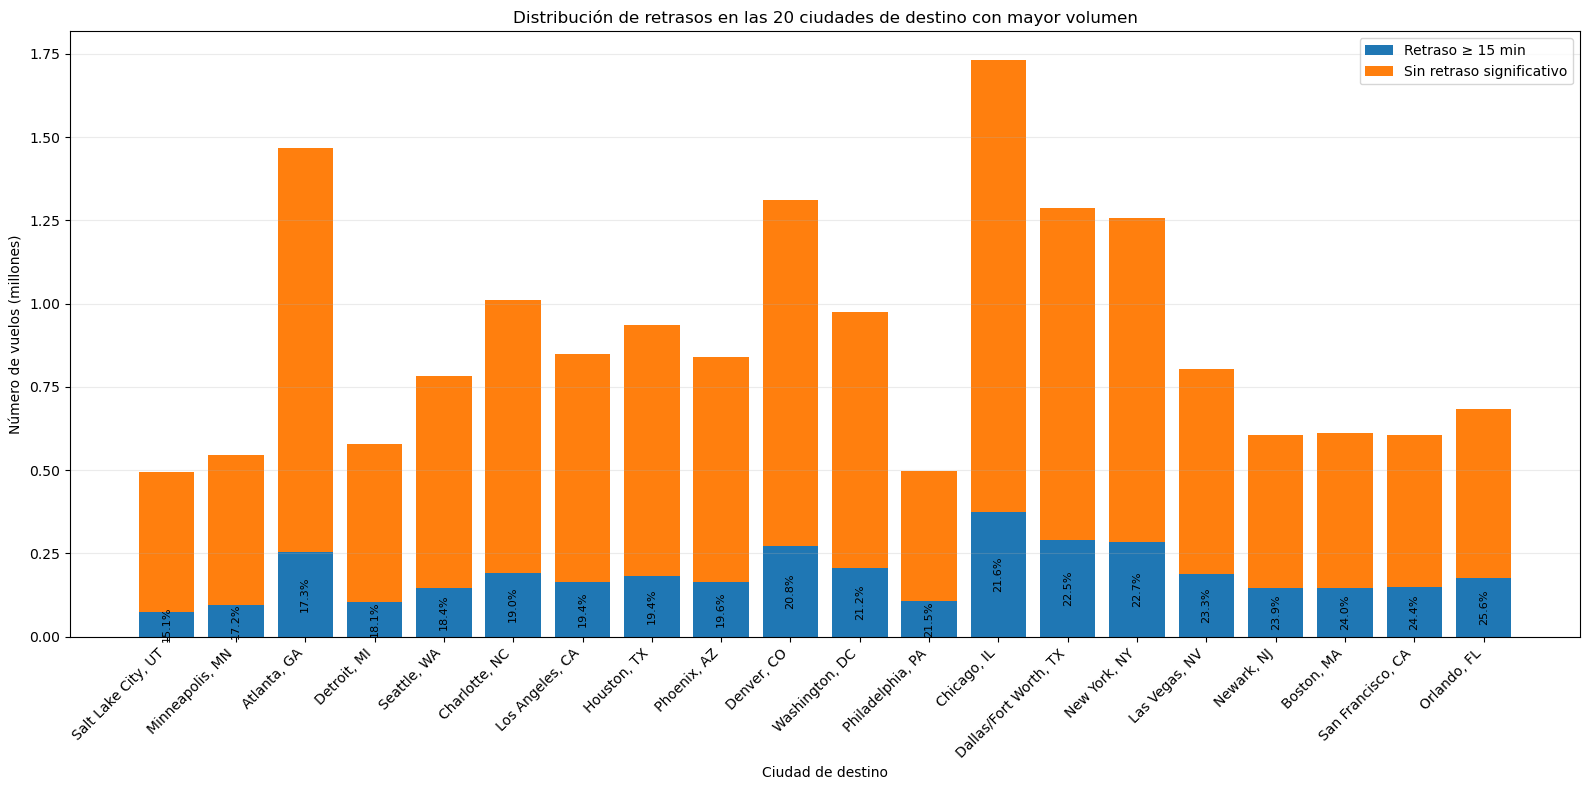

In [102]:
# ---------------------------------------------------------
# 1. Inicialización del acumulador
# ---------------------------------------------------------

dest_city_delay_stats = defaultdict(
    lambda: [0, 0]
)


# ---------------------------------------------------------
# 2. Procesamiento incremental de los Parquet
# ---------------------------------------------------------

for file_number, parquet_file in enumerate(
    parquet_files,
    start=1
):

    temp_df = pd.read_parquet(
        parquet_file,
        columns=[
            "DEST_CITY_NAME",
            "ARR_DEL15"
        ]
    )


    # -----------------------------------------------------
    # 3. Mantener únicamente vuelos con target válida
    # -----------------------------------------------------

    valid_df = temp_df[
        temp_df["ARR_DEL15"].notna()
    ]


    # -----------------------------------------------------
    # 4. Agregación dentro de cada archivo
    # -----------------------------------------------------

    city_stats = (
        valid_df
        .groupby(
            "DEST_CITY_NAME",
            observed=True
        )["ARR_DEL15"]
        .agg(
            VALID_FLIGHTS="count",
            DELAYED_FLIGHTS="sum"
        )
    )


    # -----------------------------------------------------
    # 5. Acumular resultados sobre todo el histórico
    # -----------------------------------------------------

    for city, row in city_stats.iterrows():

        dest_city_delay_stats[
            city
        ][0] += int(
            row["VALID_FLIGHTS"]
        )

        dest_city_delay_stats[
            city
        ][1] += int(
            row["DELAYED_FLIGHTS"]
        )


    # -----------------------------------------------------
    # 6. Seguimiento del procesamiento
    # -----------------------------------------------------

    if (
        file_number % 50 == 0
        or file_number == len(parquet_files)
    ):

        print(
            f"Procesados "
            f"{file_number}/"
            f"{len(parquet_files)} "
            f"archivos"
        )


# ---------------------------------------------------------
# 7. Construcción de la tabla resumen
# ---------------------------------------------------------

dest_city_delay_df = pd.DataFrame(
    [
        {
            "DEST_CITY_NAME": city,
            "VALID_FLIGHTS": values[0],
            "DELAYED_FLIGHTS": values[1]
        }
        for city, values
        in dest_city_delay_stats.items()
    ]
)


# ---------------------------------------------------------
# 8. Vuelos sin retraso significativo
# ---------------------------------------------------------

dest_city_delay_df[
    "NOT_DELAYED_FLIGHTS"
] = (
    dest_city_delay_df["VALID_FLIGHTS"]
    - dest_city_delay_df["DELAYED_FLIGHTS"]
)


# ---------------------------------------------------------
# 9. Tasa de retraso
# ---------------------------------------------------------

dest_city_delay_df[
    "DELAY_RATE"
] = (
    dest_city_delay_df["DELAYED_FLIGHTS"]
    / dest_city_delay_df["VALID_FLIGHTS"]
    * 100
).round(2)


# ---------------------------------------------------------
# 10. Tabla completa ordenada por volumen
# ---------------------------------------------------------

dest_city_delay_df = (
    dest_city_delay_df
    .sort_values(
        "VALID_FLIGHTS",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


display(
    dest_city_delay_df
)


# ---------------------------------------------------------
# 11. Seleccionar las 20 ciudades con mayor volumen
# ---------------------------------------------------------

dest_city_top20_df = (
    dest_city_delay_df
    .head(20)
    .copy()
)


# ---------------------------------------------------------
# 12. Dentro del Top 20, ordenar por tasa
# ---------------------------------------------------------

dest_city_top20_df = (
    dest_city_top20_df
    .sort_values(
        "DELAY_RATE"
    )
    .reset_index(
        drop=True
    )
)


# ---------------------------------------------------------
# 13. Conversión a millones solo para el gráfico
# ---------------------------------------------------------

dest_city_top20_df[
    "DELAYED_M"
] = (
    dest_city_top20_df["DELAYED_FLIGHTS"]
    / 1_000_000
)

dest_city_top20_df[
    "NOT_DELAYED_M"
] = (
    dest_city_top20_df["NOT_DELAYED_FLIGHTS"]
    / 1_000_000
)


# ---------------------------------------------------------
# 14. Gráfico de volumen + tasa
# ---------------------------------------------------------

plt.figure(
    figsize=(16, 8)
)


bars_delay = plt.bar(
    dest_city_top20_df[
        "DEST_CITY_NAME"
    ],
    dest_city_top20_df[
        "DELAYED_M"
    ],
    label="Retraso ≥ 15 min"
)


plt.bar(
    dest_city_top20_df[
        "DEST_CITY_NAME"
    ],
    dest_city_top20_df[
        "NOT_DELAYED_M"
    ],
    bottom=dest_city_top20_df[
        "DELAYED_M"
    ],
    label="Sin retraso significativo"
)


# ---------------------------------------------------------
# 15. Mostrar tasa dentro del segmento de retrasos
# ---------------------------------------------------------

for bar, rate in zip(
    bars_delay,
    dest_city_top20_df[
        "DELAY_RATE"
    ]
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height() / 2,

        f"{rate:.1f}%",

        ha="center",
        va="center",
        fontsize=8,
        rotation=90
    )


# ---------------------------------------------------------
# 16. Formato final
# ---------------------------------------------------------

plt.title(
    "Distribución de retrasos en las 20 ciudades de destino con mayor volumen"
)

plt.xlabel(
    "Ciudad de destino"
)

plt.ylabel(
    "Número de vuelos (millones)"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()


# ---------------------------------------------------------
# 17. Liberar variables temporales
# ---------------------------------------------------------

del temp_df
del valid_df

#### Interpretación

El análisis por ciudad de destino muestra diferencias relevantes en la incidencia de retrasos entre las principales ciudades del sistema aéreo analizado.

Entre las 20 ciudades con mayor volumen, Orlando presenta la tasa de retraso más elevada, con aproximadamente un 25.6 %, seguida de San Francisco (24.4 %), Boston (24.0 %), Newark (23.9 %) y Las Vegas (23.3 %). Estas ciudades presentan además un volumen considerable de operaciones, por lo que las tasas observadas se sustentan sobre un número elevado de vuelos.

En el extremo contrario, Salt Lake City presenta una tasa cercana al 15.1 %, mientras que Minneapolis y Atlanta muestran tasas del 17.2 % y 17.3 %, respectivamente. Atlanta resulta especialmente relevante debido a que combina uno de los mayores volúmenes de vuelos del conjunto con una tasa de retraso como destino relativamente reducida.

La comparación con el análisis de las ciudades de origen muestra además que el comportamiento no es necesariamente simétrico. Por ejemplo, Chicago presenta una tasa aproximada del 24.2 % cuando actúa como origen y del 21.6 % cuando actúa como destino. Atlanta pasa aproximadamente del 20.4 % como origen al 17.3 % como destino, mientras que Dallas/Fort Worth pasa del 25.9 % al 22.5 %. Esto indica que el efecto asociado a una localización puede depender de su papel como punto de salida o de llegada.

También aparecen tasas muy elevadas en ciudades con un número extremadamente reducido de observaciones. Por ejemplo, Bullhead City presenta una tasa del 100 %, pero esta corresponde a un único vuelo válido. Por este motivo, estas categorías no deben interpretarse como evidencia de un mayor riesgo de retraso y se justifica la utilización del volumen como criterio previo para realizar las comparaciones.

En conjunto, los resultados indican que la localización de destino contiene información potencialmente relacionada con `ARR_DEL15`. Sin embargo, `DEST_CITY_NAME` presenta una elevada cardinalidad y una fuerte relación con otras variables geográficas como `DEST` y `DEST_STATE_ABR`. Esta redundancia deberá considerarse posteriormente durante la selección y preparación de variables para el modelado.

### 7.16 Síntesis del análisis de la variable objetivo

El análisis realizado permite identificar varios patrones relevantes en la relación entre las características de los vuelos y la variable objetivo `ARR_DEL15`.

En primer lugar, la variable objetivo presenta un desbalance moderado. Aproximadamente el 78.93 % de los vuelos válidos no presentan un retraso significativo en la llegada, mientras que el 21.07 % presentan un retraso igual o superior a 15 minutos. La relación entre ambas clases es aproximadamente de 3.75 vuelos sin retraso significativo por cada vuelo retrasado. Este desequilibrio deberá tenerse en cuenta posteriormente tanto durante el entrenamiento como en la selección de las métricas de evaluación de los modelos.

Desde el punto de vista temporal, la tasa global de retraso se mantiene relativamente estable entre los distintos años analizados, aunque existen variaciones mensuales considerablemente mayores. Esto sugiere que la componente temporal de los retrasos está asociada principalmente a patrones de menor escala temporal y posiblemente estacionales, más que a una tendencia anual sostenida.

El día de la semana también presenta diferencias. Viernes y domingo muestran tasas de retraso superiores a otros días, mientras que martes presenta una incidencia considerablemente menor. Por tanto, el calendario semanal parece contener información relacionada con la probabilidad de retraso.

Uno de los patrones más claros aparece en la hora programada de salida. La tasa de retraso aumenta progresivamente a lo largo del día, pasando de valores cercanos al 10 % durante las primeras horas de la mañana a valores próximos al 30 % durante la tarde y primeras horas de la noche. Este comportamiento es compatible con la propagación de retrasos a medida que avanza la jornada y convierte a la información horaria en una variable potencialmente relevante para el modelado.

La distancia del vuelo también muestra diferencias, aunque su relación con el retraso no es estrictamente creciente. Los grupos intermedios presentan algunas de las tasas más elevadas, mientras que los vuelos de mayor distancia vuelven a situarse alrededor de valores próximos a la tasa global. Por tanto, la distancia puede aportar información, pero su relación con la variable objetivo parece ser no lineal.

Las aerolíneas presentan diferencias relevantes tanto a nivel comercial como operativo. Las tasas observadas varían de forma apreciable entre compañías incluso cuando existe un volumen elevado de vuelos. Esto indica que las características asociadas a la aerolínea pueden contener información útil para explicar la probabilidad de retraso.

El análisis geográfico también identifica diferencias entre aeropuertos, ciudades y estados. Estas diferencias aparecen tanto en origen como en destino y, además, el comportamiento de una misma localización no necesariamente es simétrico dependiendo de si actúa como punto de salida o de llegada.

No obstante, las variables geográficas presentan una elevada redundancia. Un aeropuerto determina en gran medida su ciudad y estado, por lo que utilizar simultáneamente `ORIGIN`, `ORIGIN_CITY_NAME` y `ORIGIN_STATE_ABR`, así como sus equivalentes de destino, podría introducir información repetida. Esta cuestión deberá evaluarse durante la selección y preparación de variables.

Asimismo, algunas variables presentan una elevada cardinalidad. El caso más extremo es `TAIL_NUM`, con miles de aeronaves diferentes. Aunque este tipo de variable puede contener información relacionada con características específicas de las aeronaves, su incorporación directa al modelo puede aumentar considerablemente la dimensionalidad y favorecer patrones excesivamente específicos.

Finalmente, el análisis confirma que las tasas calculadas sobre categorías con muy pocas observaciones pueden alcanzar valores extremos sin representar necesariamente un patrón generalizable. Por este motivo, durante el análisis se ha considerado conjuntamente la tasa de retraso y el volumen de vuelos, evitando interpretar porcentajes elevados de categorías con una frecuencia muy reducida.

En conjunto, el análisis exploratorio muestra que la probabilidad de retraso no depende de una única característica, sino de una combinación de factores temporales, operativos, geográficos y relacionados con la aerolínea. Estos resultados proporcionan la base para la siguiente etapa del proyecto, en la que será necesario determinar qué variables pueden utilizarse realmente en el momento de realizar la predicción, eliminar información redundante o potencialmente causante de fuga de información y definir las transformaciones necesarias antes del entrenamiento de los modelos.

## 8. Revisión de variables para el modelado

Una vez finalizado el análisis exploratorio, el siguiente paso consiste en evaluar qué variables pueden utilizarse de forma adecuada para construir el modelo predictivo.

La selección de variables no debe basarse únicamente en las relaciones observadas con `ARR_DEL15`. También es necesario considerar el momento en el que cada variable está disponible, la posible existencia de información futura, la redundancia entre variables y la complejidad asociada a variables categóricas de elevada cardinalidad.

El objetivo de este bloque es realizar una selección conceptual y justificada de las variables que podrán formar parte del posterior dataset de modelado. En esta etapa todavía no se aplicarán técnicas de codificación, escalado ni entrenamiento de modelos.

### 8.1 Definición del momento de predicción

Antes de seleccionar las variables predictoras es necesario establecer el momento en el que se realizará la predicción, ya que este determina qué información puede considerarse disponible para el modelo.

En este trabajo se plantea predecir si un vuelo llegará a su destino con un retraso igual o superior a 15 minutos antes de que el vuelo inicie su operación. Por tanto, únicamente deberán utilizarse como predictores variables cuya información sea conocida con anterioridad a la salida del vuelo.

Este criterio permite plantear un escenario predictivo realista. Variables como la fecha del vuelo, el día de la semana, la aerolínea, los aeropuertos de origen y destino, los horarios programados o la distancia prevista del trayecto pueden conocerse antes de la operación y, por tanto, son potencialmente utilizables.

Por el contrario, las variables que describen acontecimientos ocurridos durante o después de la operación, como los horarios reales, el retraso real de salida o llegada, el tiempo real de vuelo o las causas finales del retraso, contienen información que no estaría disponible en el momento de realizar la predicción. Su utilización podría producir data leakage y generar una estimación artificialmente optimista del rendimiento del modelo.

A partir de este criterio temporal se revisarán las variables disponibles en el dataset antes de definir el conjunto definitivo de predictores.

### 8.2 Identificación de posibles variables con data leakage

Una vez establecido el momento de predicción, se revisan las variables disponibles para identificar aquellas cuya información se genera durante o después de la operación del vuelo.

Estas variables pueden provocar data leakage, ya que proporcionarían al modelo información que no estaría disponible en una predicción realizada antes de la salida. Su inclusión podría producir métricas de rendimiento artificialmente elevadas y una estimación poco realista de la capacidad predictiva del modelo.

Como primer paso se obtiene el esquema real de los archivos Parquet. Esta operación permite conocer todas las variables disponibles sin necesidad de cargar nuevamente el conjunto completo de datos en memoria.

A partir de esta información, las variables se clasificarán posteriormente según su disponibilidad temporal y su posible utilización en el modelo.

In [103]:
# Identificación de las variables disponibles


# ---------------------------------------------------------
# 1. Leer el esquema de uno de los archivos Parquet
# ---------------------------------------------------------

import pyarrow.parquet as pq


schema = pq.read_schema(
    parquet_files[0]
)


# ---------------------------------------------------------
# 2. Obtener los nombres de las variables
# ---------------------------------------------------------

available_columns = schema.names


# ---------------------------------------------------------
# 3. Resumen
# ---------------------------------------------------------

print(
    f"Número total de variables: "
    f"{len(available_columns)}"
)


# ---------------------------------------------------------
# 4. Mostrar todas las variables disponibles
# ---------------------------------------------------------

for i, column in enumerate(
    available_columns,
    start=1
):

    print(
        f"{i:02d}. {column}"
    )

Número total de variables: 45
01. FL_DATE
02. YEAR
03. QUARTER
04. MONTH
05. DAY_OF_MONTH
06. DAY_OF_WEEK
07. MKT_UNIQUE_CARRIER
08. OP_UNIQUE_CARRIER
09. TAIL_NUM
10. OP_CARRIER_FL_NUM
11. ORIGIN_AIRPORT_ID
12. ORIGIN
13. ORIGIN_CITY_NAME
14. ORIGIN_STATE_ABR
15. DEST_AIRPORT_ID
16. DEST
17. DEST_CITY_NAME
18. DEST_STATE_ABR
19. CRS_DEP_TIME
20. DEP_TIME
21. DEP_DELAY
22. DEP_DELAY_NEW
23. DEP_DEL15
24. DEP_TIME_BLK
25. TAXI_OUT
26. TAXI_IN
27. CRS_ARR_TIME
28. ARR_TIME
29. ARR_DELAY
30. ARR_DELAY_NEW
31. ARR_DEL15
32. ARR_TIME_BLK
33. CANCELLED
34. CANCELLATION_CODE
35. DIVERTED
36. CRS_ELAPSED_TIME
37. ACTUAL_ELAPSED_TIME
38. AIR_TIME
39. DISTANCE
40. DISTANCE_GROUP
41. CARRIER_DELAY
42. WEATHER_DELAY
43. NAS_DELAY
44. SECURITY_DELAY
45. LATE_AIRCRAFT_DELAY


### 8.2 Identificación de posibles variables con data leakage

A partir de las 45 variables disponibles se realiza una clasificación según el momento en el que su información estaría disponible respecto al instante definido para la predicción: antes de que el vuelo inicie su operación.

Las variables asociadas a la planificación del vuelo pueden considerarse potencialmente utilizables, ya que su valor se conoce con anterioridad a la salida. En este grupo se encuentran las variables temporales programadas, la aerolínea, el origen y destino, los horarios programados y las características previstas del trayecto.

Por el contrario, las variables que describen acontecimientos observados durante o después de la operación deben excluirse del conjunto de predictores. Entre ellas se encuentran la hora real de salida, el retraso de salida, los tiempos de rodaje, la hora y retraso reales de llegada, los tiempos reales de vuelo y los componentes que explican posteriormente las causas del retraso.

La variable `ARR_DEL15` constituye la variable objetivo y, por tanto, tampoco puede formar parte del conjunto de predictores.

Finalmente, algunas variables requieren una revisión independiente. Los identificadores y las variables de elevada cardinalidad no constituyen necesariamente data leakage, pero su utilización directa puede introducir una complejidad elevada, redundancia o patrones excesivamente específicos.

Esta clasificación permite separar el problema de data leakage de otras decisiones posteriores relacionadas con redundancia, cardinalidad y selección de variables.

In [104]:
# Clasificación inicial de las variables disponibles


# ---------------------------------------------------------
# 1. Variables potencialmente disponibles antes de la salida
# ---------------------------------------------------------

preflight_variables = [
    "FL_DATE",
    "YEAR",
    "QUARTER",
    "MONTH",
    "DAY_OF_MONTH",
    "DAY_OF_WEEK",
    "MKT_UNIQUE_CARRIER",
    "OP_UNIQUE_CARRIER",
    "OP_CARRIER_FL_NUM",
    "ORIGIN_AIRPORT_ID",
    "ORIGIN",
    "ORIGIN_CITY_NAME",
    "ORIGIN_STATE_ABR",
    "DEST_AIRPORT_ID",
    "DEST",
    "DEST_CITY_NAME",
    "DEST_STATE_ABR",
    "CRS_DEP_TIME",
    "DEP_TIME_BLK",
    "CRS_ARR_TIME",
    "ARR_TIME_BLK",
    "CRS_ELAPSED_TIME",
    "DISTANCE",
    "DISTANCE_GROUP"
]


# ---------------------------------------------------------
# 2. Variables con información conocida durante o
#    después de la operación
# ---------------------------------------------------------

leakage_variables = [
    "DEP_TIME",
    "DEP_DELAY",
    "DEP_DELAY_NEW",
    "DEP_DEL15",
    "TAXI_OUT",
    "TAXI_IN",
    "ARR_TIME",
    "ARR_DELAY",
    "ARR_DELAY_NEW",
    "ACTUAL_ELAPSED_TIME",
    "AIR_TIME",
    "CARRIER_DELAY",
    "WEATHER_DELAY",
    "NAS_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY"
]


# ---------------------------------------------------------
# 3. Variable objetivo
# ---------------------------------------------------------

target_variable = [
    "ARR_DEL15"
]


# ---------------------------------------------------------
# 4. Variables que requieren revisión específica
# ---------------------------------------------------------

review_variables = [
    "TAIL_NUM",
    "CANCELLED",
    "CANCELLATION_CODE",
    "DIVERTED"
]


# ---------------------------------------------------------
# 5. Construcción de la tabla de clasificación
# ---------------------------------------------------------

classification_rows = []

for variable in available_columns:

    if variable in preflight_variables:

        classification = "Potencialmente utilizable"

    elif variable in leakage_variables:

        classification = "Data leakage"

    elif variable in target_variable:

        classification = "Variable objetivo"

    elif variable in review_variables:

        classification = "Revisar"

    else:

        classification = "Sin clasificar"

    classification_rows.append(
        {
            "VARIABLE": variable,
            "CLASSIFICATION": classification
        }
    )


variable_classification_df = pd.DataFrame(
    classification_rows
)


# ---------------------------------------------------------
# 6. Mostrar clasificación completa
# ---------------------------------------------------------

display(
    variable_classification_df
)


# ---------------------------------------------------------
# 7. Resumen por clasificación
# ---------------------------------------------------------

classification_summary_df = (
    variable_classification_df
    .groupby("CLASSIFICATION")
    .size()
    .reset_index(name="VARIABLES")
    .sort_values(
        "VARIABLES",
        ascending=False
    )
    .reset_index(drop=True)
)


display(
    classification_summary_df
)


# ---------------------------------------------------------
# 8. Comprobación de cobertura
# ---------------------------------------------------------

print(
    f"Variables originales : "
    f"{len(available_columns)}"
)

print(
    f"Variables clasificadas: "
    f"{len(variable_classification_df)}"
)

print(
    f"Sin clasificar        : "
    f"{(variable_classification_df['CLASSIFICATION'] == 'Sin clasificar').sum()}"
)

,VARIABLE,CLASSIFICATION
0,FL_DATE,Potencialmente utilizable
1,YEAR,Potencialmente utilizable
2,QUARTER,Potencialmente utilizable
3,MONTH,Potencialmente utilizable
4,DAY_OF_MONTH,Potencialmente utilizable
5,DAY_OF_WEEK,Potencialmente utilizable
6,MKT_UNIQUE_CARRIER,Potencialmente utilizable
7,OP_UNIQUE_CARRIER,Potencialmente utilizable
8,TAIL_NUM,Revisar
9,OP_CARRIER_FL_NUM,Potencialmente utilizable


,CLASSIFICATION,VARIABLES
0,Potencialmente utilizable,24
1,Data leakage,16
2,Revisar,4
3,Variable objetivo,1


Variables originales : 45
Variables clasificadas: 45
Sin clasificar        : 0


#### Interpretación

La clasificación inicial permite separar las 45 variables disponibles según su utilidad potencial para un escenario de predicción realizado antes de la salida del vuelo.

Del total de variables, 24 se consideran potencialmente utilizables porque su información puede conocerse antes de que el vuelo inicie su operación. En este grupo se encuentran las variables temporales, las aerolíneas, los aeropuertos y localizaciones de origen y destino, los horarios programados y las características previstas del trayecto.

Por otra parte, 16 variables se clasifican como posibles fuentes de data leakage. Estas variables describen acontecimientos observados durante o después de la operación, como el retraso real de salida, los tiempos de rodaje, la hora real de llegada, el retraso de llegada, el tiempo real de vuelo o las causas finales asociadas al retraso. Aunque algunas de ellas podrían presentar una relación elevada con `ARR_DEL15`, no serían conocidas en el momento definido para realizar la predicción y, por tanto, su utilización produciría una evaluación artificialmente optimista del modelo.

`ARR_DEL15` se identifica correctamente como la única variable objetivo y queda separada del conjunto de predictores.

Cuatro variables se mantienen inicialmente en revisión: `TAIL_NUM`, `CANCELLED`, `CANCELLATION_CODE` y `DIVERTED`. `TAIL_NUM` puede conocerse antes de la salida, pero presenta una cardinalidad elevada y podría introducir patrones excesivamente específicos asociados a aeronaves concretas. Las variables relacionadas con cancelaciones y desvíos requieren un tratamiento diferente, ya que están estrechamente vinculadas con la disponibilidad de `ARR_DEL15` y con la definición de la población utilizada para el modelado.

La comprobación final confirma que las 45 variables originales han sido clasificadas y que no quedan variables sin asignar. Esto proporciona una base consistente para continuar con la revisión de identificadores, cardinalidad, redundancia y utilidad predictiva antes de establecer el conjunto definitivo de variables de entrada.

### 8.3 Revisión de variables identificadoras y de alta cardinalidad

Una vez excluidas conceptualmente las variables que presentan riesgo de data leakage, es necesario revisar aquellas variables que, aun estando potencialmente disponibles antes de la salida, pueden presentar problemas debido a su naturaleza identificadora o a su elevada cardinalidad.

Las variables con un número elevado de categorías pueden incrementar considerablemente la complejidad del posterior proceso de codificación y favorecer la aparición de patrones excesivamente específicos. Este aspecto resulta especialmente relevante cuando una categoría representa una entidad concreta, como una aeronave o un número de vuelo, en lugar de una característica general de la operación.

En este apartado se revisan `TAIL_NUM` y `OP_CARRIER_FL_NUM`. La primera identifica la aeronave asignada al vuelo y ya mostró una cardinalidad elevada durante el análisis exploratorio. La segunda representa el número de vuelo utilizado por la aerolínea operadora y también puede comportarse como un identificador operativo.

El objetivo no es eliminar automáticamente estas variables por presentar una elevada cardinalidad, sino cuantificar su número de valores distintos, frecuencia relativa y concentración antes de decidir si su incorporación al modelo está suficientemente justificada.

In [105]:
# Revisión de variables identificadoras y de alta cardinalidad


# ---------------------------------------------------------
# 1. Variables que requieren revisión
# ---------------------------------------------------------

identifier_variables = [
    "TAIL_NUM",
    "OP_CARRIER_FL_NUM"
]


# ---------------------------------------------------------
# 2. Inicialización de acumuladores
# ---------------------------------------------------------

identifier_counts = {
    variable: {}
    for variable in identifier_variables
}

identifier_valid = {
    variable: 0
    for variable in identifier_variables
}

identifier_missing = {
    variable: 0
    for variable in identifier_variables
}


# ---------------------------------------------------------
# 3. Procesamiento incremental de los Parquet
# ---------------------------------------------------------

for file_number, parquet_file in enumerate(
    parquet_files,
    start=1
):

    temp_df = pd.read_parquet(
        parquet_file,
        columns=identifier_variables
    )


    for variable in identifier_variables:

        identifier_valid[variable] += (
            temp_df[variable]
            .notna()
            .sum()
        )

        identifier_missing[variable] += (
            temp_df[variable]
            .isna()
            .sum()
        )

        value_counts = (
            temp_df[variable]
            .value_counts()
        )

        for category, count in value_counts.items():

            identifier_counts[variable][category] = (
                identifier_counts[variable]
                .get(
                    category,
                    0
                )
                + int(count)
            )


    if (
        file_number % 50 == 0
        or file_number == len(parquet_files)
    ):

        print(
            f"Procesados "
            f"{file_number}/"
            f"{len(parquet_files)} "
            f"archivos"
        )


# ---------------------------------------------------------
# 4. Construcción de la tabla resumen
# ---------------------------------------------------------

identifier_summary = []

for variable in identifier_variables:

    counts = identifier_counts[
        variable
    ]

    valid = identifier_valid[
        variable
    ]

    missing = identifier_missing[
        variable
    ]

    total = (
        valid
        + missing
    )

    top_count = max(
        counts.values()
    )

    identifier_summary.append(
        {
            "VARIABLE": variable,
            "VALID": valid,
            "MISSING": missing,
            "MISSING_PERCENTAGE": round(
                missing
                / total
                * 100,
                3
            ),
            "CARDINALITY": len(
                counts
            ),
            "TOP_1_PERCENTAGE": round(
                top_count
                / valid
                * 100,
                3
            )
        }
    )


identifier_summary_df = pd.DataFrame(
    identifier_summary
)


# ---------------------------------------------------------
# 5. Mostrar resultados
# ---------------------------------------------------------

display(
    identifier_summary_df
)

Procesados 50/354 archivos
Procesados 100/354 archivos
Procesados 150/354 archivos
Procesados 200/354 archivos
Procesados 250/354 archivos
Procesados 300/354 archivos
Procesados 350/354 archivos
Procesados 354/354 archivos


,VARIABLE,VALID,MISSING,MISSING_PERCENTAGE,CARDINALITY,TOP_1_PERCENTAGE
0,TAIL_NUM,32643269,117860,0.36,7492,0.037
1,OP_CARRIER_FL_NUM,32761128,1,0.00,7083,0.039


#### Interpretación

Los resultados muestran que tanto `TAIL_NUM` como `OP_CARRIER_FL_NUM` presentan una cardinalidad muy elevada en relación con el resto de las variables disponibles.

`TAIL_NUM` contiene 7,492 valores distintos y presenta únicamente un 0.36 % de valores ausentes. Sin embargo, la categoría más frecuente representa apenas el 0.037 % de los registros válidos. Esto confirma que la variable funciona principalmente como un identificador de aeronaves individuales y que su distribución se encuentra muy fragmentada entre miles de categorías.

De forma similar, `OP_CARRIER_FL_NUM` presenta 7,083 valores distintos, prácticamente sin valores ausentes, y su valor más frecuente representa solamente el 0.039 % de los vuelos. Aunque el número de vuelo puede contener cierta información relacionada con rutas u operaciones recurrentes, su utilización directa introduciría miles de categorías y podría favorecer el aprendizaje de patrones excesivamente específicos asociados a determinados vuelos.

La incorporación directa de estas variables mediante una codificación categórica convencional incrementaría considerablemente la dimensionalidad del espacio de predictores. Además, parte de la información contenida en `OP_CARRIER_FL_NUM` puede estar representada de forma más generalizable mediante variables como la aerolínea, el origen, el destino y los horarios programados.

Por estos motivos, `TAIL_NUM` y `OP_CARRIER_FL_NUM` no se consideran inicialmente adecuadas como variables predictoras directas y se propone excluirlas del conjunto base de modelado.

Esta decisión no implica que ambas variables carezcan completamente de información predictiva. En desarrollos posteriores podrían utilizarse para construir características agregadas obtenidas exclusivamente a partir del conjunto de entrenamiento, como el comportamiento histórico de una aeronave o de un número de vuelo. Sin embargo, este tipo de ingeniería de características queda fuera de la selección inicial realizada en este notebook.

### 8.4 Revisión de redundancia entre variables

Una vez identificadas las variables con riesgo de data leakage y aquellas con comportamiento próximo a un identificador, es necesario revisar la posible redundancia entre las variables que permanecen como candidatas para el modelado.

El dataset contiene diferentes representaciones de una misma dimensión de información. Este fenómeno aparece especialmente en las variables temporales, geográficas y relacionadas con la programación del vuelo. Mantener simultáneamente todas estas representaciones podría introducir información repetida y aumentar innecesariamente la complejidad del conjunto de predictores.

En las variables geográficas, el aeropuerto, la ciudad y el estado representan distintos niveles de agregación de una misma localización. Los análisis realizados anteriormente mostraron diferencias en las tasas de retraso en los tres niveles, pero también evidenciaron una relación estructural entre estas variables.

De forma similar, algunas variables temporales pueden derivarse directamente de otras. La fecha del vuelo contiene información sobre el año, mes y día, mientras que las franjas horarias representan una agrupación de los horarios programados.

En este apartado se identifican estos grupos de variables potencialmente redundantes. La finalidad no es eliminar automáticamente todas las variables relacionadas, sino establecer una representación inicial coherente que reduzca duplicidades antes de construir el dataset destinado al modelado.

In [106]:
# Revisión de redundancia entre variables


# ---------------------------------------------------------
# 1. Definición de los grupos de variables relacionadas
# ---------------------------------------------------------

redundancy_groups = [
    {
        "GROUP": "Fecha",
        "VARIABLES": "FL_DATE, YEAR, QUARTER, MONTH, DAY_OF_MONTH",
        "INITIAL_REPRESENTATION": "YEAR, MONTH, DAY_OF_MONTH",
        "DECISION": "Revisar"
    },
    {
        "GROUP": "Origen",
        "VARIABLES": (
            "ORIGIN_AIRPORT_ID, ORIGIN, "
            "ORIGIN_CITY_NAME, ORIGIN_STATE_ABR"
        ),
        "INITIAL_REPRESENTATION": "ORIGIN",
        "DECISION": "Mantener representación única"
    },
    {
        "GROUP": "Destino",
        "VARIABLES": (
            "DEST_AIRPORT_ID, DEST, "
            "DEST_CITY_NAME, DEST_STATE_ABR"
        ),
        "INITIAL_REPRESENTATION": "DEST",
        "DECISION": "Mantener representación única"
    },
    {
        "GROUP": "Hora de salida",
        "VARIABLES": "CRS_DEP_TIME, DEP_TIME_BLK",
        "INITIAL_REPRESENTATION": "DEP_TIME_BLK",
        "DECISION": "Mantener representación agrupada"
    },
    {
        "GROUP": "Hora de llegada",
        "VARIABLES": "CRS_ARR_TIME, ARR_TIME_BLK",
        "INITIAL_REPRESENTATION": "ARR_TIME_BLK",
        "DECISION": "Mantener representación agrupada"
    },
    {
        "GROUP": "Distancia",
        "VARIABLES": "DISTANCE, DISTANCE_GROUP",
        "INITIAL_REPRESENTATION": "DISTANCE",
        "DECISION": "Mantener representación continua"
    }
]


# ---------------------------------------------------------
# 2. Construcción de la tabla resumen
# ---------------------------------------------------------

redundancy_df = pd.DataFrame(
    redundancy_groups
)


# ---------------------------------------------------------
# 3. Mostrar resultados
# ---------------------------------------------------------

display(
    redundancy_df
)

,GROUP,VARIABLES,INITIAL_REPRESENTATION,DECISION
0,Fecha,"FL_DATE, YEAR, QUARTER, MONTH, DAY_OF_MONTH","YEAR, MONTH, DAY_OF_MONTH",Revisar
1,Origen,"ORIGIN_AIRPORT_ID, ORIGIN, ORIGIN_CITY_NAME, O...",ORIGIN,Mantener representación única
2,Destino,"DEST_AIRPORT_ID, DEST, DEST_CITY_NAME, DEST_ST...",DEST,Mantener representación única
3,Hora de salida,"CRS_DEP_TIME, DEP_TIME_BLK",DEP_TIME_BLK,Mantener representación agrupada
4,Hora de llegada,"CRS_ARR_TIME, ARR_TIME_BLK",ARR_TIME_BLK,Mantener representación agrupada
5,Distancia,"DISTANCE, DISTANCE_GROUP",DISTANCE,Mantener representación continua


#### Interpretación

La revisión permite identificar varios grupos de variables que representan información parcialmente redundante y cuya utilización simultánea podría aumentar innecesariamente la complejidad del conjunto de predictores.

En las variables geográficas se dispone de diferentes niveles de representación para una misma localización. Para el origen aparecen el identificador del aeropuerto, el código del aeropuerto, la ciudad y el estado, mientras que en el destino se reproduce la misma estructura. Como representación inicial se propone conservar `ORIGIN` y `DEST`, ya que permiten identificar directamente los aeropuertos y mantienen un mayor nivel de detalle que las variables de ciudad o estado. De esta forma se evita incorporar simultáneamente diferentes representaciones categóricas de una misma localización.

Las variables relacionadas con los horarios también presentan información redundante. `CRS_DEP_TIME` y `DEP_TIME_BLK` representan el horario programado de salida con distintos niveles de granularidad, al igual que `CRS_ARR_TIME` y `ARR_TIME_BLK` para la llegada. Como representación inicial se mantienen las franjas horarias, ya que proporcionan una categorización directamente interpretable y el análisis exploratorio mostró diferencias claras en la tasa de retraso entre estos intervalos.

En el caso de la distancia, `DISTANCE_GROUP` constituye una discretización de `DISTANCE`. Se propone conservar inicialmente `DISTANCE`, puesto que mantiene la información original de la distancia del trayecto y evita la pérdida de información producida por la agrupación en intervalos.

Las variables relacionadas con la fecha requieren una consideración diferente. `FL_DATE`, `YEAR`, `QUARTER`, `MONTH` y `DAY_OF_MONTH` contienen información temporal relacionada, pero no completamente equivalente. `QUARTER`, por ejemplo, puede obtenerse directamente a partir de `MONTH`, mientras que `YEAR` resulta relevante para conservar la dimensión temporal del periodo analizado. Por este motivo, este grupo se mantiene en revisión hasta establecer la representación temporal definitiva del dataset de modelado.

Esta revisión permite reducir redundancias sin eliminar dimensiones de información potencialmente relevantes. Las decisiones adoptadas tienen carácter inicial y podrán ajustarse posteriormente dentro del proceso de modelado, utilizando únicamente la información correspondiente al conjunto de entrenamiento cuando la decisión requiera estimación a partir de los datos.

### 8.5 Revisión de variables asociadas a cancelaciones y desvíos

Las variables `CANCELLED`, `CANCELLATION_CODE` y `DIVERTED` se mantuvieron inicialmente en revisión debido a su relación directa con la disponibilidad de la variable objetivo `ARR_DEL15`.

El análisis realizado anteriormente mostró que los valores ausentes de `ARR_DEL15` están prácticamente determinados por vuelos cancelados o desviados. Por este motivo, estas variables no deben tratarse como predictores convencionales dentro del escenario definido para realizar la predicción antes de la salida del vuelo.

En este apartado se reutilizan los resultados obtenidos previamente para revisar su papel en la definición de la población de modelado y justificar su exclusión del conjunto inicial de predictores.

In [107]:
# Revisión de variables asociadas a cancelaciones y desvíos


# ---------------------------------------------------------
# 1. Recuperar los resultados obtenidos previamente
# ---------------------------------------------------------

cancellation_diversion_review_df = (
    target_validation_df
    .copy()
)


# ---------------------------------------------------------
# 2. Mostrar la relación entre ARR_DEL15 ausente
#    y cancelaciones o desvíos
# ---------------------------------------------------------

display(
    cancellation_diversion_review_df
)


# ---------------------------------------------------------
# 3. Recuperar la disponibilidad global de la target
# ---------------------------------------------------------

target_availability_review_df = (
    target_availability_df
    .copy()
)


# ---------------------------------------------------------
# 4. Mostrar la disponibilidad de ARR_DEL15
# ---------------------------------------------------------

display(
    target_availability_review_df
)


# ---------------------------------------------------------
# 5. Construcción de la tabla de decisión
# ---------------------------------------------------------

operational_variables_review_df = pd.DataFrame(
    {
        "VARIABLE": [
            "CANCELLED",
            "CANCELLATION_CODE",
            "DIVERTED"
        ],
        "DECISION": [
            "Excluir como predictor",
            "Excluir como predictor",
            "Excluir como predictor"
        ],
        "REASON": [
            (
                "Resultado operativo asociado a vuelos "
                "sin ARR_DEL15 observable"
            ),
            (
                "Solo aplica a vuelos cancelados y no "
                "está disponible antes de la operación"
            ),
            (
                "Resultado operativo asociado a vuelos "
                "sin ARR_DEL15 observable"
            )
        ]
    }
)


# ---------------------------------------------------------
# 6. Mostrar la decisión
# ---------------------------------------------------------

display(
    operational_variables_review_df
)

,SITUATION,COUNT,PERCENTAGE_OF_MISSING
0,ARR_DEL15 ausente,662088,100.000
1,Ausente y cancelado,579552,87.534
2,Ausente y desviado,82533,12.466
3,Ausente y cancelado o desviado,662085,100.000
4,"Ausente, no cancelado ni desviado",3,0.000


,TARGET_STATUS,COUNT,PERCENTAGE
0,ARR_DEL15 válida,32099041,97.979
1,ARR_DEL15 ausente,662088,2.021


,VARIABLE,DECISION,REASON
0,CANCELLED,Excluir como predictor,Resultado operativo asociado a vuelos sin ARR_...
1,CANCELLATION_CODE,Excluir como predictor,Solo aplica a vuelos cancelados y no está disp...
2,DIVERTED,Excluir como predictor,Resultado operativo asociado a vuelos sin ARR_...


#### Interpretación

Los resultados confirman que la ausencia de `ARR_DEL15` está prácticamente determinada por situaciones en las que el vuelo no completa su operación de forma regular.

De los 662,088 registros con `ARR_DEL15` ausente, 579,552 corresponden a vuelos cancelados, lo que representa el 87.534 % de los valores ausentes. Otros 82,533 registros corresponden a vuelos desviados, equivalentes al 12.466 %. Considerando conjuntamente ambas situaciones, 662,085 de los 662,088 valores ausentes quedan explicados por una cancelación o un desvío.

Únicamente 3 registros presentan `ARR_DEL15` ausente sin estar identificados como cancelados o desviados. Este número es residual frente al tamaño total del conjunto de datos y no modifica la relación observada entre la ausencia de la variable objetivo y estas situaciones operativas.

En términos globales, `ARR_DEL15` está disponible para 32,099,041 vuelos, equivalentes al 97.979 % de las observaciones, mientras que el 2.021 % restante no dispone de un valor válido para la variable objetivo.

A partir de estos resultados se confirma la decisión de excluir `CANCELLED`, `CANCELLATION_CODE` y `DIVERTED` del conjunto de predictores. Estas variables describen resultados operativos que no estarían disponibles en el momento definido para realizar la predicción y, además, están directamente relacionadas con los registros en los que la variable objetivo no puede observarse.

Por tanto, los vuelos sin un valor válido de `ARR_DEL15` deberán quedar fuera de la población utilizada para el modelado. Esta exclusión se realizará posteriormente durante la construcción del dataset de modelado, manteniendo en este bloque únicamente la decisión metodológica.

### 8.6 Tabla de decisión de variables

Una vez revisadas las posibles fuentes de data leakage, las variables con comportamiento identificador, las redundancias y las variables asociadas a cancelaciones y desvíos, se consolida la decisión inicial sobre las variables disponibles.

El objetivo de esta tabla es reunir en un único punto las decisiones obtenidas durante los apartados anteriores. Se diferencia entre variables que se mantienen como candidatas para el modelado, variables que se excluyen y variables cuya representación temporal todavía debe revisarse.

Las exclusiones responden a criterios diferentes: disponibilidad de la información en el momento de predicción, comportamiento identificador o redundancia con otras variables que representan la misma información. Por tanto, la eliminación de una variable no implica necesariamente que carezca de relación con `ARR_DEL15`, sino que su utilización no resulta adecuada dentro del escenario predictivo definido.

Esta clasificación constituye una decisión conceptual. La selección efectiva de columnas se realizará posteriormente durante la construcción del dataset de modelado.

In [108]:
# Consolidación de las decisiones sobre las variables


# ---------------------------------------------------------
# 1. Partir de la clasificación obtenida previamente
# ---------------------------------------------------------

variable_decision_df = (
    variable_classification_df[
        ["VARIABLE"]
    ]
    .copy()
)


# ---------------------------------------------------------
# 2. Inicializar la decisión
# ---------------------------------------------------------

variable_decision_df[
    "DECISION"
] = "Mantener"


# ---------------------------------------------------------
# 3. Variables excluidas por data leakage
# ---------------------------------------------------------

variable_decision_df.loc[
    variable_decision_df["VARIABLE"].isin(
        leakage_variables
    ),
    "DECISION"
] = "Excluir - data leakage"


# ---------------------------------------------------------
# 4. Variable objetivo
# ---------------------------------------------------------

variable_decision_df.loc[
    variable_decision_df["VARIABLE"].isin(
        target_variable
    ),
    "DECISION"
] = "Target"


# ---------------------------------------------------------
# 5. Variables identificadoras
# ---------------------------------------------------------

variable_decision_df.loc[
    variable_decision_df["VARIABLE"].isin(
        [
            "TAIL_NUM",
            "OP_CARRIER_FL_NUM"
        ]
    ),
    "DECISION"
] = "Excluir - identificador"


# ---------------------------------------------------------
# 6. Variables operativas
# ---------------------------------------------------------

variable_decision_df.loc[
    variable_decision_df["VARIABLE"].isin(
        operational_variables_review_df[
            "VARIABLE"
        ]
    ),
    "DECISION"
] = "Excluir - resultado operativo"


# ---------------------------------------------------------
# 7. Variables geográficas redundantes
# ---------------------------------------------------------

variable_decision_df.loc[
    variable_decision_df["VARIABLE"].isin(
        [
            "ORIGIN_AIRPORT_ID",
            "ORIGIN_CITY_NAME",
            "ORIGIN_STATE_ABR",
            "DEST_AIRPORT_ID",
            "DEST_CITY_NAME",
            "DEST_STATE_ABR"
        ]
    ),
    "DECISION"
] = "Excluir - redundante"


# ---------------------------------------------------------
# 8. Variables horarias redundantes
# ---------------------------------------------------------

variable_decision_df.loc[
    variable_decision_df["VARIABLE"].isin(
        [
            "CRS_DEP_TIME",
            "CRS_ARR_TIME"
        ]
    ),
    "DECISION"
] = "Excluir - redundante"


# ---------------------------------------------------------
# 9. Variable de distancia redundante
# ---------------------------------------------------------

variable_decision_df.loc[
    variable_decision_df["VARIABLE"].eq(
        "DISTANCE_GROUP"
    ),
    "DECISION"
] = "Excluir - redundante"


# ---------------------------------------------------------
# 10. Variables temporales pendientes de decisión
# ---------------------------------------------------------

variable_decision_df.loc[
    variable_decision_df["VARIABLE"].isin(
        [
            "FL_DATE",
            "YEAR",
            "QUARTER",
            "MONTH",
            "DAY_OF_MONTH"
        ]
    ),
    "DECISION"
] = "Revisar representación temporal"


# ---------------------------------------------------------
# 11. Mostrar la tabla completa
# ---------------------------------------------------------

display(
    variable_decision_df
)


# ---------------------------------------------------------
# 12. Resumen de decisiones
# ---------------------------------------------------------

variable_decision_summary_df = (
    variable_decision_df
    .groupby("DECISION")
    .size()
    .reset_index(
        name="VARIABLES"
    )
    .sort_values(
        "VARIABLES",
        ascending=False
    )
    .reset_index(drop=True)
)


display(
    variable_decision_summary_df
)

,VARIABLE,DECISION
0,FL_DATE,Revisar representación temporal
1,YEAR,Revisar representación temporal
2,QUARTER,Revisar representación temporal
3,MONTH,Revisar representación temporal
4,DAY_OF_MONTH,Revisar representación temporal
5,DAY_OF_WEEK,Mantener
6,MKT_UNIQUE_CARRIER,Mantener
7,OP_UNIQUE_CARRIER,Mantener
8,TAIL_NUM,Excluir - identificador
9,OP_CARRIER_FL_NUM,Excluir - identificador


,DECISION,VARIABLES
0,Excluir - data leakage,16
1,Excluir - redundante,9
2,Mantener,9
3,Revisar representación temporal,5
4,Excluir - resultado operativo,3
5,Excluir - identificador,2
6,Target,1


#### Interpretación

La consolidación de las decisiones permite obtener una primera delimitación del conjunto de variables que podrá utilizarse posteriormente para el modelado.

De las 45 variables originales, 16 se excluyen por presentar riesgo de data leakage. Estas variables contienen información generada durante o después de la operación del vuelo y, por tanto, no estarían disponibles en el momento definido para realizar la predicción.

Otras 9 variables se excluyen por redundancia. En estos casos se ha seleccionado una representación principal de la información, evitando mantener simultáneamente diferentes niveles de agregación geográfica, distintas representaciones del horario programado o la versión agrupada de la distancia.

`TAIL_NUM` y `OP_CARRIER_FL_NUM` se excluyen inicialmente por su comportamiento próximo al de variables identificadoras y por su elevada cardinalidad. Asimismo, `CANCELLED`, `CANCELLATION_CODE` y `DIVERTED` se excluyen como predictores debido a su naturaleza de resultados operativos y a su relación con los registros en los que `ARR_DEL15` no puede observarse.

Después de estas decisiones permanecen 9 variables directamente clasificadas para mantenerse: `DAY_OF_WEEK`, `MKT_UNIQUE_CARRIER`, `OP_UNIQUE_CARRIER`, `ORIGIN`, `DEST`, `DEP_TIME_BLK`, `ARR_TIME_BLK`, `CRS_ELAPSED_TIME` y `DISTANCE`.

Adicionalmente, `FL_DATE`, `YEAR`, `QUARTER`, `MONTH` y `DAY_OF_MONTH` permanecen pendientes de definir su representación temporal definitiva. Estas variables no se consideran problemáticas por data leakage, pero contienen distintos niveles de información temporal parcialmente relacionada y deben resolverse antes de establecer el conjunto final de predictores.

Finalmente, `ARR_DEL15` queda separada como variable objetivo. Por tanto, la tabla obtenida no representa todavía la selección física de columnas, sino la consolidación de las decisiones metodológicas que servirán de base para construir posteriormente el dataset de modelado.

### 8.7 Definición de la representación temporal

Las variables `FL_DATE`, `YEAR`, `QUARTER`, `MONTH` y `DAY_OF_MONTH` representan diferentes componentes de la dimensión temporal del vuelo y presentan cierto grado de redundancia entre ellas. Antes de establecer el conjunto definitivo de predictores es necesario determinar qué representación temporal resulta más adecuada para el problema planteado.

`FL_DATE` contiene la fecha completa y permite establecer el orden cronológico de las observaciones. Esta información será especialmente relevante para realizar posteriormente una partición temporal de los datos y evitar que observaciones futuras sean utilizadas para predecir observaciones del pasado. Sin embargo, utilizar directamente la fecha completa como predictor podría introducir una representación excesivamente específica del periodo analizado.

`YEAR` permite representar diferencias estructurales entre los años incluidos en el conjunto de datos. No obstante, también puede favorecer que el modelo aprenda efectos específicos del periodo histórico disponible en lugar de patrones temporales generalizables.

`QUARTER` es una transformación directa de `MONTH`, por lo que mantener ambas variables introduciría información redundante. `MONTH`, en cambio, conserva un mayor nivel de detalle y permite representar posibles patrones estacionales observados durante el análisis exploratorio.

`DAY_OF_MONTH` representa la posición del vuelo dentro del mes, pero no se ha identificado hasta este punto una justificación suficientemente sólida para mantenerlo como predictor independiente. Por otra parte, `DAY_OF_WEEK` ya permite representar el patrón semanal y mostró diferencias claras en la tasa de retraso durante el análisis de la variable objetivo.

Por estos motivos, se propone conservar `MONTH` como representación de la componente estacional y mantener `DAY_OF_WEEK`, que ya había sido seleccionado previamente. `FL_DATE` se conservará como variable auxiliar para garantizar el orden y la posterior partición temporal de las observaciones, pero no se utilizará directamente como predictor. `YEAR`, `QUARTER` y `DAY_OF_MONTH` se excluyen inicialmente del conjunto de predictores.

Esta selección reduce la redundancia temporal y diferencia explícitamente entre las variables utilizadas para organizar temporalmente el dataset y aquellas que proporcionarán información al modelo.

In [109]:
# Definición de la representación temporal


# ---------------------------------------------------------
# 1. FL_DATE como variable auxiliar temporal
# ---------------------------------------------------------

variable_decision_df.loc[
    variable_decision_df["VARIABLE"].eq(
        "FL_DATE"
    ),
    "DECISION"
] = "Mantener - auxiliar temporal"


# ---------------------------------------------------------
# 2. MONTH como predictor temporal
# ---------------------------------------------------------

variable_decision_df.loc[
    variable_decision_df["VARIABLE"].eq(
        "MONTH"
    ),
    "DECISION"
] = "Mantener"


# ---------------------------------------------------------
# 3. Variables temporales redundantes
# ---------------------------------------------------------

variable_decision_df.loc[
    variable_decision_df["VARIABLE"].isin(
        [
            "YEAR",
            "QUARTER",
            "DAY_OF_MONTH"
        ]
    ),
    "DECISION"
] = "Excluir - redundante"


# ---------------------------------------------------------
# 4. Comprobar las decisiones temporales
# ---------------------------------------------------------

temporal_variables = [
    "FL_DATE",
    "YEAR",
    "QUARTER",
    "MONTH",
    "DAY_OF_MONTH",
    "DAY_OF_WEEK"
]


temporal_decision_df = (
    variable_decision_df[
        variable_decision_df["VARIABLE"].isin(
            temporal_variables
        )
    ]
    .reset_index(drop=True)
)


display(
    temporal_decision_df
)


# ---------------------------------------------------------
# 5. Actualizar el resumen de decisiones
# ---------------------------------------------------------

variable_decision_summary_df = (
    variable_decision_df
    .groupby("DECISION")
    .size()
    .reset_index(
        name="VARIABLES"
    )
    .sort_values(
        "VARIABLES",
        ascending=False
    )
    .reset_index(drop=True)
)


display(
    variable_decision_summary_df
)


# ---------------------------------------------------------
# 6. Comprobar que no quedan decisiones pendientes
# ---------------------------------------------------------

pending_decisions = (
    variable_decision_df["DECISION"]
    .eq(
        "Revisar representación temporal"
    )
    .sum()
)


print(
    f"Variables pendientes de decisión: "
    f"{pending_decisions}"
)

,VARIABLE,DECISION
0,FL_DATE,Mantener - auxiliar temporal
1,YEAR,Excluir - redundante
2,QUARTER,Excluir - redundante
3,MONTH,Mantener
4,DAY_OF_MONTH,Excluir - redundante
5,DAY_OF_WEEK,Mantener


,DECISION,VARIABLES
0,Excluir - data leakage,16
1,Excluir - redundante,12
2,Mantener,10
3,Excluir - resultado operativo,3
4,Excluir - identificador,2
5,Mantener - auxiliar temporal,1
6,Target,1


Variables pendientes de decisión: 0


#### Interpretación

La revisión de la representación temporal permite cerrar las decisiones pendientes del bloque de selección conceptual de variables.

`FL_DATE` se mantiene como variable auxiliar temporal y no como predictor directo. Su función será conservar el orden cronológico de las observaciones y permitir posteriormente una partición temporal coherente del dataset, evitando utilizar información futura para evaluar observaciones anteriores.

`MONTH` se mantiene como predictor porque permite representar la componente estacional identificada durante el análisis exploratorio. Del mismo modo, `DAY_OF_WEEK` se conserva debido a las diferencias observadas en la tasa de retraso entre los distintos días de la semana.

`YEAR`, `QUARTER` y `DAY_OF_MONTH` se excluyen inicialmente por redundancia. `QUARTER` puede derivarse directamente de `MONTH`, mientras que `YEAR` y `DAY_OF_MONTH` no aportan, en esta fase, una justificación suficiente para mantenerlos junto con las restantes variables temporales seleccionadas.

Tras esta revisión no quedan variables pendientes de decisión. De las 45 variables originales, 10 se mantienen como predictores, una se conserva como auxiliar temporal, una corresponde a la variable objetivo y las restantes se excluyen por data leakage, redundancia, comportamiento identificador o por representar resultados operativos posteriores.

La selección obtenida proporciona una base coherente para construir posteriormente el dataset de modelado sin repetir información, sin introducir variables conocidas únicamente después de la operación y manteniendo únicamente las dimensiones temporales consideradas relevantes para el escenario predictivo definido.

### 8.8 Selección final de variables

A partir de las revisiones realizadas en los apartados anteriores se establece el conjunto final de variables que servirá como base para la construcción del dataset de modelado.

La selección distingue entre variables predictoras, una variable auxiliar temporal y la variable objetivo. Las exclusiones responden a criterios diferentes: prevención de data leakage, eliminación de representaciones redundantes, exclusión de identificadores de alta cardinalidad, eliminación de resultados operativos posteriores y aplicación de un criterio de parsimonia para definir el modelo base.

`FL_DATE` se conserva como variable auxiliar temporal. Su función será mantener el orden cronológico de las observaciones y permitir posteriormente una partición temporal adecuada, pero no se utilizará directamente como predictor en el modelo base.

`YEAR` y `DAY_OF_MONTH` no se consideran redundantes con las restantes variables temporales. Sin embargo, se excluyen inicialmente del modelo base al no disponer de evidencia suficiente para justificar su incorporación. Su posible contribución podrá evaluarse posteriormente mediante experimentación y validación temporal.

La selección obtenida representa, por tanto, el conjunto base de variables válidas para iniciar el modelado y no una afirmación de que estas sean necesariamente las únicas variables capaces de aportar capacidad predictiva.

In [112]:
# Selección final de variables


# ---------------------------------------------------------
# 1. Corregir la clasificación de YEAR
#    y DAY_OF_MONTH
# ---------------------------------------------------------

variable_decision_df.loc[
    variable_decision_df["VARIABLE"].isin(
        [
            "YEAR",
            "DAY_OF_MONTH"
        ]
    ),
    "DECISION"
] = "Excluir - modelo base"


# ---------------------------------------------------------
# 2. Variables predictoras seleccionadas
# ---------------------------------------------------------

selected_features = (
    variable_decision_df.loc[
        variable_decision_df["DECISION"].eq(
            "Mantener"
        ),
        "VARIABLE"
    ]
    .tolist()
)


# ---------------------------------------------------------
# 3. Variable auxiliar temporal
# ---------------------------------------------------------

temporal_variable = (
    variable_decision_df.loc[
        variable_decision_df["DECISION"].eq(
            "Mantener - auxiliar temporal"
        ),
        "VARIABLE"
    ]
    .tolist()
)


# ---------------------------------------------------------
# 4. Variable objetivo
# ---------------------------------------------------------

target_variable = (
    variable_decision_df.loc[
        variable_decision_df["DECISION"].eq(
            "Target"
        ),
        "VARIABLE"
    ]
    .tolist()
)


# ---------------------------------------------------------
# 5. Conjunto total de variables necesarias
# ---------------------------------------------------------

selected_variables = (
    temporal_variable
    + selected_features
    + target_variable
)


# ---------------------------------------------------------
# 6. Construcción de la tabla de selección final
# ---------------------------------------------------------

final_selection_df = pd.DataFrame(
    {
        "VARIABLE": selected_variables,
        "ROLE": (
            ["Auxiliar temporal"]
            * len(temporal_variable)
            + ["Predictor"]
            * len(selected_features)
            + ["Target"]
            * len(target_variable)
        )
    }
)


display(
    final_selection_df
)


# ---------------------------------------------------------
# 7. Resumen actualizado de todas las decisiones
# ---------------------------------------------------------

variable_decision_summary_df = (
    variable_decision_df
    .groupby("DECISION")
    .size()
    .reset_index(
        name="VARIABLES"
    )
    .sort_values(
        "VARIABLES",
        ascending=False
    )
    .reset_index(drop=True)
)


display(
    variable_decision_summary_df
)


# ---------------------------------------------------------
# 8. Comprobación de la selección final
# ---------------------------------------------------------

print(
    f"Variables predictoras        : "
    f"{len(selected_features)}"
)

print(
    f"Variables auxiliares         : "
    f"{len(temporal_variable)}"
)

print(
    f"Variables objetivo           : "
    f"{len(target_variable)}"
)

print(
    f"Total variables seleccionadas: "
    f"{len(selected_variables)}"
)


# ---------------------------------------------------------
# 9. Comprobar que las 45 variables tienen decisión
# ---------------------------------------------------------

total_classified_variables = (
    variable_decision_df.shape[0]
)


total_decision_variables = (
    variable_decision_summary_df[
        "VARIABLES"
    ]
    .sum()
)


print(
    f"\nVariables originales         : "
    f"{total_classified_variables}"
)

print(
    f"Variables con decisión       : "
    f"{total_decision_variables}"
)

print(
    f"Variables sin decisión       : "
    f"{total_classified_variables - total_decision_variables}"
)

,VARIABLE,ROLE
0,FL_DATE,Auxiliar temporal
1,MONTH,Predictor
2,DAY_OF_WEEK,Predictor
3,MKT_UNIQUE_CARRIER,Predictor
4,OP_UNIQUE_CARRIER,Predictor
5,ORIGIN,Predictor
6,DEST,Predictor
7,DEP_TIME_BLK,Predictor
8,ARR_TIME_BLK,Predictor
9,CRS_ELAPSED_TIME,Predictor


,DECISION,VARIABLES
0,Excluir - data leakage,16
1,Excluir - redundante,10
2,Mantener,10
3,Excluir - resultado operativo,3
4,Excluir - identificador,2
5,Excluir - modelo base,2
6,Mantener - auxiliar temporal,1
7,Target,1


Variables predictoras        : 10
Variables auxiliares         : 1
Variables objetivo           : 1
Total variables seleccionadas: 12

Variables originales         : 45
Variables con decisión       : 45
Variables sin decisión       : 0


## 9. Preparación del dataset para modelado

Una vez finalizado el análisis exploratorio y establecida la selección de variables, el siguiente paso consiste en construir el conjunto de datos que se utilizará posteriormente durante el proceso de modelado.

El objetivo de este bloque es transformar las decisiones metodológicas adoptadas en los apartados anteriores en un dataset preparado específicamente para el problema predictivo. Esta fase se mantendrá separada del modelado para evitar mezclar la definición de la población, la selección de columnas y la preparación estructural de los datos con el entrenamiento de los algoritmos.

La construcción del dataset partirá de las variables seleccionadas en el bloque 8 y considerará únicamente observaciones para las que la variable objetivo `ARR_DEL15` pueda determinarse. Los vuelos cancelados o desviados que no disponen de una variable objetivo válida quedarán, por tanto, fuera de la población de modelado.

Durante este bloque se conservará `FL_DATE` como variable auxiliar temporal. Aunque no formará parte directamente del conjunto de predictores del modelo base, será necesaria para preservar el orden cronológico de las observaciones y establecer posteriormente una separación temporal adecuada entre los conjuntos de entrenamiento y evaluación.

Debido al volumen del dataset, superior a 32 millones de registros, la preparación se realizará manteniendo la estrategia de procesamiento eficiente utilizada anteriormente. Se trabajará únicamente con las columnas necesarias y se evitará cargar información redundante en memoria.

Este bloque se organizará en las siguientes etapas:

1. construcción del dataset con las variables seleccionadas;
2. filtrado de observaciones con variable objetivo válida;
3. revisión de tipos de datos y valores ausentes en las variables seleccionadas;
4. comprobación de la distribución final de la variable objetivo;
5. definición de la estrategia de partición temporal;
6. construcción de los conjuntos de entrenamiento y evaluación;
7. validación final de la estructura obtenida.

Las transformaciones que deban aprender parámetros a partir de los datos, como determinadas codificaciones, imputaciones o escalados, no se ajustarán sobre el dataset completo. Estas operaciones deberán realizarse posteriormente utilizando exclusivamente el conjunto de entrenamiento para evitar data leakage.

### 9.1 Construcción del dataset con las variables seleccionadas

Una vez definida la selección final de variables, se procede a construir el dataset que servirá como base para las etapas posteriores de preparación y modelado.

La construcción utilizará exclusivamente las variables seleccionadas en el bloque anterior: los predictores del modelo base, `FL_DATE` como variable auxiliar temporal y `ARR_DEL15` como variable objetivo. De esta forma se evita trasladar al dataset de modelado columnas que ya han sido descartadas por data leakage, redundancia, alta cardinalidad o por representar resultados operativos posteriores.

Debido al elevado volumen del conjunto de datos, no se concatenarán los más de 32 millones de registros en memoria. Se mantendrá la estrategia basada en Parquet utilizada en el notebook, procesando cada archivo de forma independiente y leyendo únicamente las columnas necesarias.

En esta primera etapa se realizará únicamente la selección estructural de columnas. El filtrado definitivo de observaciones según la disponibilidad de `ARR_DEL15` se realizará en el siguiente subapartado, manteniendo separadas ambas operaciones para poder validar cada transformación de forma independiente.

In [115]:
# Construcción del dataset con las variables seleccionadas


# ---------------------------------------------------------
# 1. Identificar la raíz común de los Parquet
# ---------------------------------------------------------

from pathlib import Path
import os


flights_processed_path = Path(
    os.path.commonpath(
        [
            str(parquet_file.parent)
            for parquet_file in parquet_files
        ]
    )
)


# ---------------------------------------------------------
# 2. Definir la ruta correcta del dataset de modelado
# ---------------------------------------------------------

modeling_data_path = (
    flights_processed_path
    / "modeling"
)

modeling_data_path.mkdir(
    parents=True,
    exist_ok=True
)


# ---------------------------------------------------------
# 3. Procesar los archivos Parquet existentes
# ---------------------------------------------------------

for i, parquet_file in enumerate(
    parquet_files,
    start=1
):

    modeling_chunk_df = pd.read_parquet(
        parquet_file,
        columns=selected_variables
    )


    # -----------------------------------------------------
    # 4. Crear un nombre único conservando año y mes
    # -----------------------------------------------------

    year = parquet_file.parent.parent.name.replace(
        "YEAR=",
        ""
    )

    month = parquet_file.parent.name.replace(
        "MONTH=",
        ""
    )

    output_file = (
        modeling_data_path
        / (
            f"{year}_{month}_"
            f"{parquet_file.name}"
        )
    )


    # -----------------------------------------------------
    # 5. Guardar únicamente las variables seleccionadas
    # -----------------------------------------------------

    modeling_chunk_df.to_parquet(
        output_file,
        index=False
    )


    # -----------------------------------------------------
    # 6. Liberar memoria
    # -----------------------------------------------------

    del modeling_chunk_df


    # -----------------------------------------------------
    # 7. Seguimiento del procesamiento
    # -----------------------------------------------------

    if (
        i % 50 == 0
        or i == len(parquet_files)
    ):

        print(
            f"Procesados "
            f"{i}/"
            f"{len(parquet_files)} "
            f"archivos"
        )


# ---------------------------------------------------------
# 8. Recuperar los archivos generados
# ---------------------------------------------------------

modeling_parquet_files = sorted(
    modeling_data_path.glob(
        "*.parquet"
    )
)


# ---------------------------------------------------------
# 9. Confirmar la construcción
# ---------------------------------------------------------

print(
    f"\nArchivos originales : "
    f"{len(parquet_files)}"
)

print(
    f"Archivos generados  : "
    f"{len(modeling_parquet_files)}"
)

print(
    f"Variables conservadas: "
    f"{len(selected_variables)}"
)

print(
    f"Ruta de salida      : "
    f"{modeling_data_path}"
)

Procesados 50/354 archivos
Procesados 100/354 archivos
Procesados 150/354 archivos
Procesados 200/354 archivos
Procesados 250/354 archivos
Procesados 300/354 archivos
Procesados 350/354 archivos
Procesados 354/354 archivos

Archivos originales : 354
Archivos generados  : 354
Variables conservadas: 12
Ruta de salida      : G:\My Drive\MASTER Big Data\TFM\data\processed\flights\modeling


#### Interpretación

La construcción del dataset de modelado se completó correctamente a partir de los 354 archivos Parquet originales.

En total se generaron 354 archivos derivados, conservando únicamente las 12 variables seleccionadas en el bloque anterior. Esta reducción permite trabajar con un conjunto de datos más compacto y alineado con el escenario predictivo definido, evitando trasladar variables descartadas por data leakage, redundancia, comportamiento identificador o naturaleza operativa.

La ruta de salida se ha establecido correctamente en:

`G:\My Drive\MASTER Big Data\TFM\data\processed\flights\modeling`

Esta ubicación mantiene el dataset de modelado separado de las particiones originales por año y mes, evitando confundir los archivos preparados con los datos fuente.

La correspondencia entre 354 archivos originales y 354 archivos generados confirma que no se han perdido particiones durante el proceso. Además, cada archivo conserva exclusivamente las 12 columnas necesarias para las siguientes etapas de preparación.

A partir de este punto, los análisis posteriores del bloque 9 utilizarán los archivos contenidos en `modeling_parquet_files` como fuente del dataset preparado, evitando volver innecesariamente a los Parquet originales.

### 9.2 Filtrado de observaciones con variable objetivo válida

Una vez construido el dataset con las variables seleccionadas, el siguiente paso consiste en definir la población efectiva que podrá utilizarse durante el modelado.

El análisis realizado previamente mostró que `ARR_DEL15` no se encuentra disponible para todos los vuelos y que prácticamente la totalidad de sus valores ausentes corresponde a vuelos cancelados o desviados. Estas observaciones no permiten determinar si el vuelo llegó con un retraso igual o superior a 15 minutos y, por tanto, no pueden utilizarse en un problema de aprendizaje supervisado cuya variable objetivo es `ARR_DEL15`.

En este apartado se conservarán exclusivamente las observaciones con un valor válido de la variable objetivo. El procesamiento se realizará sobre los archivos generados en el apartado anterior, evitando volver a acceder a los Parquet originales.

Además de generar los archivos correspondientes a la población válida para modelado, se contabilizará el número de registros antes y después del filtrado para comprobar que la reducción obtenida coincide con los resultados previamente observados durante el análisis de la variable objetivo.

In [116]:
# Filtrado de observaciones con variable objetivo válida


# ---------------------------------------------------------
# 1. Definir la ruta de salida
# ---------------------------------------------------------

valid_modeling_data_path = (
    modeling_data_path
    / "valid_target"
)

valid_modeling_data_path.mkdir(
    parents=True,
    exist_ok=True
)


# ---------------------------------------------------------
# 2. Inicializar acumuladores
# ---------------------------------------------------------

total_modeling_rows = 0

valid_modeling_rows = 0

missing_target_rows = 0


# ---------------------------------------------------------
# 3. Procesar los Parquet del dataset de modelado
# ---------------------------------------------------------

for i, parquet_file in enumerate(
    modeling_parquet_files,
    start=1
):

    modeling_chunk_df = pd.read_parquet(
        parquet_file
    )


    # -----------------------------------------------------
    # 4. Contabilizar los registros del archivo
    # -----------------------------------------------------

    total_modeling_rows += len(
        modeling_chunk_df
    )


    missing_target_rows += (
        modeling_chunk_df["ARR_DEL15"]
        .isna()
        .sum()
    )


    # -----------------------------------------------------
    # 5. Mantener únicamente target válida
    # -----------------------------------------------------

    valid_chunk_df = (
        modeling_chunk_df[
            modeling_chunk_df["ARR_DEL15"].notna()
        ]
        .copy()
    )


    valid_modeling_rows += len(
        valid_chunk_df
    )


    # -----------------------------------------------------
    # 6. Guardar el archivo filtrado
    # -----------------------------------------------------

    output_file = (
        valid_modeling_data_path
        / parquet_file.name
    )

    valid_chunk_df.to_parquet(
        output_file,
        index=False
    )


    # -----------------------------------------------------
    # 7. Liberar memoria
    # -----------------------------------------------------

    del modeling_chunk_df
    del valid_chunk_df


    # -----------------------------------------------------
    # 8. Seguimiento del procesamiento
    # -----------------------------------------------------

    if (
        i % 50 == 0
        or i == len(modeling_parquet_files)
    ):

        print(
            f"Procesados "
            f"{i}/"
            f"{len(modeling_parquet_files)} "
            f"archivos"
        )


# ---------------------------------------------------------
# 9. Recuperar los archivos generados
# ---------------------------------------------------------

valid_modeling_parquet_files = sorted(
    valid_modeling_data_path.glob(
        "*.parquet"
    )
)


# ---------------------------------------------------------
# 10. Comprobar el resultado
# ---------------------------------------------------------

print(
    f"\nRegistros originales       : "
    f"{total_modeling_rows:,}"
)

print(
    f"ARR_DEL15 ausente          : "
    f"{missing_target_rows:,}"
)

print(
    f"Registros válidos          : "
    f"{valid_modeling_rows:,}"
)

print(
    f"Porcentaje conservado      : "
    f"{valid_modeling_rows / total_modeling_rows * 100:.3f}%"
)

print(
    f"Archivos generados         : "
    f"{len(valid_modeling_parquet_files)}"
)

print(
    f"Ruta de salida             : "
    f"{valid_modeling_data_path}"
)


# ---------------------------------------------------------
# 11. Validar contra los resultados obtenidos en 7.2
# ---------------------------------------------------------

print(
    f"\nDiferencia respecto a "
    f"target_availability_df:"
)


expected_valid_rows = int(
    target_availability_df.loc[
        target_availability_df[
            "TARGET_STATUS"
        ].eq(
            "ARR_DEL15 válida"
        ),
        "COUNT"
    ].iloc[0]
)


print(
    f"{valid_modeling_rows - expected_valid_rows:,}"
)

Procesados 50/354 archivos
Procesados 100/354 archivos
Procesados 150/354 archivos
Procesados 200/354 archivos
Procesados 250/354 archivos
Procesados 300/354 archivos
Procesados 350/354 archivos
Procesados 354/354 archivos

Registros originales       : 32,761,129
ARR_DEL15 ausente          : 662,088
Registros válidos          : 32,099,041
Porcentaje conservado      : 97.979%
Archivos generados         : 354
Ruta de salida             : G:\My Drive\MASTER Big Data\TFM\data\processed\flights\modeling\valid_target

Diferencia respecto a target_availability_df:
0


#### Interpretación

El filtrado de observaciones con una variable objetivo válida se completó correctamente sobre los 354 archivos del dataset de modelado.

El conjunto inicial contenía 32,761,129 registros, de los cuales 662,088 presentaban un valor ausente en `ARR_DEL15`. Tras excluir estas observaciones se conservan 32,099,041 vuelos, equivalentes al 97.979 % del conjunto inicial.

La reducción observada coincide exactamente con los resultados obtenidos durante la validación previa de la variable objetivo. La diferencia respecto al número de observaciones válidas registrado en `target_availability_df` es igual a cero, lo que confirma la consistencia entre el análisis realizado anteriormente y la población materializada para el modelado.

Los registros excluidos no representan una eliminación arbitraria de valores ausentes. El análisis previo mostró que prácticamente la totalidad de los valores ausentes de `ARR_DEL15` corresponde a vuelos cancelados o desviados, situaciones en las que no puede determinarse de forma convencional si el vuelo llegó con un retraso igual o superior a 15 minutos.

Como resultado, el dataset preparado contiene únicamente observaciones para las que existe una variable objetivo observable y, por tanto, aptas para un problema de clasificación supervisada.

Los 32,099,041 registros válidos se mantienen distribuidos en 354 archivos Parquet dentro del directorio `valid_target`, conservando la estrategia de procesamiento por archivos y evitando la carga completa del dataset en memoria.

### 9.3 Revisión de tipos de datos y valores ausentes

Una vez definida la población válida para el modelado, se revisa la calidad estructural de las variables seleccionadas antes de realizar la partición temporal de los datos.

El objetivo de este apartado es comprobar los tipos de datos almacenados y cuantificar los valores ausentes que permanecen en cada una de las 12 variables seleccionadas. Esta revisión resulta necesaria porque la eliminación de observaciones con `ARR_DEL15` ausente garantiza únicamente la disponibilidad de la variable objetivo, pero no implica que todas las variables predictoras estén completas.

La identificación de valores ausentes se realizará antes de aplicar cualquier estrategia de tratamiento. En esta fase no se realizará imputación, codificación ni escalado, ya que cualquier transformación que requiera estimar parámetros a partir de los datos deberá ajustarse posteriormente utilizando exclusivamente el conjunto de entrenamiento.

Debido al tamaño del dataset, la revisión se realizará de forma incremental sobre los 354 archivos almacenados en `valid_modeling_parquet_files`. Se leerá un archivo cada vez y se acumularán únicamente los conteos necesarios, evitando cargar simultáneamente los más de 32 millones de registros en memoria.

In [117]:
# Revisión de tipos de datos y valores ausentes


# ---------------------------------------------------------
# 1. Inicializar acumuladores
# ---------------------------------------------------------

modeling_missing_counts = {
    variable: 0
    for variable in selected_variables
}

modeling_dtypes = {}

total_valid_rows = 0


# ---------------------------------------------------------
# 2. Procesar los Parquet con target válida
# ---------------------------------------------------------

for i, parquet_file in enumerate(
    valid_modeling_parquet_files,
    start=1
):

    modeling_chunk_df = pd.read_parquet(
        parquet_file,
        columns=selected_variables
    )


    # -----------------------------------------------------
    # 3. Acumular número de registros
    # -----------------------------------------------------

    total_valid_rows += len(
        modeling_chunk_df
    )


    # -----------------------------------------------------
    # 4. Acumular valores ausentes
    # -----------------------------------------------------

    chunk_missing = (
        modeling_chunk_df[
            selected_variables
        ]
        .isna()
        .sum()
    )

    for variable in selected_variables:

        modeling_missing_counts[
            variable
        ] += int(
            chunk_missing[
                variable
            ]
        )


    # -----------------------------------------------------
    # 5. Registrar los tipos de datos
    # -----------------------------------------------------

    if i == 1:

        modeling_dtypes = {
            variable: str(
                modeling_chunk_df[
                    variable
                ].dtype
            )
            for variable in selected_variables
        }


    # -----------------------------------------------------
    # 6. Liberar memoria
    # -----------------------------------------------------

    del modeling_chunk_df
    del chunk_missing


    # -----------------------------------------------------
    # 7. Seguimiento del procesamiento
    # -----------------------------------------------------

    if (
        i % 50 == 0
        or i == len(
            valid_modeling_parquet_files
        )
    ):

        print(
            f"Procesados "
            f"{i}/"
            f"{len(valid_modeling_parquet_files)} "
            f"archivos"
        )


# ---------------------------------------------------------
# 8. Construcción de la tabla resumen
# ---------------------------------------------------------

modeling_quality_df = pd.DataFrame(
    {
        "VARIABLE": selected_variables,

        "DTYPE": [
            modeling_dtypes[
                variable
            ]
            for variable in selected_variables
        ],

        "MISSING": [
            modeling_missing_counts[
                variable
            ]
            for variable in selected_variables
        ]
    }
)


# ---------------------------------------------------------
# 9. Calcular porcentaje de valores ausentes
# ---------------------------------------------------------

modeling_quality_df[
    "MISSING_PERCENTAGE"
] = (
    modeling_quality_df[
        "MISSING"
    ]
    / total_valid_rows
    * 100
).round(3)


# ---------------------------------------------------------
# 10. Añadir el rol de cada variable
# ---------------------------------------------------------

modeling_quality_df[
    "ROLE"
] = modeling_quality_df[
    "VARIABLE"
].map(
    final_selection_df.set_index(
        "VARIABLE"
    )[
        "ROLE"
    ]
)


# ---------------------------------------------------------
# 11. Ordenar y mostrar resultados
# ---------------------------------------------------------

modeling_quality_df = (
    modeling_quality_df[
        [
            "VARIABLE",
            "ROLE",
            "DTYPE",
            "MISSING",
            "MISSING_PERCENTAGE"
        ]
    ]
    .reset_index(drop=True)
)


display(
    modeling_quality_df
)


print(
    f"\nRegistros analizados: "
    f"{total_valid_rows:,}"
)

print(
    f"Variables analizadas: "
    f"{len(modeling_quality_df)}"
)

Procesados 50/354 archivos
Procesados 100/354 archivos
Procesados 150/354 archivos
Procesados 200/354 archivos
Procesados 250/354 archivos
Procesados 300/354 archivos
Procesados 350/354 archivos
Procesados 354/354 archivos


,VARIABLE,ROLE,DTYPE,MISSING,MISSING_PERCENTAGE
0,FL_DATE,Auxiliar temporal,datetime64[ns],0,0.0
1,MONTH,Predictor,Int8,0,0.0
2,DAY_OF_WEEK,Predictor,Int8,0,0.0
3,MKT_UNIQUE_CARRIER,Predictor,string,0,0.0
4,OP_UNIQUE_CARRIER,Predictor,string,0,0.0
5,ORIGIN,Predictor,string,0,0.0
6,DEST,Predictor,string,0,0.0
7,DEP_TIME_BLK,Predictor,string,0,0.0
8,ARR_TIME_BLK,Predictor,string,0,0.0
9,CRS_ELAPSED_TIME,Predictor,Float32,7,0.0



Registros analizados: 32,099,041
Variables analizadas: 12


#### Interpretación

La revisión estructural del dataset de modelado muestra una elevada completitud de las variables seleccionadas. De las 12 variables conservadas, 11 no presentan ningún valor ausente.

`FL_DATE` se encuentra correctamente almacenada como variable de tipo fecha, mientras que `MONTH`, `DAY_OF_WEEK` y `ARR_DEL15` utilizan tipos enteros compactos. Las variables correspondientes a aerolíneas, aeropuertos y franjas horarias se encuentran almacenadas como cadenas de texto, lo que resulta coherente con su naturaleza categórica. Finalmente, `CRS_ELAPSED_TIME` y `DISTANCE` mantienen una representación numérica continua.

La única variable que presenta valores ausentes es `CRS_ELAPSED_TIME`, con 7 observaciones incompletas dentro de los 32,099,041 registros válidos para modelado. Esta cantidad representa una proporción inferior al 0.001 % del dataset y aparece redondeada como 0.000 % en la tabla resumen.

Dado el carácter excepcional de estos 7 registros y el elevado tamaño del conjunto de datos, su eliminación tendría un impacto completamente despreciable sobre la población de modelado. En este caso, eliminar las observaciones resulta más sencillo y metodológicamente más justificable que introducir una estrategia de imputación para una cantidad residual de casos.

Esta decisión también evita estimar innecesariamente un valor de imputación para `CRS_ELAPSED_TIME`. Una vez eliminados estos registros, el dataset base podrá quedar completamente libre de valores ausentes antes de realizar la partición temporal.

No se aplican todavía transformaciones sobre los tipos de las variables categóricas ni escalado sobre las variables numéricas. Estas operaciones dependerán posteriormente de los algoritmos seleccionados y, cuando requieran aprender parámetros de los datos, deberán ajustarse exclusivamente utilizando el conjunto de entrenamiento.

### 9.4 Tratamiento de valores ausentes residuales

La revisión realizada en el apartado anterior identificó únicamente 7 observaciones con valores ausentes en `CRS_ELAPSED_TIME`, mientras que las restantes variables seleccionadas se encuentran completamente informadas.

Dado que estos registros representan una proporción prácticamente nula de los 32,099,041 vuelos disponibles para modelado, se opta por eliminarlos en lugar de aplicar una estrategia de imputación. Esta decisión evita introducir valores estimados de forma innecesaria y no produce una reducción relevante del tamaño de la muestra.

El tratamiento se aplicará directamente sobre los archivos generados en el apartado 9.2, manteniendo el procesamiento incremental por Parquet. Se generará una nueva versión del dataset completamente libre de valores ausentes, conservando los archivos anteriores como etapas intermedias del proceso de preparación.

Finalmente, se comprobará el número de observaciones eliminadas y la ausencia de valores nulos en las variables seleccionadas antes de continuar con el análisis de la población definitiva de modelado.

In [118]:
# Tratamiento de valores ausentes residuales


# ---------------------------------------------------------
# 1. Definir la ruta de salida
# ---------------------------------------------------------

complete_modeling_data_path = (
    modeling_data_path
    / "complete"
)

complete_modeling_data_path.mkdir(
    parents=True,
    exist_ok=True
)


# ---------------------------------------------------------
# 2. Inicializar acumuladores
# ---------------------------------------------------------

total_rows_before = 0

total_rows_after = 0

removed_missing_rows = 0

complete_missing_counts = {
    variable: 0
    for variable in selected_variables
}


# ---------------------------------------------------------
# 3. Procesar los Parquet con target válida
# ---------------------------------------------------------

for i, parquet_file in enumerate(
    valid_modeling_parquet_files,
    start=1
):

    modeling_chunk_df = pd.read_parquet(
        parquet_file,
        columns=selected_variables
    )


    # -----------------------------------------------------
    # 4. Contabilizar registros antes del tratamiento
    # -----------------------------------------------------

    total_rows_before += len(
        modeling_chunk_df
    )


    # -----------------------------------------------------
    # 5. Eliminar observaciones con valores ausentes
    # -----------------------------------------------------

    complete_chunk_df = (
        modeling_chunk_df
        .dropna(
            subset=selected_features
        )
        .copy()
    )


    total_rows_after += len(
        complete_chunk_df
    )


    removed_missing_rows += (
        len(modeling_chunk_df)
        - len(complete_chunk_df)
    )


    # -----------------------------------------------------
    # 6. Comprobar valores ausentes restantes
    # -----------------------------------------------------

    chunk_missing = (
        complete_chunk_df[
            selected_variables
        ]
        .isna()
        .sum()
    )

    for variable in selected_variables:

        complete_missing_counts[
            variable
        ] += int(
            chunk_missing[
                variable
            ]
        )


    # -----------------------------------------------------
    # 7. Guardar el archivo completo
    # -----------------------------------------------------

    output_file = (
        complete_modeling_data_path
        / parquet_file.name
    )

    complete_chunk_df.to_parquet(
        output_file,
        index=False
    )


    # -----------------------------------------------------
    # 8. Liberar memoria
    # -----------------------------------------------------

    del modeling_chunk_df
    del complete_chunk_df
    del chunk_missing


    # -----------------------------------------------------
    # 9. Seguimiento del procesamiento
    # -----------------------------------------------------

    if (
        i % 50 == 0
        or i == len(
            valid_modeling_parquet_files
        )
    ):

        print(
            f"Procesados "
            f"{i}/"
            f"{len(valid_modeling_parquet_files)} "
            f"archivos"
        )


# ---------------------------------------------------------
# 10. Recuperar los archivos generados
# ---------------------------------------------------------

complete_modeling_parquet_files = sorted(
    complete_modeling_data_path.glob(
        "*.parquet"
    )
)


# ---------------------------------------------------------
# 11. Comprobar el resultado del tratamiento
# ---------------------------------------------------------

print(
    f"\nRegistros antes        : "
    f"{total_rows_before:,}"
)

print(
    f"Registros eliminados   : "
    f"{removed_missing_rows:,}"
)

print(
    f"Registros después      : "
    f"{total_rows_after:,}"
)

print(
    f"Archivos generados     : "
    f"{len(complete_modeling_parquet_files)}"
)

print(
    f"Valores ausentes finales: "
    f"{sum(complete_missing_counts.values()):,}"
)

print(
    f"Ruta de salida         : "
    f"{complete_modeling_data_path}"
)

Procesados 50/354 archivos
Procesados 100/354 archivos
Procesados 150/354 archivos
Procesados 200/354 archivos
Procesados 250/354 archivos
Procesados 300/354 archivos
Procesados 350/354 archivos
Procesados 354/354 archivos

Registros antes        : 32,099,041
Registros eliminados   : 7
Registros después      : 32,099,034
Archivos generados     : 354
Valores ausentes finales: 0
Ruta de salida         : G:\My Drive\MASTER Big Data\TFM\data\processed\flights\modeling\complete


#### Interpretación

El tratamiento de los valores ausentes residuales se completó correctamente sobre los 354 archivos que conforman la población válida para modelado.

De los 32,099,041 registros disponibles inicialmente, únicamente 7 observaciones fueron eliminadas por presentar valores ausentes en alguno de los predictores seleccionados. Como se había identificado previamente, estos casos correspondían a valores ausentes de `CRS_ELAPSED_TIME`.

Tras el tratamiento se conservan 32,099,034 observaciones, por lo que la reducción producida es prácticamente nula respecto al tamaño total del dataset. La eliminación de estos registros evita introducir una estrategia de imputación para una cantidad residual de observaciones y permite trabajar con un conjunto base completamente informado.

La comprobación posterior confirma que el número total de valores ausentes en las variables seleccionadas es igual a cero. Además, se mantienen los 354 archivos Parquet, por lo que el tratamiento no ha alterado la estructura utilizada para el procesamiento incremental.

A partir de este punto, los archivos almacenados en `complete_modeling_parquet_files` constituyen la población completa y válida sobre la que continuarán las siguientes etapas de preparación del dataset.

La población definitiva disponible en esta fase queda formada por 32,099,034 vuelos con variable objetivo válida y sin valores ausentes en los predictores seleccionados.

### 9.5 Comprobación de la distribución final de la variable objetivo

Una vez obtenida la población completa y libre de valores ausentes, se comprueba nuevamente la distribución de `ARR_DEL15` sobre el dataset definitivo que será utilizado para el modelado.

Aunque el balance de la variable objetivo ya fue analizado durante el EDA, desde entonces se han eliminado las observaciones sin target válida y los 7 registros con valores ausentes en los predictores seleccionados. Por este motivo, resulta conveniente verificar que estas operaciones no hayan producido una modificación relevante en la distribución de las clases.

Esta comprobación se realizará sobre `complete_modeling_parquet_files`, utilizando un procesamiento incremental y leyendo exclusivamente `ARR_DEL15`. Se contabilizará el número de observaciones pertenecientes a cada clase y su representación porcentual sobre la población definitiva.

El objetivo de este apartado no es aplicar todavía ninguna técnica de balanceo, sino caracterizar la distribución que recibirán posteriormente los conjuntos de entrenamiento y evaluación. Cualquier decisión relacionada con ponderación de clases, sobremuestreo o submuestreo deberá realizarse después de establecer la partición temporal y exclusivamente sobre el conjunto de entrenamiento cuando corresponda.

In [119]:
# Comprobación de la distribución final de la variable objetivo


# ---------------------------------------------------------
# 1. Inicializar el acumulador de clases
# ---------------------------------------------------------

final_target_counts = {
    0: 0,
    1: 0
}


# ---------------------------------------------------------
# 2. Procesar los Parquet completos
# ---------------------------------------------------------

for i, parquet_file in enumerate(
    complete_modeling_parquet_files,
    start=1
):

    target_chunk_df = pd.read_parquet(
        parquet_file,
        columns=[
            "ARR_DEL15"
        ]
    )


    # -----------------------------------------------------
    # 3. Acumular la distribución de la target
    # -----------------------------------------------------

    chunk_counts = (
        target_chunk_df[
            "ARR_DEL15"
        ]
        .value_counts()
    )

    for target_value, count in chunk_counts.items():

        final_target_counts[
            int(target_value)
        ] += int(count)


    # -----------------------------------------------------
    # 4. Liberar memoria
    # -----------------------------------------------------

    del target_chunk_df
    del chunk_counts


    # -----------------------------------------------------
    # 5. Seguimiento del procesamiento
    # -----------------------------------------------------

    if (
        i % 50 == 0
        or i == len(
            complete_modeling_parquet_files
        )
    ):

        print(
            f"Procesados "
            f"{i}/"
            f"{len(complete_modeling_parquet_files)} "
            f"archivos"
        )


# ---------------------------------------------------------
# 6. Construcción de la tabla resumen
# ---------------------------------------------------------

final_target_distribution_df = pd.DataFrame(
    {
        "ARR_DEL15": [
            0,
            1
        ],

        "FLIGHTS": [
            final_target_counts[0],
            final_target_counts[1]
        ]
    }
)


# ---------------------------------------------------------
# 7. Calcular la representación porcentual
# ---------------------------------------------------------

final_target_distribution_df[
    "PERCENTAGE"
] = (
    final_target_distribution_df[
        "FLIGHTS"
    ]
    / final_target_distribution_df[
        "FLIGHTS"
    ].sum()
    * 100
).round(2)


# ---------------------------------------------------------
# 8. Añadir descripción de las clases
# ---------------------------------------------------------

final_target_distribution_df[
    "CLASS"
] = [
    "Sin retraso significativo",
    "Retraso ≥ 15 min"
]


final_target_distribution_df = (
    final_target_distribution_df[
        [
            "ARR_DEL15",
            "CLASS",
            "FLIGHTS",
            "PERCENTAGE"
        ]
    ]
)


# ---------------------------------------------------------
# 9. Mostrar resultados
# ---------------------------------------------------------

display(
    final_target_distribution_df
)


print(
    f"\nRegistros analizados: "
    f"{final_target_distribution_df['FLIGHTS'].sum():,}"
)

print(
    f"Registros esperados : "
    f"{total_rows_after:,}"
)

print(
    f"Diferencia           : "
    f"{final_target_distribution_df['FLIGHTS'].sum() - total_rows_after:,}"
)

Procesados 50/354 archivos
Procesados 100/354 archivos
Procesados 150/354 archivos
Procesados 200/354 archivos
Procesados 250/354 archivos
Procesados 300/354 archivos
Procesados 350/354 archivos
Procesados 354/354 archivos


,ARR_DEL15,CLASS,FLIGHTS,PERCENTAGE
0,0,Sin retraso significativo,25334933,78.93
1,1,Retraso ≥ 15 min,6764101,21.07



Registros analizados: 32,099,034
Registros esperados : 32,099,034
Diferencia           : 0


#### Interpretación

La distribución final de `ARR_DEL15` se mantiene estable después de completar las etapas de preparación realizadas hasta este punto.

De los 32,099,034 vuelos que conforman la población definitiva, 25,334,933 corresponden a vuelos sin retraso significativo, representando el 78.93 % del total, mientras que 6,764,101 vuelos presentan un retraso de llegada igual o superior a 15 minutos, equivalentes al 21.07 %.

La comprobación del número total de registros produce una diferencia igual a cero respecto a la población obtenida en el apartado anterior, confirmando que el análisis de la variable objetivo se ha realizado sobre la totalidad del dataset preparado.

La distribución observada evidencia un desbalance entre las dos clases, con una proporción aproximada de 3.75 vuelos sin retraso significativo por cada vuelo retrasado. Este desbalance deberá considerarse posteriormente tanto en la selección de las métricas de evaluación como durante el entrenamiento de los modelos.

En consecuencia, la accuracy no deberá utilizarse de forma aislada para evaluar el rendimiento predictivo, ya que un modelo que favorezca sistemáticamente la clase mayoritaria podría obtener una accuracy aparentemente elevada sin identificar adecuadamente los vuelos retrasados. Será necesario complementar la evaluación con métricas sensibles al comportamiento de ambas clases.

No se aplica ninguna técnica de balanceo en esta etapa. Cualquier estrategia destinada a modificar la distribución de las clases deberá evaluarse posteriormente y, cuando implique modificar la muestra de entrenamiento, aplicarse exclusivamente sobre dicho conjunto para evitar alterar artificialmente la distribución del conjunto de evaluación.

### 9.6 Definición de la estrategia de partición temporal

Una vez definida y validada la población definitiva de modelado, se establece la estrategia que se utilizará para separar los datos destinados al entrenamiento y a la evaluación final.

Debido a la naturaleza temporal del problema, no resulta apropiado realizar una partición aleatoria convencional. En un escenario real de predicción, el modelo se entrena utilizando información histórica y posteriormente se aplica sobre vuelos futuros. La evaluación debe reproducir esta relación temporal para obtener una estimación más realista de la capacidad de generalización del modelo.

Para ello se utilizará `FL_DATE`, conservada específicamente como variable auxiliar temporal. Las observaciones se dividirán cronológicamente, utilizando los años 2022, 2023, 2024 y 2025 como conjunto de entrenamiento y reservando 2026 como conjunto de evaluación final.

La estrategia será, por tanto:

- Train: vuelos comprendidos entre 2022 y 2025.
- Test: vuelos correspondientes a 2026.

Esta separación permite que todas las observaciones utilizadas para entrenar el modelo sean temporalmente anteriores a las utilizadas para su evaluación final, reduciendo el riesgo de contaminación temporal.

Antes de materializar la partición se comprobará el intervalo de fechas disponible, el número de observaciones correspondiente a cada año y la distribución de `ARR_DEL15` dentro de cada período. Esta validación permitirá determinar si la partición propuesta mantiene un volumen suficiente de observaciones y si existen cambios relevantes en la distribución de la variable objetivo entre entrenamiento y evaluación.

En este apartado únicamente se define y valida la frontera temporal. La construcción física de los conjuntos de entrenamiento y test se realizará posteriormente, una vez comprobada la adecuación de esta estrategia.

In [120]:
# Definición de la estrategia de partición temporal


# ---------------------------------------------------------
# 1. Inicializar acumuladores por año
# ---------------------------------------------------------

temporal_split_stats = {}


# ---------------------------------------------------------
# 2. Procesar los Parquet completos
# ---------------------------------------------------------

for i, parquet_file in enumerate(
    complete_modeling_parquet_files,
    start=1
):

    temporal_chunk_df = pd.read_parquet(
        parquet_file,
        columns=[
            "FL_DATE",
            "ARR_DEL15"
        ]
    )


    # -----------------------------------------------------
    # 3. Obtener el año a partir de FL_DATE
    # -----------------------------------------------------

    chunk_year = (
        temporal_chunk_df[
            "FL_DATE"
        ]
        .dt.year
    )


    # -----------------------------------------------------
    # 4. Acumular registros y distribución de la target
    # -----------------------------------------------------

    for year in chunk_year.unique():

        year_mask = (
            chunk_year == year
        )

        year_target_counts = (
            temporal_chunk_df.loc[
                year_mask,
                "ARR_DEL15"
            ]
            .value_counts()
        )


        if year not in temporal_split_stats:

            temporal_split_stats[
                year
            ] = [
                0,
                0,
                0
            ]


        temporal_split_stats[
            year
        ][0] += int(
            year_mask.sum()
        )

        temporal_split_stats[
            year
        ][1] += int(
            year_target_counts.get(
                0,
                0
            )
        )

        temporal_split_stats[
            year
        ][2] += int(
            year_target_counts.get(
                1,
                0
            )
        )


    # -----------------------------------------------------
    # 5. Liberar memoria
    # -----------------------------------------------------

    del temporal_chunk_df
    del chunk_year


    # -----------------------------------------------------
    # 6. Seguimiento del procesamiento
    # -----------------------------------------------------

    if (
        i % 50 == 0
        or i == len(
            complete_modeling_parquet_files
        )
    ):

        print(
            f"Procesados "
            f"{i}/"
            f"{len(complete_modeling_parquet_files)} "
            f"archivos"
        )


# ---------------------------------------------------------
# 7. Construcción de la tabla temporal
# ---------------------------------------------------------

temporal_split_df = pd.DataFrame(
    [
        {
            "YEAR": year,
            "FLIGHTS": values[0],
            "NOT_DELAYED_FLIGHTS": values[1],
            "DELAYED_FLIGHTS": values[2]
        }
        for year, values
        in temporal_split_stats.items()
    ]
)


# ---------------------------------------------------------
# 8. Calcular la tasa de retraso
# ---------------------------------------------------------

temporal_split_df[
    "DELAY_RATE"
] = (
    temporal_split_df[
        "DELAYED_FLIGHTS"
    ]
    / temporal_split_df[
        "FLIGHTS"
    ]
    * 100
).round(2)


# ---------------------------------------------------------
# 9. Asignar cada año al conjunto correspondiente
# ---------------------------------------------------------

temporal_split_df[
    "SPLIT"
] = temporal_split_df[
    "YEAR"
].apply(
    lambda year:
    "Train"
    if year < 2026
    else "Test"
)


# ---------------------------------------------------------
# 10. Ordenar y mostrar resultados
# ---------------------------------------------------------

temporal_split_df = (
    temporal_split_df
    .sort_values(
        "YEAR"
    )
    .reset_index(drop=True)
)


display(
    temporal_split_df
)


# ---------------------------------------------------------
# 11. Comprobar la población total
# ---------------------------------------------------------

print(
    f"\nRegistros analizados: "
    f"{temporal_split_df['FLIGHTS'].sum():,}"
)

print(
    f"Registros esperados : "
    f"{total_rows_after:,}"
)

print(
    f"Diferencia           : "
    f"{temporal_split_df['FLIGHTS'].sum() - total_rows_after:,}"
)

Procesados 50/354 archivos
Procesados 100/354 archivos
Procesados 150/354 archivos
Procesados 200/354 archivos
Procesados 250/354 archivos
Procesados 300/354 archivos
Procesados 350/354 archivos
Procesados 354/354 archivos


,YEAR,FLIGHTS,NOT_DELAYED_FLIGHTS,DELAYED_FLIGHTS,DELAY_RATE,SPLIT
0,2022,6806801,5380501,1426300,20.95,Train
1,2023,7167043,5702505,1464538,20.43,Train
2,2024,7425249,5894163,1531086,20.62,Train
3,2025,7597494,5912161,1685333,22.18,Train
4,2026,3102447,2445603,656844,21.17,Test



Registros analizados: 32,099,034
Registros esperados : 32,099,034
Diferencia           : 0


#### Interpretación

La revisión temporal confirma que la población de modelado comprende observaciones correspondientes al período 2022-2026 y que los 32,099,034 registros se encuentran correctamente contabilizados, sin diferencias respecto al total esperado.

Los años 2022, 2023, 2024 y 2025 presentan entre aproximadamente 6.8 y 7.6 millones de vuelos anuales, mientras que 2026 contiene 3,102,447 observaciones. Este menor volumen indica que 2026 representa un período parcial dentro del conjunto de datos y no un año completo.

A pesar de esta diferencia de cobertura, el volumen disponible en 2026 continúa siendo suficientemente elevado para constituir un conjunto de evaluación final. Además, su utilización permite reproducir de forma natural el escenario predictivo planteado: entrenar el modelo utilizando exclusivamente información histórica y evaluar posteriormente su comportamiento sobre observaciones futuras no utilizadas durante el entrenamiento.

La distribución de la variable objetivo presenta una estabilidad razonable a lo largo del período analizado. La tasa anual de vuelos con retraso significativo se sitúa entre el 20.43 % y el 22.18 %, mientras que en 2026 alcanza el 21.17 %. No se observa, por tanto, una modificación extrema de la proporción de clases que haga inadecuada la utilización de este período como conjunto de evaluación.

Se mantiene en consecuencia la estrategia propuesta: los vuelos correspondientes a 2022-2025 constituirán el conjunto de entrenamiento y los vuelos de 2026 se reservarán como conjunto de test.

Esta separación temporal implica que el conjunto de test permanecerá completamente aislado durante las decisiones posteriores de preparación, ajuste de hiperparámetros y selección de modelos. Para estas operaciones será necesario establecer posteriormente una estrategia de validación utilizando exclusivamente el período correspondiente al conjunto de entrenamiento.

### 9.7 Construcción de los conjuntos de entrenamiento y test

Una vez validada la estrategia de partición temporal, se procede a materializar los conjuntos de entrenamiento y test que se utilizarán en las etapas posteriores del proyecto.

La separación se realiza utilizando `FL_DATE` como variable auxiliar temporal. Los vuelos correspondientes al período 2022-2025 se asignan al conjunto de entrenamiento, mientras que las observaciones de 2026 se reservan exclusivamente como conjunto de test final.

Esta estrategia reproduce el escenario temporal del problema predictivo: el modelo deberá aprender a partir de vuelos históricos y posteriormente generalizar sobre operaciones futuras. Por este motivo, el conjunto de test permanecerá aislado durante las etapas de ajuste, selección de modelos y optimización de hiperparámetros.

La distribución original de `ARR_DEL15` se conservará tanto en train como en test. Aunque la variable objetivo presenta un desbalance aproximado de 3.75 vuelos sin retraso significativo por cada vuelo retrasado, en esta etapa no se aplicará ninguna técnica de balanceo.

Las estrategias de `oversampling`, `undersampling`, ponderación de clases u otros métodos de tratamiento del desbalance se evaluarán posteriormente como parte del proceso de modelado y únicamente sobre los datos utilizados para ajustar los modelos. Los conjuntos de validación y test deberán conservar la distribución real de las clases para proporcionar una evaluación representativa del comportamiento esperado en producción.

Debido al volumen del dataset, la partición se realizará de forma incremental sobre los archivos Parquet completos. Los conjuntos resultantes se almacenarán por separado, evitando concatenar los más de 32 millones de observaciones en memoria.

`FL_DATE` se conservará temporalmente en ambos conjuntos, ya que será necesaria para establecer posteriormente una estrategia de validación temporal dentro del período de entrenamiento.

In [121]:
# Construcción de los conjuntos de entrenamiento y test


# ---------------------------------------------------------
# 1. Definir las rutas de salida
# ---------------------------------------------------------

train_data_path = (
    modeling_data_path
    / "train"
)

test_data_path = (
    modeling_data_path
    / "test"
)

train_data_path.mkdir(
    parents=True,
    exist_ok=True
)

test_data_path.mkdir(
    parents=True,
    exist_ok=True
)


# ---------------------------------------------------------
# 2. Inicializar acumuladores
# ---------------------------------------------------------

train_rows = 0

test_rows = 0


train_target_counts = {
    0: 0,
    1: 0
}

test_target_counts = {
    0: 0,
    1: 0
}


# ---------------------------------------------------------
# 3. Procesar los Parquet completos
# ---------------------------------------------------------

for i, parquet_file in enumerate(
    complete_modeling_parquet_files,
    start=1
):

    modeling_chunk_df = pd.read_parquet(
        parquet_file,
        columns=selected_variables
    )


    # -----------------------------------------------------
    # 4. Separar train y test mediante FL_DATE
    # -----------------------------------------------------

    train_chunk_df = (
        modeling_chunk_df[
            modeling_chunk_df[
                "FL_DATE"
            ].dt.year < 2026
        ]
        .copy()
    )


    test_chunk_df = (
        modeling_chunk_df[
            modeling_chunk_df[
                "FL_DATE"
            ].dt.year == 2026
        ]
        .copy()
    )


    # -----------------------------------------------------
    # 5. Acumular número de observaciones
    # -----------------------------------------------------

    train_rows += len(
        train_chunk_df
    )

    test_rows += len(
        test_chunk_df
    )


    # -----------------------------------------------------
    # 6. Acumular la distribución de ARR_DEL15 en train
    # -----------------------------------------------------

    train_chunk_counts = (
        train_chunk_df[
            "ARR_DEL15"
        ]
        .value_counts()
    )


    for target_value, count in train_chunk_counts.items():

        train_target_counts[
            int(target_value)
        ] += int(count)


    # -----------------------------------------------------
    # 7. Acumular la distribución de ARR_DEL15 en test
    # -----------------------------------------------------

    test_chunk_counts = (
        test_chunk_df[
            "ARR_DEL15"
        ]
        .value_counts()
    )


    for target_value, count in test_chunk_counts.items():

        test_target_counts[
            int(target_value)
        ] += int(count)


    # -----------------------------------------------------
    # 8. Guardar los archivos de entrenamiento
    # -----------------------------------------------------

    if not train_chunk_df.empty:

        train_output_file = (
            train_data_path
            / parquet_file.name
        )

        train_chunk_df.to_parquet(
            train_output_file,
            index=False
        )


    # -----------------------------------------------------
    # 9. Guardar los archivos de test
    # -----------------------------------------------------

    if not test_chunk_df.empty:

        test_output_file = (
            test_data_path
            / parquet_file.name
        )

        test_chunk_df.to_parquet(
            test_output_file,
            index=False
        )


    # -----------------------------------------------------
    # 10. Liberar memoria
    # -----------------------------------------------------

    del modeling_chunk_df
    del train_chunk_df
    del test_chunk_df
    del train_chunk_counts
    del test_chunk_counts


    # -----------------------------------------------------
    # 11. Seguimiento del procesamiento
    # -----------------------------------------------------

    if (
        i % 50 == 0
        or i == len(
            complete_modeling_parquet_files
        )
    ):

        print(
            f"Procesados "
            f"{i}/"
            f"{len(complete_modeling_parquet_files)} "
            f"archivos"
        )


# ---------------------------------------------------------
# 12. Recuperar los archivos generados
# ---------------------------------------------------------

train_parquet_files = sorted(
    train_data_path.glob(
        "*.parquet"
    )
)

test_parquet_files = sorted(
    test_data_path.glob(
        "*.parquet"
    )
)


# ---------------------------------------------------------
# 13. Obtener los valores esperados de la validación
#     temporal anterior
# ---------------------------------------------------------

expected_train_rows = int(
    temporal_split_df.loc[
        temporal_split_df[
            "SPLIT"
        ].eq(
            "Train"
        ),
        "FLIGHTS"
    ].sum()
)


expected_test_rows = int(
    temporal_split_df.loc[
        temporal_split_df[
            "SPLIT"
        ].eq(
            "Test"
        ),
        "FLIGHTS"
    ].sum()
)


# ---------------------------------------------------------
# 14. Construir el resumen de distribución de clases
# ---------------------------------------------------------

split_target_distribution_df = pd.DataFrame(
    {
        "SPLIT": [
            "Train",
            "Train",
            "Test",
            "Test"
        ],

        "ARR_DEL15": [
            0,
            1,
            0,
            1
        ],

        "FLIGHTS": [
            train_target_counts[0],
            train_target_counts[1],
            test_target_counts[0],
            test_target_counts[1]
        ]
    }
)


split_target_distribution_df[
    "PERCENTAGE"
] = (
    split_target_distribution_df[
        "FLIGHTS"
    ]
    / split_target_distribution_df
        .groupby(
            "SPLIT"
        )[
            "FLIGHTS"
        ]
        .transform(
            "sum"
        )
    * 100
).round(2)


display(
    split_target_distribution_df
)


# ---------------------------------------------------------
# 15. Comprobar la partición obtenida
# ---------------------------------------------------------

print(
    f"\nRegistros train            : "
    f"{train_rows:,}"
)

print(
    f"Registros train esperados  : "
    f"{expected_train_rows:,}"
)

print(
    f"Diferencia train           : "
    f"{train_rows - expected_train_rows:,}"
)


print(
    f"\nRegistros test             : "
    f"{test_rows:,}"
)

print(
    f"Registros test esperados   : "
    f"{expected_test_rows:,}"
)

print(
    f"Diferencia test            : "
    f"{test_rows - expected_test_rows:,}"
)


print(
    f"\nRegistros totales          : "
    f"{train_rows + test_rows:,}"
)

print(
    f"Registros esperados        : "
    f"{total_rows_after:,}"
)

print(
    f"Diferencia total           : "
    f"{train_rows + test_rows - total_rows_after:,}"
)


print(
    f"\nArchivos train             : "
    f"{len(train_parquet_files)}"
)

print(
    f"Archivos test              : "
    f"{len(test_parquet_files)}"
)

Procesados 50/354 archivos
Procesados 100/354 archivos
Procesados 150/354 archivos
Procesados 200/354 archivos
Procesados 250/354 archivos
Procesados 300/354 archivos
Procesados 350/354 archivos
Procesados 354/354 archivos


,SPLIT,ARR_DEL15,FLIGHTS,PERCENTAGE
0,Train,0,22889330,78.94
1,Train,1,6107257,21.06
2,Test,0,2445603,78.83
3,Test,1,656844,21.17



Registros train            : 28,996,587
Registros train esperados  : 28,996,587
Diferencia train           : 0

Registros test             : 3,102,447
Registros test esperados   : 3,102,447
Diferencia test            : 0

Registros totales          : 32,099,034
Registros esperados        : 32,099,034
Diferencia total           : 0

Archivos train             : 320
Archivos test              : 34


#### Interpretación

La partición temporal se completó correctamente y reproduce exactamente la estrategia definida en el apartado anterior.

El conjunto de entrenamiento contiene 28,996,587 observaciones correspondientes al período 2022-2025, mientras que el conjunto de test contiene 3,102,447 observaciones correspondientes a 2026. La suma de ambos conjuntos coincide exactamente con las 32,099,034 observaciones disponibles en la población definitiva de modelado.

La distribución de `ARR_DEL15` se mantiene prácticamente estable entre ambos conjuntos. En train, el 78.94 % de los vuelos corresponde a la clase sin retraso significativo y el 21.06 % a vuelos con retraso igual o superior a 15 minutos. En test, estas proporciones son del 78.83 % y 21.17 %, respectivamente.

Esta similitud resulta favorable para la evaluación posterior, ya que indica que la partición temporal no ha generado un cambio importante en la prevalencia de la variable objetivo. Al mismo tiempo, se mantiene la separación cronológica necesaria para evaluar la capacidad del modelo de generalizar hacia observaciones futuras.

La relación entre la clase mayoritaria y la minoritaria permanece cercana a 3.75:1 tanto en entrenamiento como en test. Por tanto, el problema continúa presentando un desbalance moderado que deberá considerarse posteriormente durante el modelado.

No se ha aplicado ninguna técnica de balanceo durante la partición. Esta decisión preserva la distribución real de las clases en ambos conjuntos. Las posibles estrategias de `class_weight`, `undersampling` u `oversampling` deberán evaluarse posteriormente utilizando únicamente los datos destinados al ajuste del modelo, manteniendo sin modificar la distribución del conjunto de test.

Finalmente, se generaron 320 archivos Parquet para entrenamiento y 34 para test. Las diferencias entre los tamaños observados y los esperados son iguales a cero tanto para train como para test, confirmando la consistencia de la partición realizada.

### 9.8 Validación final de los conjuntos de entrenamiento y test

Una vez materializada la partición temporal, se realiza una validación final de la estructura de los conjuntos de entrenamiento y test antes de cerrar la preparación del dataset.

El objetivo de este apartado es comprobar que ambos conjuntos conservan exactamente las variables seleccionadas, que no contienen valores ausentes, que la variable objetivo mantiene exclusivamente las clases esperadas y que la separación temporal se ha realizado correctamente.

La comprobación temporal resulta especialmente importante. El conjunto de entrenamiento debe contener únicamente observaciones anteriores a 2026, mientras que el conjunto de test debe comenzar en 2026, garantizando que no exista solapamiento cronológico entre ambos períodos.

Debido al volumen de los datos, estas comprobaciones se realizarán nuevamente de forma incremental sobre los archivos Parquet ya generados. No se concatenarán los conjuntos completos en memoria y se leerán únicamente las columnas necesarias para cada validación.

Este apartado constituye una comprobación de integridad y no introduce nuevas transformaciones sobre los datos. Su finalidad es verificar que el resultado final del bloque cumple las condiciones establecidas antes de iniciar las etapas posteriores de preprocesamiento y modelado.

In [122]:
# Validación final de los conjuntos de entrenamiento y test


# ---------------------------------------------------------
# 1. Inicializar acumuladores
# ---------------------------------------------------------

train_validation = {
    "ROWS": 0,
    "MISSING": 0,
    "TARGET_0": 0,
    "TARGET_1": 0,
    "MIN_DATE": None,
    "MAX_DATE": None
}

test_validation = {
    "ROWS": 0,
    "MISSING": 0,
    "TARGET_0": 0,
    "TARGET_1": 0,
    "MIN_DATE": None,
    "MAX_DATE": None
}


# ---------------------------------------------------------
# 2. Validar los archivos de entrenamiento
# ---------------------------------------------------------

for i, parquet_file in enumerate(
    train_parquet_files,
    start=1
):

    validation_chunk_df = pd.read_parquet(
        parquet_file,
        columns=selected_variables
    )


    train_validation[
        "ROWS"
    ] += len(
        validation_chunk_df
    )


    train_validation[
        "MISSING"
    ] += int(
        validation_chunk_df[
            selected_variables
        ]
        .isna()
        .sum()
        .sum()
    )


    target_counts = (
        validation_chunk_df[
            "ARR_DEL15"
        ]
        .value_counts()
    )


    train_validation[
        "TARGET_0"
    ] += int(
        target_counts.get(
            0,
            0
        )
    )

    train_validation[
        "TARGET_1"
    ] += int(
        target_counts.get(
            1,
            0
        )
    )


    chunk_min_date = (
        validation_chunk_df[
            "FL_DATE"
        ]
        .min()
    )

    chunk_max_date = (
        validation_chunk_df[
            "FL_DATE"
        ]
        .max()
    )


    if (
        train_validation["MIN_DATE"] is None
        or chunk_min_date
        < train_validation["MIN_DATE"]
    ):

        train_validation[
            "MIN_DATE"
        ] = chunk_min_date


    if (
        train_validation["MAX_DATE"] is None
        or chunk_max_date
        > train_validation["MAX_DATE"]
    ):

        train_validation[
            "MAX_DATE"
        ] = chunk_max_date


    del validation_chunk_df
    del target_counts


    if (
        i % 50 == 0
        or i == len(
            train_parquet_files
        )
    ):

        print(
            f"Train: procesados "
            f"{i}/"
            f"{len(train_parquet_files)} "
            f"archivos"
        )


# ---------------------------------------------------------
# 3. Validar los archivos de test
# ---------------------------------------------------------

for i, parquet_file in enumerate(
    test_parquet_files,
    start=1
):

    validation_chunk_df = pd.read_parquet(
        parquet_file,
        columns=selected_variables
    )


    test_validation[
        "ROWS"
    ] += len(
        validation_chunk_df
    )


    test_validation[
        "MISSING"
    ] += int(
        validation_chunk_df[
            selected_variables
        ]
        .isna()
        .sum()
        .sum()
    )


    target_counts = (
        validation_chunk_df[
            "ARR_DEL15"
        ]
        .value_counts()
    )


    test_validation[
        "TARGET_0"
    ] += int(
        target_counts.get(
            0,
            0
        )
    )

    test_validation[
        "TARGET_1"
    ] += int(
        target_counts.get(
            1,
            0
        )
    )


    chunk_min_date = (
        validation_chunk_df[
            "FL_DATE"
        ]
        .min()
    )

    chunk_max_date = (
        validation_chunk_df[
            "FL_DATE"
        ]
        .max()
    )


    if (
        test_validation["MIN_DATE"] is None
        or chunk_min_date
        < test_validation["MIN_DATE"]
    ):

        test_validation[
            "MIN_DATE"
        ] = chunk_min_date


    if (
        test_validation["MAX_DATE"] is None
        or chunk_max_date
        > test_validation["MAX_DATE"]
    ):

        test_validation[
            "MAX_DATE"
        ] = chunk_max_date


    del validation_chunk_df
    del target_counts


    if (
        i % 50 == 0
        or i == len(
            test_parquet_files
        )
    ):

        print(
            f"Test: procesados "
            f"{i}/"
            f"{len(test_parquet_files)} "
            f"archivos"
        )


# ---------------------------------------------------------
# 4. Construir la tabla resumen
# ---------------------------------------------------------

split_validation_df = pd.DataFrame(
    {
        "SPLIT": [
            "Train",
            "Test"
        ],

        "ROWS": [
            train_validation["ROWS"],
            test_validation["ROWS"]
        ],

        "MISSING": [
            train_validation["MISSING"],
            test_validation["MISSING"]
        ],

        "TARGET_0": [
            train_validation["TARGET_0"],
            test_validation["TARGET_0"]
        ],

        "TARGET_1": [
            train_validation["TARGET_1"],
            test_validation["TARGET_1"]
        ],

        "MIN_DATE": [
            train_validation["MIN_DATE"],
            test_validation["MIN_DATE"]
        ],

        "MAX_DATE": [
            train_validation["MAX_DATE"],
            test_validation["MAX_DATE"]
        ]
    }
)


display(
    split_validation_df
)


# ---------------------------------------------------------
# 5. Comprobar la separación temporal
# ---------------------------------------------------------

temporal_overlap = (
    train_validation[
        "MAX_DATE"
    ]
    >= test_validation[
        "MIN_DATE"
    ]
)


print(
    f"\nSolapamiento temporal      : "
    f"{temporal_overlap}"
)


# ---------------------------------------------------------
# 6. Comprobar los tamaños esperados
# ---------------------------------------------------------

print(
    f"Train coincide             : "
    f"{train_validation['ROWS'] == train_rows}"
)

print(
    f"Test coincide              : "
    f"{test_validation['ROWS'] == test_rows}"
)

print(
    f"Total coincide             : "
    f"{train_validation['ROWS'] + test_validation['ROWS'] == total_rows_after}"
)


# ---------------------------------------------------------
# 7. Comprobar valores ausentes
# ---------------------------------------------------------

print(
    f"Missing train              : "
    f"{train_validation['MISSING']:,}"
)

print(
    f"Missing test               : "
    f"{test_validation['MISSING']:,}"
)


# ---------------------------------------------------------
# 8. Comprobar la variable objetivo
# ---------------------------------------------------------

train_target_total = (
    train_validation[
        "TARGET_0"
    ]
    + train_validation[
        "TARGET_1"
    ]
)

test_target_total = (
    test_validation[
        "TARGET_0"
    ]
    + test_validation[
        "TARGET_1"
    ]
)


print(
    f"\nTarget válida en train     : "
    f"{train_target_total == train_validation['ROWS']}"
)

print(
    f"Target válida en test      : "
    f"{test_target_total == test_validation['ROWS']}"
)

Train: procesados 50/320 archivos
Train: procesados 100/320 archivos
Train: procesados 150/320 archivos
Train: procesados 200/320 archivos
Train: procesados 250/320 archivos
Train: procesados 300/320 archivos
Train: procesados 320/320 archivos
Test: procesados 34/34 archivos


,SPLIT,ROWS,MISSING,TARGET_0,TARGET_1,MIN_DATE,MAX_DATE
0,Train,28996587,0,22889330,6107257,2022-01-01,2025-12-31
1,Test,3102447,0,2445603,656844,2026-01-01,2026-05-31



Solapamiento temporal      : False
Train coincide             : True
Test coincide              : True
Total coincide             : True
Missing train              : 0
Missing test               : 0

Target válida en train     : True
Target válida en test      : True


#### Interpretación

La validación final confirma que los conjuntos de entrenamiento y test presentan una estructura consistente con las decisiones metodológicas adoptadas durante la preparación de los datos.

El conjunto de entrenamiento contiene 28,996,587 observaciones correspondientes al período comprendido entre el 1 de enero de 2022 y el 31 de diciembre de 2025. Por su parte, el conjunto de test contiene 3,102,447 observaciones comprendidas entre el 1 de enero y el 31 de mayo de 2026.

La separación temporal es estricta: la última observación del conjunto de entrenamiento corresponde al 31 de diciembre de 2025 y la primera observación del conjunto de test al 1 de enero de 2026. Por tanto, no existe solapamiento temporal entre ambos conjuntos y ninguna observación futura forma parte de los datos utilizados para entrenamiento.

Ambos conjuntos se encuentran completamente libres de valores ausentes. Asimismo, todas las observaciones disponen de una variable objetivo válida perteneciente a una de las dos clases definidas para `ARR_DEL15`.

En train se registran 22,889,330 vuelos sin retraso significativo y 6,107,257 vuelos con retraso igual o superior a 15 minutos. En test se mantienen 2,445,603 y 656,844 observaciones, respectivamente. Estos valores coinciden con la distribución obtenida durante la construcción de la partición temporal.

Debe señalarse que el conjunto de test comprende únicamente los primeros cinco meses de 2026, por lo que representa un período futuro parcial y no un año completo. Esta característica no invalida su utilización como conjunto de evaluación, pero deberá considerarse al interpretar posteriormente la capacidad de generalización temporal de los modelos.

Con estas comprobaciones, la población destinada al modelado queda correctamente definida, completa y temporalmente separada. El conjunto de test de 2026 deberá permanecer aislado durante las siguientes etapas de preprocesamiento, selección de modelos, tratamiento del desbalance y ajuste de hiperparámetros, utilizándose únicamente para la evaluación final.

## 10. Preprocesamiento para el modelado

Una vez construidos y validados los conjuntos de entrenamiento y test, el siguiente bloque se centrará en preparar las variables predictoras para que puedan ser utilizadas correctamente por los algoritmos de clasificación.

El dataset disponible contiene variables de distinta naturaleza. Algunas variables son categóricas, como las aerolíneas, los aeropuertos y las franjas horarias, mientras que otras presentan una representación numérica, como `MONTH`, `DAY_OF_WEEK`, `CRS_ELAPSED_TIME` y `DISTANCE`. Esta heterogeneidad requiere definir un tratamiento específico para cada grupo de variables antes del entrenamiento.

El preprocesamiento deberá respetar estrictamente la separación temporal establecida en el bloque anterior. Cualquier transformación que necesite aprender información de los datos, como categorías, parámetros de escalado u otras características de la distribución, deberá ajustarse exclusivamente utilizando los datos de entrenamiento.

El conjunto de test correspondiente al período comprendido entre enero y mayo de 2026 permanecerá aislado y únicamente recibirá las transformaciones previamente aprendidas a partir de train. De esta forma se evita incorporar información futura durante la preparación de los predictores y se reduce el riesgo de data leakage.

En este bloque se abordarán progresivamente los siguientes aspectos:

1. Definición de las variables predictoras y de la variable objetivo.
2. Clasificación de los predictores según su naturaleza numérica o categórica.
3. Revisión de la cardinalidad de las variables categóricas.
4. Definición de la estrategia de codificación.
5. Evaluación de la necesidad de escalado de las variables numéricas.
6. Definición del preprocesamiento reproducible para los modelos.
7. Preparación de la estrategia de validación temporal dentro del conjunto de entrenamiento.
8. Validación final del esquema de preprocesamiento.
9. Persistencia y contrato de salida para modelado

Las posibles estrategias destinadas a tratar el desbalance de `ARR_DEL15` no se aplicarán de forma general sobre el dataset. El conjunto de test conservará necesariamente su distribución original y cualquier estrategia de ponderación, `undersampling` u `oversampling` se evaluará posteriormente utilizando exclusivamente los datos destinados al ajuste de los modelos.

El objetivo final del bloque será disponer de un procedimiento de preprocesamiento consistente, reproducible y libre de contaminación temporal, preparado para su integración en los algoritmos de clasificación que serán evaluados posteriormente.

### 10.1 Definición de predictores y variable objetivo

El primer paso del preprocesamiento consiste en establecer formalmente qué variables actuarán como predictores y cuál será la variable objetivo del problema de clasificación.

La selección parte directamente de las decisiones adoptadas en el bloque 8. Por tanto, no se realiza una nueva selección de variables ni se incorporan características adicionales en esta etapa.

`ARR_DEL15` constituye la variable objetivo y representa si un vuelo presenta un retraso de llegada igual o superior a 15 minutos. Las variables restantes seleccionadas como predictoras describen características conocidas antes de la operación o procedentes de la planificación del vuelo.

`FL_DATE` se mantiene como variable auxiliar temporal, pero no formará parte de los predictores proporcionados al modelo. Su función será permitir la construcción de la estrategia de validación temporal dentro del conjunto de entrenamiento.

En este apartado se definirán únicamente las listas de variables correspondientes a predictores, target y variable auxiliar. No se cargarán nuevamente los archivos Parquet ni se construirán todavía las matrices completas `X` e `y`, evitando una carga innecesaria en memoria de los aproximadamente 29 millones de registros de entrenamiento.

In [124]:
# Definición de predictores y variable objetivo


# ---------------------------------------------------------
# 1. Recuperar las variables predictoras seleccionadas
# ---------------------------------------------------------

modeling_features = (
    final_selection_df.loc[
        final_selection_df[
            "ROLE"
        ].eq(
            "Predictor"
        ),
        "VARIABLE"
    ]
    .tolist()
)


# ---------------------------------------------------------
# 2. Recuperar la variable objetivo
# ---------------------------------------------------------

target_variable = (
    final_selection_df.loc[
        final_selection_df[
            "ROLE"
        ].eq(
            "Target"
        ),
        "VARIABLE"
    ]
    .iloc[0]
)


# ---------------------------------------------------------
# 3. Recuperar la variable auxiliar temporal
# ---------------------------------------------------------

temporal_variable = (
    final_selection_df.loc[
        final_selection_df[
            "ROLE"
        ].eq(
            "Auxiliar temporal"
        ),
        "VARIABLE"
    ]
    .iloc[0]
)


# ---------------------------------------------------------
# 4. Comprobar la definición obtenida
# ---------------------------------------------------------

print(
    f"Predictores               : "
    f"{len(modeling_features)}"
)

print(
    f"Variable objetivo         : "
    f"{target_variable}"
)

print(
    f"Variable auxiliar temporal: "
    f"{temporal_variable}"
)


print(
    "\nVariables predictoras:"
)

for i, variable in enumerate(
    modeling_features,
    start=1
):

    print(
        f"{i:02d}. "
        f"{variable}"
    )

Predictores               : 10
Variable objetivo         : ARR_DEL15
Variable auxiliar temporal: FL_DATE

Variables predictoras:
01. MONTH
02. DAY_OF_WEEK
03. MKT_UNIQUE_CARRIER
04. OP_UNIQUE_CARRIER
05. ORIGIN
06. DEST
07. DEP_TIME_BLK
08. ARR_TIME_BLK
09. CRS_ELAPSED_TIME
10. DISTANCE


#### Interpretación

La definición formal de las variables para el modelado confirma que el conjunto final está compuesto por 10 variables predictoras, una variable objetivo y una variable auxiliar temporal.

`ARR_DEL15` se mantiene como variable objetivo del problema de clasificación, mientras que `FL_DATE` conserva exclusivamente una función auxiliar para controlar la estructura temporal de los datos y no será utilizada directamente como predictor.

Los 10 predictores seleccionados combinan información temporal, operativa planificada, geográfica y relacionada con las características programadas del vuelo. Esta selección excluye las variables identificadas previamente como fuentes de data leakage, variables redundantes, identificadores y resultados operativos posteriores.

La definición obtenida es consistente con las decisiones adoptadas durante la selección de variables y no introduce nuevas características en esta etapa. De esta forma, el preprocesamiento posterior se aplicará exclusivamente sobre las variables que estarán disponibles en el escenario predictivo definido.

En los siguientes apartados será necesario distinguir entre predictores categóricos y numéricos, ya que ambos grupos requieren estrategias de representación diferentes antes de ser utilizados por los algoritmos de clasificación.

### 10.2 Clasificación de las variables predictoras según su naturaleza

Una vez definidos los predictores, el siguiente paso consiste en clasificarlos según la naturaleza de la información que representan. Esta distinción permitirá establecer posteriormente una estrategia de preprocesamiento adecuada para cada grupo de variables.

Las variables `MKT_UNIQUE_CARRIER`, `OP_UNIQUE_CARRIER`, `ORIGIN`, `DEST`, `DEP_TIME_BLK` y `ARR_TIME_BLK` representan categorías y, por tanto, se tratarán como variables categóricas.

Aunque `MONTH` y `DAY_OF_WEEK` se encuentran almacenadas mediante valores enteros, estos números representan categorías temporales discretas y no magnitudes continuas. Por este motivo también se clasificarán como variables categóricas, evitando asumir relaciones métricas como que un día de la semana sea proporcionalmente mayor que otro.

Por otra parte, `CRS_ELAPSED_TIME` y `DISTANCE` representan magnitudes cuantitativas continuas y se clasificarán como variables numéricas.

En este apartado únicamente se formalizará esta clasificación. No se aplicará todavía codificación a las variables categóricas ni escalado a las variables numéricas.

In [125]:
# Clasificación de las variables predictoras según su naturaleza


# ---------------------------------------------------------
# 1. Definir las variables categóricas
# ---------------------------------------------------------

categorical_features = [
    "MONTH",
    "DAY_OF_WEEK",
    "MKT_UNIQUE_CARRIER",
    "OP_UNIQUE_CARRIER",
    "ORIGIN",
    "DEST",
    "DEP_TIME_BLK",
    "ARR_TIME_BLK"
]


# ---------------------------------------------------------
# 2. Definir las variables numéricas
# ---------------------------------------------------------

numerical_features = [
    "CRS_ELAPSED_TIME",
    "DISTANCE"
]


# ---------------------------------------------------------
# 3. Comprobar que todas las variables predictoras
#    han sido clasificadas
# ---------------------------------------------------------

classified_features = (
    categorical_features
    + numerical_features
)

unclassified_features = [
    variable
    for variable in modeling_features
    if variable not in classified_features
]

unexpected_features = [
    variable
    for variable in classified_features
    if variable not in modeling_features
]


# ---------------------------------------------------------
# 4. Construir la tabla resumen
# ---------------------------------------------------------

feature_types_df = pd.DataFrame(
    {
        "VARIABLE": modeling_features,

        "TYPE": [
            (
                "Categórica"
                if variable in categorical_features
                else "Numérica"
            )
            for variable in modeling_features
        ]
    }
)


display(
    feature_types_df
)


# ---------------------------------------------------------
# 5. Validar la clasificación
# ---------------------------------------------------------

print(
    f"\nPredictores totales      : "
    f"{len(modeling_features)}"
)

print(
    f"Variables categóricas   : "
    f"{len(categorical_features)}"
)

print(
    f"Variables numéricas     : "
    f"{len(numerical_features)}"
)

print(
    f"Sin clasificar          : "
    f"{len(unclassified_features)}"
)

print(
    f"Variables inesperadas   : "
    f"{len(unexpected_features)}"
)

,VARIABLE,TYPE
0,MONTH,Categórica
1,DAY_OF_WEEK,Categórica
2,MKT_UNIQUE_CARRIER,Categórica
3,OP_UNIQUE_CARRIER,Categórica
4,ORIGIN,Categórica
5,DEST,Categórica
6,DEP_TIME_BLK,Categórica
7,ARR_TIME_BLK,Categórica
8,CRS_ELAPSED_TIME,Numérica
9,DISTANCE,Numérica



Predictores totales      : 10
Variables categóricas   : 8
Variables numéricas     : 2
Sin clasificar          : 0
Variables inesperadas   : 0


#### Interpretación

La clasificación de los predictores según su naturaleza permite distinguir dos grupos claramente diferenciados dentro del conjunto de variables seleccionado.

Ocho de los diez predictores se consideran variables categóricas. Dentro de este grupo se incluyen las variables asociadas a aerolíneas, aeropuertos y franjas horarias, así como `MONTH` y `DAY_OF_WEEK`. Aunque estas dos últimas se encuentran almacenadas mediante valores enteros, representan categorías temporales discretas y no magnitudes continuas, por lo que su tratamiento como variables categóricas evita imponer relaciones métricas que no corresponden necesariamente con su significado.

Las variables `CRS_ELAPSED_TIME` y `DISTANCE` constituyen los dos predictores numéricos, ya que representan magnitudes cuantitativas continuas relacionadas con la duración programada y la distancia del vuelo.

La comprobación final confirma que las 10 variables predictoras han sido clasificadas correctamente: 8 como categóricas y 2 como numéricas. No existen variables sin clasificar ni variables adicionales que no formen parte de la selección definida previamente.

Esta separación proporciona la estructura necesaria para definir posteriormente estrategias de preprocesamiento específicas para cada grupo. Antes de seleccionar una técnica de codificación para las variables categóricas será necesario analizar su cardinalidad, ya que el número de categorías puede afectar de forma significativa a la dimensionalidad y al coste computacional del dataset transformado.

### 10.3 Análisis de cardinalidad de las variables categóricas

Una vez identificadas las variables categóricas, se analiza su cardinalidad antes de seleccionar una estrategia de codificación.

La cardinalidad representa el número de categorías diferentes que puede tomar una variable. Este aspecto resulta especialmente relevante en variables como `ORIGIN` y `DEST`, ya que una codificación mediante variables binarias puede incrementar considerablemente la dimensionalidad del conjunto de datos.

El análisis se realizará exclusivamente sobre el conjunto de entrenamiento. De esta forma, cualquier decisión posterior sobre la representación de las categorías se basará únicamente en información disponible durante el período 2022-2025, manteniendo aislado el conjunto de test correspondiente a 2026.

Debido al tamaño del conjunto de entrenamiento, no se cargarán simultáneamente los aproximadamente 29 millones de observaciones. Los archivos contenidos en `train_parquet_files` se procesarán de forma incremental y se leerán únicamente las variables categóricas.

Además de calcular el número de categorías diferentes, se identificará la categoría más frecuente y su representación porcentual. Esto permitirá valorar conjuntamente la cardinalidad y el grado de concentración de cada variable antes de definir la estrategia de codificación.

In [126]:
# Análisis de cardinalidad de las variables categóricas


# ---------------------------------------------------------
# 1. Inicializar acumuladores de categorías
# ---------------------------------------------------------

categorical_counts = {
    variable: {}
    for variable in categorical_features
}

total_train_rows = 0


# ---------------------------------------------------------
# 2. Procesar los archivos de entrenamiento
# ---------------------------------------------------------

for i, parquet_file in enumerate(
    train_parquet_files,
    start=1
):

    categorical_chunk_df = pd.read_parquet(
        parquet_file,
        columns=categorical_features
    )


    # -----------------------------------------------------
    # 3. Acumular número de registros
    # -----------------------------------------------------

    total_train_rows += len(
        categorical_chunk_df
    )


    # -----------------------------------------------------
    # 4. Acumular frecuencias por categoría
    # -----------------------------------------------------

    for variable in categorical_features:

        chunk_counts = (
            categorical_chunk_df[
                variable
            ]
            .value_counts()
        )


        for category, count in chunk_counts.items():

            categorical_counts[
                variable
            ][category] = (
                categorical_counts[
                    variable
                ].get(
                    category,
                    0
                )
                + int(count)
            )


    # -----------------------------------------------------
    # 5. Liberar memoria
    # -----------------------------------------------------

    del categorical_chunk_df


    # -----------------------------------------------------
    # 6. Seguimiento del procesamiento
    # -----------------------------------------------------

    if (
        i % 50 == 0
        or i == len(
            train_parquet_files
        )
    ):

        print(
            f"Procesados "
            f"{i}/"
            f"{len(train_parquet_files)} "
            f"archivos"
        )


# ---------------------------------------------------------
# 7. Construir la tabla de cardinalidad
# ---------------------------------------------------------

categorical_cardinality_df = pd.DataFrame(
    [
        {
            "VARIABLE": variable,

            "CARDINALITY": len(
                categorical_counts[
                    variable
                ]
            ),

            "TOP_CATEGORY": max(
                categorical_counts[
                    variable
                ],
                key=categorical_counts[
                    variable
                ].get
            ),

            "TOP_FREQUENCY": max(
                categorical_counts[
                    variable
                ].values()
            )
        }
        for variable in categorical_features
    ]
)


# ---------------------------------------------------------
# 8. Calcular representación de la categoría dominante
# ---------------------------------------------------------

categorical_cardinality_df[
    "TOP_PERCENTAGE"
] = (
    categorical_cardinality_df[
        "TOP_FREQUENCY"
    ]
    / total_train_rows
    * 100
).round(2)


# ---------------------------------------------------------
# 9. Ordenar por cardinalidad
# ---------------------------------------------------------

categorical_cardinality_df = (
    categorical_cardinality_df
    .sort_values(
        "CARDINALITY",
        ascending=False
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# 10. Mostrar resultados
# ---------------------------------------------------------

display(
    categorical_cardinality_df
)


print(
    f"\nRegistros analizados       : "
    f"{total_train_rows:,}"
)

print(
    f"Registros train esperados  : "
    f"{train_rows:,}"
)

print(
    f"Diferencia                 : "
    f"{total_train_rows - train_rows:,}"
)

print(
    f"Variables categóricas      : "
    f"{len(categorical_cardinality_df)}"
)

Procesados 50/320 archivos
Procesados 100/320 archivos
Procesados 150/320 archivos
Procesados 200/320 archivos
Procesados 250/320 archivos
Procesados 300/320 archivos
Procesados 320/320 archivos


,VARIABLE,CARDINALITY,TOP_CATEGORY,TOP_FREQUENCY,TOP_PERCENTAGE
0,DEST,382,ATL,1326713,4.58
1,ORIGIN,381,ATL,1326949,4.58
2,OP_UNIQUE_CARRIER,21,WN,5464537,18.85
3,DEP_TIME_BLK,19,0600-0659,2014867,6.95
4,ARR_TIME_BLK,19,1600-1659,1823607,6.29
5,MONTH,12,7,2556027,8.81
6,MKT_UNIQUE_CARRIER,10,AA,7256044,25.02
7,DAY_OF_WEEK,7,1,4331892,14.94



Registros analizados       : 28,996,587
Registros train esperados  : 28,996,587
Diferencia                 : 0
Variables categóricas      : 8


#### Interpretación

El análisis de cardinalidad muestra diferencias importantes entre las ocho variables categóricas seleccionadas para el modelado.

`ORIGIN` y `DEST` presentan las cardinalidades más elevadas, con 381 y 382 aeropuertos diferentes, respectivamente. Además, ninguna categoría individual domina estas variables, ya que el aeropuerto más frecuente, `ATL`, representa únicamente el 4.58 % de las observaciones de entrenamiento tanto en origen como en destino.

Las variables asociadas a las aerolíneas presentan una cardinalidad considerablemente menor. `OP_UNIQUE_CARRIER` contiene 21 categorías y `MKT_UNIQUE_CARRIER` únicamente 10. En este último caso existe una mayor concentración, ya que la categoría más frecuente representa aproximadamente una cuarta parte del conjunto de entrenamiento.

Las franjas horarias de salida y llegada presentan 19 categorías cada una, mientras que `MONTH` y `DAY_OF_WEEK` contienen las 12 y 7 categorías esperadas de acuerdo con su definición temporal.

La comprobación del número de observaciones confirma que el análisis se ha realizado sobre los 28,996,587 registros del conjunto de entrenamiento, sin utilizar información procedente del conjunto de test.

Desde el punto de vista del preprocesamiento, la principal consideración se encuentra en `ORIGIN` y `DEST`. Una codificación One-Hot directa de todas las variables categóricas produciría aproximadamente 851 columnas binarias antes de considerar posibles categorías de referencia. Aunque esta dimensionalidad no es excepcional en términos absolutos, su combinación con casi 29 millones de observaciones puede generar un coste computacional y de memoria considerable.

Por este motivo, la estrategia de codificación no debe establecerse únicamente a partir de la cardinalidad individual. En el siguiente apartado será necesario considerar conjuntamente la dimensionalidad resultante, la representación dispersa de los datos, el volumen del conjunto de entrenamiento y la compatibilidad de la codificación con los algoritmos que se evaluarán posteriormente.

### 10.4 Definición de la estrategia de codificación de variables categóricas

A partir del análisis de cardinalidad, se define la estrategia de representación de las variables categóricas antes de construir el preprocesamiento definitivo.

Las variables categóricas presentan cardinalidades comprendidas entre 7 y 382 categorías. Aunque `ORIGIN` y `DEST` poseen una cardinalidad considerablemente superior al resto, el número total de categorías generado por las ocho variables continúa siendo compatible con una representación One-Hot siempre que se utilice una estructura dispersa.

Se utilizará `OneHotEncoder` porque permite representar cada categoría sin imponer una relación ordinal artificial entre sus valores. Esta propiedad resulta especialmente importante para variables como aerolíneas, aeropuertos y franjas horarias, donde los códigos utilizados identifican categorías pero no representan magnitudes ordenadas.

La codificación se configurará mediante `handle_unknown="ignore"`. Esta opción permite que una categoría presente en períodos futuros pero ausente durante el ajuste del preprocesador no produzca un error durante la transformación. Esta consideración resulta necesaria debido a la separación temporal existente entre train y test.

La representación se mantendrá en formato sparse para evitar materializar una matriz densa de aproximadamente 29 millones de observaciones y cientos de columnas binarias. De esta forma, únicamente se almacenarán los valores distintos de cero.

El codificador no será ajustado todavía. En este apartado se define únicamente su configuración. El aprendizaje de las categorías deberá realizarse posteriormente utilizando exclusivamente los datos destinados al entrenamiento, evitando incorporar información procedente del conjunto de test.

In [128]:
# Definición de la estrategia de codificación de variables categóricas


# ---------------------------------------------------------
# 1. Importar el codificador necesario
# ---------------------------------------------------------

from sklearn.preprocessing import OneHotEncoder


# ---------------------------------------------------------
# 2. Definir el codificador categórico
# ---------------------------------------------------------

categorical_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)


# ---------------------------------------------------------
# 3. Calcular la dimensionalidad categórica potencial
#    a partir del análisis realizado en 10.3
# ---------------------------------------------------------

total_categorical_cardinality = int(
    categorical_cardinality_df[
        "CARDINALITY"
    ]
    .sum()
)


# ---------------------------------------------------------
# 4. Construir el resumen de la estrategia
# ---------------------------------------------------------

categorical_encoding_df = (
    categorical_cardinality_df[
        [
            "VARIABLE",
            "CARDINALITY"
        ]
    ]
    .copy()
)


categorical_encoding_df[
    "ENCODING"
] = "One-Hot"


categorical_encoding_df[
    "SPARSE"
] = True


categorical_encoding_df[
    "UNKNOWN_CATEGORIES"
] = "Ignore"


# ---------------------------------------------------------
# 5. Mostrar la estrategia definida
# ---------------------------------------------------------

display(
    categorical_encoding_df
)


print(
    f"\nVariables categóricas       : "
    f"{len(categorical_features)}"
)

print(
    f"Categorías totales en train : "
    f"{total_categorical_cardinality}"
)

print(
    f"Representación              : "
    f"Sparse"
)

print(
    f"Categorías desconocidas     : "
    f"Ignore"
)

,VARIABLE,CARDINALITY,ENCODING,SPARSE,UNKNOWN_CATEGORIES
0,DEST,382,One-Hot,True,Ignore
1,ORIGIN,381,One-Hot,True,Ignore
2,OP_UNIQUE_CARRIER,21,One-Hot,True,Ignore
3,DEP_TIME_BLK,19,One-Hot,True,Ignore
4,ARR_TIME_BLK,19,One-Hot,True,Ignore
5,MONTH,12,One-Hot,True,Ignore
6,MKT_UNIQUE_CARRIER,10,One-Hot,True,Ignore
7,DAY_OF_WEEK,7,One-Hot,True,Ignore



Variables categóricas       : 8
Categorías totales en train : 851
Representación              : Sparse
Categorías desconocidas     : Ignore


#### Interpretación

La estrategia de codificación queda definida para las ocho variables categóricas seleccionadas. Todas ellas utilizarán codificación One-Hot con representación sparse y tratamiento de categorías desconocidas mediante `handle_unknown="ignore"`.

Las mayores cardinalidades corresponden a `DEST` y `ORIGIN`, con 382 y 381 categorías observadas en el conjunto de entrenamiento. A pesar de su mayor cardinalidad respecto al resto de variables, la utilización de una representación sparse permite evitar la construcción de una matriz densa en la que la mayoría de los valores serían iguales a cero.

Las restantes variables presentan cardinalidades considerablemente menores, desde las 21 categorías de `OP_UNIQUE_CARRIER` hasta las 7 correspondientes a `DAY_OF_WEEK`. En conjunto, las ocho variables categóricas representan 851 categorías observadas durante el período de entrenamiento.

La utilización de `handle_unknown="ignore"` permitirá transformar posteriormente observaciones que contengan categorías no observadas durante el ajuste del codificador sin generar errores. Esta configuración resulta especialmente relevante debido a la separación temporal establecida entre los datos históricos de entrenamiento y las observaciones futuras reservadas para evaluación.

En esta etapa el codificador únicamente ha sido configurado y todavía no ha aprendido las categorías. Su ajuste se realizará posteriormente sobre los datos correspondientes al entrenamiento, manteniendo aislados los conjuntos utilizados para validación y test.

La estrategia adoptada evita imponer relaciones ordinales artificiales entre categorías nominales y proporciona una representación compatible con diferentes algoritmos de clasificación, manteniendo al mismo tiempo una estructura adecuada para el elevado volumen del dataset.

### 10.5 Evaluación de la necesidad de escalado de las variables numéricas

Una vez definida la estrategia de codificación de las variables categóricas, se revisa el tratamiento necesario para los predictores numéricos `CRS_ELAPSED_TIME` y `DISTANCE`.

El escalado puede resultar necesario en algoritmos sensibles a la magnitud de las variables, especialmente aquellos basados en distancias, optimización mediante gradiente o regularización. Por el contrario, los modelos basados en árboles de decisión no requieren generalmente que las variables numéricas se encuentren en una escala comparable.

Por este motivo, no se aplicará automáticamente una transformación a las variables numéricas. Primero se analizarán sus principales estadísticos descriptivos utilizando exclusivamente el conjunto de entrenamiento.

Debido al elevado número de observaciones, el análisis se realizará de forma incremental sobre `train_parquet_files`, acumulando únicamente las estadísticas necesarias. No se utilizará información del conjunto de test para tomar esta decisión.

El objetivo es determinar la magnitud y dispersión de ambas variables y establecer posteriormente si el escalado debe incorporarse como parte del preprocesamiento de determinados modelos, en lugar de modificar de forma irreversible el dataset almacenado.

In [129]:
# Evaluación de la necesidad de escalado de las variables numéricas


# ---------------------------------------------------------
# 1. Inicializar acumuladores
# ---------------------------------------------------------

numerical_stats = {
    variable: {
        "COUNT": 0,
        "SUM": 0.0,
        "SUM_SQ": 0.0,
        "MIN": None,
        "MAX": None
    }
    for variable in numerical_features
}


# ---------------------------------------------------------
# 2. Procesar los archivos de entrenamiento
# ---------------------------------------------------------

for i, parquet_file in enumerate(
    train_parquet_files,
    start=1
):

    numerical_chunk_df = pd.read_parquet(
        parquet_file,
        columns=numerical_features
    )


    # -----------------------------------------------------
    # 3. Acumular estadísticas por variable
    # -----------------------------------------------------

    for variable in numerical_features:

        values = (
            numerical_chunk_df[
                variable
            ]
            .dropna()
        )


        numerical_stats[
            variable
        ][
            "COUNT"
        ] += len(
            values
        )


        numerical_stats[
            variable
        ][
            "SUM"
        ] += float(
            values.sum()
        )


        numerical_stats[
            variable
        ][
            "SUM_SQ"
        ] += float(
            (
                values.astype(
                    "float64"
                )
                ** 2
            ).sum()
        )


        chunk_min = float(
            values.min()
        )

        chunk_max = float(
            values.max()
        )


        if (
            numerical_stats[
                variable
            ][
                "MIN"
            ] is None
            or chunk_min
            < numerical_stats[
                variable
            ][
                "MIN"
            ]
        ):

            numerical_stats[
                variable
            ][
                "MIN"
            ] = chunk_min


        if (
            numerical_stats[
                variable
            ][
                "MAX"
            ] is None
            or chunk_max
            > numerical_stats[
                variable
            ][
                "MAX"
            ]
        ):

            numerical_stats[
                variable
            ][
                "MAX"
            ] = chunk_max


    # -----------------------------------------------------
    # 4. Liberar memoria
    # -----------------------------------------------------

    del numerical_chunk_df
    del values


    # -----------------------------------------------------
    # 5. Seguimiento del procesamiento
    # -----------------------------------------------------

    if (
        i % 50 == 0
        or i == len(
            train_parquet_files
        )
    ):

        print(
            f"Procesados "
            f"{i}/"
            f"{len(train_parquet_files)} "
            f"archivos"
        )


# ---------------------------------------------------------
# 6. Calcular media y desviación estándar
# ---------------------------------------------------------

for variable in numerical_features:

    count = numerical_stats[
        variable
    ][
        "COUNT"
    ]

    mean = (
        numerical_stats[
            variable
        ][
            "SUM"
        ]
        / count
    )

    variance = (
        numerical_stats[
            variable
        ][
            "SUM_SQ"
        ]
        / count
        - mean ** 2
    )


    numerical_stats[
        variable
    ][
        "MEAN"
    ] = mean

    numerical_stats[
        variable
    ][
        "STD"
    ] = variance ** 0.5


# ---------------------------------------------------------
# 7. Construir la tabla resumen
# ---------------------------------------------------------

numerical_scaling_df = pd.DataFrame(
    [
        {
            "VARIABLE": variable,

            "COUNT": numerical_stats[
                variable
            ][
                "COUNT"
            ],

            "MEAN": numerical_stats[
                variable
            ][
                "MEAN"
            ],

            "STD": numerical_stats[
                variable
            ][
                "STD"
            ],

            "MIN": numerical_stats[
                variable
            ][
                "MIN"
            ],

            "MAX": numerical_stats[
                variable
            ][
                "MAX"
            ]
        }
        for variable in numerical_features
    ]
)


# ---------------------------------------------------------
# 8. Redondear los estadísticos
# ---------------------------------------------------------

numerical_scaling_df[
    [
        "MEAN",
        "STD",
        "MIN",
        "MAX"
    ]
] = numerical_scaling_df[
    [
        "MEAN",
        "STD",
        "MIN",
        "MAX"
    ]
].round(
    2
)


# ---------------------------------------------------------
# 9. Mostrar resultados
# ---------------------------------------------------------

display(
    numerical_scaling_df
)


print(
    f"\nRegistros train esperados: "
    f"{train_rows:,}"
)

print(
    f"Variables numéricas      : "
    f"{len(numerical_features)}"
)

Procesados 50/320 archivos
Procesados 100/320 archivos
Procesados 150/320 archivos
Procesados 200/320 archivos
Procesados 250/320 archivos
Procesados 300/320 archivos
Procesados 320/320 archivos


,VARIABLE,COUNT,MEAN,STD,MIN,MAX
0,CRS_ELAPSED_TIME,28996587,143.11,71.82,1.0,1162.0
1,DISTANCE,28996587,804.29,592.65,11.0,5095.0



Registros train esperados: 28,996,587
Variables numéricas      : 2


#### Interpretación

El análisis de las variables numéricas confirma que `CRS_ELAPSED_TIME` y `DISTANCE` presentan escalas y niveles de dispersión diferentes.

`CRS_ELAPSED_TIME` presenta una media de 143.11 minutos y una desviación estándar de 71.82 minutos, con valores comprendidos entre 1 y 1,162 minutos. Por su parte, `DISTANCE` presenta una media de 804.29 millas y una desviación estándar de 592.65 millas, alcanzando valores comprendidos entre 11 y 5,095 millas.

Estas diferencias indican que las variables numéricas no se encuentran en una escala comparable. Esta característica puede afectar a determinados algoritmos cuyo proceso de optimización, regularización o cálculo de distancias depende directamente de la magnitud de los predictores.

Por este motivo, el escalado se incorporará únicamente en aquellos modelos sensibles a la escala. En estos casos podrá utilizarse una transformación basada en estandarización, cuyos parámetros deberán estimarse exclusivamente a partir de los datos utilizados para el ajuste del modelo.

Por el contrario, los algoritmos basados en árboles de decisión no requieren esta transformación, ya que sus divisiones dependen del orden y de los puntos de corte de las variables y no de que estas compartan una escala común.

En consecuencia, no se modificará de forma permanente la representación de `CRS_ELAPSED_TIME` y `DISTANCE`. El escalado se integrará posteriormente dentro del procedimiento de preprocesamiento correspondiente a cada familia de modelos, evitando transformaciones innecesarias y garantizando que los parámetros aprendidos no incorporen información procedente de validación o test.

### 10.6 Definición de las estrategias de preprocesamiento

Una vez establecida la naturaleza de los predictores, la estrategia de codificación de las variables categóricas y la necesidad de escalado de las variables numéricas, se definen las configuraciones de preprocesamiento que podrán utilizarse posteriormente durante el modelado.

No se utilizará una única transformación para todos los algoritmos. Las variables categóricas requerirán codificación One-Hot en ambos casos, mientras que el tratamiento de las variables numéricas dependerá de la sensibilidad del modelo a la escala.

Para los modelos sensibles a la magnitud de los predictores, `CRS_ELAPSED_TIME` y `DISTANCE` serán estandarizadas mediante `StandardScaler`. Debido a que la codificación categórica genera una representación sparse, el escalador se configurará de forma compatible con este tipo de estructura.

Para los modelos basados en árboles, las variables numéricas se conservarán en su escala original, ya que estos algoritmos no requieren estandarización para establecer sus puntos de corte.

Ambas configuraciones se implementarán mediante `ColumnTransformer`, permitiendo aplicar tratamientos diferentes a los grupos de variables previamente definidos y manteniendo una estructura reproducible para su posterior integración con los modelos.

En este apartado únicamente se definen los preprocesadores. No se realizará todavía ningún `fit` ni se transformarán físicamente los conjuntos de entrenamiento o test. El ajuste de cualquier transformación deberá realizarse posteriormente utilizando exclusivamente los datos correspondientes al entrenamiento efectivo dentro de la estrategia de validación temporal.

In [130]:
# Definición de las estrategias de preprocesamiento


# ---------------------------------------------------------
# 1. Importar las transformaciones necesarias
# ---------------------------------------------------------

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler


# ---------------------------------------------------------
# 2. Definir el preprocesamiento para modelos
#    sensibles a la escala
# ---------------------------------------------------------

scaled_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_encoder,
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ],
    remainder="drop"
)


# ---------------------------------------------------------
# 3. Definir el preprocesamiento para modelos
#    basados en árboles
# ---------------------------------------------------------

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_encoder,
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ],
    remainder="drop"
)


# ---------------------------------------------------------
# 4. Construir el resumen de las estrategias
# ---------------------------------------------------------

preprocessing_strategy_df = pd.DataFrame(
    {
        "MODEL_TYPE": [
            "Sensible a escala",
            "Basado en árboles"
        ],

        "CATEGORICAL": [
            "One-Hot sparse",
            "One-Hot sparse"
        ],

        "NUMERICAL": [
            "StandardScaler",
            "Sin escalado"
        ],

        "FIT_STATUS": [
            "No ajustado",
            "No ajustado"
        ]
    }
)


# ---------------------------------------------------------
# 5. Mostrar las estrategias definidas
# ---------------------------------------------------------

display(
    preprocessing_strategy_df
)


print(
    f"\nVariables categóricas : "
    f"{len(categorical_features)}"
)

print(
    f"Variables numéricas   : "
    f"{len(numerical_features)}"
)

print(
    f"Predictores totales   : "
    f"{len(modeling_features)}"
)

print(
    f"Preprocesadores       : "
    f"2"
)

,MODEL_TYPE,CATEGORICAL,NUMERICAL,FIT_STATUS
0,Sensible a escala,One-Hot sparse,StandardScaler,No ajustado
1,Basado en árboles,One-Hot sparse,Sin escalado,No ajustado



Variables categóricas : 8
Variables numéricas   : 2
Predictores totales   : 10
Preprocesadores       : 2


#### Interpretación

La definición del preprocesamiento establece dos configuraciones diferenciadas en función de la sensibilidad de los algoritmos a la escala de las variables numéricas.

En ambas estrategias, las ocho variables categóricas serán representadas mediante codificación One-Hot en formato sparse. Esta decisión mantiene una representación adecuada para variables nominales y evita materializar innecesariamente una matriz densa de elevada dimensionalidad.

Para los modelos sensibles a la escala, las variables `CRS_ELAPSED_TIME` y `DISTANCE` serán estandarizadas mediante `StandardScaler`. De esta forma, las diferencias de magnitud observadas entre ambas variables no condicionarán el proceso de optimización del algoritmo.

En los modelos basados en árboles, las dos variables numéricas conservarán sus valores originales mediante `passthrough`, ya que este tipo de algoritmos no requiere que los predictores se encuentren en una escala común.

Las dos configuraciones incluyen exactamente los 10 predictores seleccionados: ocho categóricos y dos numéricos. No se incorporan variables auxiliares, la variable objetivo ni características previamente descartadas.

Finalmente, ambos preprocesadores permanecen sin ajustar. Esta condición es necesaria para evitar que las transformaciones aprendan información de observaciones que posteriormente serán utilizadas para validación. El ajuste se realizará una vez establecida la estrategia de validación temporal interna del conjunto de entrenamiento.

### 10.7 Definición de la estrategia de validación temporal interna

Una vez definidas las estrategias de preprocesamiento, es necesario establecer cómo se realizará la validación durante el desarrollo y selección de los modelos.

El conjunto correspondiente a 2026 ya se encuentra reservado como test final y no debe utilizarse para seleccionar algoritmos, ajustar hiperparámetros, decidir estrategias de preprocesamiento ni evaluar técnicas de tratamiento del desbalance. Por este motivo, la validación necesaria durante el desarrollo debe obtenerse exclusivamente a partir del período de entrenamiento 2022-2025.

Dada la naturaleza temporal del problema, tampoco resulta apropiado realizar una división aleatoria del conjunto de entrenamiento. Una partición aleatoria permitiría que observaciones cronológicamente posteriores participaran en el entrenamiento mientras observaciones anteriores fueran utilizadas para validación, situación que no reproduce el escenario predictivo real.

Se utilizará por tanto una validación temporal tipo holdout. Los vuelos correspondientes a 2022, 2023 y 2024 constituirán el conjunto de ajuste, mientras que los vuelos de 2025 se reservarán como conjunto de validación.

La estructura temporal resultante será:

- Ajuste: 2022-2024.
- Validación: 2025.
- Test final: enero-mayo de 2026.

Esta configuración mantiene el orden cronológico entre las tres etapas y proporciona un período anual completo para evaluar las decisiones realizadas durante el desarrollo.

Las transformaciones que necesiten aprender parámetros deberán ajustarse exclusivamente sobre el período 2022-2024. De igual forma, cualquier estrategia de `oversampling` o `undersampling` deberá aplicarse únicamente sobre este conjunto. La validación de 2025 y el test de 2026 conservarán siempre su distribución natural.

En este apartado se validará el volumen y la distribución de `ARR_DEL15` correspondientes a cada período utilizando los resultados temporales ya calculados previamente. No será necesario volver a recorrer los archivos Parquet.

In [131]:
# Definición de la estrategia de validación temporal interna


# ---------------------------------------------------------
# 1. Recuperar las estadísticas temporales ya calculadas
# ---------------------------------------------------------

validation_strategy_df = (
    temporal_split_df[
        [
            "YEAR",
            "FLIGHTS",
            "NOT_DELAYED_FLIGHTS",
            "DELAYED_FLIGHTS",
            "DELAY_RATE"
        ]
    ]
    .copy()
)


# ---------------------------------------------------------
# 2. Asignar cada período a su función
# ---------------------------------------------------------

validation_strategy_df[
    "DATASET"
] = validation_strategy_df[
    "YEAR"
].apply(
    lambda year:
    (
        "Ajuste"
        if year <= 2024
        else (
            "Validación"
            if year == 2025
            else "Test final"
        )
    )
)


# ---------------------------------------------------------
# 3. Construir el resumen por conjunto
# ---------------------------------------------------------

validation_summary_df = (
    validation_strategy_df
    .groupby(
        "DATASET",
        as_index=False
    )
    .agg(
        START_YEAR=(
            "YEAR",
            "min"
        ),
        END_YEAR=(
            "YEAR",
            "max"
        ),
        FLIGHTS=(
            "FLIGHTS",
            "sum"
        ),
        NOT_DELAYED_FLIGHTS=(
            "NOT_DELAYED_FLIGHTS",
            "sum"
        ),
        DELAYED_FLIGHTS=(
            "DELAYED_FLIGHTS",
            "sum"
        )
    )
)


# ---------------------------------------------------------
# 4. Calcular la tasa de retraso por conjunto
# ---------------------------------------------------------

validation_summary_df[
    "DELAY_RATE"
] = (
    validation_summary_df[
        "DELAYED_FLIGHTS"
    ]
    / validation_summary_df[
        "FLIGHTS"
    ]
    * 100
).round(2)


# ---------------------------------------------------------
# 5. Establecer el orden temporal
# ---------------------------------------------------------

dataset_order = {
    "Ajuste": 1,
    "Validación": 2,
    "Test final": 3
}


validation_summary_df[
    "ORDER"
] = validation_summary_df[
    "DATASET"
].map(
    dataset_order
)


validation_summary_df = (
    validation_summary_df
    .sort_values(
        "ORDER"
    )
    .drop(
        columns="ORDER"
    )
    .reset_index(
        drop=True
    )
)


# ---------------------------------------------------------
# 6. Mostrar la distribución anual
# ---------------------------------------------------------

display(
    validation_strategy_df
)


# ---------------------------------------------------------
# 7. Mostrar el resumen de la estrategia
# ---------------------------------------------------------

display(
    validation_summary_df
)


# ---------------------------------------------------------
# 8. Comprobar la población utilizada
# ---------------------------------------------------------

print(
    f"Registros ajuste          : "
    f"{validation_summary_df.loc[validation_summary_df['DATASET'].eq('Ajuste'), 'FLIGHTS'].iloc[0]:,}"
)

print(
    f"Registros validación      : "
    f"{validation_summary_df.loc[validation_summary_df['DATASET'].eq('Validación'), 'FLIGHTS'].iloc[0]:,}"
)

print(
    f"Registros test final      : "
    f"{validation_summary_df.loc[validation_summary_df['DATASET'].eq('Test final'), 'FLIGHTS'].iloc[0]:,}"
)


print(
    f"\nAjuste + validación       : "
    f"{validation_summary_df.loc[validation_summary_df['DATASET'].isin(['Ajuste', 'Validación']), 'FLIGHTS'].sum():,}"
)

print(
    f"Train esperado            : "
    f"{train_rows:,}"
)

print(
    f"Diferencia train          : "
    f"{validation_summary_df.loc[validation_summary_df['DATASET'].isin(['Ajuste', 'Validación']), 'FLIGHTS'].sum() - train_rows:,}"
)


print(
    f"\nPoblación total           : "
    f"{validation_summary_df['FLIGHTS'].sum():,}"
)

print(
    f"Población esperada        : "
    f"{total_rows_after:,}"
)

print(
    f"Diferencia total          : "
    f"{validation_summary_df['FLIGHTS'].sum() - total_rows_after:,}"
)

,YEAR,FLIGHTS,NOT_DELAYED_FLIGHTS,DELAYED_FLIGHTS,DELAY_RATE,DATASET
0,2022,6806801,5380501,1426300,20.95,Ajuste
1,2023,7167043,5702505,1464538,20.43,Ajuste
2,2024,7425249,5894163,1531086,20.62,Ajuste
3,2025,7597494,5912161,1685333,22.18,Validación
4,2026,3102447,2445603,656844,21.17,Test final


,DATASET,START_YEAR,END_YEAR,FLIGHTS,NOT_DELAYED_FLIGHTS,DELAYED_FLIGHTS,DELAY_RATE
0,Ajuste,2022,2024,21399093,16977169,4421924,20.66
1,Validación,2025,2025,7597494,5912161,1685333,22.18
2,Test final,2026,2026,3102447,2445603,656844,21.17


Registros ajuste          : 21,399,093
Registros validación      : 7,597,494
Registros test final      : 3,102,447

Ajuste + validación       : 28,996,587
Train esperado            : 28,996,587
Diferencia train          : 0

Población total           : 32,099,034
Población esperada        : 32,099,034
Diferencia total          : 0


#### Interpretación

La estrategia de validación temporal interna queda correctamente definida y mantiene una separación cronológica estricta entre las distintas etapas del desarrollo del modelo.

El conjunto de ajuste comprende los años 2022, 2023 y 2024, con un total de 21,399,093 observaciones. Dentro de este período, 4,421,924 vuelos presentan un retraso de llegada igual o superior a 15 minutos, lo que representa una tasa del 20.66 %.

El año 2025 se reserva como conjunto de validación y contiene 7,597,494 observaciones, con una tasa de retraso del 22.18 %. Esta proporción es ligeramente superior a la observada durante el período de ajuste, lo que permitirá evaluar el comportamiento del modelo ante una variación temporal moderada de la prevalencia de la clase positiva.

El conjunto de test final permanece constituido exclusivamente por las 3,102,447 observaciones disponibles entre enero y mayo de 2026, con una tasa de retraso del 21.17 %. Este conjunto continuará completamente aislado durante el desarrollo y se utilizará únicamente para la evaluación final del modelo seleccionado.

La suma de los conjuntos de ajuste y validación reproduce exactamente los 28,996,587 registros previamente definidos como train, mientras que la suma de los tres períodos coincide con las 32,099,034 observaciones de la población definitiva. Las diferencias obtenidas son iguales a cero, confirmando la consistencia de la estrategia.

A partir de esta separación, cualquier transformación que requiera aprendizaje de parámetros deberá ajustarse exclusivamente utilizando las observaciones de 2022-2024 y aplicarse posteriormente, sin reajuste, sobre 2025. Del mismo modo, cualquier estrategia de tratamiento del desbalance basada en modificación de la muestra deberá limitarse al conjunto de ajuste.

Esta estructura permite utilizar 2025 para comparar configuraciones de preprocesamiento, estrategias frente al desbalance, modelos e hiperparámetros sin utilizar información del test final de 2026.

### 10.8 Validación final del esquema de preprocesamiento

Una vez definidas las variables predictoras, su clasificación según naturaleza, las estrategias de codificación y escalado y la estructura de validación temporal, se realiza una comprobación final del esquema de preprocesamiento antes de iniciar el modelado.

El objetivo de este apartado es consolidar las decisiones adoptadas durante el bloque y verificar que cada elemento del dataset tiene una función claramente definida dentro del flujo posterior.

El esquema mantiene 10 variables predictoras, de las cuales 8 son categóricas y 2 numéricas. Las variables categóricas serán representadas mediante codificación One-Hot en formato sparse. Las variables numéricas se estandarizarán únicamente cuando el algoritmo utilizado sea sensible a la escala, mientras que permanecerán sin transformación para los modelos basados en árboles.

`FL_DATE` continuará utilizándose exclusivamente como variable auxiliar para controlar las separaciones cronológicas y no será incorporada como predictor. `ARR_DEL15` se mantiene como variable objetivo binaria.

La estrategia temporal establece tres períodos diferenciados: 2022-2024 para ajuste, 2025 para validación y enero-mayo de 2026 para test final. Las transformaciones que requieran aprendizaje de parámetros deberán ajustarse exclusivamente utilizando el conjunto de ajuste durante el proceso de selección de modelos.

El tratamiento del desbalance tampoco forma parte del preprocesamiento general del dataset. Las posibles estrategias de ponderación de clases, `undersampling` u `oversampling` se evaluarán posteriormente como alternativas de modelado utilizando únicamente el conjunto de ajuste y manteniendo las distribuciones naturales de validación y test.

Esta estructura permite cerrar el bloque de preprocesamiento sin transformar físicamente los aproximadamente 29 millones de registros de entrenamiento. Los preprocesadores definidos se integrarán posteriormente con los modelos, permitiendo controlar correctamente qué datos se utilizan para aprender cada transformación y evitando contaminación temporal.

In [132]:
# Validación final del esquema de preprocesamiento


# ---------------------------------------------------------
# 1. Construir el resumen de variables
# ---------------------------------------------------------

preprocessing_variables_df = pd.DataFrame(
    {
        "GROUP": [
            "Predictoras categóricas",
            "Predictoras numéricas",
            "Variable objetivo",
            "Auxiliar temporal"
        ],

        "VARIABLES": [
            ", ".join(
                categorical_features
            ),
            ", ".join(
                numerical_features
            ),
            target_variable,
            temporal_variable
        ],

        "COUNT": [
            len(
                categorical_features
            ),
            len(
                numerical_features
            ),
            1,
            1
        ]
    }
)


# ---------------------------------------------------------
# 2. Construir el resumen de transformaciones
# ---------------------------------------------------------

preprocessing_validation_df = pd.DataFrame(
    {
        "COMPONENT": [
            "Variables categóricas",
            "Variables numéricas - modelos sensibles",
            "Variables numéricas - árboles",
            "Variable auxiliar temporal",
            "Variable objetivo",
            "Tratamiento del desbalance"
        ],

        "STRATEGY": [
            "One-Hot sparse",
            "StandardScaler",
            "Sin escalado",
            "No utilizar como predictor",
            "Sin transformación",
            "Evaluar durante modelado"
        ],

        "FIT_DATA": [
            "Ajuste",
            "Ajuste",
            "No aplica",
            "No aplica",
            "No aplica",
            "Solo ajuste"
        ]
    }
)


# ---------------------------------------------------------
# 3. Comprobar la cobertura de los predictores
# ---------------------------------------------------------

preprocessing_features = (
    categorical_features
    + numerical_features
)


missing_features = [
    variable
    for variable in modeling_features
    if variable not in preprocessing_features
]


unexpected_features = [
    variable
    for variable in preprocessing_features
    if variable not in modeling_features
]


# ---------------------------------------------------------
# 4. Recuperar los tamaños de los períodos definidos
# ---------------------------------------------------------

fit_rows = int(
    validation_summary_df.loc[
        validation_summary_df[
            "DATASET"
        ].eq(
            "Ajuste"
        ),
        "FLIGHTS"
    ].iloc[0]
)


validation_rows = int(
    validation_summary_df.loc[
        validation_summary_df[
            "DATASET"
        ].eq(
            "Validación"
        ),
        "FLIGHTS"
    ].iloc[0]
)


final_test_rows = int(
    validation_summary_df.loc[
        validation_summary_df[
            "DATASET"
        ].eq(
            "Test final"
        ),
        "FLIGHTS"
    ].iloc[0]
)


# ---------------------------------------------------------
# 5. Mostrar los resúmenes
# ---------------------------------------------------------

display(
    preprocessing_variables_df
)


display(
    preprocessing_validation_df
)


# ---------------------------------------------------------
# 6. Validar la estructura de variables
# ---------------------------------------------------------

print(
    f"Predictores esperados       : "
    f"{len(modeling_features)}"
)

print(
    f"Predictores clasificados    : "
    f"{len(preprocessing_features)}"
)

print(
    f"Sin clasificar              : "
    f"{len(missing_features)}"
)

print(
    f"Variables inesperadas       : "
    f"{len(unexpected_features)}"
)


# ---------------------------------------------------------
# 7. Validar la estructura temporal
# ---------------------------------------------------------

print(
    f"\nRegistros ajuste            : "
    f"{fit_rows:,}"
)

print(
    f"Registros validación        : "
    f"{validation_rows:,}"
)

print(
    f"Registros test final        : "
    f"{final_test_rows:,}"
)

print(
    f"Registros totales           : "
    f"{fit_rows + validation_rows + final_test_rows:,}"
)

print(
    f"Registros esperados         : "
    f"{total_rows_after:,}"
)

print(
    f"Diferencia                  : "
    f"{fit_rows + validation_rows + final_test_rows - total_rows_after:,}"
)


# ---------------------------------------------------------
# 8. Confirmar el estado de los preprocesadores
# ---------------------------------------------------------

print(
    f"\nPreprocesador escalado      : "
    f"Definido - no ajustado"
)

print(
    f"Preprocesador árboles       : "
    f"Definido - no ajustado"
)

print(
    f"Test utilizado en fit       : "
    f"No"
)

,GROUP,VARIABLES,COUNT
0,Predictoras categóricas,"MONTH, DAY_OF_WEEK, MKT_UNIQUE_CARRIER, OP_UNI...",8
1,Predictoras numéricas,"CRS_ELAPSED_TIME, DISTANCE",2
2,Variable objetivo,ARR_DEL15,1
3,Auxiliar temporal,FL_DATE,1


,COMPONENT,STRATEGY,FIT_DATA
0,Variables categóricas,One-Hot sparse,Ajuste
1,Variables numéricas - modelos sensibles,StandardScaler,Ajuste
2,Variables numéricas - árboles,Sin escalado,No aplica
3,Variable auxiliar temporal,No utilizar como predictor,No aplica
4,Variable objetivo,Sin transformación,No aplica
5,Tratamiento del desbalance,Evaluar durante modelado,Solo ajuste


Predictores esperados       : 10
Predictores clasificados    : 10
Sin clasificar              : 0
Variables inesperadas       : 0

Registros ajuste            : 21,399,093
Registros validación        : 7,597,494
Registros test final        : 3,102,447
Registros totales           : 32,099,034
Registros esperados         : 32,099,034
Diferencia                  : 0

Preprocesador escalado      : Definido - no ajustado
Preprocesador árboles       : Definido - no ajustado
Test utilizado en fit       : No


#### Interpretación

La validación final confirma que el esquema de preprocesamiento definido es consistente con la selección de variables y con la estructura temporal establecida para el modelado.

Los 10 predictores se encuentran completamente clasificados: 8 variables categóricas y 2 variables numéricas. No existen predictores sin clasificar ni variables adicionales que no formen parte de la selección final.

Las variables categóricas utilizarán codificación One-Hot en formato sparse, mientras que las variables numéricas tendrán dos tratamientos posibles dependiendo del tipo de algoritmo. Los modelos sensibles a la escala utilizarán `StandardScaler`, mientras que los modelos basados en árboles conservarán las variables numéricas en su escala original.

`FL_DATE` se mantiene exclusivamente como variable auxiliar temporal y no será utilizada como predictor. `ARR_DEL15` se conserva sin transformación como variable objetivo binaria.

La estructura temporal queda correctamente definida en tres períodos independientes. El conjunto de ajuste contiene 21,399,093 observaciones correspondientes a 2022-2024, la validación contiene 7,597,494 observaciones de 2025 y el test final mantiene 3,102,447 observaciones correspondientes al período enero-mayo de 2026.

La suma de los tres conjuntos coincide exactamente con las 32,099,034 observaciones de la población definitiva de modelado, con una diferencia igual a cero. Esta comprobación confirma que ninguna observación se ha perdido durante la definición de la estrategia temporal.

Los preprocesadores permanecen definidos pero no ajustados. Esta situación es intencionada, ya que cualquier transformación que necesite aprender parámetros deberá ajustarse exclusivamente sobre el conjunto de ajuste de 2022-2024 durante el proceso de modelado.

Finalmente, el conjunto de test no ha participado en ninguna operación de ajuste. Esta separación garantiza que las observaciones de 2026 permanezcan completamente aisladas y puedan utilizarse posteriormente para proporcionar una evaluación final independiente de la capacidad de generalización temporal del modelo.

### 11.1 Definición del protocolo experimental y métricas de evaluación

Antes de entrenar los modelos es necesario establecer un protocolo experimental común que permita comparar las distintas alternativas bajo las mismas condiciones.

La evaluación se realizará respetando la estructura temporal definida previamente. El período 2022-2024 se utilizará para el ajuste de los modelos, 2025 se reservará para validación y el período enero-mayo de 2026 permanecerá completamente aislado como test final.

Durante la fase de desarrollo, las decisiones relacionadas con selección de modelos, estrategias frente al desbalance, hiperparámetros y configuración del preprocesamiento se tomarán utilizando exclusivamente el conjunto de validación de 2025. El test final de 2026 no participará en ninguna de estas decisiones.

Debido al desbalance moderado de `ARR_DEL15`, la evaluación no se basará únicamente en `accuracy`. Un modelo que favorezca la clase mayoritaria podría alcanzar una precisión global elevada sin identificar correctamente una proporción suficiente de vuelos retrasados.

Por este motivo se utilizarán conjuntamente varias métricas:

- `Accuracy`, como medida global de clasificación correcta.
- `Precision`, para cuantificar qué proporción de los vuelos predichos como retrasados realmente presentan retraso.
- `Recall`, para medir qué proporción de los vuelos realmente retrasados consigue detectar el modelo.
- `F1-score`, como medida de equilibrio entre precision y recall.
- `ROC-AUC`, para evaluar la capacidad global de discriminación entre ambas clases.
- `Average Precision`, asociada a la curva Precision-Recall y especialmente útil para evaluar la clase positiva en presencia de desbalance.
- Matriz de confusión, para analizar directamente falsos positivos y falsos negativos.

La clase positiva será `ARR_DEL15 = 1`, correspondiente a vuelos con un retraso de llegada igual o superior a 15 minutos.

No se fijará todavía una única métrica como criterio definitivo de selección. La comparación deberá considerar conjuntamente la capacidad discriminativa y, especialmente, el comportamiento sobre la clase positiva. La elección final dependerá del equilibrio entre detectar vuelos retrasados y limitar el número de falsas alarmas.

Todas las configuraciones experimentales deberán evaluarse utilizando este mismo conjunto de métricas para garantizar comparaciones consistentes entre modelos.


In [133]:
# Definición del protocolo experimental y métricas de evaluación


# ---------------------------------------------------------
# 1. Importar las métricas necesarias
# ---------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)


# ---------------------------------------------------------
# 2. Definir la clase positiva
# ---------------------------------------------------------

positive_class = 1


# ---------------------------------------------------------
# 3. Definir las métricas de evaluación
# ---------------------------------------------------------

evaluation_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC",
    "Average_Precision"
]


# ---------------------------------------------------------
# 4. Definir los períodos del protocolo experimental
# ---------------------------------------------------------

experimental_protocol_df = pd.DataFrame(
    {
        "DATASET": [
            "Ajuste",
            "Validación",
            "Test final"
        ],

        "PERIOD": [
            "2022-2024",
            "2025",
            "2026-01 a 2026-05"
        ],

        "USE": [
            "Ajuste de modelos y transformaciones",
            "Comparación y selección",
            "Evaluación final"
        ],

        "MODEL_SELECTION": [
            "No",
            "Sí",
            "No"
        ]
    }
)


# ---------------------------------------------------------
# 5. Definir el resumen de métricas
# ---------------------------------------------------------

evaluation_metrics_df = pd.DataFrame(
    {
        "METRIC": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC",
            "Average_Precision",
            "Confusion_Matrix"
        ],

        "PURPOSE": [
            "Rendimiento global",
            "Fiabilidad de las predicciones positivas",
            "Detección de vuelos realmente retrasados",
            "Equilibrio entre precision y recall",
            "Capacidad global de discriminación",
            "Evaluación Precision-Recall de la clase positiva",
            "Distribución de aciertos y errores"
        ]
    }
)


# ---------------------------------------------------------
# 6. Mostrar el protocolo experimental
# ---------------------------------------------------------

display(
    experimental_protocol_df
)


# ---------------------------------------------------------
# 7. Mostrar las métricas seleccionadas
# ---------------------------------------------------------

display(
    evaluation_metrics_df
)


# ---------------------------------------------------------
# 8. Validar la configuración
# ---------------------------------------------------------

print(
    f"Clase positiva             : "
    f"{positive_class}"
)

print(
    f"Métricas principales       : "
    f"{len(evaluation_metrics)}"
)

print(
    f"Períodos experimentales    : "
    f"{len(experimental_protocol_df)}"
)

print(
    f"Test utilizado para selección: "
    f"No"
)

,DATASET,PERIOD,USE,MODEL_SELECTION
0,Ajuste,2022-2024,Ajuste de modelos y transformaciones,No
1,Validación,2025,Comparación y selección,Sí
2,Test final,2026-01 a 2026-05,Evaluación final,No


,METRIC,PURPOSE
0,Accuracy,Rendimiento global
1,Precision,Fiabilidad de las predicciones positivas
2,Recall,Detección de vuelos realmente retrasados
3,F1,Equilibrio entre precision y recall
4,ROC_AUC,Capacidad global de discriminación
5,Average_Precision,Evaluación Precision-Recall de la clase positiva
6,Confusion_Matrix,Distribución de aciertos y errores


Clase positiva             : 1
Métricas principales       : 6
Períodos experimentales    : 3
Test utilizado para selección: No


#### Interpretación

La definición del protocolo experimental queda validada y establece una separación clara entre las tres etapas temporales del proceso de modelado.

El período 2022-2024 se utilizará exclusivamente para el ajuste de modelos y transformaciones. El año 2025 funcionará como conjunto de validación para comparar configuraciones, seleccionar modelos y evaluar decisiones relacionadas con hiperparámetros o tratamiento del desbalance. Finalmente, el período enero-mayo de 2026 permanecerá reservado como test final y no participará en ninguna decisión de selección.

La clase positiva se define como `ARR_DEL15 = 1`, correspondiente a vuelos con un retraso de llegada igual o superior a 15 minutos. Esta definición se mantendrá de forma consistente en todas las métricas orientadas a evaluar la detección de retrasos.

Se utilizarán seis métricas principales: `Accuracy`, `Precision`, `Recall`, `F1`, `ROC-AUC` y `Average Precision`, complementadas con la matriz de confusión. Esta combinación permite evaluar tanto el rendimiento global como el comportamiento específico sobre la clase minoritaria.

La utilización de varias métricas resulta especialmente importante debido al desbalance moderado de la variable objetivo. En consecuencia, la selección del modelo no se realizará únicamente a partir de la accuracy, sino considerando también la capacidad de detectar vuelos retrasados y el equilibrio entre falsos positivos y falsos negativos.

Finalmente, se confirma que el test final no será utilizado durante la selección del modelo. Esta separación permite preservar una evaluación independiente de la capacidad de generalización temporal una vez finalizado el proceso de desarrollo.

### 11.2 Construcción de los conjuntos efectivos de ajuste y validación

Una vez establecido el protocolo experimental, el siguiente paso consiste en identificar físicamente los archivos que corresponden al conjunto de ajuste y al conjunto de validación.

La separación se realizará utilizando la variable auxiliar `FL_DATE`, manteniendo exactamente la estructura temporal definida anteriormente:

- Ajuste: 2022-2024.
- Validación: 2025.

El test final de 2026 permanecerá fuera de este proceso y continuará almacenado de forma independiente para su utilización exclusiva en la evaluación final.

Dado que los archivos de `train` ya contienen exclusivamente observaciones correspondientes al período 2022-2025, no es necesario crear nuevas copias de los datos ni volver a materializar aproximadamente 29 millones de registros. En su lugar, se identificarán los archivos correspondientes a cada período a partir de las fechas contenidas en cada Parquet.

Esta estrategia evita duplicar información en disco y mantiene el procesamiento compatible con el volumen del dataset. Además, permitirá que las etapas posteriores trabajen directamente con listas diferenciadas de archivos para ajuste y validación.

En este apartado únicamente se construirá y validará la separación física de los archivos. No se cargarán simultáneamente todos los registros, no se realizará todavía la codificación One-Hot y los preprocesadores permanecerán sin ajustar.

In [134]:
# Construcción de los conjuntos efectivos de ajuste y validación


# ---------------------------------------------------------
# 1. Inicializar las listas de archivos
# ---------------------------------------------------------

fit_parquet_files = []
validation_parquet_files = []


# ---------------------------------------------------------
# 2. Clasificar los archivos según su período temporal
# ---------------------------------------------------------

for i, parquet_file in enumerate(
    train_parquet_files,
    start=1
):

    date_chunk_df = pd.read_parquet(
        parquet_file,
        columns=[
            temporal_variable
        ]
    )


    min_date = date_chunk_df[
        temporal_variable
    ].min()

    max_date = date_chunk_df[
        temporal_variable
    ].max()


    # -----------------------------------------------------
    # 3. Asignar el archivo al conjunto correspondiente
    # -----------------------------------------------------

    if max_date.year <= 2024:

        fit_parquet_files.append(
            parquet_file
        )

    elif (
        min_date.year == 2025
        and max_date.year == 2025
    ):

        validation_parquet_files.append(
            parquet_file
        )

    else:

        raise ValueError(
            f"Archivo con período temporal inesperado: "
            f"{parquet_file.name} "
            f"({min_date.date()} - {max_date.date()})"
        )


    # -----------------------------------------------------
    # 4. Liberar memoria
    # -----------------------------------------------------

    del date_chunk_df


    # -----------------------------------------------------
    # 5. Seguimiento del procesamiento
    # -----------------------------------------------------

    if (
        i % 50 == 0
        or i == len(
            train_parquet_files
        )
    ):

        print(
            f"Procesados "
            f"{i}/"
            f"{len(train_parquet_files)} "
            f"archivos"
        )


# ---------------------------------------------------------
# 6. Recuperar los registros esperados
# ---------------------------------------------------------

expected_fit_rows = int(
    validation_summary_df.loc[
        validation_summary_df[
            "DATASET"
        ].eq(
            "Ajuste"
        ),
        "FLIGHTS"
    ].iloc[0]
)


expected_validation_rows = int(
    validation_summary_df.loc[
        validation_summary_df[
            "DATASET"
        ].eq(
            "Validación"
        ),
        "FLIGHTS"
    ].iloc[0]
)


# ---------------------------------------------------------
# 7. Construir el resumen de la separación
# ---------------------------------------------------------

effective_split_df = pd.DataFrame(
    {
        "DATASET": [
            "Ajuste",
            "Validación"
        ],

        "PERIOD": [
            "2022-2024",
            "2025"
        ],

        "FILES": [
            len(
                fit_parquet_files
            ),
            len(
                validation_parquet_files
            )
        ],

        "EXPECTED_ROWS": [
            expected_fit_rows,
            expected_validation_rows
        ]
    }
)


# ---------------------------------------------------------
# 8. Mostrar la separación obtenida
# ---------------------------------------------------------

display(
    effective_split_df
)


# ---------------------------------------------------------
# 9. Validar la cobertura de los archivos de train
# ---------------------------------------------------------

print(
    f"\nArchivos ajuste           : "
    f"{len(fit_parquet_files)}"
)

print(
    f"Archivos validación       : "
    f"{len(validation_parquet_files)}"
)

print(
    f"Archivos clasificados     : "
    f"{len(fit_parquet_files) + len(validation_parquet_files)}"
)

print(
    f"Archivos train esperados  : "
    f"{len(train_parquet_files)}"
)

print(
    f"Diferencia                : "
    f"{len(fit_parquet_files) + len(validation_parquet_files) - len(train_parquet_files)}"
)


print(
    f"\nRegistros ajuste esperados     : "
    f"{expected_fit_rows:,}"
)

print(
    f"Registros validación esperados : "
    f"{expected_validation_rows:,}"
)

print(
    f"Registros train esperados      : "
    f"{train_rows:,}"
)

print(
    f"Diferencia registros           : "
    f"{expected_fit_rows + expected_validation_rows - train_rows:,}"
)

Procesados 50/320 archivos
Procesados 100/320 archivos
Procesados 150/320 archivos
Procesados 200/320 archivos
Procesados 250/320 archivos
Procesados 300/320 archivos
Procesados 320/320 archivos


,DATASET,PERIOD,FILES,EXPECTED_ROWS
0,Ajuste,2022-2024,238,21399093
1,Validación,2025,82,7597494



Archivos ajuste           : 238
Archivos validación       : 82
Archivos clasificados     : 320
Archivos train esperados  : 320
Diferencia                : 0

Registros ajuste esperados     : 21,399,093
Registros validación esperados : 7,597,494
Registros train esperados      : 28,996,587
Diferencia registros           : 0


#### Interpretación

La construcción de los conjuntos efectivos de ajuste y validación confirma que los 320 archivos Parquet que componen el conjunto de entrenamiento han sido asignados completamente a uno de los dos períodos definidos en el protocolo experimental.

El conjunto de ajuste, correspondiente al período 2022-2024, está formado por 238 archivos y representa 21,399,093 observaciones. Por su parte, el conjunto de validación correspondiente a 2025 está compuesto por 82 archivos y contiene 7,597,494 observaciones.

La suma de ambos grupos reproduce exactamente los 320 archivos y las 28,996,587 observaciones que conforman el conjunto de entrenamiento previamente validado. Las diferencias obtenidas son iguales a cero tanto a nivel de archivos como de registros, lo que confirma la consistencia de la separación.

Esta división mantiene el orden cronológico del problema y permite que las siguientes etapas utilicen exclusivamente los datos de 2022-2024 para aprender transformaciones y parámetros del modelo, mientras que 2025 permanecerá independiente para evaluar las distintas configuraciones experimentales.

No ha sido necesario duplicar físicamente los datos en nuevas carpetas. Las listas `fit_parquet_files` y `validation_parquet_files` permiten identificar directamente los archivos correspondientes a cada período, manteniendo una estrategia eficiente y adecuada para el volumen del dataset.

El test final de 2026 continúa completamente fuera de esta separación y, por tanto, permanece aislado para la evaluación final del modelo seleccionado.

### 11.3 Establecimiento del modelo baseline

Antes de entrenar modelos de clasificación con mayor capacidad predictiva es necesario establecer una referencia mínima contra la que comparar los resultados posteriores.

Dado que `ARR_DEL15` presenta una distribución desbalanceada, con aproximadamente un 79 % de vuelos sin retraso significativo y un 21 % de vuelos retrasados, se utilizará inicialmente un clasificador que predice siempre la clase mayoritaria observada en el conjunto de ajuste.

Este baseline no utiliza las variables predictoras y, por tanto, no pretende proporcionar capacidad predictiva real. Su función es establecer el rendimiento que podría obtenerse mediante una estrategia trivial basada únicamente en la distribución de la variable objetivo.

La clase mayoritaria se determinará exclusivamente utilizando el período de ajuste 2022-2024. Posteriormente, esta misma regla se aplicará al conjunto de validación de 2025, evitando utilizar información de validación para construir el baseline.

Además de las métricas generales definidas anteriormente, este experimento permitirá comprobar por qué `accuracy` resulta insuficiente como criterio aislado en un problema desbalanceado. Un modelo que prediga siempre la clase mayoritaria puede alcanzar una accuracy aparentemente elevada y, al mismo tiempo, presentar un recall igual a cero para los vuelos retrasados.

El baseline se evaluará sobre 2025 y servirá como referencia mínima para los modelos supervisados posteriores. En este punto no se utilizará todavía el test final de 2026.

In [135]:
# Establecimiento del modelo baseline


# ---------------------------------------------------------
# 1. Contabilizar la variable objetivo en el conjunto de ajuste
# ---------------------------------------------------------

fit_target_counts = {
    0: 0,
    1: 0
}


for i, parquet_file in enumerate(
    fit_parquet_files,
    start=1
):

    target_chunk_df = pd.read_parquet(
        parquet_file,
        columns=[
            target_variable
        ]
    )


    chunk_counts = target_chunk_df[
        target_variable
    ].value_counts()


    for target_class in fit_target_counts:

        fit_target_counts[
            target_class
        ] += int(
            chunk_counts.get(
                target_class,
                0
            )
        )


    del target_chunk_df


    if (
        i % 50 == 0
        or i == len(
            fit_parquet_files
        )
    ):

        print(
            f"Ajuste procesado "
            f"{i}/"
            f"{len(fit_parquet_files)} "
            f"archivos"
        )


# ---------------------------------------------------------
# 2. Determinar la clase mayoritaria únicamente con ajuste
# ---------------------------------------------------------

majority_class = max(
    fit_target_counts,
    key=fit_target_counts.get
)


print(
    f"\nClase 0 en ajuste          : "
    f"{fit_target_counts[0]:,}"
)

print(
    f"Clase 1 en ajuste          : "
    f"{fit_target_counts[1]:,}"
)

print(
    f"Clase mayoritaria          : "
    f"{majority_class}"
)


# ---------------------------------------------------------
# 3. Inicializar acumuladores para la validación
# ---------------------------------------------------------

validation_true = []
validation_pred = []
validation_score = []


# ---------------------------------------------------------
# 4. Aplicar el baseline sobre validación
# ---------------------------------------------------------

for i, parquet_file in enumerate(
    validation_parquet_files,
    start=1
):

    target_chunk_df = pd.read_parquet(
        parquet_file,
        columns=[
            target_variable
        ]
    )


    y_chunk = target_chunk_df[
        target_variable
    ].to_numpy()


    y_pred_chunk = np.full(
        shape=len(y_chunk),
        fill_value=majority_class,
        dtype=np.int8
    )


    y_score_chunk = np.zeros(
        len(y_chunk),
        dtype=np.float32
    )


    validation_true.append(
        y_chunk
    )

    validation_pred.append(
        y_pred_chunk
    )

    validation_score.append(
        y_score_chunk
    )


    del target_chunk_df


    if (
        i % 20 == 0
        or i == len(
            validation_parquet_files
        )
    ):

        print(
            f"Validación procesada "
            f"{i}/"
            f"{len(validation_parquet_files)} "
            f"archivos"
        )


# ---------------------------------------------------------
# 5. Consolidar los resultados de validación
# ---------------------------------------------------------

validation_true = np.concatenate(
    validation_true
)


validation_pred = np.concatenate(
    validation_pred
)


validation_score = np.concatenate(
    validation_score
)


# ---------------------------------------------------------
# 6. Calcular las métricas del baseline
# ---------------------------------------------------------

baseline_accuracy = accuracy_score(
    validation_true,
    validation_pred
)


baseline_precision = precision_score(
    validation_true,
    validation_pred,
    pos_label=positive_class,
    zero_division=0
)


baseline_recall = recall_score(
    validation_true,
    validation_pred,
    pos_label=positive_class,
    zero_division=0
)


baseline_f1 = f1_score(
    validation_true,
    validation_pred,
    pos_label=positive_class,
    zero_division=0
)


baseline_roc_auc = roc_auc_score(
    validation_true,
    validation_score
)


baseline_average_precision = average_precision_score(
    validation_true,
    validation_score
)


baseline_confusion_matrix = confusion_matrix(
    validation_true,
    validation_pred
)


# ---------------------------------------------------------
# 7. Construir el resumen de resultados
# ---------------------------------------------------------

baseline_metrics_df = pd.DataFrame(
    {
        "METRIC": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC",
            "Average_Precision"
        ],

        "VALUE": [
            baseline_accuracy,
            baseline_precision,
            baseline_recall,
            baseline_f1,
            baseline_roc_auc,
            baseline_average_precision
        ]
    }
)


# ---------------------------------------------------------
# 8. Mostrar los resultados
# ---------------------------------------------------------

display(
    baseline_metrics_df
)


print(
    "\nMatriz de confusión:"
)

print(
    baseline_confusion_matrix
)


print(
    f"\nObservaciones de validación : "
    f"{len(validation_true):,}"
)

print(
    f"Observaciones esperadas      : "
    f"{expected_validation_rows:,}"
)

print(
    f"Diferencia                   : "
    f"{len(validation_true) - expected_validation_rows:,}"
)

Ajuste procesado 50/238 archivos
Ajuste procesado 100/238 archivos
Ajuste procesado 150/238 archivos
Ajuste procesado 200/238 archivos
Ajuste procesado 238/238 archivos

Clase 0 en ajuste          : 16,977,169
Clase 1 en ajuste          : 4,421,924
Clase mayoritaria          : 0
Validación procesada 20/82 archivos
Validación procesada 40/82 archivos
Validación procesada 60/82 archivos
Validación procesada 80/82 archivos
Validación procesada 82/82 archivos


,METRIC,VALUE
0,Accuracy,0.778173
1,Precision,0.000000
2,Recall,0.000000
3,F1,0.000000
4,ROC_AUC,0.500000
5,Average_Precision,0.221827



Matriz de confusión:
[[5912161       0]
 [1685333       0]]

Observaciones de validación : 7,597,494
Observaciones esperadas      : 7,597,494
Diferencia                   : 0


#### Interpretación

El modelo baseline confirma la necesidad de utilizar métricas específicas para evaluar la clase positiva y proporciona una referencia mínima para la comparación de los modelos supervisados posteriores.

Utilizando exclusivamente el conjunto de ajuste 2022-2024, la clase mayoritaria es `ARR_DEL15 = 0`, con 16,977,169 observaciones frente a 4,421,924 vuelos con `ARR_DEL15 = 1`. Por tanto, la estrategia trivial consiste en clasificar todos los vuelos como no retrasados.

Al aplicar esta regla sobre las 7,597,494 observaciones de validación correspondientes a 2025, el baseline obtiene una `Accuracy` de 0.7782, equivalente aproximadamente al 77.82 %. Este resultado aparentemente elevado se explica exclusivamente por el predominio de la clase negativa y no representa una capacidad real para detectar retrasos.

La matriz de confusión muestra que los 5,912,161 vuelos pertenecientes a la clase 0 son clasificados correctamente. Sin embargo, los 1,685,333 vuelos que realmente presentan un retraso igual o superior a 15 minutos son clasificados incorrectamente como clase 0. En consecuencia, el modelo no genera ningún verdadero positivo.

Este comportamiento produce valores iguales a cero para `Precision`, `Recall` y `F1` de la clase positiva. En particular, un `Recall = 0` indica que el baseline no detecta ninguno de los vuelos realmente retrasados, evidenciando por qué la `Accuracy` no puede utilizarse de forma aislada como criterio de selección.

El `ROC-AUC` obtenido es 0.5000, valor correspondiente a un clasificador sin capacidad discriminativa entre ambas clases. Por su parte, `Average Precision` alcanza 0.2218, prácticamente coincidente con la prevalencia de la clase positiva en el conjunto de validación. Este valor constituye una referencia especialmente útil para interpretar posteriormente la mejora de los modelos que generen probabilidades o puntuaciones predictivas.

Por tanto, el baseline establece referencias claras para los experimentos posteriores: una `Accuracy` aproximada de 0.7782, un `ROC-AUC` de 0.5000 y una `Average Precision` aproximada de 0.2218, junto con valores nulos de `Precision`, `Recall` y `F1` para la detección de retrasos.

Finalmente, las 7,597,494 observaciones evaluadas coinciden exactamente con el tamaño previamente establecido para el conjunto de validación, con una diferencia de cero registros. El test final de 2026 permanece sin utilizar.

### 10.9 Persistencia y contrato de salida para modelado

Antes de cerrar el notebook de análisis exploratorio es necesario formalizar qué artefactos quedan disponibles para la fase de modelado y comprobar que el siguiente notebook podrá ejecutarse de forma independiente.

El objetivo de este apartado no es volver a transformar los datos ni crear nuevas particiones, sino validar que los conjuntos ya materializados contienen toda la información necesaria para continuar el proyecto sin depender de objetos almacenados en la memoria del notebook actual.

El producto principal del EDA queda constituido por tres elementos:

- el conjunto completo preparado para modelado, almacenado en `modeling/complete`;
- la partición temporal inicial `train`, correspondiente a 2022-2025;
- el conjunto `test`, correspondiente al período enero-mayo de 2026.

Además, se define explícitamente el esquema que deberá reutilizar el notebook de modelado: 10 variables predictoras, una variable auxiliar temporal y una variable objetivo.

Esta definición funciona como un contrato entre ambas fases del proyecto. El notebook de modelado podrá reconstruir su entorno leyendo los archivos Parquet persistidos y recuperando la configuración de variables, sin necesidad de ejecutar nuevamente el EDA.

La validación final comprobará la existencia de las rutas, el número de archivos almacenados, la coherencia del esquema de variables y los tamaños esperados de los conjuntos `train` y `test`. No se realizará ningún ajuste de transformaciones ni entrenamiento de modelos.

In [136]:
# Persistencia y contrato de salida para modelado


# ---------------------------------------------------------
# 1. Definir el esquema final de modelado
# ---------------------------------------------------------

modeling_schema = {
    "features": modeling_features,
    "categorical_features": categorical_features,
    "numerical_features": numerical_features,
    "target": target_variable,
    "temporal_variable": temporal_variable
}


# ---------------------------------------------------------
# 2. Definir las rutas entregadas al notebook de modelado
# ---------------------------------------------------------

modeling_output_paths = {
    "complete": modeling_data_path / "complete",
    "train": modeling_data_path / "train",
    "test": modeling_data_path / "test"
}


# ---------------------------------------------------------
# 3. Validar la existencia de las rutas
# ---------------------------------------------------------

output_paths_validation = []


for dataset_name, dataset_path in modeling_output_paths.items():

    parquet_files = list(
        dataset_path.rglob(
            "*.parquet"
        )
    )


    output_paths_validation.append(
        {
            "DATASET": dataset_name,
            "PATH": str(
                dataset_path
            ),
            "EXISTS": dataset_path.exists(),
            "PARQUET_FILES": len(
                parquet_files
            )
        }
    )


output_paths_validation_df = pd.DataFrame(
    output_paths_validation
)


# ---------------------------------------------------------
# 4. Construir el contrato del esquema
# ---------------------------------------------------------

modeling_contract_df = pd.DataFrame(
    {
        "COMPONENT": [
            "Predictoras",
            "Predictoras categóricas",
            "Predictoras numéricas",
            "Variable auxiliar temporal",
            "Variable objetivo"
        ],

        "COUNT": [
            len(
                modeling_features
            ),
            len(
                categorical_features
            ),
            len(
                numerical_features
            ),
            1,
            1
        ],

        "VARIABLES": [
            ", ".join(
                modeling_features
            ),
            ", ".join(
                categorical_features
            ),
            ", ".join(
                numerical_features
            ),
            temporal_variable,
            target_variable
        ]
    }
)


# ---------------------------------------------------------
# 5. Construir el resumen de datasets persistidos
# ---------------------------------------------------------

modeling_output_summary_df = pd.DataFrame(
    {
        "DATASET": [
            "Complete",
            "Train",
            "Test"
        ],

        "PERIOD": [
            "2022-01 a 2026-05",
            "2022-01 a 2025-12",
            "2026-01 a 2026-05"
        ],

        "ROWS": [
            total_rows_after,
            train_rows,
            test_rows
        ]
    }
)


# ---------------------------------------------------------
# 6. Validar la coherencia del esquema
# ---------------------------------------------------------

schema_features = (
    categorical_features
    + numerical_features
)


schema_valid = (
    len(
        schema_features
    )
    == len(
        modeling_features
    )
    and set(
        schema_features
    )
    == set(
        modeling_features
    )
    and target_variable
    not in modeling_features
    and temporal_variable
    not in modeling_features
)


# ---------------------------------------------------------
# 7. Validar la coherencia de registros
# ---------------------------------------------------------

rows_valid = (
    train_rows
    + test_rows
    == total_rows_after
)


# ---------------------------------------------------------
# 8. Mostrar el contrato de salida
# ---------------------------------------------------------

display(
    output_paths_validation_df
)


display(
    modeling_contract_df
)


display(
    modeling_output_summary_df
)


# ---------------------------------------------------------
# 9. Mostrar las comprobaciones finales
# ---------------------------------------------------------

print(
    f"Esquema de variables válido : "
    f"{schema_valid}"
)

print(
    f"Registros consistentes       : "
    f"{rows_valid}"
)

print(
    f"Total complete               : "
    f"{total_rows_after:,}"
)

print(
    f"Total train                  : "
    f"{train_rows:,}"
)

print(
    f"Total test                   : "
    f"{test_rows:,}"
)

print(
    f"Diferencia train + test      : "
    f"{train_rows + test_rows - total_rows_after:,}"
)

print(
    f"Predictores                  : "
    f"{len(modeling_features)}"
)

print(
    f"Categóricos                  : "
    f"{len(categorical_features)}"
)

print(
    f"Numéricos                    : "
    f"{len(numerical_features)}"
)

print(
    f"Variable temporal            : "
    f"{temporal_variable}"
)

print(
    f"Variable objetivo            : "
    f"{target_variable}"
)

,DATASET,PATH,EXISTS,PARQUET_FILES
0,complete,G:\My Drive\MASTER Big Data\TFM\data\processed...,True,354
1,train,G:\My Drive\MASTER Big Data\TFM\data\processed...,True,320
2,test,G:\My Drive\MASTER Big Data\TFM\data\processed...,True,34


,COMPONENT,COUNT,VARIABLES
0,Predictoras,10,"MONTH, DAY_OF_WEEK, MKT_UNIQUE_CARRIER, OP_UNI..."
1,Predictoras categóricas,8,"MONTH, DAY_OF_WEEK, MKT_UNIQUE_CARRIER, OP_UNI..."
2,Predictoras numéricas,2,"CRS_ELAPSED_TIME, DISTANCE"
3,Variable auxiliar temporal,1,FL_DATE
4,Variable objetivo,1,ARR_DEL15


,DATASET,PERIOD,ROWS
0,Complete,2022-01 a 2026-05,32099034
1,Train,2022-01 a 2025-12,28996587
2,Test,2026-01 a 2026-05,3102447


Esquema de variables válido : True
Registros consistentes       : True
Total complete               : 32,099,034
Total train                  : 28,996,587
Total test                   : 3,102,447
Diferencia train + test      : 0
Predictores                  : 10
Categóricos                  : 8
Numéricos                    : 2
Variable temporal            : FL_DATE
Variable objetivo            : ARR_DEL15


In [136]:
# Persistencia y contrato de salida para modelado


# ---------------------------------------------------------
# 1. Definir el esquema final de modelado
# ---------------------------------------------------------

modeling_schema = {
    "features": modeling_features,
    "categorical_features": categorical_features,
    "numerical_features": numerical_features,
    "target": target_variable,
    "temporal_variable": temporal_variable
}


# ---------------------------------------------------------
# 2. Definir las rutas entregadas al notebook de modelado
# ---------------------------------------------------------

modeling_output_paths = {
    "complete": modeling_data_path / "complete",
    "train": modeling_data_path / "train",
    "test": modeling_data_path / "test"
}


# ---------------------------------------------------------
# 3. Validar la existencia de las rutas
# ---------------------------------------------------------

output_paths_validation = []


for dataset_name, dataset_path in modeling_output_paths.items():

    parquet_files = list(
        dataset_path.rglob(
            "*.parquet"
        )
    )


    output_paths_validation.append(
        {
            "DATASET": dataset_name,
            "PATH": str(
                dataset_path
            ),
            "EXISTS": dataset_path.exists(),
            "PARQUET_FILES": len(
                parquet_files
            )
        }
    )


output_paths_validation_df = pd.DataFrame(
    output_paths_validation
)


# ---------------------------------------------------------
# 4. Construir el contrato del esquema
# ---------------------------------------------------------

modeling_contract_df = pd.DataFrame(
    {
        "COMPONENT": [
            "Predictoras",
            "Predictoras categóricas",
            "Predictoras numéricas",
            "Variable auxiliar temporal",
            "Variable objetivo"
        ],

        "COUNT": [
            len(
                modeling_features
            ),
            len(
                categorical_features
            ),
            len(
                numerical_features
            ),
            1,
            1
        ],

        "VARIABLES": [
            ", ".join(
                modeling_features
            ),
            ", ".join(
                categorical_features
            ),
            ", ".join(
                numerical_features
            ),
            temporal_variable,
            target_variable
        ]
    }
)


# ---------------------------------------------------------
# 5. Construir el resumen de datasets persistidos
# ---------------------------------------------------------

modeling_output_summary_df = pd.DataFrame(
    {
        "DATASET": [
            "Complete",
            "Train",
            "Test"
        ],

        "PERIOD": [
            "2022-01 a 2026-05",
            "2022-01 a 2025-12",
            "2026-01 a 2026-05"
        ],

        "ROWS": [
            total_rows_after,
            train_rows,
            test_rows
        ]
    }
)


# ---------------------------------------------------------
# 6. Validar la coherencia del esquema
# ---------------------------------------------------------

schema_features = (
    categorical_features
    + numerical_features
)


schema_valid = (
    len(
        schema_features
    )
    == len(
        modeling_features
    )
    and set(
        schema_features
    )
    == set(
        modeling_features
    )
    and target_variable
    not in modeling_features
    and temporal_variable
    not in modeling_features
)


# ---------------------------------------------------------
# 7. Validar la coherencia de registros
# ---------------------------------------------------------

rows_valid = (
    train_rows
    + test_rows
    == total_rows_after
)


# ---------------------------------------------------------
# 8. Mostrar el contrato de salida
# ---------------------------------------------------------

display(
    output_paths_validation_df
)


display(
    modeling_contract_df
)


display(
    modeling_output_summary_df
)


# ---------------------------------------------------------
# 9. Mostrar las comprobaciones finales
# ---------------------------------------------------------

print(
    f"Esquema de variables válido : "
    f"{schema_valid}"
)

print(
    f"Registros consistentes       : "
    f"{rows_valid}"
)

print(
    f"Total complete               : "
    f"{total_rows_after:,}"
)

print(
    f"Total train                  : "
    f"{train_rows:,}"
)

print(
    f"Total test                   : "
    f"{test_rows:,}"
)

print(
    f"Diferencia train + test      : "
    f"{train_rows + test_rows - total_rows_after:,}"
)

print(
    f"Predictores                  : "
    f"{len(modeling_features)}"
)

print(
    f"Categóricos                  : "
    f"{len(categorical_features)}"
)

print(
    f"Numéricos                    : "
    f"{len(numerical_features)}"
)

print(
    f"Variable temporal            : "
    f"{temporal_variable}"
)

print(
    f"Variable objetivo            : "
    f"{target_variable}"
)

,DATASET,PATH,EXISTS,PARQUET_FILES
0,complete,G:\My Drive\MASTER Big Data\TFM\data\processed...,True,354
1,train,G:\My Drive\MASTER Big Data\TFM\data\processed...,True,320
2,test,G:\My Drive\MASTER Big Data\TFM\data\processed...,True,34


,COMPONENT,COUNT,VARIABLES
0,Predictoras,10,"MONTH, DAY_OF_WEEK, MKT_UNIQUE_CARRIER, OP_UNI..."
1,Predictoras categóricas,8,"MONTH, DAY_OF_WEEK, MKT_UNIQUE_CARRIER, OP_UNI..."
2,Predictoras numéricas,2,"CRS_ELAPSED_TIME, DISTANCE"
3,Variable auxiliar temporal,1,FL_DATE
4,Variable objetivo,1,ARR_DEL15


,DATASET,PERIOD,ROWS
0,Complete,2022-01 a 2026-05,32099034
1,Train,2022-01 a 2025-12,28996587
2,Test,2026-01 a 2026-05,3102447


Esquema de variables válido : True
Registros consistentes       : True
Total complete               : 32,099,034
Total train                  : 28,996,587
Total test                   : 3,102,447
Diferencia train + test      : 0
Predictores                  : 10
Categóricos                  : 8
Numéricos                    : 2
Variable temporal            : FL_DATE
Variable objetivo            : ARR_DEL15


#### Interpretación

La validación final confirma que los productos generados durante el análisis exploratorio y la preparación de los datos se encuentran correctamente persistidos y disponibles para su utilización independiente en la posterior fase de modelado.

El dataset `complete` contiene la población definitiva de estudio, formada por 32,099,034 observaciones distribuidas en 354 archivos Parquet. A partir de esta población se encuentran materializadas las dos particiones temporales principales: `train`, con 28,996,587 observaciones correspondientes al período 2022-2025 y 320 archivos Parquet, y `test`, con 3,102,447 observaciones correspondientes al período enero-mayo de 2026 y 34 archivos.

La suma de los registros de `train` y `test` reproduce exactamente las 32,099,034 observaciones del dataset completo, obteniéndose una diferencia igual a cero. Esta comprobación confirma que la partición temporal no ha producido pérdida ni duplicación de observaciones.

El contrato de variables también resulta consistente. El dataset destinado al modelado contiene 10 variables predictoras, de las cuales 8 han sido clasificadas como categóricas y 2 como numéricas. `FL_DATE` permanece como variable auxiliar para controlar la estructura temporal, mientras que `ARR_DEL15` constituye la variable objetivo binaria.

La validación del esquema devuelve un resultado positivo, confirmando que todas las variables predictoras pertenecen exactamente a uno de los dos grupos de preprocesamiento y que ni la variable objetivo ni la variable temporal forman parte del conjunto de predictores.

La persistencia de estos datasets permite establecer una separación efectiva entre las fases del proyecto. El posterior notebook de modelado podrá iniciarse de manera independiente a partir de los archivos Parquet almacenados, sin necesidad de ejecutar nuevamente el análisis exploratorio ni depender de objetos conservados en memoria.

Por tanto, el Notebook 2 entrega un dataset de modelado completo, consistente, sin valores ausentes en las variables seleccionadas, temporalmente particionado y acompañado de una definición explícita de las variables que serán utilizadas en las siguientes etapas.

## Conclusiones del análisis exploratorio

El análisis realizado ha permitido caracterizar de forma sistemática el conjunto de datos de vuelos comerciales utilizado en el proyecto y establecer una base consistente para la posterior fase de modelado predictivo.

El dataset original procesado está compuesto por 32,761,129 registros correspondientes al período comprendido entre enero de 2022 y mayo de 2026. El estudio de calidad permitió identificar valores ausentes, observaciones extremas y variables cuya disponibilidad depende del resultado operativo del vuelo. Los valores extremos detectados en variables relacionadas con los retrasos y los tiempos operativos no fueron eliminados automáticamente, dado que pueden representar situaciones reales de la operación aérea y, por tanto, contienen información relevante sobre el fenómeno estudiado.

El análisis de la variable objetivo `ARR_DEL15` mostró que su ausencia está prácticamente asociada a vuelos cancelados o desviados. Tras restringir el estudio a observaciones para las que es posible determinar el resultado de llegada y eliminar los casos residuales con información incompleta en las variables seleccionadas, se obtuvo una población definitiva de 32,099,034 vuelos.

La distribución de la variable objetivo presenta un desbalance moderado. El 78.93 % de las observaciones corresponde a vuelos sin un retraso significativo en la llegada, mientras que el 21.07 % presenta un retraso igual o superior a 15 minutos. Esta característica deberá considerarse posteriormente durante la evaluación de los modelos, evitando utilizar la exactitud global como único criterio de rendimiento.

El análisis temporal permitió identificar variaciones en la frecuencia de retrasos entre años, días de la semana y franjas horarias. Particularmente, la proporción de vuelos retrasados presenta una tendencia creciente a medida que avanza el día, lo que sugiere que la posición temporal del vuelo dentro de la jornada constituye una fuente potencial de información predictiva. Asimismo, se observaron diferencias entre compañías aéreas, aeropuertos, ciudades y estados, aunque estas asociaciones deben interpretarse como patrones descriptivos y no como relaciones causales.

A partir del análisis exploratorio se realizó una revisión específica de las variables disponibles desde la perspectiva del problema predictivo. Se excluyeron las variables que contienen información generada durante o después de la operación del vuelo, debido al riesgo de fuga de información. También se descartaron identificadores de elevada cardinalidad y representaciones redundantes de una misma dimensión operacional o geográfica.

Como resultado, se estableció un conjunto final de 10 variables predictoras: `MONTH`, `DAY_OF_WEEK`, `MKT_UNIQUE_CARRIER`, `OP_UNIQUE_CARRIER`, `ORIGIN`, `DEST`, `DEP_TIME_BLK`, `ARR_TIME_BLK`, `CRS_ELAPSED_TIME` y `DISTANCE`. De ellas, ocho serán tratadas como categóricas y dos como numéricas. `FL_DATE` se conserva exclusivamente como variable auxiliar para mantener el control temporal del experimento, mientras que `ARR_DEL15` constituye la variable objetivo.

La población definitiva fue persistida en formato Parquet y separada cronológicamente. El conjunto `train` contiene 28,996,587 observaciones correspondientes al período 2022-2025, mientras que el conjunto `test` contiene 3,102,447 observaciones correspondientes al período enero-mayo de 2026. La suma de ambas particiones reproduce exactamente las 32,099,034 observaciones disponibles para modelado, sin pérdida ni duplicación de registros.

Finalmente, se definió el esquema de preprocesamiento que deberá aplicarse durante la fase de modelado. Las variables categóricas serán representadas mediante codificación One-Hot con tratamiento de categorías desconocidas, mientras que las variables numéricas podrán ser estandarizadas cuando el algoritmo utilizado sea sensible a la escala. Estas transformaciones han quedado definidas, pero no ajustadas, preservando así la separación entre el análisis de los datos y el entrenamiento de los modelos.

Con estos resultados se considera finalizada la fase de análisis exploratorio y preparación de los datos. El siguiente notebook abordará de forma independiente el protocolo experimental, la construcción de los subconjuntos temporales de ajuste y validación, el establecimiento de un modelo de referencia, el entrenamiento y comparación de modelos supervisados, el tratamiento del desbalance y, finalmente, la evaluación del modelo seleccionado sobre el conjunto temporal de test.